In [1]:
pip install --upgrade pip && pip install "numpy==1.26.4" snntorch h5py scikit-learn matplotlib

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.0
    Uninstalling pip-25.0:
      Successfully uninstalled pip-25.0
  Using cached snntorch-0.9.4-py2.py3-none-any.whl.metadata (15 kB)
Using cached snntorch-0.9.4-py2.py3-none-any.whl (125 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
import numpy as np

path = "PionsKaons/batch_0_test.npz"   # <-- change if needed

# Load and print details
print("Loading:", path)
data = np.load(path)

print("\n=== Keys in file ===")
print(data.files)

for key in data.files:
    arr = data[key]
    print(f"\n--- {key} ---")
    print("shape:", arr.shape)
    print("dtype:", arr.dtype)

    # Head preview (safe for any array shape)
    flat = arr.flatten()
    print("head:", flat[:10])


Loading: PionsKaons/batch_0_test.npz

=== Keys in file ===
['wf_i', 'mom', 'ncls', 'pid', 'tag_times', 'tag_values']

--- wf_i ---
shape: (100000, 3000)
dtype: float32
head: [-0.00375969  0.00537821  0.00325167  0.04526033  0.01074499  0.04712317
 -0.00553442  0.00088358 -0.0012352  -0.00817375]

--- mom ---
shape: (100000,)
dtype: float32
head: [19.994886  11.250405  13.475841  16.259224  17.25633   18.557396
 14.460069   0.8121941 18.014439  10.397612 ]

--- ncls ---
shape: (100000,)
dtype: int32
head: [29 27 30 32 35 15 27 22 29 35]

--- pid ---
shape: (100000,)
dtype: int32
head: [0 0 0 0 0 0 0 0 0 0]

--- tag_times ---
shape: (100000, 300)
dtype: int32
head: [  1 138 149 150 159 168 175 257 279 282]

--- tag_values ---
shape: (100000, 300)
dtype: int32
head: [2 1 1 1 1 1 1 1 1 1]


In [3]:
import numpy as np

path = "PionsKaons/batch_0.npz"   # <-- change if needed

# Load and print details
print("Loading:", path)
data = np.load(path)

print("\n=== Keys in file ===")
print(data.files)

for key in data.files:
    arr = data[key]
    print(f"\n--- {key} ---")
    print("shape:", arr.shape)
    print("dtype:", arr.dtype)

    # Head preview (safe for any array shape)
    flat = arr.flatten()
    print("head:", flat[:10])


Loading: PionsKaons/batch_0.npz

=== Keys in file ===
['wf_i', 'mom', 'ncls', 'pid', 'tag_times', 'tag_values']

--- wf_i ---
shape: (100000, 3000)
dtype: float32
head: [-0.00555224 -0.02096793 -0.01397877  0.00496973 -0.00946646 -0.03335687
  0.0138646  -0.00554428 -0.01539334 -0.03080156]

--- mom ---
shape: (100000,)
dtype: float32
head: [17.5 17.5 17.5 17.5 17.5 17.5 17.5 17.5 17.5 17.5]

--- ncls ---
shape: (100000,)
dtype: int32
head: [30 33 25 30 39 27 26 14 23 31]

--- pid ---
shape: (100000,)
dtype: int32
head: [130 130 130 130 130 130 130 130 130 130]

--- tag_times ---
shape: (100000, 300)
dtype: int32
head: [123 125 151 181 217 221 222 228 236 244]

--- tag_values ---
shape: (100000, 300)
dtype: int32
head: [1 1 1 1 1 1 1 1 1 1]


In [4]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================
DATA_GLOB = "PionsKaons/batch_*.npz"   # will skip files containing "test"
CHECKPOINT_DIR = "checkpoints_snn_pions_kaons"
RESULT_PATH = "results/snn_pions_kaons_scores.npz"
OUT_FIG_CURVE = "results/training_curve_pions_kaons.png"
OUT_FIG_MOM = "results/momentum_hist_pions_kaons.png"
OUT_FIG_SEP = "results/separation_vs_momentum_pions_kaons.png"

BATCH_SIZE = 64
NUM_EPOCHS = 20
PATIENCE = 5
NUM_TIMESTEPS = 20
NUM_CLASSES = 2

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# LOAD & MERGE DATA (all train-like NPZs)
# ============================================================
paths = sorted(glob.glob(DATA_GLOB))
paths = [p for p in paths if "test" not in os.path.basename(p)]

if not paths:
    raise FileNotFoundError(f"No training files found matching {DATA_GLOB}")

print("Found training files:")
for p in paths:
    print(" -", p)

wf_list, pid_list, mom_list = [], [], []

for p in paths:
    d = np.load(p)
    wf_list.append(d["wf_i"])   # (N,3000)
    pid_list.append(d["pid"])   # (N,)
    mom_list.append(d["mom"])   # (N,)

wf = np.concatenate(wf_list, axis=0)
pid = np.concatenate(pid_list, axis=0)
mom = np.concatenate(mom_list, axis=0)

print("\nMerged data shapes:")
print("  wf :", wf.shape)    # (N,3000)
print("  pid:", pid.shape)
print("  mom:", mom.shape)

# Keep only pions (211) and kaons (130) if other labels exist
mask_pik = np.isin(pid, [211, 130])
wf = wf[mask_pik]
pid = pid[mask_pik]
mom = mom[mask_pik]

print("\nAfter filtering to pid in {211,130}:")
unique, counts = np.unique(pid, return_counts=True)
print("  pid values:", dict(zip(unique, counts)))

# ============================================================
# BUILD BINARY LABELS: 0 = pion (211), 1 = kaon (130)
# ============================================================
y = (pid == 130).astype(np.int64)  # 1: kaon, 0: pion

print("\nLabel distribution [0=pion,1=kaon]:", np.bincount(y))

# ============================================================
# NORMALIZE WAVEFORMS AND RESHAPE TO (N,T,1)
# ============================================================
scaler = StandardScaler()
wf_norm = scaler.fit_transform(wf.reshape(-1, 1)).reshape(wf.shape)
X = wf_norm[..., None]  # (N,3000,1)

# ============================================================
# TRAIN/TEST SPLIT (since 'test' file has pid=0)
# ============================================================
X_train, X_test, y_train, y_test, pid_train, pid_test, mom_train, mom_test = \
    train_test_split(
        X, y, pid, mom, test_size=0.2, random_state=42, stratify=y
    )

print("\nTrain/Test shapes:")
print("  X_train:", X_train.shape, "X_test:", X_test.shape)

# ============================================================
# TORCH DATASETS
# ============================================================
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
pid_train_t = torch.tensor(pid_train, dtype=torch.int32)
mom_train_t = torch.tensor(mom_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)
pid_test_t = torch.tensor(pid_test, dtype=torch.int32)
mom_test_t = torch.tensor(mom_test, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t, pid_train_t, mom_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t,  pid_test_t,  mom_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# MODEL: SAME ConvSNN_Deep AS BEFORE
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)

        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)  # (B,C=1,T)

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        mem_fc = self.lif_fc.init_leaky()

        spk_out = []

        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)    # (B,T,128)
            fc   = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)       # (B,T,2)
            spk_out.append(out)

        # out_snn: (B, T, 2) — aggregated over SNN timesteps
        out_snn = torch.stack(spk_out, dim=2).mean(dim=2)
        return out_snn  # (B,T,2)

model = ConvSNN_Deep(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# ============================================================
# RESUME LOGIC
# ============================================================
best_loss, early_counter = float("inf"), 0
train_curve, val_curve = [], []
train_acc_curve, val_acc_curve = [], []

start_epoch = 1
last_ckpt = os.path.join(CHECKPOINT_DIR, "last.pt")

if os.path.exists(last_ckpt):
    print(f"\n🔄 Resuming training from {last_ckpt}")
    ckpt = torch.load(last_ckpt, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    best_loss = ckpt["best_loss"]
    early_counter = ckpt["early_counter"]
    start_epoch = ckpt["epoch"]
    train_curve = ckpt.get("train_curve", [])
    val_curve = ckpt.get("val_curve", [])
    train_acc_curve = ckpt.get("train_acc_curve", [])
    val_acc_curve = ckpt.get("val_acc_curve", [])

# ============================================================
# TRAINING LOOP
# ============================================================
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{NUM_EPOCHS} ===")
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb, _, _ in tqdm(train_loader, desc=f"Epoch {epoch} Training", mininterval=1.0):
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)                 # (B,T,2)
        logits = out.mean(dim=1)        # (B,2) — average over waveform length

        loss = criterion(logits, yb)    # (B,2) vs (B,)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb, _, _ in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)             # (B,T,2)
            logits = out.mean(dim=1)    # (B,2)

            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)

            preds = logits.argmax(dim=-1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    val_loss /= len(test_loader.dataset)
    val_acc = correct / total

    print(f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    train_curve.append(train_loss)
    val_curve.append(val_loss)
    train_acc_curve.append(train_acc)
    val_acc_curve.append(val_acc)

    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best.pt"))
        print("✅ New best model saved")
    else:
        early_counter += 1
        print(f"⚠️ No improvement ({early_counter}/{PATIENCE})")
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break

    # Save epoch checkpoint
    torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pt"))

    # Save last checkpoint (for resume)
    torch.save({
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
        "train_curve": train_curve,
        "val_curve": val_curve,
        "train_acc_curve": train_acc_curve,
        "val_acc_curve": val_acc_curve,
    }, last_ckpt)

print("\n🔎 Training complete. Best model in:", CHECKPOINT_DIR)

# ============================================================
# TRAINING CURVES
# ============================================================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_curve, label="Train Loss")
plt.plot(val_curve, label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_curve, label="Train Acc")
plt.plot(val_acc_curve, label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.savefig(OUT_FIG_CURVE)
plt.close()
print("📈 Saved training curves to", OUT_FIG_CURVE)

# ============================================================
# EVAL: SCORES + MOMENTUM
# ============================================================
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"),
                                 map_location=device))
model.eval()

all_scores = []
all_pid = []
all_mom = []

with torch.no_grad():
    for xb, _, pidb, momb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out = model(xb)                      # (B,T,2)
        logits = out.mean(dim=1)             # (B,2)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()  # (B,2)
        score = probs[:, 1]                  # kaon probability per event
        all_scores.append(score)
        all_pid.append(pidb.numpy())
        all_mom.append(momb.numpy())

all_scores = np.concatenate(all_scores, axis=0)
all_pid    = np.concatenate(all_pid, axis=0)
all_mom    = np.concatenate(all_mom, axis=0)

np.savez(RESULT_PATH, scores=all_scores, pid=all_pid, mom=all_mom)
print("✅ Saved scores to", RESULT_PATH)

# ============================================================
# MOMENTUM HISTOGRAM FOR TWO PARTICLES
# ============================================================
plt.figure(figsize=(7,5))
mask_pi = (all_pid == 211)
mask_k  = (all_pid == 130)

plt.hist(all_mom[mask_pi], bins=30, alpha=0.5, label="Pions (211)")
plt.hist(all_mom[mask_k],  bins=30, alpha=0.5, label="Kaons (130)")
plt.xlabel("Momentum (GeV/c)")
plt.ylabel("Counts")
plt.title("Momentum distributions")
plt.grid(True)
plt.legend()
plt.savefig(OUT_FIG_MOM)
plt.close()
print("📊 Saved momentum histogram to", OUT_FIG_MOM)

# ============================================================
# SEPARATION POWER VS MOMENTUM
# ============================================================
def separation_power(scores, pid, mom, nbins=6):
    scores = np.asarray(scores)
    pid = np.asarray(pid)
    mom = np.asarray(mom)

    edges = np.linspace(mom.min(), mom.max(), nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    S = np.zeros(nbins)

    for i in range(nbins):
        mlow, mhigh = edges[i], edges[i+1]
        mask_bin = (mom >= mlow) & (mom < mhigh)
        s_k  = scores[mask_bin & (pid == 130)]
        s_pi = scores[mask_bin & (pid == 211)]

        if len(s_k) > 1 and len(s_pi) > 1:
            mu_k, mu_pi = s_k.mean(), s_pi.mean()
            sig_k, sig_pi = s_k.std(ddof=1), s_pi.std(ddof=1)
            denom = np.sqrt(sig_k**2 + sig_pi**2)
            S[i] = np.abs(mu_k - mu_pi) / denom if denom > 0 else 0.0
        else:
            S[i] = np.nan

    return centers, S

centers, S = separation_power(all_scores, all_pid, all_mom, nbins=6)

plt.figure(figsize=(7,5))
plt.plot(centers, S, marker="o", linestyle="-", label="SNN separation")
plt.xlabel("Momentum (GeV/c)")
plt.ylabel(r"$S_{K,\pi}$")
plt.title("Kaon/Pion separation vs momentum")
plt.grid(True)
plt.legend()
plt.savefig(OUT_FIG_SEP)
plt.close()
print("📊 Saved separation vs momentum plot to", OUT_FIG_SEP)


Using device: cuda
Found training files:
 - PionsKaons/batch_0.npz

Merged data shapes:
  wf : (100000, 3000)
  pid: (100000,)
  mom: (100000,)

After filtering to pid in {211,130}:
  pid values: {130: 60000, 211: 40000}

Label distribution [0=pion,1=kaon]: [40000 60000]

Train/Test shapes:
  X_train: (80000, 3000, 1) X_test: (20000, 3000, 1)

🔄 Resuming training from checkpoints_snn_pions_kaons/last.pt


/tmp/ipykernel_100/255285036.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(last_ckpt, map_location=device)



🔎 Training complete. Best model in: checkpoints_snn_pions_kaons
📈 Saved training curves to results/training_curve_pions_kaons.png


/tmp/ipykernel_100/255285036.py:301: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"),
Evaluating: 100%

✅ Saved scores to results/snn_pions_kaons_scores.npz
📊 Saved momentum histogram to results/momentum_hist_pions_kaons.png
📊 Saved separation vs momentum plot to results/separation_vs_momentum_pions_kaons.png


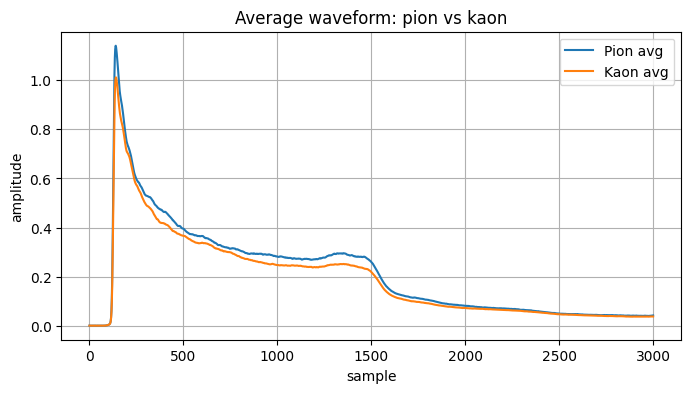

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# using the merged wf and pid from earlier in the script
pions = wf[pid == 211]
kaons = wf[pid == 130]

plt.figure(figsize=(8,4))
plt.plot(pions.mean(axis=0), label="Pion avg")
plt.plot(kaons.mean(axis=0), label="Kaon avg")
plt.legend()
plt.title("Average waveform: pion vs kaon")
plt.xlabel("sample")
plt.ylabel("amplitude")
plt.grid(True)
plt.show()


In [6]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================
DATA_GLOB = "PionsKaons/batch_*.npz"   # will skip test files
RESULT_PATH = "results/pik_dndx_from_ncls.npz"
OUT_FIG_ION_MOM = "results/mean_ionizations_vs_momentum.png"
OUT_FIG_SEP = "results/separation_vs_momentum_from_ionizations.png"

os.makedirs("results", exist_ok=True)

# ============================================================
# LOAD & MERGE DATA
# ============================================================
paths = sorted(glob.glob(DATA_GLOB))
paths = [p for p in paths if "test" not in os.path.basename(p)]

if not paths:
    raise FileNotFoundError(f"No files found matching {DATA_GLOB}")

print("Using files:")
for p in paths:
    print(" -", p)

wf_list, pid_list, mom_list, ncls_list, qsum_list = [], [], [], [], []

for p in tqdm(paths, desc="Loading"):
    d = np.load(p)
    wf_i = d["wf_i"]        # (N,3000) not used here, but could be
    mom = d["mom"]          # (N,)
    ncls = d["ncls"]        # (N,)  number of clusters (ionizations)
    pid = d["pid"]          # (N,)  211 or 130
    tag_values = d["tag_values"]  # (N,300) cluster charges (0-padded)

    # total charge per event (sum over clusters)
    qsum = tag_values.sum(axis=1)

    wf_list.append(wf_i)
    pid_list.append(pid)
    mom_list.append(mom)
    ncls_list.append(ncls)
    qsum_list.append(qsum)

# merge all batches
pid = np.concatenate(pid_list, axis=0)
mom = np.concatenate(mom_list, axis=0)
ncls = np.concatenate(ncls_list, axis=0)
qsum = np.concatenate(qsum_list, axis=0)

print("\nMerged shapes:")
print("  pid :", pid.shape)
print("  mom :", mom.shape)
print("  ncls:", ncls.shape)
print("  qsum:", qsum.shape)

# keep only pions 211 and kaons 130
mask_pik = np.isin(pid, [211, 130])
pid = pid[mask_pik]
mom = mom[mask_pik]
ncls = ncls[mask_pik]
qsum = qsum[mask_pik]

unique, counts = np.unique(pid, return_counts=True)
print("\nPID counts:", dict(zip(unique, counts)))
print("  (211 = pion, 130 = kaon)")

# ============================================================
# DEFINE AN "IONIZATION MEASURE"
# ============================================================
# Option 1: use just the number of clusters (ncls)
ion_measure = ncls.astype(np.float32)

# Option 2 (if you prefer total charge): comment above line and uncomment:
# ion_measure = qsum.astype(np.float32)

# ============================================================
# MOMENTUM BINNING + SEPARATION COMPUTATION
# ============================================================

def separation_power_from_feature(feature, pid, mom, edges):
    """
    Compute S_{K,pi} = |mu_K - mu_pi| / sqrt(sig_K^2 + sig_pi^2)
    for a scalar feature (here, ionization number) in momentum bins.
    """
    feature = np.asarray(feature)
    pid = np.asarray(pid)
    mom = np.asarray(mom)

    centers = 0.5 * (edges[:-1] + edges[1:])
    S = np.zeros_like(centers)
    mean_pi = np.zeros_like(centers)
    mean_k  = np.zeros_like(centers)
    std_pi  = np.zeros_like(centers)
    std_k   = np.zeros_like(centers)

    for i in range(len(centers)):
        mlow, mhigh = edges[i], edges[i+1]
        mask_bin = (mom >= mlow) & (mom < mhigh)

        f_pi = feature[mask_bin & (pid == 211)]
        f_k  = feature[mask_bin & (pid == 130)]

        if len(f_pi) > 1 and len(f_k) > 1:
            mu_pi, mu_k = f_pi.mean(), f_k.mean()
            s_pi, s_k = f_pi.std(ddof=1), f_k.std(ddof=1)

            denom = np.sqrt(s_pi**2 + s_k**2)
            S[i] = np.abs(mu_k - mu_pi) / denom if denom > 0 else 0.0

            mean_pi[i], mean_k[i] = mu_pi, mu_k
            std_pi[i], std_k[i] = s_pi, s_k
        else:
            S[i] = np.nan
            mean_pi[i] = mean_k[i] = std_pi[i] = std_k[i] = np.nan

    return centers, S, mean_pi, mean_k, std_pi, std_k

# Choose momentum bin edges.
# You can adjust these to match your generator / paper (e.g. [8,10,12,15,18,20,22])
m_min, m_max = mom.min(), mom.max()
print(f"\nMomentum range in data: {m_min:.2f} – {m_max:.2f} GeV/c")

# Example fixed edges similar to your histogram (~8–20 GeV):
edges = np.array([8., 10., 12.5, 15., 18., 20., 22.])

centers, S, mean_pi, mean_k, std_pi, std_k = separation_power_from_feature(
    ion_measure, pid, mom, edges
)

# Save raw results for later analysis
np.savez(RESULT_PATH,
         centers=centers, S=S,
         mean_pi=mean_pi, mean_k=mean_k,
         std_pi=std_pi, std_k=std_k,
         edges=edges, mom=mom, pid=pid,
         ion_measure=ion_measure)
print(f"\n✅ Saved ionization-based separation results to {RESULT_PATH}")

# ============================================================
# PLOT 1: MEAN IONIZATION NUMBER VS MOMENTUM (π vs K)
# ============================================================
plt.figure(figsize=(7,5))

# plot with error bars (std / sqrt(N) would be more correct; here we just show std)
plt.errorbar(centers, mean_pi, yerr=std_pi, fmt="o-", label="Pions (211)")
plt.errorbar(centers, mean_k,  yerr=std_k,  fmt="s-", label="Kaons (130)")

plt.xlabel("Momentum (GeV/c)")
plt.ylabel("Ionization measure (e.g. ncls)")
plt.title("Mean ionization vs momentum (pions vs kaons)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_FIG_ION_MOM)
plt.close()
print(f"📊 Saved mean ionization vs momentum plot to {OUT_FIG_ION_MOM}")

# ============================================================
# PLOT 2: SEPARATION POWER VS MOMENTUM
# ============================================================
plt.figure(figsize=(7,5))
plt.plot(centers, S, marker="o", linestyle="-", label="From ionization counts")
plt.xlabel("Momentum (GeV/c)")
plt.ylabel(r"Separation power $S_{K,\pi}$")
plt.title("Kaon/Pion separation vs momentum (from ionization counts)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_FIG_SEP)
plt.close()
print(f"📊 Saved separation vs momentum plot to {OUT_FIG_SEP}")


Using files:
 - PionsKaons/batch_0.npz


Loading: 100%|██████████| 1/1 [00:07<00:00,  7.76s/it]



Merged shapes:
  pid : (100000,)
  mom : (100000,)
  ncls: (100000,)
  qsum: (100000,)

PID counts: {130: 60000, 211: 40000}
  (211 = pion, 130 = kaon)

Momentum range in data: 7.50 – 20.00 GeV/c

✅ Saved ionization-based separation results to results/pik_dndx_from_ncls.npz
📊 Saved mean ionization vs momentum plot to results/mean_ionizations_vs_momentum.png
📊 Saved separation vs momentum plot to results/separation_vs_momentum_from_ionizations.png


Using device: cuda
Run tag: 20251113_061538

Using files:
 - PionsKaons/batch_0.npz

Merged data shapes:
  wf   : (100000, 3000)
  pid  : (100000,)
  mom  : (100000,)
  ncls : (100000,)
  qsum : (100000,)

After filtering to pid in {211,130}:
  PID counts: {130: 60000, 211: 40000}
  (211 = pion, 130 = kaon)
Label distribution [0=pion,1=kaon]: [40000 60000]

Extracting ionization-related features...
Feature matrix shape: (100000, 5)
Example feature row [ncls, qsum, peak, rise_time, qsum/3000]:
[3.0000000e+01 2.8000000e+01 1.3572839e+00 4.1333333e-02 9.3333330e-03]

Normalizing waveform and feature inputs...

Train/Test shapes:
  X_wf_train   : (80000, 3000, 1)
  X_feat_train : (80000, 5)
  X_wf_test    : (20000, 3000, 1)
  X_feat_test  : (20000, 5)


/tmp/ipykernel_100/2424389328.py:259: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(last_ckpt, map_location=device)



🔄 Resuming training from checkpoint: checkpoints_snn_pik_full_resume/last.pt

=== Epoch 2/20 ===


Training: 100%|██████████| 1250/1250 [03:47<00:00,  5.49it/s]


Train Loss 0.6284 | Train Acc 0.6483 | Val Loss 0.6281 | Val Acc 0.6475
⚠️ No improvement (1/5)
💾 Last checkpoint saved to checkpoints_snn_pik_full_resume/last.pt

=== Epoch 3/20 ===


...

Train Loss 0.6276 | Train Acc 0.6481 | Val Loss 0.6275 | Val Acc 0.6484
⚠️ No improvement (3/5)
💾 Last checkpoint saved to checkpoints_snn_pik_full_resume/last.pt

=== Epoch 10/20 ===


Training: 100%|██████████| 1250/1250 [03:47<00:00,  5.50it/s]


Train Loss 0.6275 | Train Acc 0.6487 | Val Loss 0.6285 | Val Acc 0.6489
⚠️ No improvement (4/5)
💾 Last checkpoint saved to checkpoints_snn_pik_full_resume/last.pt

=== Epoch 11/20 ===


Training: 100%|██████████| 1250/1250 [03:47<00:00,  5.50it/s]


Train Loss 0.6275 | Train Acc 0.6483 | Val Loss 0.6287 | Val Acc 0.6481
⚠️ No improvement (5/5)
🛑 Early stopping triggered.

🔎 Training complete. Best model in: checkpoints_snn_pik_full_resume


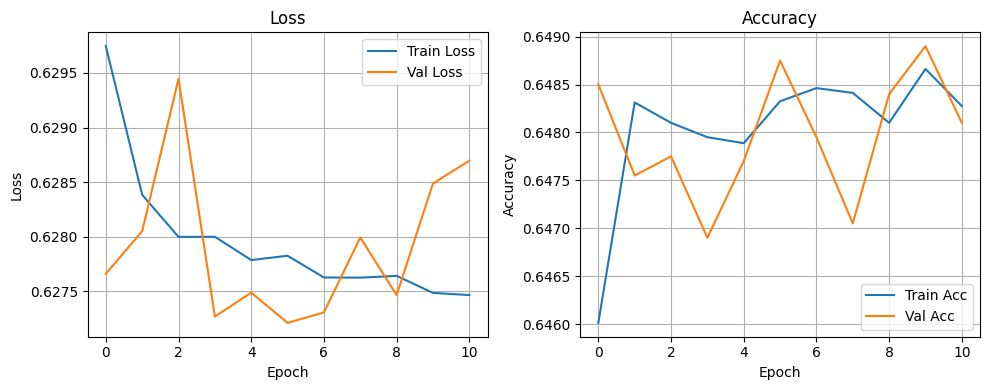

/tmp/ipykernel_100/2424389328.py:388: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"),


📈 Saved training curves to results/pik_training_curve_20251113_061538.png

========== EVALUATION ON TEST SET ==========


Evaluating: 100%|██████████| 313/313 [00:26<00:00, 11.79it/s]


✅ Saved evaluation results to results/snn_pik_hybrid_20251113_061538.npz

=== Classification Report (0=pion,1=kaon) ===
              precision    recall  f1-score   support

        Pion       0.60      0.36      0.45      8000
        Kaon       0.66      0.84      0.74     12000

    accuracy                           0.65     20000
   macro avg       0.63      0.60      0.60     20000
weighted avg       0.64      0.65      0.63     20000


=== Confusion Matrix (rows=true, cols=pred) ===
[[ 2896  5104]
 [ 1921 10079]]


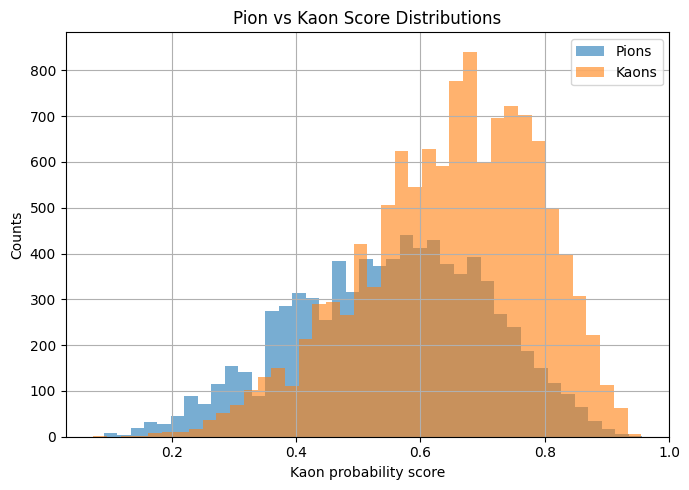

📊 Saved score distribution plot to results/pik_score_distribution_20251113_061538.png


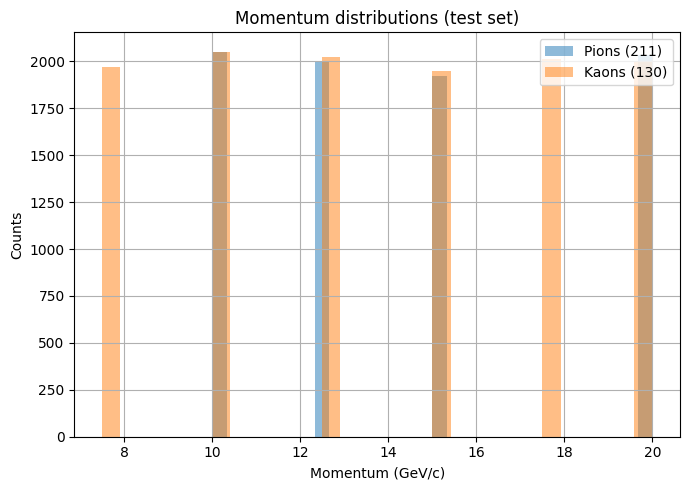

📊 Saved momentum histogram to results/pik_momentum_hist_20251113_061538.png


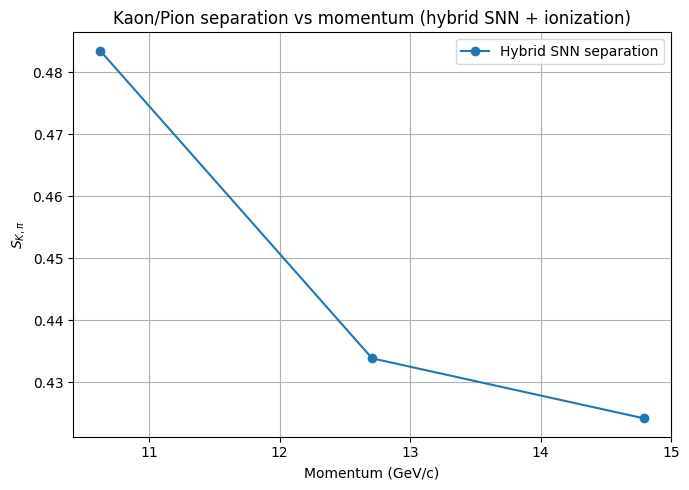

📊 Saved separation vs momentum plot to results/pik_separation_vs_momentum_20251113_061538.png

=== Separation S_{K,π} per momentum bin ===
  Momentum bin center 8.54 GeV/c -> S = nan
  Momentum bin center 10.62 GeV/c -> S = 0.483
  Momentum bin center 12.71 GeV/c -> S = 0.434
  Momentum bin center 14.79 GeV/c -> S = 0.424
  Momentum bin center 16.88 GeV/c -> S = nan
  Momentum bin center 18.96 GeV/c -> S = nan

✅ Done.


In [9]:
import os
import glob
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================
DATA_GLOB = "PionsKaons/batch_*.npz"   # will skip files containing "test"
CHECKPOINT_DIR = "checkpoints_snn_pik_full_resume"
RESULT_BASE = "results/snn_pik_hybrid"

BATCH_SIZE = 64
NUM_EPOCHS = 20
PATIENCE = 5
NUM_TIMESTEPS = 20
NUM_CLASSES = 2

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")  # unique tag per run

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Run tag:", RUN_TAG)

# ============================================================
# LOAD & MERGE DATA
# ============================================================
paths = sorted(glob.glob(DATA_GLOB))
paths = [p for p in paths if "test" not in os.path.basename(p)]

if not paths:
    raise FileNotFoundError(f"No training files found matching {DATA_GLOB}")

print("\nUsing files:")
for p in paths:
    print(" -", p)

wf_list, pid_list, mom_list, ncls_list, qsum_list = [], [], [], [], []

for p in paths:
    d = np.load(p)
    wf_i = d["wf_i"]        # (N,3000)
    pid_i = d["pid"]        # (N,)
    mom_i = d["mom"]        # (N,)

    if "ncls" not in d or "tag_values" not in d:
        raise KeyError("Expected 'ncls' and 'tag_values' in NPZ files.")

    ncls_i = d["ncls"]                      # (N,)
    tag_values_i = d["tag_values"]         # (N, n_clusters or N,300)
    qsum_i = tag_values_i.sum(axis=1)      # total charge

    wf_list.append(wf_i)
    pid_list.append(pid_i)
    mom_list.append(mom_i)
    ncls_list.append(ncls_i)
    qsum_list.append(qsum_i)

wf = np.concatenate(wf_list, axis=0)
pid = np.concatenate(pid_list, axis=0)
mom = np.concatenate(mom_list, axis=0)
ncls = np.concatenate(ncls_list, axis=0)
qsum = np.concatenate(qsum_list, axis=0)

print("\nMerged data shapes:")
print("  wf   :", wf.shape)
print("  pid  :", pid.shape)
print("  mom  :", mom.shape)
print("  ncls :", ncls.shape)
print("  qsum :", qsum.shape)

# ============================================================
# FILTER TO PIONS (211) AND KAONS (130)
# ============================================================
mask_pik = np.isin(pid, [211, 130])
wf = wf[mask_pik]
pid = pid[mask_pik]
mom = mom[mask_pik]
ncls = ncls[mask_pik]
qsum = qsum[mask_pik]

unique, counts = np.unique(pid, return_counts=True)
print("\nAfter filtering to pid in {211,130}:")
print("  PID counts:", dict(zip(unique, counts)))
print("  (211 = pion, 130 = kaon)")

# labels: 0 = pion, 1 = kaon
y = (pid == 130).astype(np.int64)
print("Label distribution [0=pion,1=kaon]:", np.bincount(y))

# ============================================================
# EXTRACT EXPLICIT IONIZATION-RELATED FEATURES
# ============================================================
print("\nExtracting ionization-related features...")

N, T = wf.shape
peak = wf.max(axis=1)

rise_time = np.zeros(N, dtype=np.float32)
for i in range(N):
    p = peak[i]
    if p <= 0:
        rise_time[i] = 0.0
    else:
        half = 0.5 * p
        idx = np.argmax(wf[i] >= half)
        rise_time[i] = idx / float(T)  # normalized [0,1]

charge_per_sample = qsum / float(T)

features = np.stack(
    [ncls.astype(np.float32),
     qsum.astype(np.float32),
     peak.astype(np.float32),
     rise_time.astype(np.float32),
     charge_per_sample.astype(np.float32)],
    axis=1
)

print("Feature matrix shape:", features.shape)
print("Example feature row [ncls, qsum, peak, rise_time, qsum/3000]:")
print(features[0])

# ============================================================
# NORMALIZE WAVEFORMS AND FEATURES
# ============================================================
print("\nNormalizing waveform and feature inputs...")

waveform_scaler = StandardScaler()
wf_norm = waveform_scaler.fit_transform(wf.reshape(-1, 1)).reshape(wf.shape)
X_wf = wf_norm[..., None]  # (N, T, 1)

feature_scaler = StandardScaler()
X_feat = feature_scaler.fit_transform(features)  # (N, 5)

# ============================================================
# TRAIN/TEST SPLIT
# ============================================================
X_wf_train, X_wf_test, X_feat_train, X_feat_test, y_train, y_test, pid_train, pid_test, mom_train, mom_test = \
    train_test_split(
        X_wf, X_feat, y, pid, mom,
        test_size=0.2, random_state=42, stratify=y
    )

print("\nTrain/Test shapes:")
print("  X_wf_train   :", X_wf_train.shape)
print("  X_feat_train :", X_feat_train.shape)
print("  X_wf_test    :", X_wf_test.shape)
print("  X_feat_test  :", X_feat_test.shape)

# ============================================================
# TORCH DATASETS & LOADERS
# ============================================================
X_wf_train_t   = torch.tensor(X_wf_train, dtype=torch.float32)
X_feat_train_t = torch.tensor(X_feat_train, dtype=torch.float32)
y_train_t      = torch.tensor(y_train, dtype=torch.long)
pid_train_t    = torch.tensor(pid_train, dtype=torch.int32)
mom_train_t    = torch.tensor(mom_train, dtype=torch.float32)

X_wf_test_t   = torch.tensor(X_wf_test, dtype=torch.float32)
X_feat_test_t = torch.tensor(X_feat_test, dtype=torch.float32)
y_test_t      = torch.tensor(y_test, dtype=torch.long)
pid_test_t    = torch.tensor(pid_test, dtype=torch.int32)
mom_test_t    = torch.tensor(mom_test, dtype=torch.float32)

train_ds = TensorDataset(X_wf_train_t, X_feat_train_t, y_train_t, pid_train_t, mom_train_t)
test_ds  = TensorDataset(X_wf_test_t,  X_feat_test_t,  y_test_t,  pid_test_t,  mom_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# MODEL: HYBRID SNN + FEATURE MLP
# ============================================================
class HybridSNN(nn.Module):
    def __init__(self, feat_dim=5, beta=0.5, num_classes=2):
        super().__init__()
        # Waveform SNN branch
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.fc_wf = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)

        # Feature MLP branch
        self.fc_feat1 = nn.Linear(feat_dim, 64)
        self.fc_feat2 = nn.Linear(64, 64)

        # Final classifier
        self.fc_out = nn.Linear(128 + 64, num_classes)

    def forward(self, x_wf, x_feat, num_steps=NUM_TIMESTEPS):
        # x_wf: (B, T, 1)
        B, T, _ = x_wf.shape
        x = x_wf.permute(0, 2, 1)  # (B,1,T)

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem_fc = self.lif_fc.init_leaky()

        spk_out = []

        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)   # (B,128,T)

            # average over waveform time dimension → (B,128)
            spk3_mean = spk3.mean(dim=2)
            fc_wf = self.fc_wf(spk3_mean)
            spk_fc, mem_fc = self.lif_fc(fc_wf, mem_fc)  # (B,128)
            spk_out.append(spk_fc)

        # average over SNN timesteps → (B,128)
        wf_repr = torch.stack(spk_out, dim=1).mean(dim=1)

        # Feature branch
        feat_repr = torch.relu(self.fc_feat1(x_feat))
        feat_repr = torch.relu(self.fc_feat2(feat_repr))   # (B,64)

        # Combine
        h = torch.cat([wf_repr, feat_repr], dim=-1)        # (B,192)
        logits = self.fc_out(h)                            # (B,2)
        return logits

model = HybridSNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# ============================================================
# RESUME LOGIC
# ============================================================
last_ckpt = os.path.join(CHECKPOINT_DIR, "last.pt")
start_epoch = 1
best_loss = float("inf")
early_counter = 0
train_curve, val_curve = [], []
train_acc_curve, val_acc_curve = [], []

if os.path.exists(last_ckpt):
    print(f"\n🔄 Resuming training from checkpoint: {last_ckpt}")
    ckpt = torch.load(last_ckpt, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    start_epoch = ckpt["epoch"]
    best_loss = ckpt["best_loss"]
    early_counter = ckpt["early_counter"]
    train_curve = ckpt["train_curve"]
    val_curve = ckpt["val_curve"]
    train_acc_curve = ckpt["train_acc_curve"]
    val_acc_curve = ckpt["val_acc_curve"]
else:
    print("\n🚀 Starting fresh training run.")

# ============================================================
# TRAINING LOOP
# ============================================================
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{NUM_EPOCHS} ===")
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for xb_wf, xb_feat, yb, _, _ in tqdm(train_loader, desc="Training", mininterval=1.0):
        xb_wf, xb_feat, yb = xb_wf.to(device), xb_feat.to(device), yb.to(device)

        logits = model(xb_wf, xb_feat)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb_wf.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb_wf, xb_feat, yb, _, _ in test_loader:
            xb_wf, xb_feat, yb = xb_wf.to(device), xb_feat.to(device), yb.to(device)
            logits = model(xb_wf, xb_feat)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb_wf.size(0)
            preds = logits.argmax(dim=-1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    val_loss /= len(test_loader.dataset)
    val_acc = correct / total

    print(f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    train_curve.append(train_loss)
    val_curve.append(val_loss)
    train_acc_curve.append(train_acc)
    val_acc_curve.append(val_acc)

    # Save best model
    best_path = os.path.join(CHECKPOINT_DIR, "best.pt")
    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
        torch.save(model.state_dict(), best_path)
        print(f"✅ New best model saved to {best_path}")
    else:
        early_counter += 1
        print(f"⚠️ No improvement ({early_counter}/{PATIENCE})")
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break

    # Save last checkpoint (for resume)
    torch.save({
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
        "train_curve": train_curve,
        "val_curve": val_curve,
        "train_acc_curve": train_acc_curve,
        "val_acc_curve": val_acc_curve,
    }, last_ckpt)
    print(f"💾 Last checkpoint saved to {last_ckpt}")

print("\n🔎 Training complete. Best model in:", CHECKPOINT_DIR)

# ============================================================
# TRAINING CURVE PLOT
# ============================================================
curve_path = f"results/pik_training_curve_{RUN_TAG}.png"
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_curve, label="Train Loss")
plt.plot(val_curve, label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_curve, label="Train Acc")
plt.plot(val_acc_curve, label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.savefig(curve_path)
plt.show()
plt.close()
print("📈 Saved training curves to", curve_path)

# ============================================================
# EVALUATION: SCORES, MOMENTUM, SEPARATION
# ============================================================
print("\n========== EVALUATION ON TEST SET ==========")

model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"),
                                 map_location=device))
model.eval()

all_scores = []  # kaon probability
all_pid_eval = []
all_mom_eval = []
all_y_true = []
all_y_pred = []

with torch.no_grad():
    for xb_wf, xb_feat, yb, pidb, momb in tqdm(test_loader, desc="Evaluating", mininterval=1.0):
        xb_wf, xb_feat = xb_wf.to(device), xb_feat.to(device)
        logits = model(xb_wf, xb_feat)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()  # (B,2)

        score = probs[:, 1]                       # prob(kaon)
        pred = probs.argmax(axis=-1)

        all_scores.append(score)
        all_y_pred.append(pred)
        all_y_true.append(yb.numpy())
        all_pid_eval.append(pidb.numpy())
        all_mom_eval.append(momb.numpy())

all_scores    = np.concatenate(all_scores)
all_y_pred    = np.concatenate(all_y_pred)
all_y_true    = np.concatenate(all_y_true)
all_pid_eval  = np.concatenate(all_pid_eval)
all_mom_eval  = np.concatenate(all_mom_eval)

# Save raw results to NPZ with unique name
result_path = f"{RESULT_BASE}_{RUN_TAG}.npz"
np.savez(result_path,
         scores=all_scores,
         y_true=all_y_true,
         y_pred=all_y_pred,
         pid=all_pid_eval,
         mom=all_mom_eval)
print("✅ Saved evaluation results to", result_path)

print("\n=== Classification Report (0=pion,1=kaon) ===")
print(classification_report(all_y_true, all_y_pred, target_names=["Pion", "Kaon"]))

print("\n=== Confusion Matrix (rows=true, cols=pred) ===")
print(confusion_matrix(all_y_true, all_y_pred))

# ============================================================
# SCORE DISTRIBUTION PLOT
# ============================================================
score_path = f"results/pik_score_distribution_{RUN_TAG}.png"
plt.figure(figsize=(7,5))
mask_pi = (all_y_true == 0)
mask_k  = (all_y_true == 1)

plt.hist(all_scores[mask_pi], bins=40, alpha=0.6, label="Pions")
plt.hist(all_scores[mask_k],  bins=40, alpha=0.6, label="Kaons")
plt.xlabel("Kaon probability score")
plt.ylabel("Counts")
plt.title("Pion vs Kaon Score Distributions")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(score_path)
plt.show()
plt.close()
print("📊 Saved score distribution plot to", score_path)

# ============================================================
# MOMENTUM HISTOGRAM PLOT
# ============================================================
mom_path = f"results/pik_momentum_hist_{RUN_TAG}.png"
plt.figure(figsize=(7,5))
plt.hist(all_mom_eval[all_pid_eval == 211], bins=30, alpha=0.5, label="Pions (211)")
plt.hist(all_mom_eval[all_pid_eval == 130], bins=30, alpha=0.5, label="Kaons (130)")
plt.xlabel("Momentum (GeV/c)")
plt.ylabel("Counts")
plt.title("Momentum distributions (test set)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(mom_path)
plt.show()
plt.close()
print("📊 Saved momentum histogram to", mom_path)

# ============================================================
# SEPARATION POWER VS MOMENTUM
# ============================================================
def separation_vs_momentum(scores, pid, mom, nbins=6):
    scores = np.asarray(scores)
    pid = np.asarray(pid)
    mom = np.asarray(mom)

    edges = np.linspace(mom.min(), mom.max(), nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    S = np.zeros(nbins)

    for i in range(nbins):
        mlow, mhigh = edges[i], edges[i+1]
        mask_bin = (mom >= mlow) & (mom < mhigh)

        s_k  = scores[mask_bin & (pid == 130)]
        s_pi = scores[mask_bin & (pid == 211)]

        if len(s_k) > 1 and len(s_pi) > 1:
            mu_k, mu_pi = s_k.mean(), s_pi.mean()
            sig_k, sig_pi = s_k.std(ddof=1), s_pi.std(ddof=1)
            denom = np.sqrt(sig_k**2 + sig_pi**2)
            S[i] = np.abs(mu_k - mu_pi) / denom if denom > 0 else 0.0
        else:
            S[i] = np.nan

    return centers, S

centers, S = separation_vs_momentum(all_scores, all_pid_eval, all_mom_eval, nbins=6)

sep_path = f"results/pik_separation_vs_momentum_{RUN_TAG}.png"
plt.figure(figsize=(7,5))
plt.plot(centers, S, marker="o", linestyle="-", label="Hybrid SNN separation")
plt.xlabel("Momentum (GeV/c)")
plt.ylabel(r"$S_{K,\pi}$")
plt.title("Kaon/Pion separation vs momentum (hybrid SNN + ionization)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(sep_path)
plt.show()
plt.close()
print("📊 Saved separation vs momentum plot to", sep_path)

print("\n=== Separation S_{K,π} per momentum bin ===")
for c, s in zip(centers, S):
    print(f"  Momentum bin center {c:.2f} GeV/c -> S = {s:.3f}")

print("\n✅ Done.")


Loading evaluation results from: results/snn_pik_hybrid_20251113_061538.npz


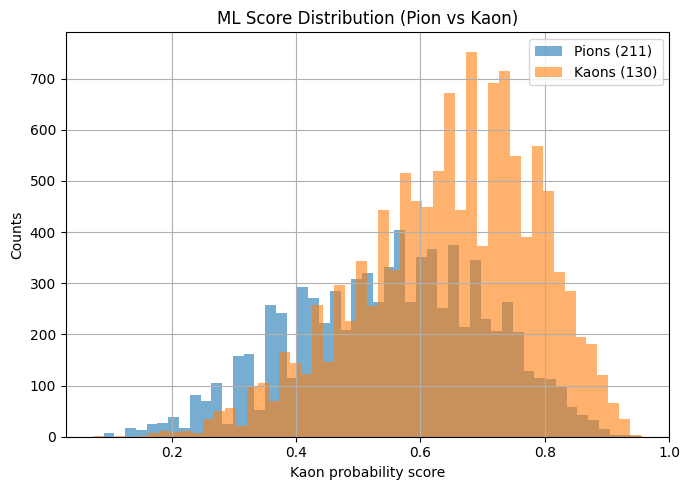

Saved: ml_score_distribution.png

=== ML Means, Sigmas, and Separation Power (Paper Definition) ===
Momentum ≈ 8.54 GeV/c
  Kaons: μ = nan, σ = nan
  Pions: μ = nan, σ = nan
  Separation S = nan

Momentum ≈ 10.62 GeV/c
  Kaons: μ = 0.6662, σ = 0.1327
  Pions: μ = 0.5688, σ = 0.1517
  Separation S = 0.4834

Momentum ≈ 12.71 GeV/c
  Kaons: μ = 0.6483, σ = 0.1379
  Pions: μ = 0.5576, σ = 0.1569
  Separation S = 0.4339

Momentum ≈ 14.79 GeV/c
  Kaons: μ = 0.6353, σ = 0.1433
  Pions: μ = 0.5448, σ = 0.1580
  Separation S = 0.4242

Momentum ≈ 16.88 GeV/c
  Kaons: μ = nan, σ = nan
  Pions: μ = nan, σ = nan
  Separation S = nan

Momentum ≈ 18.96 GeV/c
  Kaons: μ = nan, σ = nan
  Pions: μ = nan, σ = nan
  Separation S = nan



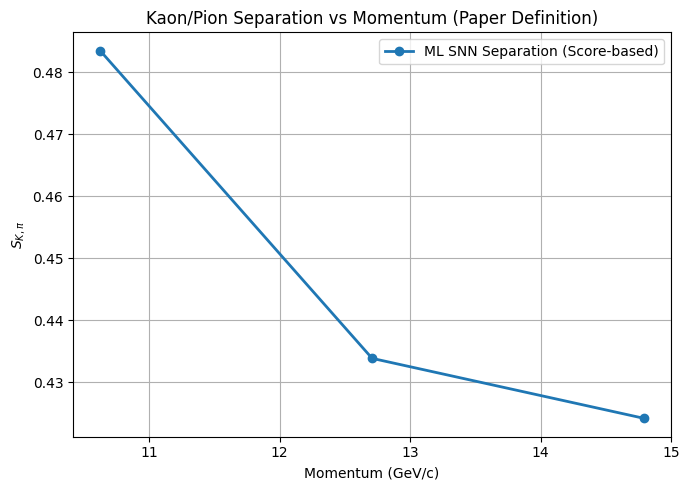

Saved: ml_separation_vs_momentum.png

Done! You now have:
 - ml_score_distribution.png
 - ml_separation_vs_momentum.png
 - printed μ, σ, S table consistent with paper definition


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# ============================================================
# LOAD LATEST NPZ RESULT (produced by your SNN script)
# ============================================================
files = sorted(glob.glob("results/snn_pik_hybrid_*.npz"))
if len(files) == 0:
    raise FileNotFoundError("No results found in results/snn_pik_hybrid_*.npz")

npz_file = files[-1]   # newest file
print(f"Loading evaluation results from: {npz_file}")

data = np.load(npz_file)
scores = data["scores"]    # ML kaon score
pid    = data["pid"]       # 211 or 130
mom    = data["mom"]       # momentum
y_true = data["y_true"]
y_pred = data["y_pred"]

PION = 211
KAON = 130

# ============================================================
# SCORE DISTRIBUTION (matches classical cluster histograms)
# ============================================================
plt.figure(figsize=(7,5))
plt.hist(scores[pid==PION], bins=50, alpha=0.6, label="Pions (211)")
plt.hist(scores[pid==KAON], bins=50, alpha=0.6, label="Kaons (130)")
plt.xlabel("Kaon probability score")
plt.ylabel("Counts")
plt.title("ML Score Distribution (Pion vs Kaon)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("ml_score_distribution.png")
plt.show()
print("Saved: ml_score_distribution.png")

# ============================================================
# SEPARATION POWER USING PAPER'S DEFINITION
# 
# S = |μ_K − μ_π| / sqrt(σ_K² + σ_π²)
# ============================================================
def separation_vs_momentum(scores, pid, mom, nbins=6):
    edges = np.linspace(mom.min(), mom.max(), nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    S_list = []
    muK_list = []
    muPi_list = []
    sigK_list = []
    sigPi_list = []

    for i in range(nbins):
        lo, hi = edges[i], edges[i+1]
        mask = (mom >= lo) & (mom < hi)

        s_k  = scores[mask & (pid == KAON)]
        s_pi = scores[mask & (pid == PION)]

        if len(s_k) < 2 or len(s_pi) < 2:
            S_list.append(np.nan)
            muK_list.append(np.nan)
            muPi_list.append(np.nan)
            sigK_list.append(np.nan)
            sigPi_list.append(np.nan)
            continue

        mu_K = s_k.mean()
        mu_pi = s_pi.mean()
        sig_K = s_k.std(ddof=1)
        sig_pi = s_pi.std(ddof=1)

        S = abs(mu_K - mu_pi) / np.sqrt(sig_K**2 + sig_pi**2)

        S_list.append(S)
        muK_list.append(mu_K)
        muPi_list.append(mu_pi)
        sigK_list.append(sig_K)
        sigPi_list.append(sig_pi)

    return centers, np.array(S_list), np.array(muK_list), np.array(sigK_list), np.array(muPi_list), np.array(sigPi_list)


centers, S, muK, sigK, muPi, sigPi = separation_vs_momentum(scores, pid, mom)

# ============================================================
# Print the μ, σ table (Dylan asked for this)
# ============================================================
print("\n=== ML Means, Sigmas, and Separation Power (Paper Definition) ===")
for c, mk, sk, mp, sp, s in zip(centers, muK, sigK, muPi, sigPi, S):
    print(f"Momentum ≈ {c:.2f} GeV/c")
    print(f"  Kaons: μ = {mk:.4f}, σ = {sk:.4f}")
    print(f"  Pions: μ = {mp:.4f}, σ = {sp:.4f}")
    print(f"  Separation S = {s:.4f}")
    print()

# ============================================================
# PLOT S vs MOMENTUM (Compare with cluster-count result)
# ============================================================
plt.figure(figsize=(7,5))
plt.plot(centers, S, marker="o", lw=2, label="ML SNN Separation (Score-based)")
plt.xlabel("Momentum (GeV/c)")
plt.ylabel(r"$S_{K,\pi}$")
plt.grid(True)
plt.title("Kaon/Pion Separation vs Momentum (Paper Definition)")
plt.legend()
plt.tight_layout()
plt.savefig("ml_separation_vs_momentum.png")
plt.show()
print("Saved: ml_separation_vs_momentum.png")

print("\nDone! You now have:")
print(" - ml_score_distribution.png")
print(" - ml_separation_vs_momentum.png")
print(" - printed μ, σ, S table consistent with paper definition")


In [ ]:
differentiate 3 classes for each particle

Loaded: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
Device: cuda


/tmp/ipykernel_221/777272956.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
Infer wf_i only: 1


=== wf_i-only background-only check ===
Argmax background-only waveforms: 0 / 100000
Threshold background-only waveforms (THR=0.2): 0 / 100000
Saved index lists in: results/wfi_only_background_check

No argmax background-only waveforms found.

No threshold background-only waveforms found at this THR.


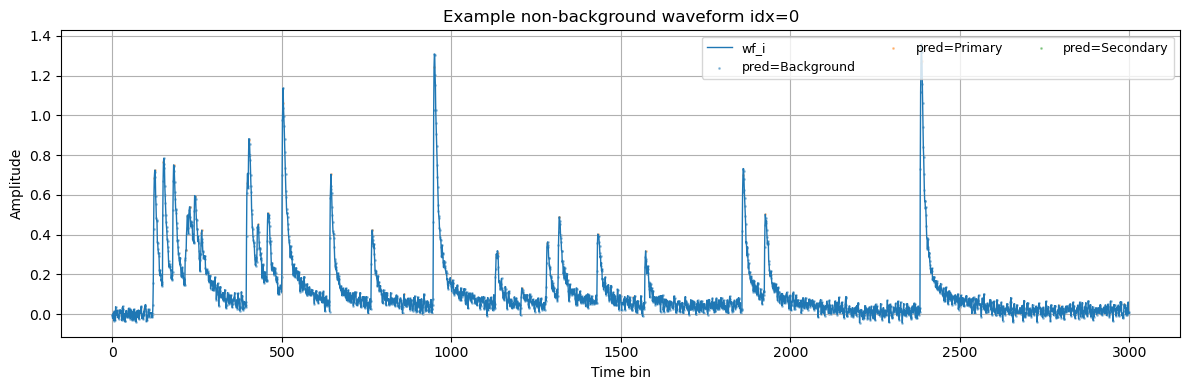

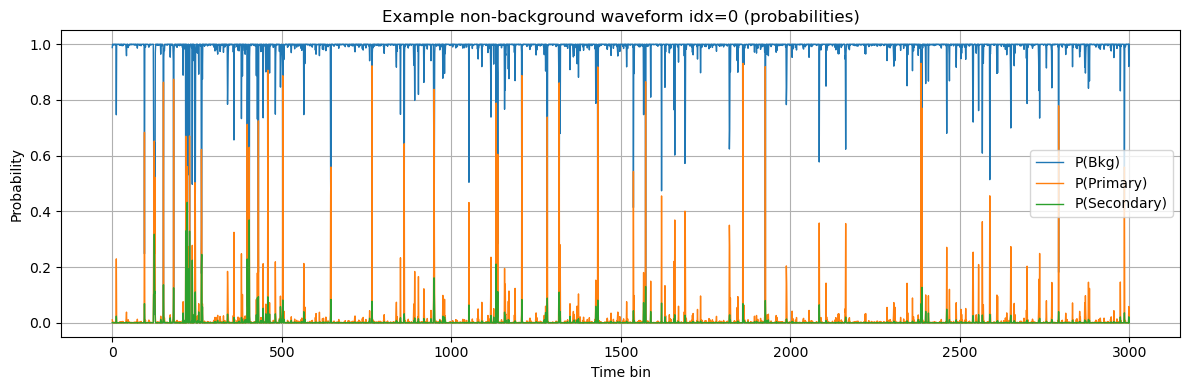

In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================
DATA_NPZ = "PionsKaons/batch_0.npz"   # or batch_0_test.npz
CHECKPOINT_DIR = "checkpoints_snn_seq_3000_batch0_multiclass_v12"
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best.pt")

OUTDIR = "results/wfi_only_background_check"
os.makedirs(OUTDIR, exist_ok=True)

NUM_TIMESTEPS = 20
NUM_CLASSES = 3
T = 3000

BATCH = 64

# For threshold definition of "background-only"
# (waveform is background-only if max P(primary/secondary) < THR)
THR = 0.20

LABELS = ["Background", "Primary", "Secondary"]

# ============================================================
# MODEL (must match your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B,T,1)
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)  # (B,1,T)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)   # (B,T,128)
            fc = self.fc1(spk4)            # (B,T,128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)      # (B,T,3)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,3)

# ============================================================
# Plot helper (wf + predicted labels / probs)
# ============================================================
def plot_waveform_and_probs(wf, probs, title, out_png=None):
    t = np.arange(len(wf))
    pred = probs.argmax(axis=-1)

    plt.figure(figsize=(12,4))
    plt.plot(t, wf, lw=1, label="wf_i")

    # overlay predicted class regions (thin scatter)
    plt.scatter(t[pred==0], wf[pred==0], s=1, label="pred=Background", alpha=0.4)
    plt.scatter(t[pred==1], wf[pred==1], s=1, label="pred=Primary", alpha=0.4)
    plt.scatter(t[pred==2], wf[pred==2], s=1, label="pred=Secondary", alpha=0.4)

    plt.title(title)
    plt.xlabel("Time bin")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()

    if out_png is not None:
        plt.savefig(out_png, dpi=200)
        print("Saved:", out_png)
    plt.close()

    # also show probability traces
    plt.figure(figsize=(12,4))
    plt.plot(t, probs[:,0], lw=1, label="P(Bkg)")
    plt.plot(t, probs[:,1], lw=1, label="P(Primary)")
    plt.plot(t, probs[:,2], lw=1, label="P(Secondary)")
    plt.title(title + " (probabilities)")
    plt.xlabel("Time bin")
    plt.ylabel("Probability")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

# ============================================================
# MAIN: wf_i-only background-only check
# ============================================================
def main():
    # --- load wf_i only ---
    d = np.load(DATA_NPZ, allow_pickle=True)
    if "wf_i" not in d.files:
        raise KeyError(f"{DATA_NPZ} has no 'wf_i'. keys={d.files}")

    wf_i = d["wf_i"].astype(np.float32)   # (N,3000)
    N, TT = wf_i.shape
    assert TT == T, f"Expected T={T}, got {TT}"
    print("Loaded:", DATA_NPZ)
    print("wf_i:", wf_i.shape, wf_i.dtype)

    # --- load model ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    model = ConvSNN_Deep(num_classes=NUM_CLASSES).to(device)
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    model.eval()

    # --- run inference in batches; compute background-only stats ---
    bg_only_argmax = []
    bg_only_thr = []

    # also collect one example index of each kind
    example_bg_argmax = None
    example_bg_thr = None
    example_non_bg = None

    with torch.no_grad():
        for i in tqdm(range(0, N, BATCH), desc="Infer wf_i only"):
            x = wf_i[i:i+BATCH]                    # (B,T)
            xb = torch.tensor(x).unsqueeze(-1).to(device)  # (B,T,1)

            out = model(xb)                        # (B,T,3)
            probs = torch.softmax(out, dim=-1).cpu().numpy()
            pred = probs.argmax(axis=-1)           # (B,T)

            # criterion 1: argmax background-only (all time bins predicted 0)
            is_bg_arg = np.all(pred == 0, axis=1)

            # criterion 2: threshold background-only
            # (max probability for primary/secondary never exceeds THR)
            max_ps = np.max(probs[:,:,1:], axis=(1,2))  # max over time and {1,2}
            is_bg_thr = max_ps < THR

            # store global indices
            for b in range(pred.shape[0]):
                idx = i + b

                if is_bg_arg[b]:
                    bg_only_argmax.append(idx)
                    if example_bg_argmax is None:
                        example_bg_argmax = idx

                if is_bg_thr[b]:
                    bg_only_thr.append(idx)
                    if example_bg_thr is None:
                        example_bg_thr = idx

                if (not is_bg_arg[b]) and example_non_bg is None:
                    example_non_bg = idx

    bg_only_argmax = np.array(bg_only_argmax, dtype=int)
    bg_only_thr = np.array(bg_only_thr, dtype=int)

    print("\n=== wf_i-only background-only check ===")
    print(f"Argmax background-only waveforms: {len(bg_only_argmax)} / {N}")
    print(f"Threshold background-only waveforms (THR={THR}): {len(bg_only_thr)} / {N}")

    # save indices
    np.save(os.path.join(OUTDIR, "bg_only_argmax_indices.npy"), bg_only_argmax)
    np.save(os.path.join(OUTDIR, f"bg_only_thr{THR:.2f}_indices.npy".replace(".","p")), bg_only_thr)

    print("Saved index lists in:", OUTDIR)

    # --- show examples (using wf_i only) ---
    # Re-run single inference for examples (to plot)
    def infer_one(idx):
        x = torch.tensor(wf_i[idx], dtype=torch.float32).view(1, T, 1).to(device)
        with torch.no_grad():
            out = model(x)
            probs = torch.softmax(out, dim=-1)[0].cpu().numpy()
        return probs

    if example_bg_argmax is not None:
        probs = infer_one(example_bg_argmax)
        plot_waveform_and_probs(
            wf_i[example_bg_argmax], probs,
            title=f"Example argmax background-only waveform idx={example_bg_argmax}",
        )
    else:
        print("\nNo argmax background-only waveforms found.")

    if example_bg_thr is not None:
        probs = infer_one(example_bg_thr)
        plot_waveform_and_probs(
            wf_i[example_bg_thr], probs,
            title=f"Example threshold background-only waveform idx={example_bg_thr} (THR={THR})",
        )
    else:
        print("\nNo threshold background-only waveforms found at this THR.")

    if example_non_bg is not None:
        probs = infer_one(example_non_bg)
        plot_waveform_and_probs(
            wf_i[example_non_bg], probs,
            title=f"Example non-background waveform idx={example_non_bg}",
        )

if __name__ == "__main__":
    main()


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loading waveform dataset: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
Device: cuda


/tmp/ipykernel_221/2485277512.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_PT, map_location=device))


Loaded model: checkpoints_snn_seq_3000_batch0_binary_v10/best.pt


Infer v10 on wf_i: 100%|██████████| 1563/1563 [04:15<00:00,  6.12it/s]



=== Background fraction per waveform (v10) ===
Threshold THR=0.5
bkg_frac: min=0.7697, mean=0.9895, max=0.9980
cluster_frac: min=0.0020, mean=0.0105, max=0.2303
Waveforms with >= 90% background: 99979 / 100000
Waveforms with >= 95% background: 99873 / 100000
Waveforms with >= 98% background: 97048 / 100000
Waveforms with >= 99% background: 58079 / 100000


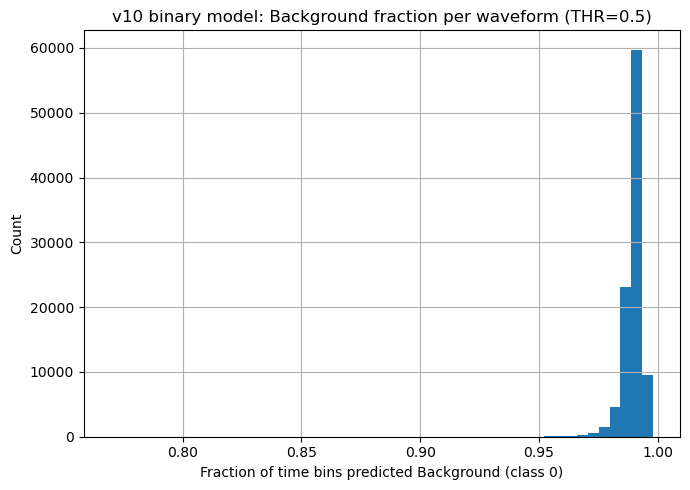

Saved: results/v10_wfi_only_check/bkg_fraction_hist.png


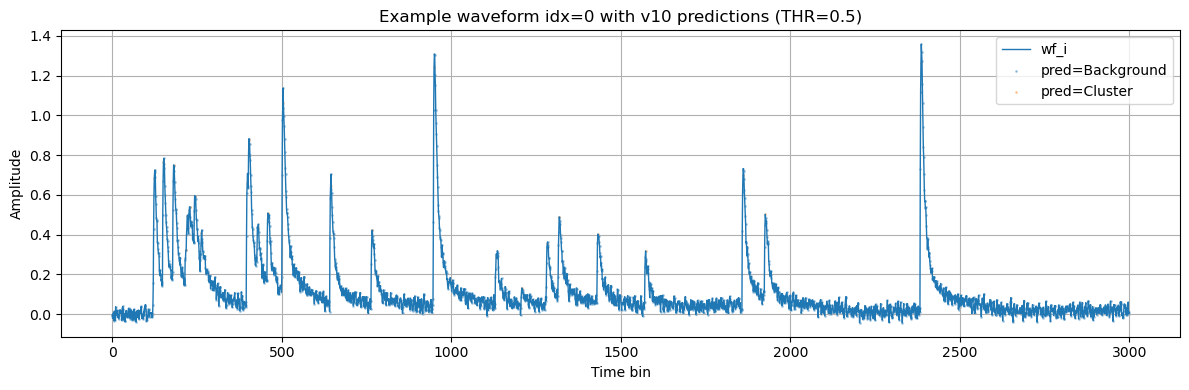

Saved: results/v10_wfi_only_check/example_wf_0.png


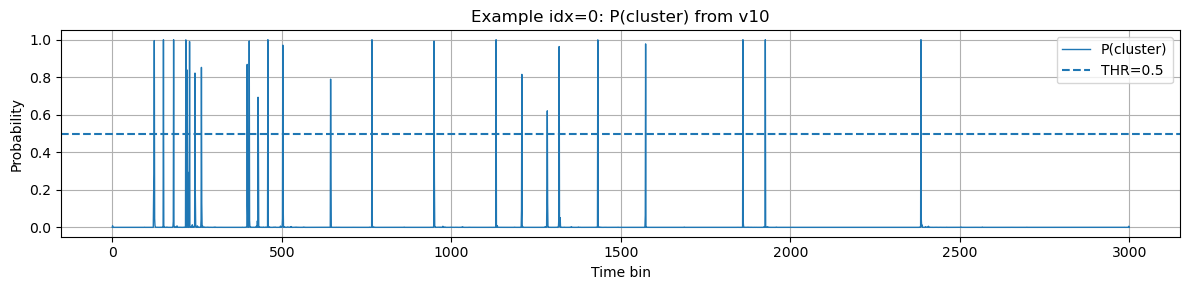

Saved: results/v10_wfi_only_check/example_prob_0.png
Saved arrays in: results/v10_wfi_only_check


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import joblib

# ============================================================
# PATHS
# ============================================================
CACHE_PATH = "cached_data/TimeSeries_seq_3000_batch0.npz"     # to fit scaler exactly like training
DATA_NPZ   = "PionsKaons/batch_0.npz"                         # has wf_i only
CKPT_DIR   = "checkpoints_snn_seq_3000_batch0_binary_v10"
BEST_PT    = os.path.join(CKPT_DIR, "best.pt")

OUTDIR = "results/v10_wfi_only_check"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# CONFIG (match training)
# ============================================================
NUM_TIMESTEPS = 20
NUM_CLASSES = 2
T = 3000
BATCH = 64

# Use your tuned threshold if you know it.
# If not, start with 0.5 and later set it to your best_thr from v10.
THR = 0.50

# ============================================================
# MODEL (same as your v10)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B,T,1)
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)  # (B,1,T)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []

        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)  # (B,T,128)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)     # (B,T,2)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,2)

# ============================================================
# Fit scaler exactly like training (important!)
# ============================================================
print("Loading cached training data to fit scaler:", CACHE_PATH)
train_data = np.load(CACHE_PATH)
X_train = train_data["X_train"]  # (N,T,1) or (N,T,?) depending on your cache

# Fit on the same flattened structure you used in training:
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, 1))
print("Scaler fitted on X_train.")

# ============================================================
# Load wf_i only
# ============================================================
print("\nLoading waveform dataset:", DATA_NPZ)
d = np.load(DATA_NPZ, allow_pickle=True)
wf_i = d["wf_i"].astype(np.float32)  # (N,3000)
N, TT = wf_i.shape
assert TT == T
print("wf_i:", wf_i.shape, wf_i.dtype)

# Normalize wf_i the same way
wf_norm = scaler.transform(wf_i.reshape(-1,1)).reshape(N, T, 1).astype(np.float32)

# ============================================================
# Load model
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = ConvSNN_Deep(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(BEST_PT, map_location=device))
model.eval()
print("Loaded model:", BEST_PT)

# ============================================================
# Inference: get P(cluster)=P(class=1)
# ============================================================
p_cluster = np.zeros((N, T), dtype=np.float32)

with torch.no_grad():
    for i in tqdm(range(0, N, BATCH), desc="Infer v10 on wf_i"):
        xb = torch.tensor(wf_norm[i:i+BATCH], dtype=torch.float32).to(device)  # (B,T,1)
        out = model(xb)  # (B,T,2)
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        p_cluster[i:i+probs.shape[0]] = probs[:, :, 1]

# ============================================================
# Background check (using YOUR model output)
# ============================================================
pred_cluster = (p_cluster >= THR)   # True = cluster (1), False = background (0)
bkg_frac = (~pred_cluster).mean(axis=1)
cls_frac = pred_cluster.mean(axis=1)

print("\n=== Background fraction per waveform (v10) ===")
print(f"Threshold THR={THR}")
print(f"bkg_frac: min={bkg_frac.min():.4f}, mean={bkg_frac.mean():.4f}, max={bkg_frac.max():.4f}")
print(f"cluster_frac: min={cls_frac.min():.4f}, mean={cls_frac.mean():.4f}, max={cls_frac.max():.4f}")

for thr in [0.90, 0.95, 0.98, 0.99]:
    print(f"Waveforms with >= {thr*100:.0f}% background:", int((bkg_frac >= thr).sum()), "/", N)

# ============================================================
# Plot histogram of background fraction
# ============================================================
plt.figure(figsize=(7,5))
plt.hist(bkg_frac, bins=50)
plt.xlabel("Fraction of time bins predicted Background (class 0)")
plt.ylabel("Count")
plt.title(f"v10 binary model: Background fraction per waveform (THR={THR})")
plt.grid(True)
plt.tight_layout()
plt.show()
hist_png = os.path.join(OUTDIR, "bkg_fraction_hist.png")
plt.savefig(hist_png, dpi=200)
plt.close()
print("Saved:", hist_png)

# ============================================================
# Show one example waveform + predicted mask + probability
# ============================================================
idx = 0
t = np.arange(T)
wf = wf_i[idx]
pc = p_cluster[idx]
mask = pred_cluster[idx]

plt.figure(figsize=(12,4))
plt.plot(t, wf, lw=1, label="wf_i")
plt.scatter(t[~mask], wf[~mask], s=1, label="pred=Background", alpha=0.35)
plt.scatter(t[mask],  wf[mask],  s=1, label="pred=Cluster", alpha=0.35)
plt.xlabel("Time bin"); plt.ylabel("Amplitude")
plt.title(f"Example waveform idx={idx} with v10 predictions (THR={THR})")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()
ex_png1 = os.path.join(OUTDIR, f"example_wf_{idx}.png")
plt.savefig(ex_png1, dpi=200); plt.close()
print("Saved:", ex_png1)

plt.figure(figsize=(12,3))
plt.plot(t, pc, lw=1, label="P(cluster)")
plt.axhline(THR, ls="--", label=f"THR={THR}")
plt.xlabel("Time bin"); plt.ylabel("Probability")
plt.title(f"Example idx={idx}: P(cluster) from v10")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()
ex_png2 = os.path.join(OUTDIR, f"example_prob_{idx}.png")
plt.savefig(ex_png2, dpi=200); plt.close()
print("Saved:", ex_png2)

# Save outputs for later
np.save(os.path.join(OUTDIR, "bkg_frac.npy"), bkg_frac)
np.save(os.path.join(OUTDIR, "p_cluster.npy"), p_cluster)
print("Saved arrays in:", OUTDIR)


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
mom: (100000,) range: 7.5 20.0
pid unique: [130 211] counts: [60000 40000]
Overall TRUE primary fraction: 0.008625273333333334

Device: cuda

Part 1: v10 Purity–Efficiency per particle


/tmp/ipykernel_221/280129394.py:209: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
Inference: 100%|████████


[KAON] events=60000
Best thr=0.580 | Purity=72.22% | Eff=84.95% | F1=0.781


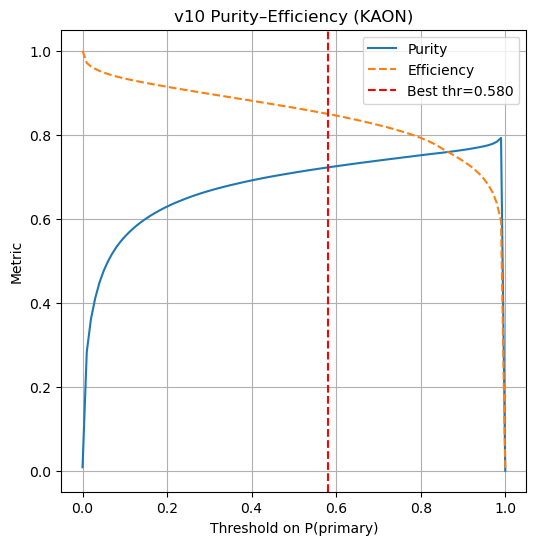


[PION] events=40000
Best thr=0.570 | Purity=72.68% | Eff=84.88% | F1=0.783


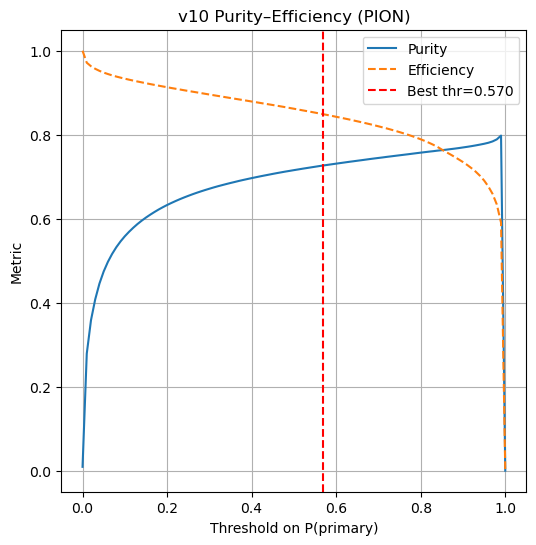


Part 2: v12 Primary-count density + separation (paper def)


/tmp/ipykernel_221/280129394.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
Inference: 100%|████████

mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)


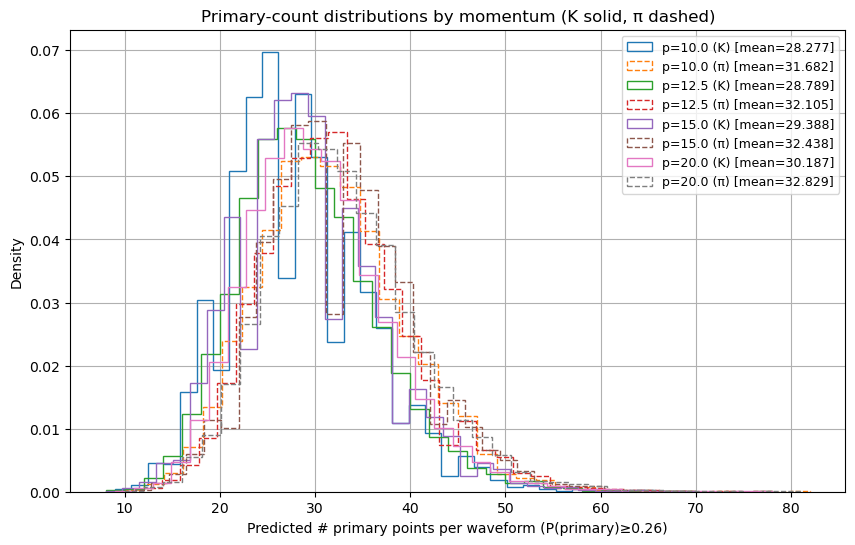

Saved: results/final_eval_batch0_correct_paperdef/v12_primarycount_density_by_mom_thr026.png

=== μ ± σ and S (paper def) ===

Momentum ≈ 10.00 (thr=0.26)
  Kaons: μ=28.2768, σ=7.3083
  Pions: μ=31.6823, σ=7.5859
  Separation S=0.4573

Momentum ≈ 12.50 (thr=0.26)
  Kaons: μ=28.7891, σ=7.3741
  Pions: μ=32.1049, σ=7.6886
  Separation S=0.4403

Momentum ≈ 15.00 (thr=0.26)
  Kaons: μ=29.3876, σ=7.4821
  Pions: μ=32.4383, σ=7.7022
  Separation S=0.4018

Momentum ≈ 20.00 (thr=0.26)
  Kaons: μ=30.1866, σ=7.4520
  Pions: μ=32.8291, σ=7.6690
  Separation S=0.3495


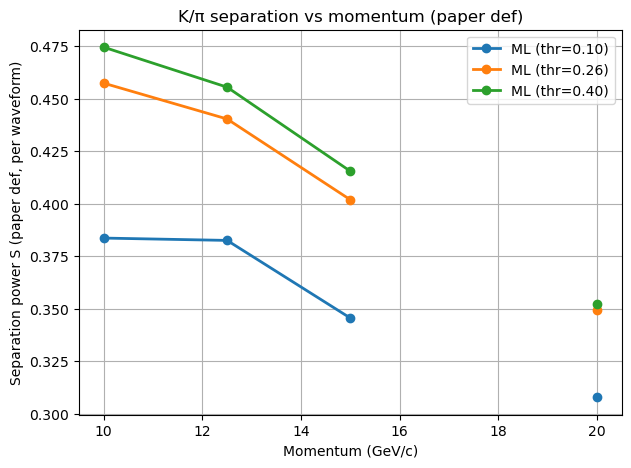

Saved: results/final_eval_batch0_correct_paperdef/v12_sep_vs_mom_paperdef_perwaveform.png

✅ Done. Outputs in: results/final_eval_batch0_correct_paperdef


In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================
DATA_NPZ        = "PionsKaons/batch_0.npz"                  # ✅ use this (has 130/211)
CACHE_TRAIN_NPZ = "cached_data/TimeSeries_seq_3000_batch0.npz"

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"          # 2-class
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"      # 3-class

OUTDIR = "results/final_eval_batch0_correct_paperdef"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 64
NUM_TIMESTEPS = 20
T = 3000

KAON = 130
PION = 211

# for the paper-style “multi-threshold” ML curves
THR_LIST = [0.10, 0.26, 0.40]

# momentum points present in your dataset (7.5–20)
MOM_POINTS = np.array([7.5, 10.0, 12.5, 15.0, 17.5, 20.0], dtype=np.float32)
MOM_TOL = 0.25  # select events with mom within ±0.25 of each point

# ============================================================
# Model (matches your training code)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1    = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1)
        B, T_, _ = x.shape
        x = x.permute(0, 2, 1)  # (B, 1, T)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        outs = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);     spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1);  spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2);  spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3);  spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)  # (B, T, 128)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)     # (B, T, C)
            outs.append(out)

        return torch.stack(outs, dim=2).mean(dim=2)  # (B, T, C)

# ============================================================
# Helpers
# ============================================================
def fit_scaler(cache_path):
    print("Loading cached training data to fit scaler:", cache_path)
    tr = np.load(cache_path)
    X_train = tr["X_train"]
    if X_train.ndim == 2:
        X_train = X_train[..., None]
    sc = StandardScaler()
    sc.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return sc

def load_data(npz_path):
    d = np.load(npz_path)
    wf_i = d["wf_i"].astype(np.float32)      # (N,3000)
    mom  = d["mom"].astype(np.float32)       # (N,)
    pid  = d["pid"].astype(np.int32)         # (N,)
    tag_times  = d["tag_times"].astype(np.int32)   # (N,300)
    tag_values = d["tag_values"].astype(np.int32)  # (N,300)

    print("Loaded:", npz_path)
    print("wf_i:", wf_i.shape, wf_i.dtype)
    print("mom:", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    return wf_i, mom, pid, tag_times, tag_values

def to_0based_tag_times(tag_times, T=3000):
    # if max >= T, it’s almost certainly 1-based
    if int(tag_times.max()) >= T:
        print("Detected 1-based tag_times → converted to 0-based")
        tt = tag_times - 1
    else:
        tt = tag_times.copy()
    tt[(tt < 0) | (tt >= T)] = -1
    return tt

def build_truth_primary_mask(tag_times0, tag_values, T=3000):
    """
    truth_primary[t]=True if that time bin is tagged as primary (tag_value==1).
    """
    N, K = tag_times0.shape
    truth = np.zeros((N, T), dtype=bool)
    for i in range(N):
        for j in range(K):
            t = int(tag_times0[i, j])
            if t >= 0 and int(tag_values[i, j]) == 1:
                truth[i, t] = True
    return truth

def infer_probs(model, wf_i, scaler, device, num_classes):
    X = wf_i[..., None]  # (N,T,1)
    X = scaler.transform(X.reshape(-1, 1)).reshape(X.shape).astype(np.float32)
    X_t = torch.tensor(X, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_t), batch_size=BATCH_SIZE, shuffle=False)

    probs_list = []
    model.eval()
    with torch.no_grad():
        for (xb,) in tqdm(loader, desc="Inference", mininterval=1.0):
            xb = xb.to(device)
            out = model(xb)  # (B,T,C)
            p = torch.softmax(out, dim=-1).cpu().numpy()
            probs_list.append(p)
    probs = np.concatenate(probs_list, axis=0)
    assert probs.shape[-1] == num_classes
    return probs

def purity_efficiency(truth_primary_bool, p_primary, thresholds):
    yt = truth_primary_bool.reshape(-1)
    pp = p_primary.reshape(-1)

    purity = []
    eff = []
    for thr in thresholds:
        pred = pp >= thr
        TP = np.sum(pred & yt)
        FP = np.sum(pred & (~yt))
        FN = np.sum((~pred) & yt)

        p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        e = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        purity.append(p)
        eff.append(e)

    purity = np.array(purity, dtype=np.float64)
    eff    = np.array(eff, dtype=np.float64)
    f1 = 2 * purity * eff / (purity + eff + 1e-12)
    best_idx = int(np.nanargmax(f1))
    return purity, eff, f1, best_idx

def separation_paper(mu_pi, sig_pi, mu_k, sig_k):
    # S = |mu_pi - mu_k| / ((sig_pi + sig_k)/2) = 2|Δμ|/(sig_pi + sig_k)
    return (2.0 * abs(mu_pi - mu_k)) / (sig_pi + sig_k + 1e-12)

def select_mom(mom, target, tol):
    return np.abs(mom - target) <= tol

# ============================================================
# MAIN
# ============================================================
def main():
    thresholds = np.linspace(0, 1, 101)

    scaler = fit_scaler(CACHE_TRAIN_NPZ)
    wf_i, mom, pid, tag_times, tag_values = load_data(DATA_NPZ)

    tag_times0 = to_0based_tag_times(tag_times, T=T)
    truth_primary = build_truth_primary_mask(tag_times0, tag_values, T=T)

    print("Overall TRUE primary fraction:", float(truth_primary.mean()))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # --------------------------
    # Part 1: v10 purity/eff (K and π separately)
    # --------------------------
    print("\n==============================")
    print("Part 1: v10 Purity–Efficiency per particle")
    print("==============================")

    v10 = ConvSNN_Deep(num_classes=2).to(device)
    v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
    probs_v10 = infer_probs(v10, wf_i, scaler, device, num_classes=2)
    p_primary_v10 = probs_v10[:, :, 1]

    for name, code in [("KAON", KAON), ("PION", PION)]:
        m = (pid == code)
        pur, eff, f1, best_idx = purity_efficiency(truth_primary[m], p_primary_v10[m], thresholds)
        best_thr = float(thresholds[best_idx])

        print(f"\n[{name}] events={int(m.sum())}")
        print(f"Best thr={best_thr:.3f} | Purity={pur[best_idx]*100:.2f}% | Eff={eff[best_idx]*100:.2f}% | F1={f1[best_idx]:.3f}")

        plt.figure(figsize=(6,6))
        plt.plot(thresholds, pur, label="Purity")
        plt.plot(thresholds, eff, "--", label="Efficiency")
        plt.axvline(best_thr, color="r", ls="--", label=f"Best thr={best_thr:.3f}")
        plt.xlabel("Threshold on P(primary)")
        plt.ylabel("Metric")
        plt.title(f"v10 Purity–Efficiency ({name})")
        plt.grid(True)
        plt.legend()
        out_png = os.path.join(OUTDIR, f"v10_purity_eff_{name.lower()}_pid{code}.png")
        plt.savefig(out_png, dpi=150)
        plt.show()

    # --------------------------
    # Part 2: v12 density vs mom + separation vs mom (paper def)
    # --------------------------
    print("\n==============================")
    print("Part 2: v12 Primary-count density + separation (paper def)")
    print("==============================")

    v12 = ConvSNN_Deep(num_classes=3).to(device)
    v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
    probs_v12 = infer_probs(v12, wf_i, scaler, device, num_classes=3)
    p_primary_v12 = probs_v12[:, :, 1]

    # ---- density plot at thr=0.26 (like your earlier histogram style)
    VIS_THR = 0.26
    cnt_vis = (p_primary_v12 >= VIS_THR).sum(axis=1).astype(np.int32)

    plt.figure(figsize=(10,6))
    for p0 in MOM_POINTS:
        msel = select_mom(mom, p0, MOM_TOL)
        ksel = msel & (pid == KAON)
        psel = msel & (pid == PION)

        if ksel.sum() == 0 or psel.sum() == 0:
            print(f"mom~{p0:.1f}: skip density (K={ksel.sum()}, Pi={psel.sum()})")
            continue

        ck = cnt_vis[ksel]
        cpi = cnt_vis[psel]
        plt.hist(ck, bins=35, density=True, histtype="step",
                 label=f"p={p0:.1f} (K) [mean={ck.mean():.3f}]")
        plt.hist(cpi, bins=35, density=True, histtype="step", linestyle="--",
                 label=f"p={p0:.1f} (π) [mean={cpi.mean():.3f}]")

    plt.xlabel(f"Predicted # primary points per waveform (P(primary)≥{VIS_THR})")
    plt.ylabel("Density")
    plt.title("Primary-count distributions by momentum (K solid, π dashed)")
    plt.grid(True)
    plt.legend(loc="upper right", fontsize=9)
    out_png = os.path.join(OUTDIR, "v12_primarycount_density_by_mom_thr026.png")
    plt.savefig(out_png, dpi=150)
    plt.show()
    print("Saved:", out_png)

    # ---- separation vs momentum for thr=0.10,0.26,0.40
    sep = {thr: [] for thr in THR_LIST}

    print("\n=== μ ± σ and S (paper def) ===")
    for p0 in MOM_POINTS:
        msel = select_mom(mom, p0, MOM_TOL)
        ksel = msel & (pid == KAON)
        psel = msel & (pid == PION)

        if ksel.sum() == 0 or psel.sum() == 0:
            for thr in THR_LIST:
                sep[thr].append(np.nan)
            continue

        for thr in THR_LIST:
            cnt = (p_primary_v12 >= thr).sum(axis=1).astype(np.int32)
            ck = cnt[ksel]
            cpi = cnt[psel]

            mu_k,  sig_k  = float(ck.mean()),  float(ck.std(ddof=1))
            mu_pi, sig_pi = float(cpi.mean()), float(cpi.std(ddof=1))
            S = separation_paper(mu_pi, sig_pi, mu_k, sig_k)
            sep[thr].append(S)

            if abs(thr - 0.26) < 1e-9:
                print(f"\nMomentum ≈ {p0:.2f} (thr=0.26)")
                print(f"  Kaons: μ={mu_k:.4f}, σ={sig_k:.4f}")
                print(f"  Pions: μ={mu_pi:.4f}, σ={sig_pi:.4f}")
                print(f"  Separation S={S:.4f}")

    plt.figure(figsize=(7,5))
    for thr in THR_LIST:
        plt.plot(MOM_POINTS, np.array(sep[thr]), marker="o", lw=2, label=f"ML (thr={thr:.2f})")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation power S (paper def, per waveform)")
    plt.title("K/π separation vs momentum (paper def)")
    plt.grid(True)
    plt.legend()
    out_png = os.path.join(OUTDIR, "v12_sep_vs_mom_paperdef_perwaveform.png")
    plt.savefig(out_png, dpi=150)
    plt.show()
    print("Saved:", out_png)

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
mom: (100000,) range: 7.5 20.0
pid unique: [130 211] counts: [60000 40000]
Overall TRUE primary fraction: 0.008625273333333334

Device: cuda

Part 1: v10 Purity–Efficiency per particle (best thr = intersection)


/tmp/ipykernel_221/2985295380.py:221: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
Infer v10: 100%|███████


[KAON] events=60000
Intersection thr=1.000 | Purity=0.00% | Eff=0.00%


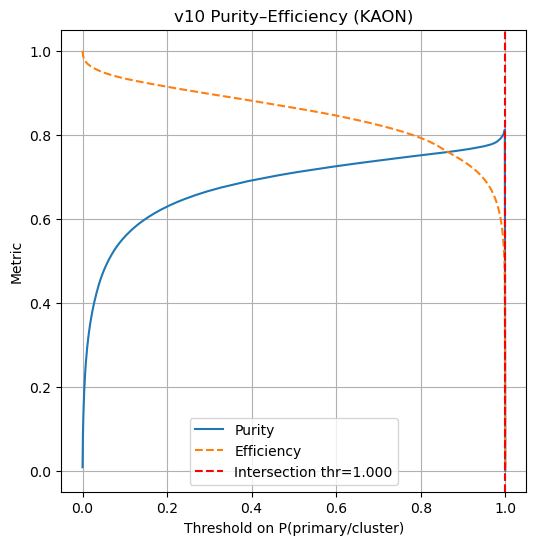

Saved: results/final_eval_batch0_corrected_intersection_and_paperS/v10_purity_eff_kaon_intersection_pid130.png

[PION] events=40000
Intersection thr=1.000 | Purity=0.00% | Eff=0.00%


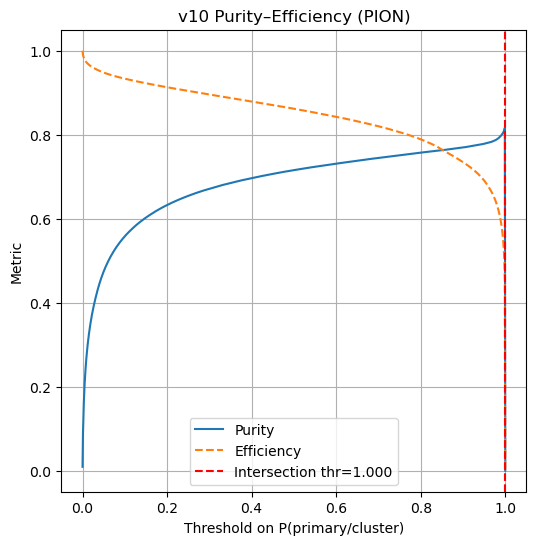

Saved: results/final_eval_batch0_corrected_intersection_and_paperS/v10_purity_eff_pion_intersection_pid211.png

Part 2: v12 Primary-count density + separation vs momentum (paper formula)


/tmp/ipykernel_221/2985295380.py:256: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
Infer v12: 100%|███████

mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)


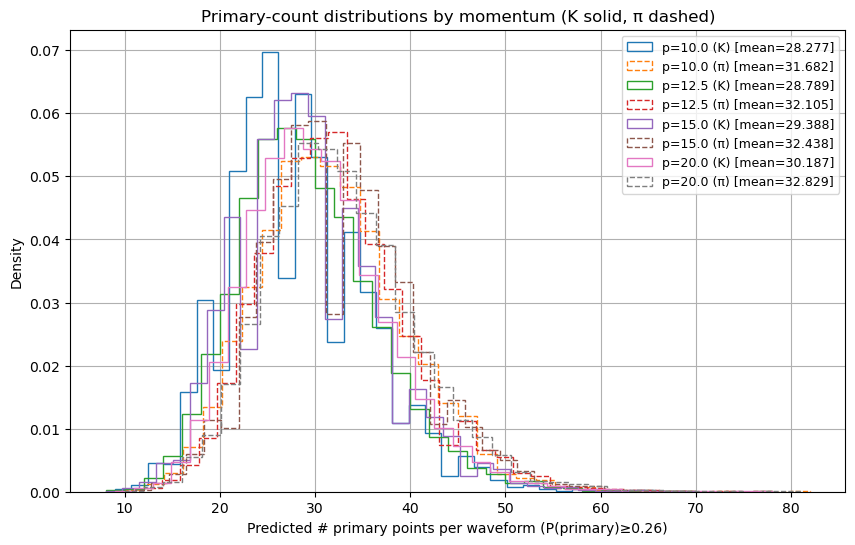

Saved: results/final_eval_batch0_corrected_intersection_and_paperS/v12_primarycount_density_by_mom_thr0.26.png

=== μ ± σ and separation S (paper formula: 2|Δμ|/(σK+σπ)) ===

Momentum ≈ 10.00 (thr=0.26)
  Kaons: μ=28.2768, σ=7.3083
  Pions: μ=31.6823, σ=7.5859
  Separation S=0.4573

Momentum ≈ 12.50 (thr=0.26)
  Kaons: μ=28.7891, σ=7.3741
  Pions: μ=32.1049, σ=7.6886
  Separation S=0.4403

Momentum ≈ 15.00 (thr=0.26)
  Kaons: μ=29.3876, σ=7.4821
  Pions: μ=32.4383, σ=7.7022
  Separation S=0.4018

Momentum ≈ 20.00 (thr=0.26)
  Kaons: μ=30.1866, σ=7.4520
  Pions: μ=32.8291, σ=7.6690
  Separation S=0.3495


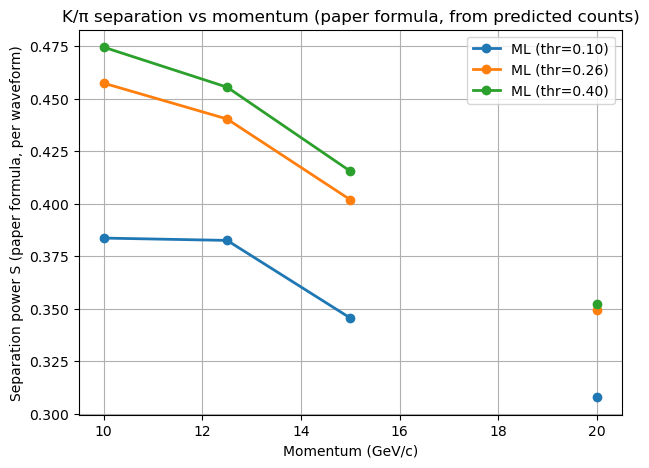

Saved: results/final_eval_batch0_corrected_intersection_and_paperS/v12_sep_vs_mom_paperformula_perwaveform.png

✅ Done. Outputs in: results/final_eval_batch0_corrected_intersection_and_paperS


In [14]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================
DATA_NPZ        = "PionsKaons/batch_0.npz"                  # ✅ use this (has pid 130/211)
CACHE_TRAIN_NPZ = "cached_data/TimeSeries_seq_3000_batch0.npz"

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"          # 2-class (bkg vs cluster)
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"      # 3-class (bkg/primary/secondary)

OUTDIR = "results/final_eval_batch0_corrected_intersection_and_paperS"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 64
NUM_TIMESTEPS = 20
T = 3000

KAON = 130
PION = 211

# thresholds for separation plot (like your old plot: ML thr=0.10, 0.26, 0.40)
THR_LIST = [0.10, 0.26, 0.40]

# momentum points present in your dataset (7.5–20); some bins may lack π or K
MOM_POINTS = np.array([7.5, 10.0, 12.5, 15.0, 17.5, 20.0], dtype=np.float32)
MOM_TOL = 0.25  # select events with mom within ±0.25 of each target

# v12 histogram visualization threshold
VIS_THR = 0.26

# ============================================================
# Model (matches your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1    = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1)
        B, T_, _ = x.shape
        x = x.permute(0, 2, 1)  # (B, 1, T)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        outs = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);     spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1);  spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2);  spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3);  spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)  # (B, T, 128)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)     # (B, T, C)
            outs.append(out)

        return torch.stack(outs, dim=2).mean(dim=2)  # (B, T, C)

# ============================================================
# Helpers
# ============================================================
def fit_scaler(cache_path):
    print("Loading cached training data to fit scaler:", cache_path)
    tr = np.load(cache_path)
    X_train = tr["X_train"]
    if X_train.ndim == 2:
        X_train = X_train[..., None]
    sc = StandardScaler()
    sc.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return sc

def load_data(npz_path):
    d = np.load(npz_path)
    wf_i = d["wf_i"].astype(np.float32)      # (N,3000)
    mom  = d["mom"].astype(np.float32)       # (N,)
    pid  = d["pid"].astype(np.int32)         # (N,)
    tag_times  = d["tag_times"].astype(np.int32)   # (N,300)
    tag_values = d["tag_values"].astype(np.int32)  # (N,300)

    print("Loaded:", npz_path)
    print("wf_i:", wf_i.shape, wf_i.dtype)
    print("mom:", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    return wf_i, mom, pid, tag_times, tag_values

def to_0based_tag_times(tag_times, T=3000):
    # if max >= T, it’s almost certainly 1-based
    if int(tag_times.max()) >= T:
        print("Detected 1-based tag_times → converted to 0-based")
        tt = tag_times - 1
    else:
        tt = tag_times.copy()
    tt[(tt < 0) | (tt >= T)] = -1
    return tt

def build_truth_primary_mask(tag_times0, tag_values, T=3000):
    """
    truth_primary[t]=True if that time bin is tagged as primary (tag_value==1).
    """
    N, K = tag_times0.shape
    truth = np.zeros((N, T), dtype=bool)
    for i in range(N):
        for j in range(K):
            t = int(tag_times0[i, j])
            if t >= 0 and int(tag_values[i, j]) == 1:
                truth[i, t] = True
    return truth

def infer_probs(model, wf_i, scaler, device, num_classes, desc="Inference"):
    X = wf_i[..., None]  # (N,T,1)
    X = scaler.transform(X.reshape(-1, 1)).reshape(X.shape).astype(np.float32)
    X_t = torch.tensor(X, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_t), batch_size=BATCH_SIZE, shuffle=False)

    probs_list = []
    model.eval()
    with torch.no_grad():
        for (xb,) in tqdm(loader, desc=desc, mininterval=1.0):
            xb = xb.to(device)
            out = model(xb)  # (B,T,C)
            p = torch.softmax(out, dim=-1).cpu().numpy()
            probs_list.append(p)
    probs = np.concatenate(probs_list, axis=0)
    assert probs.shape[-1] == num_classes
    return probs

def purity_efficiency(truth_primary_bool, p_primary, thresholds):
    yt = truth_primary_bool.reshape(-1)
    pp = p_primary.reshape(-1)

    purity = []
    eff = []
    for thr in thresholds:
        pred = pp >= thr
        TP = np.sum(pred & yt)
        FP = np.sum(pred & (~yt))
        FN = np.sum((~pred) & yt)

        p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        e = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        purity.append(p)
        eff.append(e)

    purity = np.array(purity, dtype=np.float64)
    eff    = np.array(eff, dtype=np.float64)

    # intersection index: Purity ≈ Efficiency
    idx_eq = int(np.argmin(np.abs(purity - eff)))
    return purity, eff, idx_eq

def separation_paper(mu_k, sig_k, mu_pi, sig_pi):
    """
    Paper-style separation:
        S = |mu_k - mu_pi| / ((sig_k + sig_pi)/2) = 2|Δμ|/(sig_k + sig_pi)
    IMPORTANT: this is NOT the sqrt(sig^2 sum) version.
    """
    return (2.0 * abs(mu_k - mu_pi)) / (sig_k + sig_pi + 1e-12)

def select_mom(mom, target, tol):
    return np.abs(mom - target) <= tol

def count_primary_per_waveform(p_primary, thr):
    # p_primary: (N,T)
    return (p_primary >= thr).sum(axis=1).astype(np.int32)

# ============================================================
# MAIN
# ============================================================
def main():
    thresholds = np.linspace(0, 1, 1001)  # finer grid so intersection is stable

    scaler = fit_scaler(CACHE_TRAIN_NPZ)
    wf_i, mom, pid, tag_times, tag_values = load_data(DATA_NPZ)

    tag_times0 = to_0based_tag_times(tag_times, T=T)
    truth_primary = build_truth_primary_mask(tag_times0, tag_values, T=T)

    print("Overall TRUE primary fraction:", float(truth_primary.mean()))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # --------------------------
    # Part 1: v10 purity/eff (K and π separately) — "best thr" = intersection
    # --------------------------
    print("\n==============================")
    print("Part 1: v10 Purity–Efficiency per particle (best thr = intersection)")
    print("==============================")

    v10 = ConvSNN_Deep(num_classes=2).to(device)
    v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
    probs_v10 = infer_probs(v10, wf_i, scaler, device, num_classes=2, desc="Infer v10")
    p_primary_v10 = probs_v10[:, :, 1]  # treat class-1 as "cluster/primary-like" for PE evaluation

    for name, code in [("KAON", KAON), ("PION", PION)]:
        m = (pid == code)
        pur, eff, idx_eq = purity_efficiency(truth_primary[m], p_primary_v10[m], thresholds)
        thr_eq = float(thresholds[idx_eq])

        print(f"\n[{name}] events={int(m.sum())}")
        print(f"Intersection thr={thr_eq:.3f} | Purity={pur[idx_eq]*100:.2f}% | Eff={eff[idx_eq]*100:.2f}%")

        plt.figure(figsize=(6,6))
        plt.plot(thresholds, pur, label="Purity")
        plt.plot(thresholds, eff, "--", label="Efficiency")
        plt.axvline(thr_eq, color="r", ls="--", label=f"Intersection thr={thr_eq:.3f}")
        plt.xlabel("Threshold on P(primary/cluster)")
        plt.ylabel("Metric")
        plt.title(f"v10 Purity–Efficiency ({name})")
        plt.grid(True)
        plt.legend()
        out_png = os.path.join(OUTDIR, f"v10_purity_eff_{name.lower()}_intersection_pid{code}.png")
        plt.savefig(out_png, dpi=150)
        plt.show()
        print("Saved:", out_png)

    # --------------------------
    # Part 2: v12 primary-count density vs momentum (K vs π) + separation vs momentum
    #         Separation uses PAPER formula and uses COUNTS (not raw probability scores)
    # --------------------------
    print("\n==============================")
    print("Part 2: v12 Primary-count density + separation vs momentum (paper formula)")
    print("==============================")

    v12 = ConvSNN_Deep(num_classes=3).to(device)
    v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
    probs_v12 = infer_probs(v12, wf_i, scaler, device, num_classes=3, desc="Infer v12")
    p_primary_v12 = probs_v12[:, :, 1]

    # ---- density plot (counts per waveform) at VIS_THR
    cnt_vis = count_primary_per_waveform(p_primary_v12, VIS_THR)

    plt.figure(figsize=(10,6))
    used_any = False
    for p0 in MOM_POINTS:
        msel = select_mom(mom, p0, MOM_TOL)
        ksel = msel & (pid == KAON)
        psel = msel & (pid == PION)

        if ksel.sum() == 0 or psel.sum() == 0:
            print(f"mom~{p0:.1f}: skip density (K={ksel.sum()}, Pi={psel.sum()})")
            continue

        ck = cnt_vis[ksel]
        cpi = cnt_vis[psel]
        used_any = True

        plt.hist(ck, bins=35, density=True, histtype="step",
                 label=f"p={p0:.1f} (K) [mean={ck.mean():.3f}]")
        plt.hist(cpi, bins=35, density=True, histtype="step", linestyle="--",
                 label=f"p={p0:.1f} (π) [mean={cpi.mean():.3f}]")

    plt.xlabel(f"Predicted # primary points per waveform (P(primary)≥{VIS_THR})")
    plt.ylabel("Density")
    plt.title("Primary-count distributions by momentum (K solid, π dashed)")
    plt.grid(True)
    if used_any:
        plt.legend(loc="upper right", fontsize=9)
    out_png = os.path.join(OUTDIR, f"v12_primarycount_density_by_mom_thr{VIS_THR:.2f}.png")
    plt.savefig(out_png, dpi=150)
    plt.show()
    print("Saved:", out_png)

    # ---- separation vs momentum for each threshold in THR_LIST
    sep = {thr: [] for thr in THR_LIST}
    centers = []

    print("\n=== μ ± σ and separation S (paper formula: 2|Δμ|/(σK+σπ)) ===")
    for p0 in MOM_POINTS:
        msel = select_mom(mom, p0, MOM_TOL)
        ksel = msel & (pid == KAON)
        psel = msel & (pid == PION)

        if ksel.sum() == 0 or psel.sum() == 0:
            for thr in THR_LIST:
                sep[thr].append(np.nan)
            continue

        centers.append(float(p0))

        for thr in THR_LIST:
            cnt = count_primary_per_waveform(p_primary_v12, thr)
            ck = cnt[ksel]
            cpi = cnt[psel]

            mu_k,  sig_k  = float(ck.mean()),  float(ck.std(ddof=1))
            mu_pi, sig_pi = float(cpi.mean()), float(cpi.std(ddof=1))

            S = separation_paper(mu_k, sig_k, mu_pi, sig_pi)
            sep[thr].append(S)

            if abs(thr - 0.26) < 1e-12:
                print(f"\nMomentum ≈ {p0:.2f} (thr=0.26)")
                print(f"  Kaons: μ={mu_k:.4f}, σ={sig_k:.4f}")
                print(f"  Pions: μ={mu_pi:.4f}, σ={sig_pi:.4f}")
                print(f"  Separation S={S:.4f}")

    plt.figure(figsize=(7,5))
    for thr in THR_LIST:
        plt.plot(MOM_POINTS, np.array(sep[thr], dtype=float), marker="o", lw=2, label=f"ML (thr={thr:.2f})")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation power S (paper formula, per waveform)")
    plt.title("K/π separation vs momentum (paper formula, from predicted counts)")
    plt.grid(True)
    plt.legend()
    out_png = os.path.join(OUTDIR, "v12_sep_vs_mom_paperformula_perwaveform.png")
    plt.savefig(out_png, dpi=150)
    plt.show()
    print("Saved:", out_png)

    # Save arrays for reuse
    np.savez(
        os.path.join(OUTDIR, "v12_sep_vs_mom_paperformula_perwaveform.npz"),
        mom_points=MOM_POINTS,
        thr_list=np.array(THR_LIST, dtype=float),
        sep_thr_010=np.array(sep[0.10], dtype=float),
        sep_thr_026=np.array(sep[0.26], dtype=float),
        sep_thr_040=np.array(sep[0.40], dtype=float),
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
mom: (100000,) range: 7.5 20.0
pid unique: [130 211] counts: [60000 40000]
Overall TRUE primary fraction: 0.008625273333333334

Device: cuda

Part 1: v10 Purity–Efficiency per particle (intersection)


/tmp/ipykernel_221/351964062.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
Infer v10: 100%|████████


[KAON] events=60000
Intersection thr≈0.865 | Purity≈75.90% | Eff≈75.87%


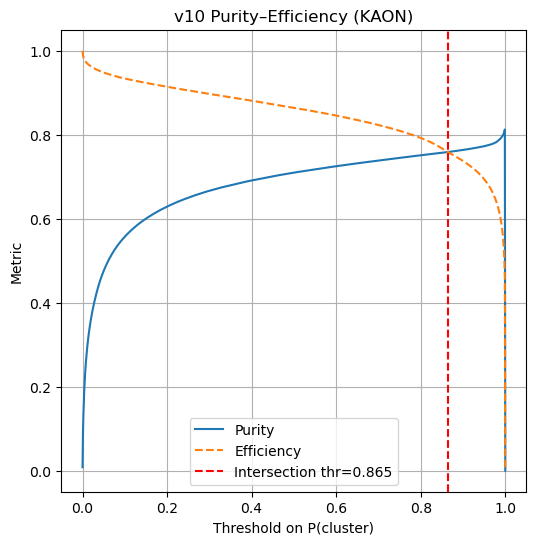

Saved: results/final_eval_batch0_fixed_intersection_and_scaledS/v10_purity_eff_kaon_intersection.png

[PION] events=40000
Intersection thr≈0.852 | Purity≈76.34% | Eff≈76.34%


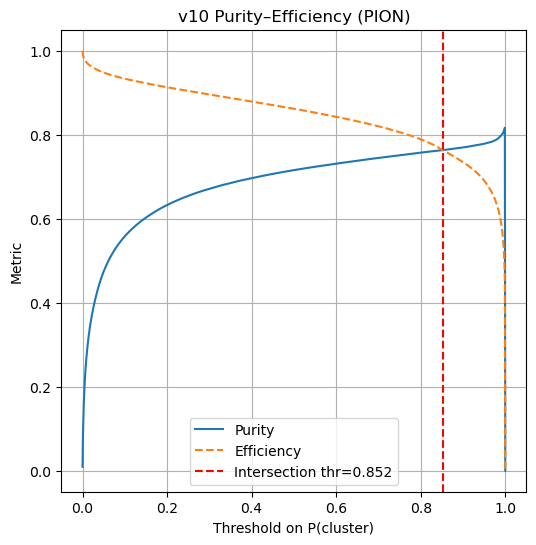

Saved: results/final_eval_batch0_fixed_intersection_and_scaledS/v10_purity_eff_pion_intersection.png

Part 2: v12 Primary-count density + separation vs momentum (paper formula)


/tmp/ipykernel_221/351964062.py:275: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
Infer v12: 100%|████████

mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)


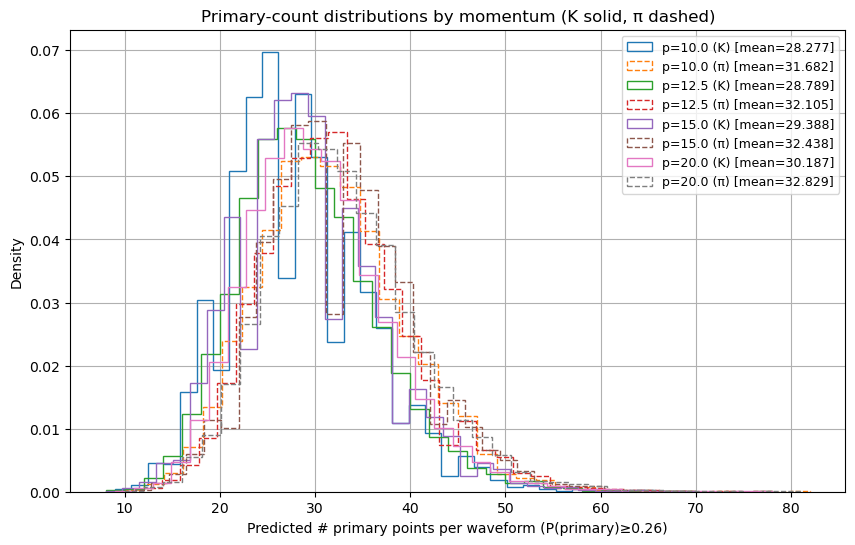

Saved: results/final_eval_batch0_fixed_intersection_and_scaledS/v12_primarycount_density_by_mom_thr0.26.png

=== μ ± σ and separation S (paper formula: 2|Δμ|/(σK+σπ)) ===

Momentum ≈ 10.00 (thr=0.26)
  Kaons: μ=28.2768, σ=7.3083
  Pions: μ=31.6823, σ=7.5859
  Separation S=0.4573

Momentum ≈ 12.50 (thr=0.26)
  Kaons: μ=28.7891, σ=7.3741
  Pions: μ=32.1049, σ=7.6886
  Separation S=0.4403

Momentum ≈ 15.00 (thr=0.26)
  Kaons: μ=29.3876, σ=7.4821
  Pions: μ=32.4383, σ=7.7022
  Separation S=0.4018

Momentum ≈ 20.00 (thr=0.26)
  Kaons: μ=30.1866, σ=7.4520
  Pions: μ=32.8291, σ=7.6690
  Separation S=0.3495


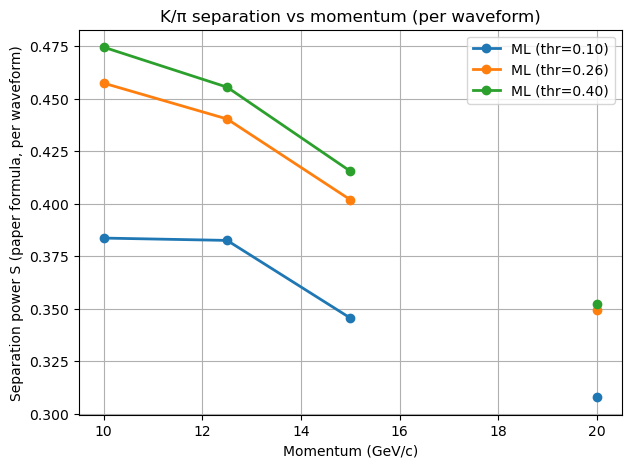

Saved: results/final_eval_batch0_fixed_intersection_and_scaledS/v12_sep_vs_mom_paperformula_perwaveform.png

✅ Done. Outputs in: results/final_eval_batch0_fixed_intersection_and_scaledS


In [15]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================
DATA_NPZ        = "PionsKaons/batch_0.npz"                  # ✅ has pid 130/211
CACHE_TRAIN_NPZ = "cached_data/TimeSeries_seq_3000_batch0.npz"

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"

OUTDIR = "results/final_eval_batch0_fixed_intersection_and_scaledS"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 64
NUM_TIMESTEPS = 20
T = 3000

KAON = 130
PION = 211

THR_LIST = [0.10, 0.26, 0.40]
VIS_THR  = 0.26

MOM_POINTS = np.array([7.5, 10.0, 12.5, 15.0, 17.5, 20.0], dtype=np.float32)
MOM_TOL = 0.25

# ---- Optional: scale separation to "per meter" (paper-like)
# Set this to the effective length represented by ONE waveform/cell in meters.
# If you don't know, leave it None and you will only get per-waveform S.
CELL_LEN_M = None   # e.g. 0.018 for 18 mm (if that's correct for your detector)

# ============================================================
# Model (same as training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1    = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1)
        x = x.permute(0, 2, 1)  # (B, 1, T)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        outs = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);     spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1);  spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2);  spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3);  spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)  # (B, T, 128)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)     # (B, T, C)
            outs.append(out)

        return torch.stack(outs, dim=2).mean(dim=2)  # (B, T, C)

# ============================================================
# Helpers
# ============================================================
def fit_scaler(cache_path):
    print("Loading cached training data to fit scaler:", cache_path)
    tr = np.load(cache_path)
    X_train = tr["X_train"]
    if X_train.ndim == 2:
        X_train = X_train[..., None]
    sc = StandardScaler()
    sc.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return sc

def load_data(npz_path):
    d = np.load(npz_path)
    wf_i = d["wf_i"].astype(np.float32)      # (N,3000)
    mom  = d["mom"].astype(np.float32)       # (N,)
    pid  = d["pid"].astype(np.int32)         # (N,)
    tag_times  = d["tag_times"].astype(np.int32)
    tag_values = d["tag_values"].astype(np.int32)

    print("Loaded:", npz_path)
    print("wf_i:", wf_i.shape, wf_i.dtype)
    print("mom:", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    return wf_i, mom, pid, tag_times, tag_values

def to_0based_tag_times(tag_times, T=3000):
    if int(tag_times.max()) >= T:
        print("Detected 1-based tag_times → converted to 0-based")
        tt = tag_times - 1
    else:
        tt = tag_times.copy()
    tt[(tt < 0) | (tt >= T)] = -1
    return tt

def build_truth_primary_mask(tag_times0, tag_values, T=3000):
    # True if tag_value==1 at that time bin
    N, K = tag_times0.shape
    truth = np.zeros((N, T), dtype=bool)
    for i in range(N):
        for j in range(K):
            t = int(tag_times0[i, j])
            if t >= 0 and int(tag_values[i, j]) == 1:
                truth[i, t] = True
    return truth

def infer_probs(model, wf_i, scaler, device, num_classes, desc):
    X = wf_i[..., None]
    X = scaler.transform(X.reshape(-1, 1)).reshape(X.shape).astype(np.float32)
    X_t = torch.tensor(X, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_t), batch_size=BATCH_SIZE, shuffle=False)

    out_list = []
    model.eval()
    with torch.no_grad():
        for (xb,) in tqdm(loader, desc=desc, mininterval=1.0):
            xb = xb.to(device)
            logits = model(xb)
            p = torch.softmax(logits, dim=-1).cpu().numpy()
            out_list.append(p)
    probs = np.concatenate(out_list, axis=0)
    assert probs.shape[-1] == num_classes
    return probs

def purity_eff_curves(truth_bool, p_primary, thresholds):
    yt = truth_bool.reshape(-1)
    pp = p_primary.reshape(-1)

    purity = np.zeros_like(thresholds, dtype=np.float64)
    eff    = np.zeros_like(thresholds, dtype=np.float64)

    for i, thr in enumerate(thresholds):
        pred = (pp >= thr)
        TP = np.sum(pred & yt)
        FP = np.sum(pred & (~yt))
        FN = np.sum((~pred) & yt)

        purity[i] = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        eff[i]    = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    return purity, eff

def intersection_threshold(thresholds, purity, eff):
    """
    Robust crossing finder:
    find where (purity - eff) changes sign and linearly interpolate.
    Avoid the bogus (0,0) corner problem.
    """
    d = purity - eff

    # Find indices where sign changes between consecutive points
    sign = np.sign(d)
    change = np.where(sign[:-1] * sign[1:] < 0)[0]

    if len(change) == 0:
        # Fallback: choose closest crossing BUT only where both > 0
        mask = (purity > 0) & (eff > 0)
        if np.any(mask):
            idx = np.argmin(np.abs(d[mask]))
            idx = np.where(mask)[0][idx]
            return float(thresholds[idx]), idx, idx
        # Worst fallback
        idx = int(np.argmin(np.abs(d)))
        return float(thresholds[idx]), idx, idx

    i = int(change[0])  # first crossing
    x0, x1 = thresholds[i], thresholds[i+1]
    y0, y1 = d[i], d[i+1]

    # linear interpolation for d=0
    thr_star = x0 + (0 - y0) * (x1 - x0) / (y1 - y0 + 1e-12)
    return float(thr_star), i, i+1

def separation_paper(mu_k, sig_k, mu_pi, sig_pi):
    # S = 2|Δμ|/(σk+σπ)
    return (2.0 * abs(mu_k - mu_pi)) / (sig_k + sig_pi + 1e-12)

def select_mom(mom, target, tol):
    return np.abs(mom - target) <= tol

def count_primary_per_waveform(p_primary, thr):
    return (p_primary >= thr).sum(axis=1).astype(np.int32)

# ============================================================
# MAIN
# ============================================================
def main():
    thresholds = np.linspace(0, 1, 1001)

    scaler = fit_scaler(CACHE_TRAIN_NPZ)
    wf_i, mom, pid, tag_times, tag_values = load_data(DATA_NPZ)

    tag_times0 = to_0based_tag_times(tag_times, T=T)
    truth_primary = build_truth_primary_mask(tag_times0, tag_values, T=T)
    print("Overall TRUE primary fraction:", float(truth_primary.mean()))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # ==============================
    # Part 1: v10 Purity–Efficiency (intersection)
    # ==============================
    print("\n==============================")
    print("Part 1: v10 Purity–Efficiency per particle (intersection)")
    print("==============================")

    v10 = ConvSNN_Deep(num_classes=2).to(device)
    v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
    probs_v10 = infer_probs(v10, wf_i, scaler, device, num_classes=2, desc="Infer v10")
    p_primary_v10 = probs_v10[:, :, 1]

    for name, code in [("KAON", KAON), ("PION", PION)]:
        m = (pid == code)

        pur, eff = purity_eff_curves(truth_primary[m], p_primary_v10[m], thresholds)
        thr_star, i0, i1 = intersection_threshold(thresholds, pur, eff)

        # value at nearest grid point (for printing)
        idx_near = int(np.argmin(np.abs(thresholds - thr_star)))

        print(f"\n[{name}] events={int(m.sum())}")
        print(f"Intersection thr≈{thr_star:.3f} | Purity≈{pur[idx_near]*100:.2f}% | Eff≈{eff[idx_near]*100:.2f}%")

        plt.figure(figsize=(6,6))
        plt.plot(thresholds, pur, label="Purity")
        plt.plot(thresholds, eff, "--", label="Efficiency")
        plt.axvline(thr_star, color="r", ls="--", label=f"Intersection thr={thr_star:.3f}")
        plt.xlabel("Threshold on P(cluster)")
        plt.ylabel("Metric")
        plt.title(f"v10 Purity–Efficiency ({name})")
        plt.grid(True)
        plt.legend()
        out_png = os.path.join(OUTDIR, f"v10_purity_eff_{name.lower()}_intersection.png")
        plt.savefig(out_png, dpi=150)
        plt.show()
        print("Saved:", out_png)

    # ==============================
    # Part 2: v12 count hist + separation vs momentum (paper formula)
    # ==============================
    print("\n==============================")
    print("Part 2: v12 Primary-count density + separation vs momentum (paper formula)")
    print("==============================")

    v12 = ConvSNN_Deep(num_classes=3).to(device)
    v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
    probs_v12 = infer_probs(v12, wf_i, scaler, device, num_classes=3, desc="Infer v12")
    p_primary_v12 = probs_v12[:, :, 1]

    # ---- density plot at VIS_THR
    cnt_vis = count_primary_per_waveform(p_primary_v12, VIS_THR)

    plt.figure(figsize=(10,6))
    used_any = False
    for p0 in MOM_POINTS:
        msel = select_mom(mom, p0, MOM_TOL)
        ksel = msel & (pid == KAON)
        psel = msel & (pid == PION)

        if ksel.sum() == 0 or psel.sum() == 0:
            print(f"mom~{p0:.1f}: skip density (K={ksel.sum()}, Pi={psel.sum()})")
            continue

        used_any = True
        ck = cnt_vis[ksel]
        cpi = cnt_vis[psel]

        plt.hist(ck, bins=35, density=True, histtype="step",
                 label=f"p={p0:.1f} (K) [mean={ck.mean():.3f}]")
        plt.hist(cpi, bins=35, density=True, histtype="step", linestyle="--",
                 label=f"p={p0:.1f} (π) [mean={cpi.mean():.3f}]")

    plt.xlabel(f"Predicted # primary points per waveform (P(primary)≥{VIS_THR})")
    plt.ylabel("Density")
    plt.title("Primary-count distributions by momentum (K solid, π dashed)")
    plt.grid(True)
    if used_any:
        plt.legend(loc="upper right", fontsize=9)
    out_png = os.path.join(OUTDIR, f"v12_primarycount_density_by_mom_thr{VIS_THR:.2f}.png")
    plt.savefig(out_png, dpi=150)
    plt.show()
    print("Saved:", out_png)

    # ---- separation vs momentum (paper formula) for each THR_LIST
    sep_cell = {thr: [] for thr in THR_LIST}

    print("\n=== μ ± σ and separation S (paper formula: 2|Δμ|/(σK+σπ)) ===")
    for p0 in MOM_POINTS:
        msel = select_mom(mom, p0, MOM_TOL)
        ksel = msel & (pid == KAON)
        psel = msel & (pid == PION)

        if ksel.sum() == 0 or psel.sum() == 0:
            for thr in THR_LIST:
                sep_cell[thr].append(np.nan)
            continue

        for thr in THR_LIST:
            cnt = count_primary_per_waveform(p_primary_v12, thr)
            ck = cnt[ksel]
            cpi = cnt[psel]

            mu_k,  sig_k  = float(ck.mean()),  float(ck.std(ddof=1))
            mu_pi, sig_pi = float(cpi.mean()), float(cpi.std(ddof=1))

            S = separation_paper(mu_k, sig_k, mu_pi, sig_pi)
            sep_cell[thr].append(S)

            if abs(thr - 0.26) < 1e-12:
                print(f"\nMomentum ≈ {p0:.2f} (thr=0.26)")
                print(f"  Kaons: μ={mu_k:.4f}, σ={sig_k:.4f}")
                print(f"  Pions: μ={mu_pi:.4f}, σ={sig_pi:.4f}")
                print(f"  Separation S={S:.4f}")

    # Plot per-waveform separation
    plt.figure(figsize=(7,5))
    for thr in THR_LIST:
        plt.plot(MOM_POINTS, np.array(sep_cell[thr], dtype=float), marker="o", lw=2, label=f"ML (thr={thr:.2f})")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation power S (paper formula, per waveform)")
    plt.title("K/π separation vs momentum (per waveform)")
    plt.grid(True)
    plt.legend()
    out_png = os.path.join(OUTDIR, "v12_sep_vs_mom_paperformula_perwaveform.png")
    plt.savefig(out_png, dpi=150)
    plt.show()
    print("Saved:", out_png)

    # Optional: plot scaled-to-1m separation (paper-like)
    if CELL_LEN_M is not None and CELL_LEN_M > 0:
        scale = np.sqrt(1.0 / CELL_LEN_M)
        plt.figure(figsize=(7,5))
        for thr in THR_LIST:
            s1m = np.array(sep_cell[thr], dtype=float) * scale
            plt.plot(MOM_POINTS, s1m, marker="o", lw=2, label=f"ML (thr={thr:.2f}) scaled-to-1m")
        plt.xlabel("Momentum (GeV/c)")
        plt.ylabel("Separation power S (scaled to 1 m)")
        plt.title(f"K/π separation vs momentum (scaled by sqrt(1/{CELL_LEN_M} m))")
        plt.grid(True)
        plt.legend()
        out_png = os.path.join(OUTDIR, f"v12_sep_vs_mom_scaled_to_1m_cell{CELL_LEN_M:.4f}m.png")
        plt.savefig(out_png, dpi=150)
        plt.show()
        print("Saved:", out_png)
        print("Scale factor sqrt(1/CELL_LEN_M) =", scale)

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


In [16]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# =========================
# CONFIG (EDIT THESE)
# =========================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"

DATA_NPZ = "PionsKaons/batch_0.npz"   # <-- MUST be batch_0 (has pid=130/211)
OUTDIR = "results/final_eval_batch0_fixed"

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"

BATCH_SIZE = 64
NUM_TIMESTEPS = 20

# tag_values meaning (from your dataset usage):
# assume tag_values==2 -> primary; tag_values==1 -> secondary
PRIMARY_TAG_VALUE = 2

# Separation scaling: paper plots S for track length L=1 m and uses dN/dx.
# Your waveform likely corresponds to ONE CELL/SEGMENT of length ~O(cm).
# Set this to your best estimate (meters). 18 mm cell => 0.018 m.
CELL_LENGTH_M = 0.018
TARGET_TRACK_M = 1.0

# v12 primary threshold(s) used to convert per-timebin prob -> predicted primary count
PRIMARY_PROB_THRESHOLDS = [0.10, 0.26, 0.40]

# momentum bins to match their fixed-momentum samples
MOM_BINS = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]  # will use what exists in your data
MOM_TOL = 1e-6  # exact matching in your file seems exact (7.5,10,12.5,...)

PID_KAON = 130
PID_PION = 211

LABELS = {PID_KAON: "KAON", PID_PION: "PION"}

os.makedirs(OUTDIR, exist_ok=True)

# =========================
# Helpers
# =========================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]  # (N, T, 1) or similar
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.")
    return scaler

def load_dataset(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)  # (N, 3000)
    mom  = data["mom"].astype(np.float32)   # (N,)
    pid  = data["pid"].astype(np.int32)     # (N,)
    tag_times  = data["tag_times"].astype(np.int32)   # (N, K)
    tag_values = data["tag_values"].astype(np.int32)  # (N, K)
    print(f"\nLoaded: {npz_path}")
    print("wf_i:", wf_i.shape, wf_i.dtype)
    print("mom:", mom.shape, f"range: {mom.min()} {mom.max()}")
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    return wf_i, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times):
    # if you see values like 3000, likely 1-based
    # robust: if min>=1 and max<=3000 => convert to 0-based
    tmin = tag_times.min()
    tmax = tag_times.max()
    if tmin >= 1 and tmax <= 3000:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_timebin_truth_from_tags(tag_times, tag_values, T=3000, primary_value=2):
    """
    Returns y_true (N,T) in {0,1} where 1 indicates PRIMARY at that timebin.
    Uses tag_times as indices; assumes padding/invalid may exist (<=-1 or >=T).
    """
    N, K = tag_times.shape
    y = np.zeros((N, T), dtype=np.uint8)

    valid = (tag_times >= 0) & (tag_times < T)
    # primary mask at tag positions
    is_primary = (tag_values == primary_value) & valid

    # scatter
    rows, cols = np.where(is_primary)
    t_idx = tag_times[rows, cols]
    y[rows, t_idx] = 1
    return y

def infer_binary_v10_probs(wf_i, scaler, device):
    # input to model is (B, T, 1)
    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(wf_i.shape[0], wf_i.shape[1], 1)
    x_t = torch.tensor(x, dtype=torch.float32)
    loader = torch.utils.data.DataLoader(x_t, batch_size=BATCH_SIZE, shuffle=False)

    class ConvSNN_Deep(nn.Module):
        def __init__(self, input_dim=1, beta=0.5, num_classes=2):
            super().__init__()
            self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
            self.lif1  = snn.Leaky(beta=beta)
            self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
            self.lif2  = snn.Leaky(beta=beta)
            self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
            self.lif3  = snn.Leaky(beta=beta)
            self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
            self.lif4  = snn.Leaky(beta=beta)
            self.fc1   = nn.Linear(128, 128)
            self.lif_fc = snn.Leaky(beta=beta)
            self.fc_out = nn.Linear(128, num_classes)

        def forward(self, x, num_steps=NUM_TIMESTEPS):
            B, T, _ = x.shape
            x = x.permute(0, 2, 1)
            mem1, mem2, mem3, mem4, mem_fc = (
                self.lif1.init_leaky(),
                self.lif2.init_leaky(),
                self.lif3.init_leaky(),
                self.lif4.init_leaky(),
                self.lif_fc.init_leaky(),
            )
            spk_out = []
            for _ in range(num_steps):
                cur1 = self.conv1(x); spk1, mem1 = self.lif1(cur1, mem1)
                cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
                cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
                cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)
                spk4 = spk4.permute(0, 2, 1)
                fc = self.fc1(spk4)
                spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
                out = self.fc_out(spk_fc)
                spk_out.append(out)
            return torch.stack(spk_out, dim=2).mean(dim=2)

    model = ConvSNN_Deep(num_classes=2).to(device)
    model.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
    model.eval()

    probs_all = []
    with torch.no_grad():
        for xb in tqdm(loader, desc="Infer v10", mininterval=1.0):
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=-1)  # (B,T,2)
            probs_all.append(probs.cpu().numpy())
    probs_all = np.concatenate(probs_all, axis=0)
    return probs_all  # (N,T,2)

def purity_efficiency_curve(y_true_bin, p_pos, thresholds):
    """
    y_true_bin: (M,T) binary truth (0/1)
    p_pos:      (M,T) probability of positive
    returns arrays purity, efficiency
    """
    yt = y_true_bin.reshape(-1).astype(np.uint8)
    pp = p_pos.reshape(-1).astype(np.float32)

    purity = np.zeros_like(thresholds, dtype=np.float64)
    eff    = np.zeros_like(thresholds, dtype=np.float64)

    for i, thr in enumerate(thresholds):
        pred = pp >= thr
        TP = np.sum(pred & (yt == 1))
        FP = np.sum(pred & (yt == 0))
        FN = np.sum((~pred) & (yt == 1))
        purity[i] = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        eff[i]    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return purity, eff

def best_f1_threshold(purity, eff, thresholds):
    f1 = 2 * purity * eff / (purity + eff + 1e-12)
    idx = int(np.nanargmax(f1))
    return thresholds[idx], purity[idx], eff[idx], f1[idx]

def intersection_threshold(purity, eff, thresholds):
    """
    Find threshold where purity == efficiency via sign change and linear interpolation.
    If multiple crossings, pick the one nearest to the best-F1 threshold.
    """
    diff = purity - eff
    s = np.sign(diff)
    # indices where sign changes between i and i+1
    crossings = np.where(s[:-1] * s[1:] < 0)[0]

    if len(crossings) == 0:
        # no sign change: return NaN (do NOT snap to 1.0)
        return np.nan

    # compute all crossing thresholds by linear interpolation
    cand = []
    for i in crossings:
        x0, x1 = thresholds[i], thresholds[i+1]
        y0, y1 = diff[i], diff[i+1]
        # y0 + (y1-y0)*t = 0 => t = -y0/(y1-y0)
        t = -y0 / (y1 - y0 + 1e-12)
        x = x0 + (x1 - x0) * t
        cand.append(x)
    cand = np.array(cand)

    # choose crossing closest to best-F1 threshold
    thr_f1, _, _, _ = best_f1_threshold(purity, eff, thresholds)
    return cand[np.argmin(np.abs(cand - thr_f1))]

def plot_purity_eff(purity, eff, thresholds, title, out_png, thr_f1, thr_int):
    plt.figure(figsize=(7,6))
    plt.plot(thresholds, purity, label="Purity")
    plt.plot(thresholds, eff, "--", label="Efficiency")

    if np.isfinite(thr_f1):
        plt.axvline(thr_f1, color="r", ls="--", label=f"Best-F1 thr={thr_f1:.3f}")
    if np.isfinite(thr_int):
        plt.axvline(thr_int, color="k", ls=":", label=f"Intersect thr={thr_int:.3f}")

    plt.xlabel("Threshold on P(primary)")
    plt.ylabel("Metric")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

# ---- v12 (3-class) inference for primary count
def infer_multiclass_v12_probs(wf_i, scaler, device, num_classes=3):
    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(wf_i.shape[0], wf_i.shape[1], 1)
    x_t = torch.tensor(x, dtype=torch.float32)
    loader = torch.utils.data.DataLoader(x_t, batch_size=BATCH_SIZE, shuffle=False)

    class ConvSNN_Deep(nn.Module):
        def __init__(self, input_dim=1, beta=0.5, num_classes=3):
            super().__init__()
            self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
            self.lif1  = snn.Leaky(beta=beta)
            self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
            self.lif2  = snn.Leaky(beta=beta)
            self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
            self.lif3  = snn.Leaky(beta=beta)
            self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
            self.lif4  = snn.Leaky(beta=beta)
            self.fc1   = nn.Linear(128, 128)
            self.lif_fc = snn.Leaky(beta=beta)
            self.fc_out = nn.Linear(128, num_classes)

        def forward(self, x, num_steps=NUM_TIMESTEPS):
            B, T, _ = x.shape
            x = x.permute(0, 2, 1)
            mem1, mem2, mem3, mem4, mem_fc = (
                self.lif1.init_leaky(),
                self.lif2.init_leaky(),
                self.lif3.init_leaky(),
                self.lif4.init_leaky(),
                self.lif_fc.init_leaky(),
            )
            spk_out = []
            for _ in range(num_steps):
                cur1 = self.conv1(x); spk1, mem1 = self.lif1(cur1, mem1)
                cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
                cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
                cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)
                spk4 = spk4.permute(0, 2, 1)
                fc = self.fc1(spk4)
                spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
                out = self.fc_out(spk_fc)
                spk_out.append(out)
            return torch.stack(spk_out, dim=2).mean(dim=2)

    model = ConvSNN_Deep(num_classes=num_classes).to(device)
    model.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
    model.eval()

    probs_all = []
    with torch.no_grad():
        for xb in tqdm(loader, desc="Infer v12", mininterval=1.0):
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=-1)  # (B,T,3)
            probs_all.append(probs.cpu().numpy())
    probs_all = np.concatenate(probs_all, axis=0)
    return probs_all  # (N,T,3)

def separation_paper_formula(muK, sigK, muPi, sigPi):
    # Paper Eq(2): S = |Δμ| / ((σK+σPi)/2) = 2|Δμ|/(σK+σPi)
    return 2.0 * abs(muPi - muK) / (sigK + sigPi + 1e-12)

# =========================
# MAIN
# =========================
def main():
    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_dataset(DATA_NPZ)

    tag_times = ensure_0_based_tag_times(tag_times)

    # build truth (binary primary vs not-primary) at each timebin
    y_true_primary = build_timebin_truth_from_tags(
        tag_times, tag_values, T=wf_i.shape[1], primary_value=PRIMARY_TAG_VALUE
    )
    true_primary_frac = y_true_primary.mean()
    print("Overall TRUE primary fraction:", true_primary_frac)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\nDevice:", device)

    # =========================
    # Part 1: v10 Purity–Efficiency per particle (K vs π), with correct intersection
    # =========================
    print("\n==============================")
    print("Part 1: v10 Purity–Efficiency per particle (correct intersection)")
    print("==============================")

    probs_v10 = infer_binary_v10_probs(wf_i, scaler, device)
    p_primary_v10 = probs_v10[:, :, 1]  # positive class prob

    thresholds = np.linspace(0, 1, 1001)

    for this_pid in [PID_KAON, PID_PION]:
        m = (pid == this_pid)
        n = int(m.sum())
        print(f"\n[{LABELS[this_pid]}] events={n}")
        if n == 0:
            print("  ⚠️ no events, skip")
            continue

        purity, eff = purity_efficiency_curve(y_true_primary[m], p_primary_v10[m], thresholds)

        thr_f1, p_f1, e_f1, f1 = best_f1_threshold(purity, eff, thresholds)
        thr_int = intersection_threshold(purity, eff, thresholds)

        # Report both (do NOT force intersection to be "the best")
        print(f"Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")
        if np.isfinite(thr_int):
            # compute purity/eff at nearest index for display
            idx = int(np.argmin(np.abs(thresholds - thr_int)))
            print(f"Intersect thr≈{thr_int:.3f} | Purity≈{purity[idx]*100:.2f}% | Eff≈{eff[idx]*100:.2f}%")
        else:
            print("Intersect thr: (no crossing found)")

        out_png = os.path.join(OUTDIR, f"v10_purity_eff_{LABELS[this_pid].lower()}.png")
        plot_purity_eff(purity, eff, thresholds,
                        title=f"v10 Purity–Efficiency ({LABELS[this_pid]})",
                        out_png=out_png,
                        thr_f1=thr_f1,
                        thr_int=thr_int)

        np.savez(os.path.join(OUTDIR, f"v10_purity_eff_{LABELS[this_pid].lower()}.npz"),
                 thresholds=thresholds, purity=purity, efficiency=eff,
                 thr_f1=thr_f1, thr_intersection=thr_int)

        print("Saved:", out_png)

    # =========================
    # Part 2: v12 Primary-count density by momentum + separation (paper formula)
    #         + optional scaling to 1m using sqrt(L)
    # =========================
    print("\n==============================")
    print("Part 2: v12 Primary-count density vs momentum + separation (paper formula)")
    print("==============================")

    probs_v12 = infer_multiclass_v12_probs(wf_i, scaler, device, num_classes=3)
    p_primary_v12 = probs_v12[:, :, 1]  # assuming class 1 = Primary (as in your labels order)

    # Make density plot for a chosen threshold (use 0.26 like paper optimization example)
    THR_DENSITY = 0.26
    pred_primary_count = (p_primary_v12 >= THR_DENSITY).sum(axis=1)

    # Determine which momentum points exist in your file
    unique_mom = np.unique(mom)
    mom_points = [float(x) for x in MOM_BINS if np.any(np.isclose(unique_mom, x, atol=MOM_TOL))]
    if len(mom_points) == 0:
        mom_points = [float(x) for x in np.unique(mom)]
    mom_points = sorted(mom_points)

    # ---- Density plot
    plt.figure(figsize=(10,6))
    for p in mom_points:
        mk = (np.isclose(mom, p, atol=MOM_TOL) & (pid == PID_KAON))
        mpi = (np.isclose(mom, p, atol=MOM_TOL) & (pid == PID_PION))
        if mk.sum() == 0 or mpi.sum() == 0:
            print(f"mom~{p}: skip density (K={mk.sum()}, Pi={mpi.sum()})")
            continue

        plt.hist(pred_primary_count[mk], bins=40, density=True, histtype="step",
                 label=f"p={p:.1f} (K) [mean={pred_primary_count[mk].mean():.3f}]")
        plt.hist(pred_primary_count[mpi], bins=40, density=True, histtype="step", linestyle="--",
                 label=f"p={p:.1f} (π) [mean={pred_primary_count[mpi].mean():.3f}]")

    plt.xlabel(f"Predicted # primary points per waveform (P(primary)≥{THR_DENSITY})")
    plt.ylabel("Density")
    plt.title("Primary-count distributions by momentum (K solid, π dashed)")
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.tight_layout()
    out_den = os.path.join(OUTDIR, f"v12_primarycount_density_by_mom_thr{THR_DENSITY:.2f}.png")
    plt.savefig(out_den, dpi=150)
    plt.close()
    print("\nSaved:", out_den)

    # ---- Separation vs momentum, for several thresholds
    # We compute separation from the distributions of predicted primary COUNTS (per waveform).
    # Then optionally scale to 1 m using sqrt(L) (paper statement).
    scale_to_1m = np.sqrt(TARGET_TRACK_M / CELL_LENGTH_M)

    for thr in PRIMARY_PROB_THRESHOLDS:
        pred_cnt = (p_primary_v12 >= thr).sum(axis=1)

        moms_used = []
        S_wave = []
        S_1m = []
        muK_list = []
        muPi_list = []
        sigK_list = []
        sigPi_list = []

        for p in mom_points:
            mk = (np.isclose(mom, p, atol=MOM_TOL) & (pid == PID_KAON))
            mpi = (np.isclose(mom, p, atol=MOM_TOL) & (pid == PID_PION))
            if mk.sum() < 10 or mpi.sum() < 10:
                continue

            a = pred_cnt[mk].astype(np.float64)
            b = pred_cnt[mpi].astype(np.float64)
            muK, sigK = a.mean(), a.std(ddof=1)
            muPi, sigPi = b.mean(), b.std(ddof=1)

            S = separation_paper_formula(muK, sigK, muPi, sigPi)

            moms_used.append(p)
            S_wave.append(S)
            S_1m.append(S * scale_to_1m)

            muK_list.append(muK); sigK_list.append(sigK)
            muPi_list.append(muPi); sigPi_list.append(sigPi)

        moms_used = np.array(moms_used)
        S_wave = np.array(S_wave)
        S_1m = np.array(S_1m)

        # print table
        print(f"\n=== μ ± σ and separation (paper formula) @ thr={thr:.2f} ===")
        print(f"(Scaling factor to 1m using sqrt(L): sqrt({TARGET_TRACK_M}/{CELL_LENGTH_M}) = {scale_to_1m:.3f})")
        for i in range(len(moms_used)):
            print(f"Momentum ≈ {moms_used[i]:.2f}")
            print(f"  Kaons: μ={muK_list[i]:.4f}, σ={sigK_list[i]:.4f}")
            print(f"  Pions: μ={muPi_list[i]:.4f}, σ={sigPi_list[i]:.4f}")
            print(f"  S_per_waveform={S_wave[i]:.4f} | S_scaled_to_1m≈{S_1m[i]:.4f}")

        np.savez(os.path.join(OUTDIR, f"v12_sep_table_thr{thr:.2f}.npz"),
                 mom=moms_used, S_per_waveform=S_wave, S_scaled_to_1m=S_1m,
                 muK=muK_list, sigK=sigK_list, muPi=muPi_list, sigPi=sigPi_list,
                 cell_length_m=CELL_LENGTH_M, target_track_m=TARGET_TRACK_M)

        # plot both (per waveform and scaled to 1m)
        plt.figure(figsize=(7,5))
        plt.plot(moms_used, S_wave, marker="o", label=f"ML thr={thr:.2f} (per waveform)")
        plt.plot(moms_used, S_1m, marker="o", linestyle="--", label=f"ML thr={thr:.2f} (scaled to 1m)")
        plt.xlabel("Momentum (GeV/c)")
        plt.ylabel("Separation power S")
        plt.title("K/π separation vs momentum (paper formula)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        out_sep = os.path.join(OUTDIR, f"v12_sep_vs_mom_thr{thr:.2f}_wave_and_1m.png")
        plt.savefig(out_sep, dpi=150)
        plt.close()
        print("Saved:", out_sep)

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
mom: (100000,) range: 7.5 20.0
pid unique: [130 211] counts: [60000 40000]
Overall TRUE primary fraction: 0.0028066333333333334

Device: cuda

Part 1: v10 Purity–Efficiency per particle (correct intersection)


/tmp/ipykernel_221/1302003691.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
Infer v10: 100%|█████


[KAON] events=60000
Best-F1 thr=0.537 | Purity=22.39% | Eff=81.23% | F1=0.351
Intersect thr: (no crossing found)
Saved: results/final_eval_batch0_fixed/v10_purity_eff_kaon.png

[PION] events=40000
Best-F1 thr=0.561 | Purity=21.86% | Eff=80.37% | F1=0.344
Intersect thr: (no crossing found)
Saved: results/final_eval_batch0_fixed/v10_purity_eff_pion.png

Part 2: v12 Primary-count density vs momentum + separation (paper formula)


/tmp/ipykernel_221/1302003691.py:279: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
Infer v12: 100%|█████

mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)

Saved: results/final_eval_batch0_fixed/v12_primarycount_density_by_mom_thr0.26.png

=== μ ± σ and separation (paper formula) @ thr=0.10 ===
(Scaling factor to 1m using sqrt(L): sqrt(1.0/0.018) = 7.454)
Momentum ≈ 10.00
  Kaons: μ=34.7620, σ=10.9930
  Pions: μ=39.0480, σ=11.3519
  S_per_waveform=0.3836 | S_scaled_to_1m≈2.8594
Momentum ≈ 12.50
  Kaons: μ=35.3723, σ=10.9225
  Pions: μ=39.6568, σ=11.4794
  S_per_waveform=0.3825 | S_scaled_to_1m≈2.8511
Momentum ≈ 15.00
  Kaons: μ=36.1502, σ=11.2235
  Pions: μ=40.0700, σ=11.4631
  S_per_waveform=0.3456 | S_scaled_to_1m≈2.5757
Momentum ≈ 20.00
  Kaons: μ=37.1458, σ=11.1113
  Pions: μ=40.6355, σ=11.5546
  S_per_waveform=0.3079 | S_scaled_to_1m≈2.2951
Saved: results/final_eval_batch0_fixed/v12_sep_vs_mom_thr0.10_wave_and_1m.png

=== μ ± σ and separation (paper formula) @ thr=0.26 ===
(Scaling factor to 1m using sqrt(L): sqrt(1.0/0.018) = 7.454)
Momentum ≈ 10.00
  Kaon

In [17]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# =========================
# CONFIG
# =========================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ = "PionsKaons/batch_0.npz"   # MUST contain pid=130/211

OUTDIR = "results/final_eval_batch0_fixed_part1_part2"
os.makedirs(OUTDIR, exist_ok=True)

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"

BATCH_SIZE = 64
NUM_TIMESTEPS = 20
THRESH_GRID = np.linspace(0, 1, 1001)

PID_KAON = 130
PID_PION = 211

# For v12 primary-count conversion and separation plots
PRIMARY_PROB_THRESHOLDS = [0.10, 0.26, 0.40]   # like your earlier plot
THR_DENSITY = 0.26

# Track-length scaling (paper comparable)
CELL_LENGTH_M = 0.018   # you used this before; change if your cell length differs
TARGET_TRACK_M = 1.0

# Tag interpretation for PRIMARY truth (adjust if needed)
# For your batch_0.npz you showed tag_values head = all 1, so primary is likely 1.
PRIMARY_TAG_VALUE = 1

# =========================
# Model
# =========================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B,T,1)
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x); spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)
            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)
        return torch.stack(spk_out, dim=2).mean(dim=2)

# =========================
# Helpers
# =========================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_batch0(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)          # (N,T)
    mom  = data["mom"].astype(np.float32)           # (N,)
    pid  = data["pid"].astype(np.int32)             # (N,)
    tag_times  = data["tag_times"].astype(np.int32) # (N,K)
    tag_values = data["tag_values"].astype(np.int32)# (N,K)

    print(f"Loaded: {npz_path}")
    print("wf_i:", wf_i.shape, wf_i.dtype)
    print("mom:", mom.shape, "range:", mom.min(), mom.max())
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf_i, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    # safest: if max equals T or min>=1, treat as 1-based
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        tag_times = tag_times - 1
    return tag_times

def build_truth_primary(tag_times, tag_values, T, primary_value=1):
    """
    y_true: (N,T) 1 if tagged primary at that timebin.
    Ignores invalid tag_times outside [0,T-1].
    """
    N, K = tag_times.shape
    y = np.zeros((N, T), dtype=np.uint8)
    valid = (tag_times >= 0) & (tag_times < T)
    is_primary = valid & (tag_values == primary_value)

    rows, cols = np.where(is_primary)
    t = tag_times[rows, cols]
    y[rows, t] = 1
    return y

def infer_probs(model, wf_i, scaler, device, num_classes):
    x = scaler.transform(wf_i.reshape(-1,1)).reshape(wf_i.shape[0], wf_i.shape[1], 1)
    x_t = torch.tensor(x, dtype=torch.float32)
    loader = torch.utils.data.DataLoader(x_t, batch_size=BATCH_SIZE, shuffle=False)

    probs_all = []
    model.eval()
    with torch.no_grad():
        for xb in tqdm(loader, desc="Inference", mininterval=1.0):
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            probs_all.append(probs)
    return np.concatenate(probs_all, axis=0)

def purity_eff_curve(y_true_bin, p_pos, thresholds):
    yt = y_true_bin.reshape(-1).astype(np.uint8)
    pp = p_pos.reshape(-1).astype(np.float32)
    purity = np.zeros_like(thresholds, dtype=np.float64)
    eff    = np.zeros_like(thresholds, dtype=np.float64)
    for i, thr in enumerate(thresholds):
        pred = pp >= thr
        TP = np.sum(pred & (yt == 1))
        FP = np.sum(pred & (yt == 0))
        FN = np.sum((~pred) & (yt == 1))
        purity[i] = TP/(TP+FP) if (TP+FP)>0 else 0.0
        eff[i]    = TP/(TP+FN) if (TP+FN)>0 else 0.0
    return purity, eff

def best_f1(purity, eff, thresholds):
    f1 = 2*purity*eff/(purity+eff+1e-12)
    idx = int(np.nanargmax(f1))
    return float(thresholds[idx]), float(purity[idx]), float(eff[idx]), float(f1[idx])

def intersection_thr(purity, eff, thresholds):
    """
    True intersection is where purity-eff changes sign.
    We find all sign changes and linearly interpolate, then pick the one
    nearest the best-F1 threshold (usually the visible crossing).
    """
    diff = purity - eff
    s = np.sign(diff)
    idxs = np.where(s[:-1] * s[1:] < 0)[0]
    if len(idxs) == 0:
        return np.nan

    # interpolate each crossing
    cand = []
    for i in idxs:
        x0, x1 = thresholds[i], thresholds[i+1]
        y0, y1 = diff[i], diff[i+1]
        t = -y0 / (y1 - y0 + 1e-12)
        cand.append(x0 + (x1 - x0) * t)
    cand = np.array(cand)

    thr_f1, _, _, _ = best_f1(purity, eff, thresholds)
    return float(cand[np.argmin(np.abs(cand - thr_f1))])

def plot_pe(thresholds, purity, eff, thr_f1, thr_int, title, out_png):
    plt.figure(figsize=(7,6))
    plt.plot(thresholds, purity, label="Purity")
    plt.plot(thresholds, eff, "--", label="Efficiency")
    plt.axvline(thr_f1, color="r", ls="--", label=f"Best-F1 thr={thr_f1:.3f}")
    if np.isfinite(thr_int):
        plt.axvline(thr_int, color="k", ls=":", label=f"Intersect thr={thr_int:.3f}")
    plt.xlabel("Threshold on P(primary)")
    plt.ylabel("Metric")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

# =========================
# MAIN
# =========================
def main():
    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_batch0(DATA_NPZ)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    # Build truth primary mask from tags (binary)
    y_true_primary = build_truth_primary(tag_times, tag_values, T, primary_value=PRIMARY_TAG_VALUE)
    print("Overall TRUE primary fraction:", float(y_true_primary.mean()), "\n")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device, "\n")

    # ==========================================================
    # Part 1: v10 Purity–Efficiency per particle (GOOD version)
    #   - best threshold = max F1 (same as your original training eval)
    #   - also show intersection if it exists
    # ==========================================================
    print("==============================")
    print("Part 1: v10 Purity–Efficiency per particle (Best-F1 + intersection)")
    print("==============================")

    v10 = ConvSNN_Deep(num_classes=2).to(device)
    v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
    v10.eval()

    probs_v10 = infer_probs(v10, wf_i, scaler, device, num_classes=2)
    p_primary_v10 = probs_v10[:,:,1]

    for this_pid, name in [(PID_KAON, "KAON"), (PID_PION, "PION")]:
        m = (pid == this_pid)
        print(f"\n[{name}] events={int(m.sum())}")

        purity, eff = purity_eff_curve(y_true_primary[m], p_primary_v10[m], THRESH_GRID)
        thr_f1, p_f1, e_f1, f1 = best_f1(purity, eff, THRESH_GRID)
        thr_int = intersection_thr(purity, eff, THRESH_GRID)

        print(f"Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")
        if np.isfinite(thr_int):
            idx = int(np.argmin(np.abs(THRESH_GRID - thr_int)))
            print(f"Intersect thr≈{thr_int:.3f} | Purity≈{purity[idx]*100:.2f}% | Eff≈{eff[idx]*100:.2f}%")
        else:
            print("Intersect thr: (no crossing found)")

        out_png = os.path.join(OUTDIR, f"v10_purity_eff_{name.lower()}.png")
        plot_pe(THRESH_GRID, purity, eff, thr_f1, thr_int, f"v10 Purity–Efficiency ({name})", out_png)
        print("Saved:", out_png)

        np.savez(os.path.join(OUTDIR, f"v10_purity_eff_{name.lower()}.npz"),
                 thresholds=THRESH_GRID, purity=purity, efficiency=eff,
                 thr_f1=thr_f1, thr_intersection=thr_int)

    # ==========================================================
    # Part 2: v12 Primary-count density + separation
    #   - predicted primary count = # timebins where P(primary) >= thr
    #   - separation = paper formula on distributions of counts
    #   - plot TWO graphs: per waveform AND scaled-to-1m
    # ==========================================================
    print("\n==============================")
    print("Part 2: v12 Primary-count density + separation (two plots: waveform + scaled)")
    print("==============================")

    v12 = ConvSNN_Deep(num_classes=3).to(device)
    v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
    v12.eval()

    probs_v12 = infer_probs(v12, wf_i, scaler, device, num_classes=3)
    p_primary_v12 = probs_v12[:,:,1]  # class1=Primary

    # ---- density plot at THR_DENSITY
    pred_cnt_density = (p_primary_v12 >= THR_DENSITY).sum(axis=1)

    moms = sorted(np.unique(mom).tolist())
    plt.figure(figsize=(10,6))
    for p in moms:
        mk = (mom == p) & (pid == PID_KAON)
        mpi = (mom == p) & (pid == PID_PION)
        if mk.sum() == 0 or mpi.sum() == 0:
            print(f"mom~{p}: skip density (K={mk.sum()}, Pi={mpi.sum()})")
            continue
        plt.hist(pred_cnt_density[mk], bins=40, density=True, histtype="step",
                 label=f"p={p:.1f} (K) [mean={pred_cnt_density[mk].mean():.3f}]")
        plt.hist(pred_cnt_density[mpi], bins=40, density=True, histtype="step", linestyle="--",
                 label=f"p={p:.1f} (π) [mean={pred_cnt_density[mpi].mean():.3f}]")
    plt.xlabel(f"Predicted # primary points per waveform (P(primary)≥{THR_DENSITY})")
    plt.ylabel("Density")
    plt.title("Primary-count distributions by momentum (K solid, π dashed)")
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.tight_layout()
    out_den = os.path.join(OUTDIR, f"v12_primarycount_density_by_mom_thr{THR_DENSITY:.2f}.png")
    plt.savefig(out_den, dpi=150)
    plt.close()
    print("Saved:", out_den)

    # ---- separation curves for multiple thresholds
    scale_to_1m = np.sqrt(TARGET_TRACK_M / CELL_LENGTH_M)
    print(f"\nScaling: CELL_LENGTH_M={CELL_LENGTH_M} → sqrt(1m/Lcell) = {scale_to_1m:.3f}")

    # store for plotting
    sep_wave = {thr: [] for thr in PRIMARY_PROB_THRESHOLDS}
    sep_1m   = {thr: [] for thr in PRIMARY_PROB_THRESHOLDS}
    moms_used = []

    # We compute S at momenta where both pid exist
    for p in moms:
        mk = (mom == p) & (pid == PID_KAON)
        mpi = (mom == p) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        moms_used.append(float(p))
        for thr in PRIMARY_PROB_THRESHOLDS:
            cnt = (p_primary_v12 >= thr).sum(axis=1)
            a = cnt[mk].astype(np.float64)
            b = cnt[mpi].astype(np.float64)
            muK, sigK = a.mean(), a.std(ddof=1)
            muPi, sigPi = b.mean(), b.std(ddof=1)
            S = sep_paper(muK, sigK, muPi, sigPi)
            sep_wave[thr].append(float(S))
            sep_1m[thr].append(float(S * scale_to_1m))

    # Print table for the THR_DENSITY
    if THR_DENSITY in PRIMARY_PROB_THRESHOLDS:
        thr = THR_DENSITY
        print(f"\n=== μ±σ and S (paper formula) @ thr={thr:.2f} ===")
        for p, S in zip(moms_used, sep_wave[thr]):
            mk = (mom == p) & (pid == PID_KAON)
            mpi = (mom == p) & (pid == PID_PION)
            cnt = (p_primary_v12 >= thr).sum(axis=1)
            a = cnt[mk].astype(np.float64)
            b = cnt[mpi].astype(np.float64)
            muK, sigK = a.mean(), a.std(ddof=1)
            muPi, sigPi = b.mean(), b.std(ddof=1)
            print(f"Momentum ≈ {p:.2f}")
            print(f"  Kaons: μ={muK:.4f}, σ={sigK:.4f}")
            print(f"  Pions: μ={muPi:.4f}, σ={sigPi:.4f}")
            print(f"  S_per_waveform={S:.4f} | S_scaled_to_1m≈{S*scale_to_1m:.4f}")

    # ---- Plot 1: per waveform
    plt.figure(figsize=(7,5))
    for thr in PRIMARY_PROB_THRESHOLDS:
        plt.plot(moms_used, sep_wave[thr], marker="o", label=f"ML (thr={thr:.2f})")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation power S (per waveform)")
    plt.title("K/π separation vs momentum (paper formula, per waveform)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    out_sep_wave = os.path.join(OUTDIR, "v12_sep_vs_mom_per_waveform.png")
    plt.savefig(out_sep_wave, dpi=150)
    plt.close()
    print("Saved:", out_sep_wave)

    # ---- Plot 2: scaled to 1 m
    plt.figure(figsize=(7,5))
    for thr in PRIMARY_PROB_THRESHOLDS:
        plt.plot(moms_used, sep_1m[thr], marker="o", label=f"ML (thr={thr:.2f})")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation power S (scaled to 1 m)")
    plt.title("K/π separation vs momentum (paper formula, scaled to 1 m)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    out_sep_1m = os.path.join(OUTDIR, "v12_sep_vs_mom_scaled_to_1m.png")
    plt.savefig(out_sep_1m, dpi=150)
    plt.close()
    print("Saved:", out_sep_1m)

    # Save data
    np.savez(os.path.join(OUTDIR, "v12_separation_data.npz"),
             moms=np.array(moms_used),
             thresholds=np.array(PRIMARY_PROB_THRESHOLDS),
             sep_waveform=np.array([sep_wave[t] for t in PRIMARY_PROB_THRESHOLDS], dtype=np.float64),
             sep_scaled_1m=np.array([sep_1m[t] for t in PRIMARY_PROB_THRESHOLDS], dtype=np.float64),
             cell_length_m=CELL_LENGTH_M,
             scale_to_1m=scale_to_1m)

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
mom: (100000,) range: 7.5 20.0
pid unique: [130 211] counts: [60000 40000]

Overall TRUE primary fraction: 0.008625273333333334 

Device: cuda 

Part 1: v10 Purity–Efficiency per particle (Best-F1 + intersection)


/tmp/ipykernel_221/849004347.py:236: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
Inference: 100%|████████


[KAON] events=60000
Best-F1 thr=0.578 | Purity=72.19% | Eff=84.99% | F1=0.781
Intersect thr≈0.865 | Purity≈75.90% | Eff≈75.87%
Saved: results/final_eval_batch0_fixed_part1_part2/v10_purity_eff_kaon.png

[PION] events=40000
Best-F1 thr=0.575 | Purity=72.76% | Eff=84.78% | F1=0.783
Intersect thr≈0.852 | Purity≈76.34% | Eff≈76.34%
Saved: results/final_eval_batch0_fixed_part1_part2/v10_purity_eff_pion.png

Part 2: v12 Primary-count density + separation (two plots: waveform + scaled)


/tmp/ipykernel_221/849004347.py:276: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
Inference: 100%|████████

mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)
Saved: results/final_eval_batch0_fixed_part1_part2/v12_primarycount_density_by_mom_thr0.26.png

Scaling: CELL_LENGTH_M=0.018 → sqrt(1m/Lcell) = 7.454

=== μ±σ and S (paper formula) @ thr=0.26 ===
Momentum ≈ 10.00
  Kaons: μ=28.2768, σ=7.3083
  Pions: μ=31.6823, σ=7.5859
  S_per_waveform=0.4573 | S_scaled_to_1m≈3.4084
Momentum ≈ 12.50
  Kaons: μ=28.7891, σ=7.3741
  Pions: μ=32.1049, σ=7.6886
  S_per_waveform=0.4403 | S_scaled_to_1m≈3.2816
Momentum ≈ 15.00
  Kaons: μ=29.3876, σ=7.4821
  Pions: μ=32.4383, σ=7.7022
  S_per_waveform=0.4018 | S_scaled_to_1m≈2.9950
Momentum ≈ 20.00
  Kaons: μ=30.1866, σ=7.4520
  Pions: μ=32.8291, σ=7.6690
  S_per_waveform=0.3495 | S_scaled_to_1m≈2.6051
Saved: results/final_eval_batch0_fixed_part1_part2/v12_sep_vs_mom_per_waveform.png
Saved: results/final_eval_batch0_fixed_part1_part2/v12_sep_vs_mom_scaled_to_1m.png

✅ Done. Outputs in: results/final_eval_batch0_fixed_part1_part2


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
mom: (100000,) range: 7.5 20.0
pid unique: [130 211] counts: [60000 40000]
tag_values unique: [0 1 2]

Overall TRUE primary fraction: 0.008625273333333334
Overall TRUE secondary fraction: 0.0028066333333333334 

Device: cuda 

Part 1A: v10 (2-class) Purity–Efficiency per particle


/tmp/ipykernel_221/1262901270.py:259: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
Inference v10: 100%|███


[v10 KAON] events=60000
Best-F1 thr=0.578 | Purity=72.19% | Eff=84.99% | F1=0.781
Intersect thr≈0.865 | Purity≈75.90% | Eff≈75.87%


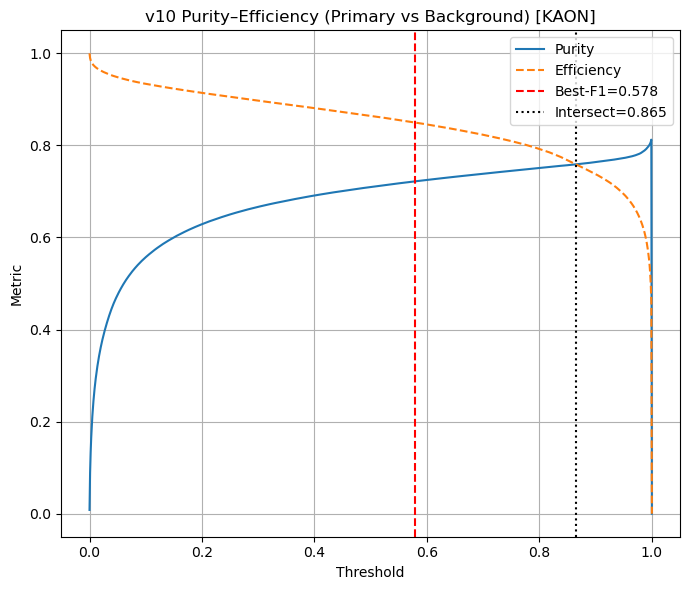


[v10 PION] events=40000
Best-F1 thr=0.575 | Purity=72.76% | Eff=84.78% | F1=0.783
Intersect thr≈0.852 | Purity≈76.34% | Eff≈76.34%


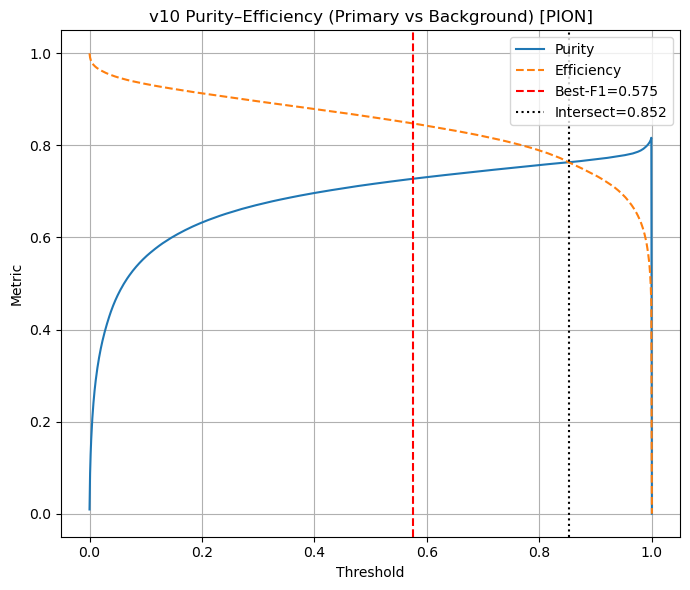


Part 1B: v12 (3-class) Purity–Efficiency per particle


/tmp/ipykernel_221/1262901270.py:291: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
Inference v12: 100%|███


[v12 KAON | PRIMARY] events=60000
Best-F1 thr=0.445 | Purity=81.46% | Eff=83.49% | F1=0.825


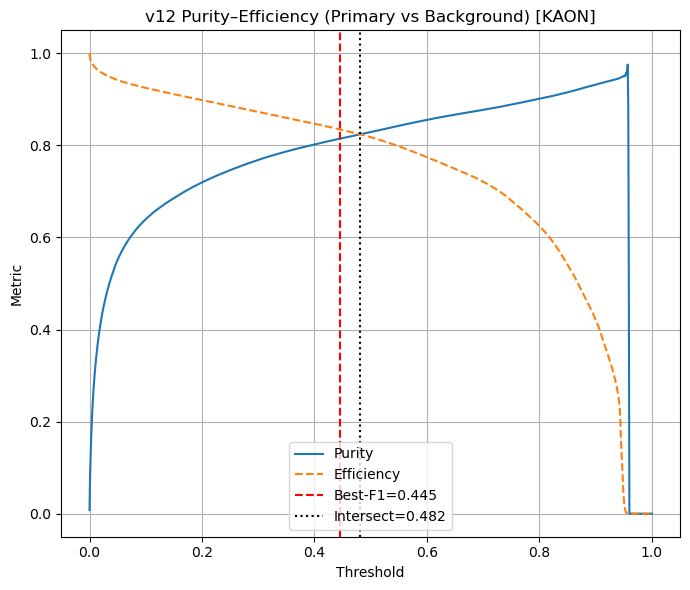


[v12 PION | PRIMARY] events=40000
Best-F1 thr=0.415 | Purity=81.12% | Eff=83.44% | F1=0.823


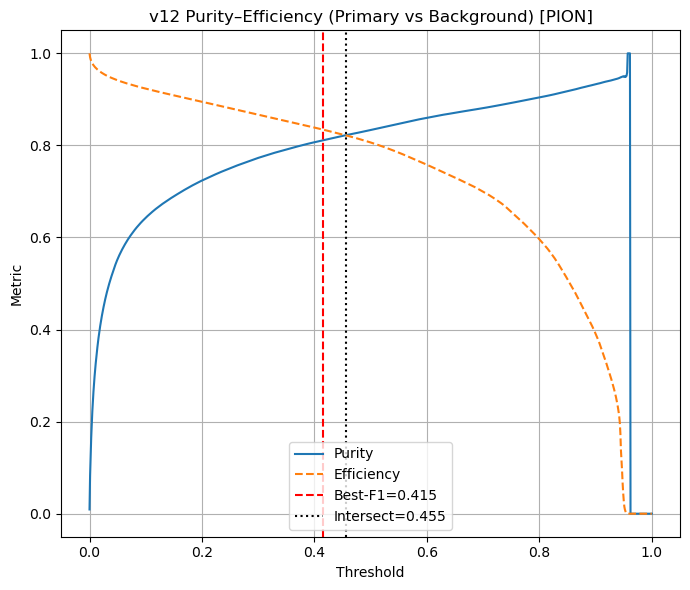

In [ ]:
# ============================================================
# FULL EVAL (INLINE PLOTS)
#
# Part 1:
#   - v10 (2-class) purity–efficiency per particle (Kaon vs Pion)
#   - v12 (3-class) purity–efficiency per particle:
#       * Primary vs Background (binary view, using p_primary)
#       * Secondary vs Background (binary view, using p_secondary)  [only if tag_value=2 exists]
#
# Part 2 (Separation vs momentum from *predicted primary counts*):
#   - v10: counts from thresholded P(primary) of v10
#   - v12: counts from thresholded P(primary) of v12
#   - Two plots for each model:
#       * S per waveform
#       * S scaled to 1 m (sqrt(L) scaling)
#
# Uses:
#   - DATA_NPZ = PionsKaons/batch_0.npz  (pid has 130/211)
#   - Input to model = wf_i
#   - Truth labels from tag_times/tag_values (background = untagged)
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ----------------------------
# CONFIG
# ----------------------------
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ = "PionsKaons/batch_0.npz"

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"

OUTDIR = "results/final_eval_v10_v12_all_inline"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 64
NUM_TIMESTEPS = 20
THRESH_GRID = np.linspace(0, 1, 1001)

PID_KAON = 130
PID_PION = 211

# threshold(s) used to convert P(primary) -> predicted primary-count
COUNT_THRESHOLDS = [0.10, 0.26, 0.40]  # you can edit

# scaling to compare with paper
CELL_LENGTH_M = 0.018   # EDIT if your waveform corresponds to a different length
TARGET_TRACK_M = 1.0

# tag_value meanings (typical): 1=primary, 2=secondary
PRIMARY_TAG_VALUE = 1
SECONDARY_TAG_VALUE = 2

# ----------------------------
# MODEL
# ----------------------------
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B,T,1)
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x); spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)
            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)
        return torch.stack(spk_out, dim=2).mean(dim=2)

# ----------------------------
# HELPERS
# ----------------------------
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("wf_i:", wf_i.shape, wf_i.dtype)
    print("mom:", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print("tag_values unique:", np.unique(tag_values))
    print()
    return wf_i, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    # if looks 1-based, convert
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        tag_times = tag_times - 1
    return tag_times

def build_truth_binary_from_tags(tag_times, tag_values, T, positive_value):
    """
    Returns y_true_pos: (N,T) with 1 where tag_value==positive_value at tag_times; else 0.
    Background is implicitly 0 (including all untagged).
    """
    N, K = tag_times.shape
    y = np.zeros((N, T), dtype=np.uint8)
    valid = (tag_times >= 0) & (tag_times < T)
    is_pos = valid & (tag_values == positive_value)
    rows, cols = np.where(is_pos)
    t = tag_times[rows, cols]
    y[rows, t] = 1
    return y

def infer_probs(model, wf_i, scaler, device, num_classes, label):
    x = scaler.transform(wf_i.reshape(-1,1)).reshape(wf_i.shape[0], wf_i.shape[1], 1)
    x_t = torch.tensor(x, dtype=torch.float32)
    loader = torch.utils.data.DataLoader(x_t, batch_size=BATCH_SIZE, shuffle=False)

    probs_all = []
    model.eval()
    with torch.no_grad():
        for xb in tqdm(loader, desc=label, mininterval=1.0):
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            probs_all.append(probs)
    return np.concatenate(probs_all, axis=0)

def purity_eff_curve(y_true_bin, p_pos, thresholds):
    yt = y_true_bin.reshape(-1).astype(np.uint8)
    pp = p_pos.reshape(-1).astype(np.float32)
    purity = np.zeros_like(thresholds, dtype=np.float64)
    eff    = np.zeros_like(thresholds, dtype=np.float64)

    for i, thr in enumerate(thresholds):
        pred = pp >= thr
        TP = np.sum(pred & (yt == 1))
        FP = np.sum(pred & (yt == 0))
        FN = np.sum((~pred) & (yt == 1))
        purity[i] = TP/(TP+FP) if (TP+FP)>0 else 0.0
        eff[i]    = TP/(TP+FN) if (TP+FN)>0 else 0.0
    return purity, eff

def best_f1(purity, eff, thresholds):
    f1 = 2*purity*eff/(purity+eff+1e-12)
    idx = int(np.nanargmax(f1))
    return float(thresholds[idx]), float(purity[idx]), float(eff[idx]), float(f1[idx])

def intersection_thr(purity, eff, thresholds):
    diff = purity - eff
    s = np.sign(diff)
    idxs = np.where(s[:-1]*s[1:] < 0)[0]
    if len(idxs) == 0:
        return np.nan

    cand = []
    for i in idxs:
        x0, x1 = thresholds[i], thresholds[i+1]
        y0, y1 = diff[i], diff[i+1]
        t = -y0/(y1 - y0 + 1e-12)
        cand.append(x0 + (x1 - x0)*t)
    cand = np.array(cand)

    thr_f1, _, _, _ = best_f1(purity, eff, thresholds)
    return float(cand[np.argmin(np.abs(cand - thr_f1))])

def plot_pe_inline(thresholds, purity, eff, thr_f1, thr_int, title, out_png):
    plt.figure(figsize=(7,6))
    plt.plot(thresholds, purity, label="Purity")
    plt.plot(thresholds, eff, "--", label="Efficiency")
    plt.axvline(thr_f1, color="r", ls="--", label=f"Best-F1={thr_f1:.3f}")
    if np.isfinite(thr_int):
        plt.axvline(thr_int, color="k", ls=":", label=f"Intersect={thr_int:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Metric")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()

def sep_paper(muK, sigK, muPi, sigPi):
    # paper-style: 2|Δμ|/(σK+σπ)
    return 2.0*abs(muK - muPi)/(sigK + sigPi + 1e-12)

# ----------------------------
# MAIN
# ----------------------------
def main():
    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_npz(DATA_NPZ)
    N, T = wf_i.shape

    tag_times = ensure_0_based_tag_times(tag_times, T)

    # truth for Primary and Secondary (binary masks)
    y_true_primary = build_truth_binary_from_tags(tag_times, tag_values, T, PRIMARY_TAG_VALUE)
    y_true_secondary = build_truth_binary_from_tags(tag_times, tag_values, T, SECONDARY_TAG_VALUE)

    frac_primary = float(y_true_primary.mean())
    frac_secondary = float(y_true_secondary.mean())
    print("Overall TRUE primary fraction:", frac_primary)
    print("Overall TRUE secondary fraction:", frac_secondary, "\n")

    has_secondary_truth = (y_true_secondary.sum() > 0)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device, "\n")

    # ============================================================
    # Part 1A: v10 (2-class) Purity–Efficiency per particle
    # ============================================================
    print("==============================")
    print("Part 1A: v10 (2-class) Purity–Efficiency per particle")
    print("==============================")

    v10 = ConvSNN_Deep(num_classes=2).to(device)
    v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
    probs_v10 = infer_probs(v10, wf_i, scaler, device, num_classes=2, label="Inference v10")
    p_primary_v10 = probs_v10[:, :, 1]

    for this_pid, name in [(PID_KAON, "KAON"), (PID_PION, "PION")]:
        m = (pid == this_pid)
        purity, eff = purity_eff_curve(y_true_primary[m], p_primary_v10[m], THRESH_GRID)
        thr_f1, p_f1, e_f1, f1 = best_f1(purity, eff, THRESH_GRID)
        thr_int = intersection_thr(purity, eff, THRESH_GRID)

        print(f"\n[v10 {name}] events={int(m.sum())}")
        print(f"Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")
        if np.isfinite(thr_int):
            idx = int(np.argmin(np.abs(THRESH_GRID - thr_int)))
            print(f"Intersect thr≈{thr_int:.3f} | Purity≈{purity[idx]*100:.2f}% | Eff≈{eff[idx]*100:.2f}%")
        else:
            print("Intersect thr: (no crossing found)")

        out_png = os.path.join(OUTDIR, f"part1_v10_purity_eff_{name.lower()}.png")
        plot_pe_inline(THRESH_GRID, purity, eff, thr_f1, thr_int,
                       f"v10 Purity–Efficiency (Primary vs Background) [{name}]", out_png)

    # ============================================================
    # Part 1B: v12 (3-class) Purity–Efficiency per particle
    #   - Primary vs Background (binary view)
    #   - Secondary vs Background (binary view, only if secondary truth exists)
    # ============================================================
    print("\n==============================")
    print("Part 1B: v12 (3-class) Purity–Efficiency per particle")
    print("==============================")

    v12 = ConvSNN_Deep(num_classes=3).to(device)
    v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
    probs_v12 = infer_probs(v12, wf_i, scaler, device, num_classes=3, label="Inference v12")
    p_primary_v12 = probs_v12[:, :, 1]
    p_secondary_v12 = probs_v12[:, :, 2]

    # Primary curves (v12)
    for this_pid, name in [(PID_KAON, "KAON"), (PID_PION, "PION")]:
        m = (pid == this_pid)
        purity, eff = purity_eff_curve(y_true_primary[m], p_primary_v12[m], THRESH_GRID)
        thr_f1, p_f1, e_f1, f1 = best_f1(purity, eff, THRESH_GRID)
        thr_int = intersection_thr(purity, eff, THRESH_GRID)

        print(f"\n[v12 {name} | PRIMARY] events={int(m.sum())}")
        print(f"Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")

        out_png = os.path.join(OUTDIR, f"part1_v12_primary_purity_eff_{name.lower()}.png")
        plot_pe_inline(THRESH_GRID, purity, eff, thr_f1, thr_int,
                       f"v12 Purity–Efficiency (Primary vs Background) [{name}]", out_png)

    # Secondary curves (v12) if possible
    if has_secondary_truth:
        for this_pid, name in [(PID_KAON, "KAON"), (PID_PION, "PION")]:
            m = (pid == this_pid)
            purity, eff = purity_eff_curve(y_true_secondary[m], p_secondary_v12[m], THRESH_GRID)
            thr_f1, p_f1, e_f1, f1 = best_f1(purity, eff, THRESH_GRID)
            thr_int = intersection_thr(purity, eff, THRESH_GRID)

            print(f"\n[v12 {name} | SECONDARY] events={int(m.sum())}")
            print(f"Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")

            out_png = os.path.join(OUTDIR, f"part1_v12_secondary_purity_eff_{name.lower()}.png")
            plot_pe_inline(THRESH_GRID, purity, eff, thr_f1, thr_int,
                           f"v12 Purity–Efficiency (Secondary vs Background) [{name}]", out_png)
    else:
        print("\nNOTE: No secondary truth tags found (tag_value=2 absent). Skipping secondary purity/efficiency plots.")

    # ============================================================
    # Part 2: Separation vs momentum from predicted PRIMARY COUNT
    #   - for v10 primary-prob AND v12 primary-prob
    #   - two plots each model: per waveform & scaled-to-1m
    # ============================================================
    print("\n==============================")
    print("Part 2: Separation vs momentum from predicted PRIMARY COUNTS (v10 & v12)")
    print("==============================")

    scale_to_1m = np.sqrt(TARGET_TRACK_M / CELL_LENGTH_M)
    print(f"Scaling factor sqrt(1m/Lcell): sqrt({TARGET_TRACK_M}/{CELL_LENGTH_M}) = {scale_to_1m:.3f}\n")

    moms = sorted(np.unique(mom).tolist())

    def compute_sep_curves(p_primary, label):
        moms_used = []
        sep_wave = {thr: [] for thr in COUNT_THRESHOLDS}
        sep_1m   = {thr: [] for thr in COUNT_THRESHOLDS}

        for p in moms:
            mk = (mom == p) & (pid == PID_KAON)
            mpi = (mom == p) & (pid == PID_PION)
            if mk.sum() < 10 or mpi.sum() < 10:
                continue

            moms_used.append(float(p))

            for thr in COUNT_THRESHOLDS:
                cnt = (p_primary >= thr).sum(axis=1)  # per waveform
                a = cnt[mk].astype(np.float64)
                b = cnt[mpi].astype(np.float64)
                muK, sigK = a.mean(), a.std(ddof=1)
                muPi, sigPi = b.mean(), b.std(ddof=1)
                S = sep_paper(muK, sigK, muPi, sigPi)
                sep_wave[thr].append(float(S))
                sep_1m[thr].append(float(S * scale_to_1m))

        # plot per waveform
        plt.figure(figsize=(7,5))
        for thr in COUNT_THRESHOLDS:
            plt.plot(moms_used, sep_wave[thr], marker="o", label=f"thr={thr:.2f}")
        plt.xlabel("Momentum (GeV/c)")
        plt.ylabel("Separation S (per waveform)")
        plt.title(f"{label}: K/π separation vs momentum (per waveform)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        out_png = os.path.join(OUTDIR, f"part2_{label.lower()}_sep_per_waveform.png")
        plt.savefig(out_png, dpi=150)
        plt.show()
        plt.close()
        print("Saved:", out_png)

        # plot scaled to 1m
        plt.figure(figsize=(7,5))
        for thr in COUNT_THRESHOLDS:
            plt.plot(moms_used, sep_1m[thr], marker="o", label=f"thr={thr:.2f}")
        plt.xlabel("Momentum (GeV/c)")
        plt.ylabel("Separation S (scaled to 1 m)")
        plt.title(f"{label}: K/π separation vs momentum (scaled to 1 m)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        out_png = os.path.join(OUTDIR, f"part2_{label.lower()}_sep_scaled_1m.png")
        plt.savefig(out_png, dpi=150)
        plt.show()
        plt.close()
        print("Saved:", out_png)

        return moms_used, sep_wave, sep_1m

    print("---- v10 separation from predicted PRIMARY counts ----")
    compute_sep_curves(p_primary_v10, label="v10")

    print("\n---- v12 separation from predicted PRIMARY counts ----")
    compute_sep_curves(p_primary_v12, label="v12")

    print("\n✅ Done. All outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
mom: (100000,) range: 7.5 20.0
pid unique: [130 211] counts: [60000 40000]
tag_values unique: [0 1 2]

Overall TRUE primary fraction: 0.008625273333333334
Overall TRUE secondary fraction: 0.0028066333333333334 

Device: cuda 

Part 1A: v10 (2-class) Purity–Efficiency per particle


/tmp/ipykernel_250/1262901270.py:259: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
Inference v10: 100%|███


[v10 KAON] events=60000
Best-F1 thr=0.578 | Purity=72.19% | Eff=84.99% | F1=0.781
Intersect thr≈0.865 | Purity≈75.90% | Eff≈75.87%


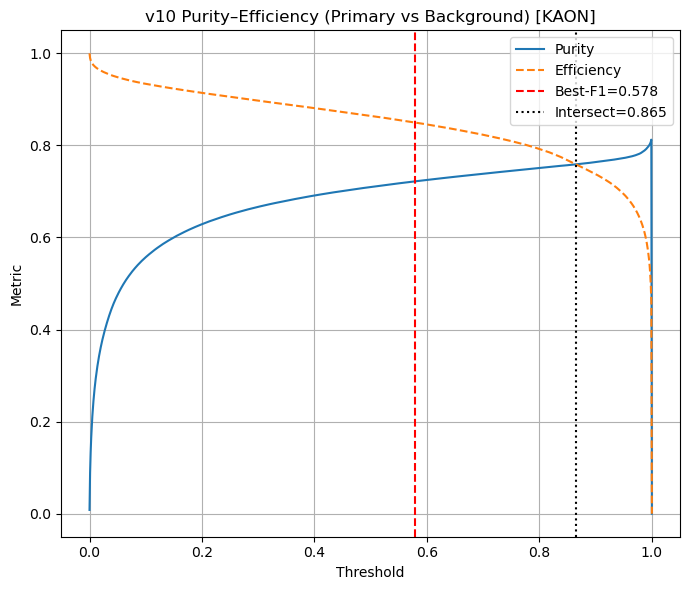


[v10 PION] events=40000
Best-F1 thr=0.575 | Purity=72.76% | Eff=84.78% | F1=0.783
Intersect thr≈0.852 | Purity≈76.34% | Eff≈76.34%


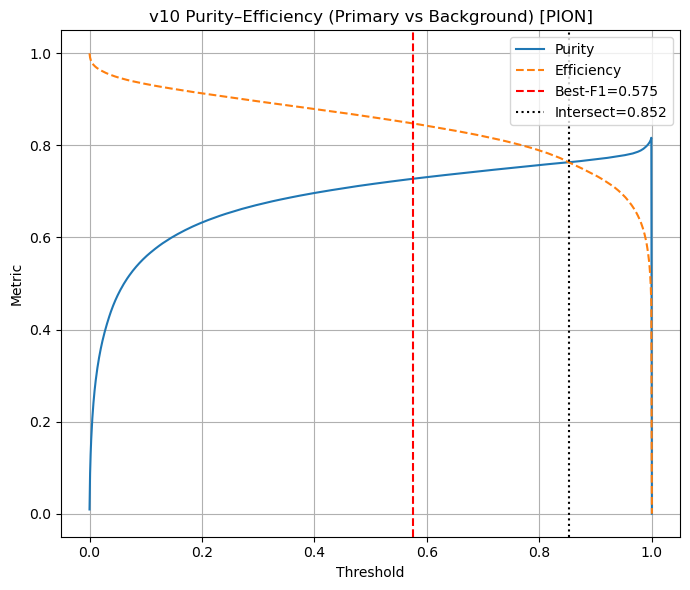


Part 1B: v12 (3-class) Purity–Efficiency per particle


/tmp/ipykernel_250/1262901270.py:291: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
Inference v12: 100%|███


[v12 KAON | PRIMARY] events=60000
Best-F1 thr=0.445 | Purity=81.46% | Eff=83.49% | F1=0.825


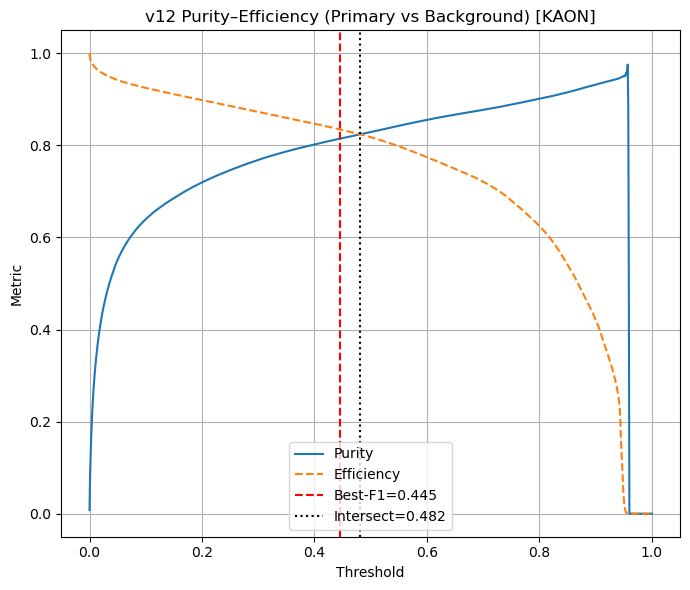


[v12 PION | PRIMARY] events=40000
Best-F1 thr=0.415 | Purity=81.12% | Eff=83.44% | F1=0.823


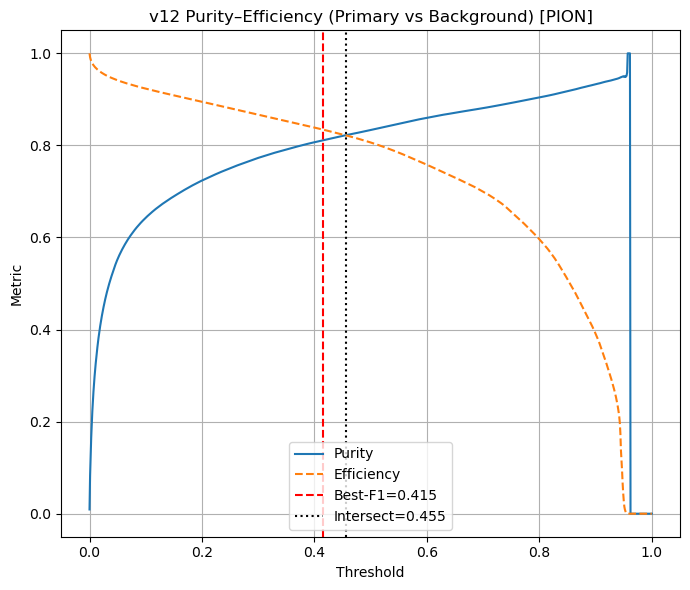


[v12 KAON | SECONDARY] events=60000
Best-F1 thr=0.301 | Purity=57.74% | Eff=56.60% | F1=0.572


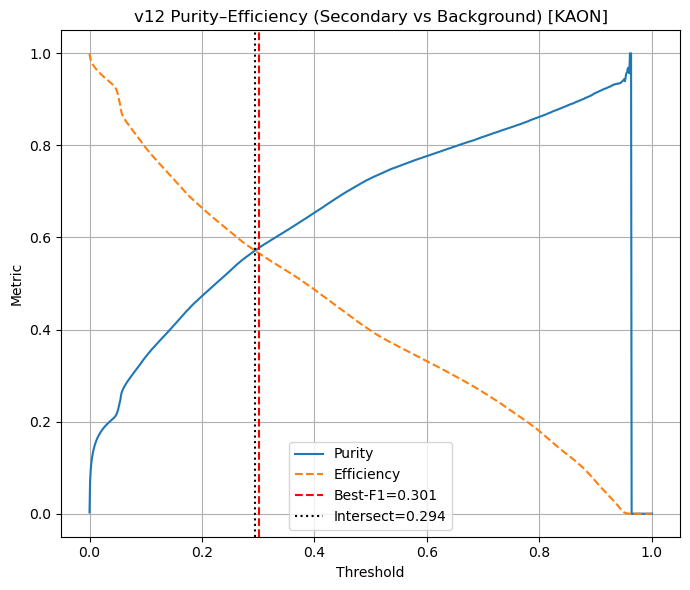


[v12 PION | SECONDARY] events=40000
Best-F1 thr=0.317 | Purity=55.31% | Eff=55.88% | F1=0.556


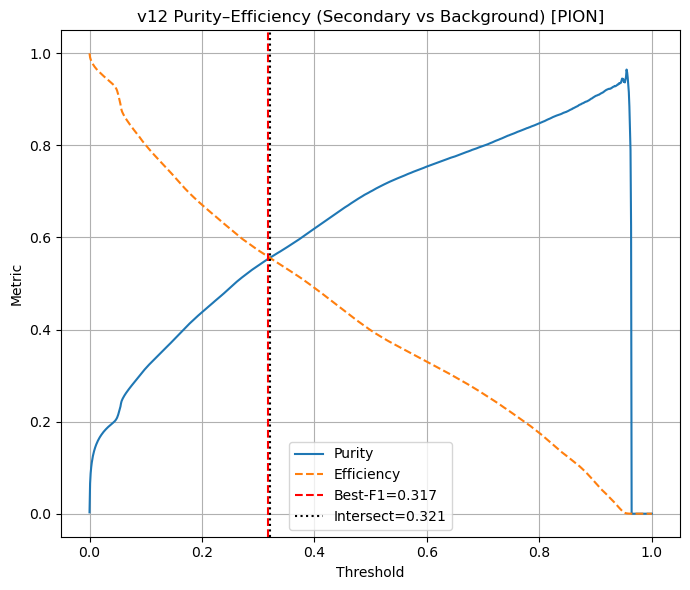


Part 2: Separation vs momentum from predicted PRIMARY COUNTS (v10 & v12)
Scaling factor sqrt(1m/Lcell): sqrt(1.0/0.018) = 7.454

---- v10 separation from predicted PRIMARY counts ----


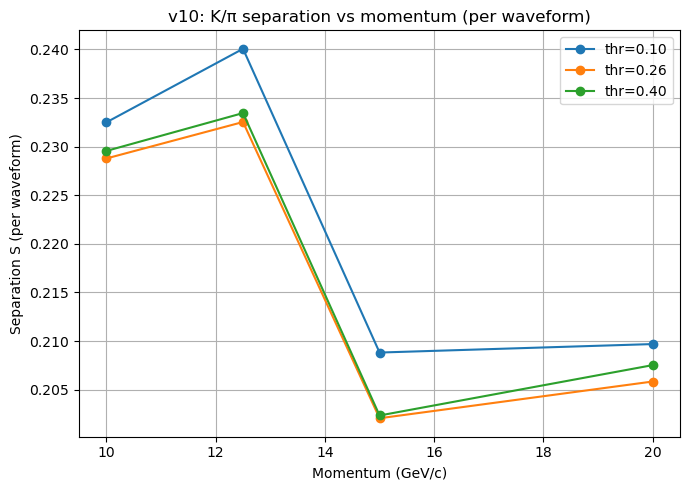

Saved: results/final_eval_v10_v12_all_inline/part2_v10_sep_per_waveform.png


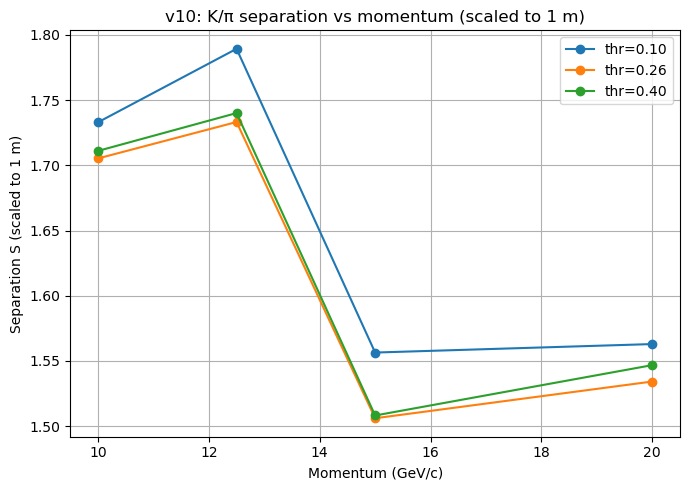

Saved: results/final_eval_v10_v12_all_inline/part2_v10_sep_scaled_1m.png

---- v12 separation from predicted PRIMARY counts ----


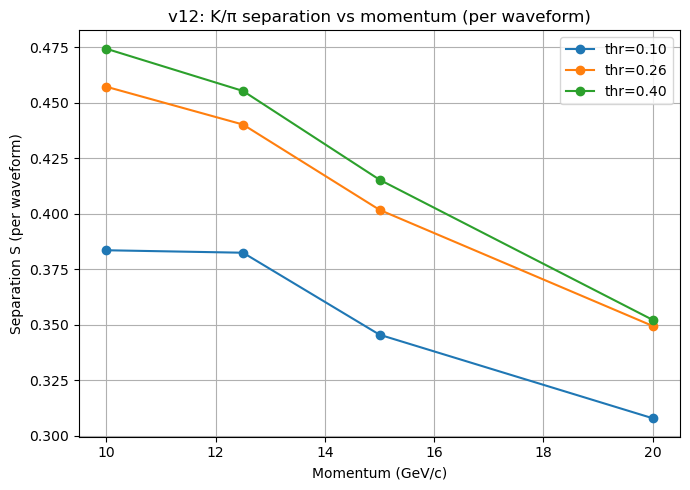

Saved: results/final_eval_v10_v12_all_inline/part2_v12_sep_per_waveform.png


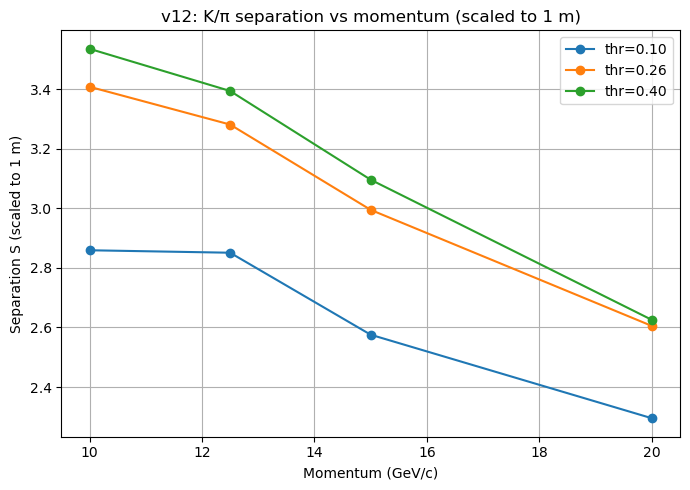

Saved: results/final_eval_v10_v12_all_inline/part2_v12_sep_scaled_1m.png

✅ Done. All outputs in: results/final_eval_v10_v12_all_inline


In [3]:
# ============================================================
# FULL EVAL (INLINE PLOTS)
#
# Part 1:
#   - v10 (2-class) purity–efficiency per particle (Kaon vs Pion)
#   - v12 (3-class) purity–efficiency per particle:
#       * Primary vs Background (binary view, using p_primary)
#       * Secondary vs Background (binary view, using p_secondary)  [only if tag_value=2 exists]
#
# Part 2 (Separation vs momentum from *predicted primary counts*):
#   - v10: counts from thresholded P(primary) of v10
#   - v12: counts from thresholded P(primary) of v12
#   - Two plots for each model:
#       * S per waveform
#       * S scaled to 1 m (sqrt(L) scaling)
#
# Uses:
#   - DATA_NPZ = PionsKaons/batch_0.npz  (pid has 130/211)
#   - Input to model = wf_i
#   - Truth labels from tag_times/tag_values (background = untagged)
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ----------------------------
# CONFIG
# ----------------------------
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ = "PionsKaons/batch_0.npz"

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"

OUTDIR = "results/final_eval_v10_v12_all_inline"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 64
NUM_TIMESTEPS = 20
THRESH_GRID = np.linspace(0, 1, 1001)

PID_KAON = 130
PID_PION = 211

# threshold(s) used to convert P(primary) -> predicted primary-count
COUNT_THRESHOLDS = [0.10, 0.26, 0.40]  # you can edit

# scaling to compare with paper
CELL_LENGTH_M = 0.018   # EDIT if your waveform corresponds to a different length
TARGET_TRACK_M = 1.0

# tag_value meanings (typical): 1=primary, 2=secondary
PRIMARY_TAG_VALUE = 1
SECONDARY_TAG_VALUE = 2

# ----------------------------
# MODEL
# ----------------------------
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B,T,1)
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x); spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)
            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)
        return torch.stack(spk_out, dim=2).mean(dim=2)

# ----------------------------
# HELPERS
# ----------------------------
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("wf_i:", wf_i.shape, wf_i.dtype)
    print("mom:", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print("tag_values unique:", np.unique(tag_values))
    print()
    return wf_i, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    # if looks 1-based, convert
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        tag_times = tag_times - 1
    return tag_times

def build_truth_binary_from_tags(tag_times, tag_values, T, positive_value):
    """
    Returns y_true_pos: (N,T) with 1 where tag_value==positive_value at tag_times; else 0.
    Background is implicitly 0 (including all untagged).
    """
    N, K = tag_times.shape
    y = np.zeros((N, T), dtype=np.uint8)
    valid = (tag_times >= 0) & (tag_times < T)
    is_pos = valid & (tag_values == positive_value)
    rows, cols = np.where(is_pos)
    t = tag_times[rows, cols]
    y[rows, t] = 1
    return y

def infer_probs(model, wf_i, scaler, device, num_classes, label):
    x = scaler.transform(wf_i.reshape(-1,1)).reshape(wf_i.shape[0], wf_i.shape[1], 1)
    x_t = torch.tensor(x, dtype=torch.float32)
    loader = torch.utils.data.DataLoader(x_t, batch_size=BATCH_SIZE, shuffle=False)

    probs_all = []
    model.eval()
    with torch.no_grad():
        for xb in tqdm(loader, desc=label, mininterval=1.0):
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            probs_all.append(probs)
    return np.concatenate(probs_all, axis=0)

def purity_eff_curve(y_true_bin, p_pos, thresholds):
    yt = y_true_bin.reshape(-1).astype(np.uint8)
    pp = p_pos.reshape(-1).astype(np.float32)
    purity = np.zeros_like(thresholds, dtype=np.float64)
    eff    = np.zeros_like(thresholds, dtype=np.float64)

    for i, thr in enumerate(thresholds):
        pred = pp >= thr
        TP = np.sum(pred & (yt == 1))
        FP = np.sum(pred & (yt == 0))
        FN = np.sum((~pred) & (yt == 1))
        purity[i] = TP/(TP+FP) if (TP+FP)>0 else 0.0
        eff[i]    = TP/(TP+FN) if (TP+FN)>0 else 0.0
    return purity, eff

def best_f1(purity, eff, thresholds):
    f1 = 2*purity*eff/(purity+eff+1e-12)
    idx = int(np.nanargmax(f1))
    return float(thresholds[idx]), float(purity[idx]), float(eff[idx]), float(f1[idx])

def intersection_thr(purity, eff, thresholds):
    diff = purity - eff
    s = np.sign(diff)
    idxs = np.where(s[:-1]*s[1:] < 0)[0]
    if len(idxs) == 0:
        return np.nan

    cand = []
    for i in idxs:
        x0, x1 = thresholds[i], thresholds[i+1]
        y0, y1 = diff[i], diff[i+1]
        t = -y0/(y1 - y0 + 1e-12)
        cand.append(x0 + (x1 - x0)*t)
    cand = np.array(cand)

    thr_f1, _, _, _ = best_f1(purity, eff, thresholds)
    return float(cand[np.argmin(np.abs(cand - thr_f1))])

def plot_pe_inline(thresholds, purity, eff, thr_f1, thr_int, title, out_png):
    plt.figure(figsize=(7,6))
    plt.plot(thresholds, purity, label="Purity")
    plt.plot(thresholds, eff, "--", label="Efficiency")
    plt.axvline(thr_f1, color="r", ls="--", label=f"Best-F1={thr_f1:.3f}")
    if np.isfinite(thr_int):
        plt.axvline(thr_int, color="k", ls=":", label=f"Intersect={thr_int:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Metric")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()

def sep_paper(muK, sigK, muPi, sigPi):
    # paper-style: 2|Δμ|/(σK+σπ)
    return 2.0*abs(muK - muPi)/(sigK + sigPi + 1e-12)

# ----------------------------
# MAIN
# ----------------------------
def main():
    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_npz(DATA_NPZ)
    N, T = wf_i.shape

    tag_times = ensure_0_based_tag_times(tag_times, T)

    # truth for Primary and Secondary (binary masks)
    y_true_primary = build_truth_binary_from_tags(tag_times, tag_values, T, PRIMARY_TAG_VALUE)
    y_true_secondary = build_truth_binary_from_tags(tag_times, tag_values, T, SECONDARY_TAG_VALUE)

    frac_primary = float(y_true_primary.mean())
    frac_secondary = float(y_true_secondary.mean())
    print("Overall TRUE primary fraction:", frac_primary)
    print("Overall TRUE secondary fraction:", frac_secondary, "\n")

    has_secondary_truth = (y_true_secondary.sum() > 0)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device, "\n")

    # ============================================================
    # Part 1A: v10 (2-class) Purity–Efficiency per particle
    # ============================================================
    print("==============================")
    print("Part 1A: v10 (2-class) Purity–Efficiency per particle")
    print("==============================")

    v10 = ConvSNN_Deep(num_classes=2).to(device)
    v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
    probs_v10 = infer_probs(v10, wf_i, scaler, device, num_classes=2, label="Inference v10")
    p_primary_v10 = probs_v10[:, :, 1]

    for this_pid, name in [(PID_KAON, "KAON"), (PID_PION, "PION")]:
        m = (pid == this_pid)
        purity, eff = purity_eff_curve(y_true_primary[m], p_primary_v10[m], THRESH_GRID)
        thr_f1, p_f1, e_f1, f1 = best_f1(purity, eff, THRESH_GRID)
        thr_int = intersection_thr(purity, eff, THRESH_GRID)

        print(f"\n[v10 {name}] events={int(m.sum())}")
        print(f"Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")
        if np.isfinite(thr_int):
            idx = int(np.argmin(np.abs(THRESH_GRID - thr_int)))
            print(f"Intersect thr≈{thr_int:.3f} | Purity≈{purity[idx]*100:.2f}% | Eff≈{eff[idx]*100:.2f}%")
        else:
            print("Intersect thr: (no crossing found)")

        out_png = os.path.join(OUTDIR, f"part1_v10_purity_eff_{name.lower()}.png")
        plot_pe_inline(THRESH_GRID, purity, eff, thr_f1, thr_int,
                       f"v10 Purity–Efficiency (Primary vs Background) [{name}]", out_png)

    # ============================================================
    # Part 1B: v12 (3-class) Purity–Efficiency per particle
    #   - Primary vs Background (binary view)
    #   - Secondary vs Background (binary view, only if secondary truth exists)
    # ============================================================
    print("\n==============================")
    print("Part 1B: v12 (3-class) Purity–Efficiency per particle")
    print("==============================")

    v12 = ConvSNN_Deep(num_classes=3).to(device)
    v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
    probs_v12 = infer_probs(v12, wf_i, scaler, device, num_classes=3, label="Inference v12")
    p_primary_v12 = probs_v12[:, :, 1]
    p_secondary_v12 = probs_v12[:, :, 2]

    # Primary curves (v12)
    for this_pid, name in [(PID_KAON, "KAON"), (PID_PION, "PION")]:
        m = (pid == this_pid)
        purity, eff = purity_eff_curve(y_true_primary[m], p_primary_v12[m], THRESH_GRID)
        thr_f1, p_f1, e_f1, f1 = best_f1(purity, eff, THRESH_GRID)
        thr_int = intersection_thr(purity, eff, THRESH_GRID)

        print(f"\n[v12 {name} | PRIMARY] events={int(m.sum())}")
        print(f"Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")

        out_png = os.path.join(OUTDIR, f"part1_v12_primary_purity_eff_{name.lower()}.png")
        plot_pe_inline(THRESH_GRID, purity, eff, thr_f1, thr_int,
                       f"v12 Purity–Efficiency (Primary vs Background) [{name}]", out_png)

    # Secondary curves (v12) if possible
    if has_secondary_truth:
        for this_pid, name in [(PID_KAON, "KAON"), (PID_PION, "PION")]:
            m = (pid == this_pid)
            purity, eff = purity_eff_curve(y_true_secondary[m], p_secondary_v12[m], THRESH_GRID)
            thr_f1, p_f1, e_f1, f1 = best_f1(purity, eff, THRESH_GRID)
            thr_int = intersection_thr(purity, eff, THRESH_GRID)

            print(f"\n[v12 {name} | SECONDARY] events={int(m.sum())}")
            print(f"Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")

            out_png = os.path.join(OUTDIR, f"part1_v12_secondary_purity_eff_{name.lower()}.png")
            plot_pe_inline(THRESH_GRID, purity, eff, thr_f1, thr_int,
                           f"v12 Purity–Efficiency (Secondary vs Background) [{name}]", out_png)
    else:
        print("\nNOTE: No secondary truth tags found (tag_value=2 absent). Skipping secondary purity/efficiency plots.")

    # ============================================================
    # Part 2: Separation vs momentum from predicted PRIMARY COUNT
    #   - for v10 primary-prob AND v12 primary-prob
    #   - two plots each model: per waveform & scaled-to-1m
    # ============================================================
    print("\n==============================")
    print("Part 2: Separation vs momentum from predicted PRIMARY COUNTS (v10 & v12)")
    print("==============================")

    scale_to_1m = np.sqrt(TARGET_TRACK_M / CELL_LENGTH_M)
    print(f"Scaling factor sqrt(1m/Lcell): sqrt({TARGET_TRACK_M}/{CELL_LENGTH_M}) = {scale_to_1m:.3f}\n")

    moms = sorted(np.unique(mom).tolist())

    def compute_sep_curves(p_primary, label):
        moms_used = []
        sep_wave = {thr: [] for thr in COUNT_THRESHOLDS}
        sep_1m   = {thr: [] for thr in COUNT_THRESHOLDS}

        for p in moms:
            mk = (mom == p) & (pid == PID_KAON)
            mpi = (mom == p) & (pid == PID_PION)
            if mk.sum() < 10 or mpi.sum() < 10:
                continue

            moms_used.append(float(p))

            for thr in COUNT_THRESHOLDS:
                cnt = (p_primary >= thr).sum(axis=1)  # per waveform
                a = cnt[mk].astype(np.float64)
                b = cnt[mpi].astype(np.float64)
                muK, sigK = a.mean(), a.std(ddof=1)
                muPi, sigPi = b.mean(), b.std(ddof=1)
                S = sep_paper(muK, sigK, muPi, sigPi)
                sep_wave[thr].append(float(S))
                sep_1m[thr].append(float(S * scale_to_1m))

        # plot per waveform
        plt.figure(figsize=(7,5))
        for thr in COUNT_THRESHOLDS:
            plt.plot(moms_used, sep_wave[thr], marker="o", label=f"thr={thr:.2f}")
        plt.xlabel("Momentum (GeV/c)")
        plt.ylabel("Separation S (per waveform)")
        plt.title(f"{label}: K/π separation vs momentum (per waveform)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        out_png = os.path.join(OUTDIR, f"part2_{label.lower()}_sep_per_waveform.png")
        plt.savefig(out_png, dpi=150)
        plt.show()
        plt.close()
        print("Saved:", out_png)

        # plot scaled to 1m
        plt.figure(figsize=(7,5))
        for thr in COUNT_THRESHOLDS:
            plt.plot(moms_used, sep_1m[thr], marker="o", label=f"thr={thr:.2f}")
        plt.xlabel("Momentum (GeV/c)")
        plt.ylabel("Separation S (scaled to 1 m)")
        plt.title(f"{label}: K/π separation vs momentum (scaled to 1 m)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        out_png = os.path.join(OUTDIR, f"part2_{label.lower()}_sep_scaled_1m.png")
        plt.savefig(out_png, dpi=150)
        plt.show()
        plt.close()
        print("Saved:", out_png)

        return moms_used, sep_wave, sep_1m

    print("---- v10 separation from predicted PRIMARY counts ----")
    compute_sep_curves(p_primary_v10, label="v10")

    print("\n---- v12 separation from predicted PRIMARY counts ----")
    compute_sep_curves(p_primary_v12, label="v12")

    print("\n✅ Done. All outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
mom: (100000,) range: 7.5 20.0
pid unique: [130 211] counts: [60000 40000]
tag_values unique: [0 1 2]

Overall TRUE primary fraction: 0.008625273333333334
Overall TRUE secondary fraction: 0.0028066333333333334

Device: cuda 

Part 1: Purity–Efficiency curves (v10 + v12)


/tmp/ipykernel_250/3684544062.py:311: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
Inference v10: 100%|███

[v10 KAON] Best-F1 thr=0.578 | Purity=72.19% | Eff=84.99% | F1=0.781
           Intersect thr≈0.865 | Purity≈75.90% | Eff≈75.87%


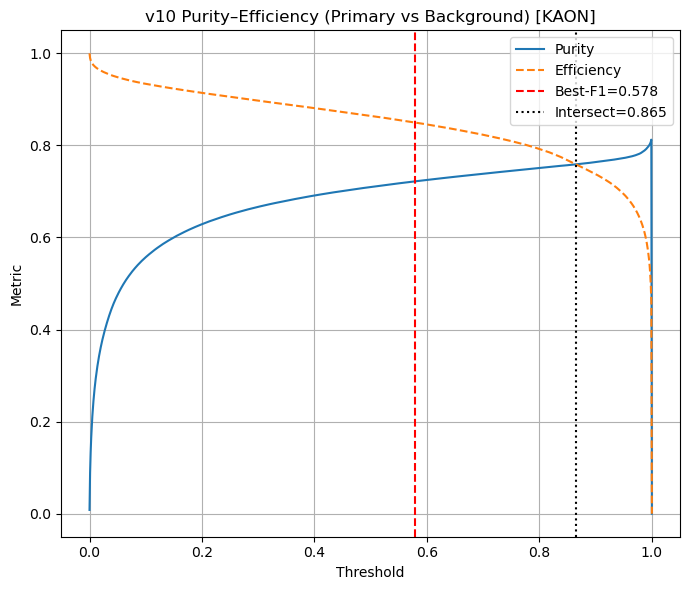

[v10 PION] Best-F1 thr=0.575 | Purity=72.76% | Eff=84.78% | F1=0.783
           Intersect thr≈0.852 | Purity≈76.34% | Eff≈76.34%


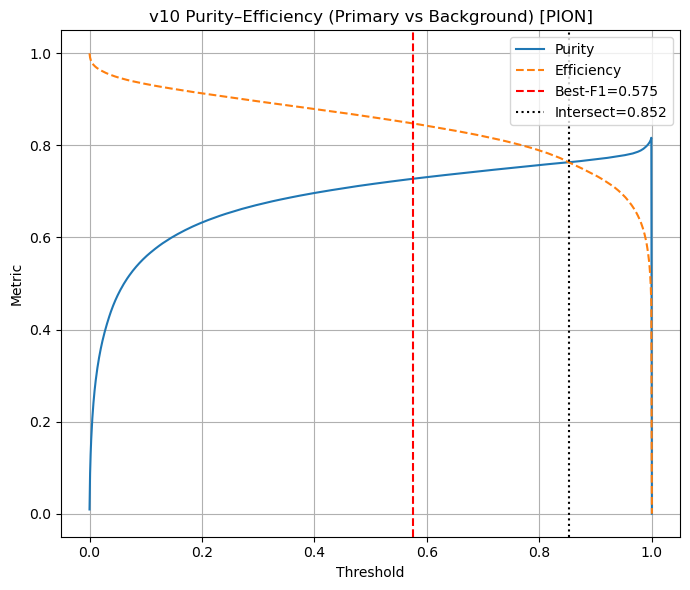

/tmp/ipykernel_250/3684544062.py:333: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
Inference v12: 100%|███

[v12 KAON PRIMARY] Best-F1 thr=0.445 | Purity=81.46% | Eff=83.49% | F1=0.825


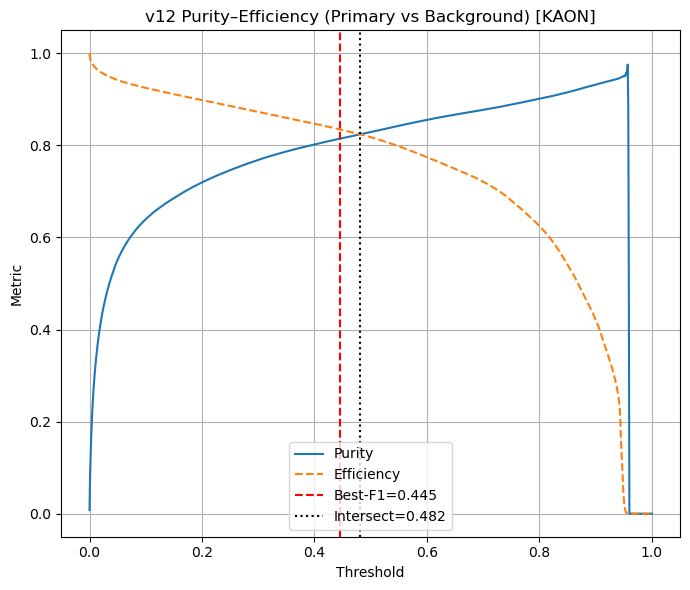

[v12 PION PRIMARY] Best-F1 thr=0.415 | Purity=81.12% | Eff=83.44% | F1=0.823


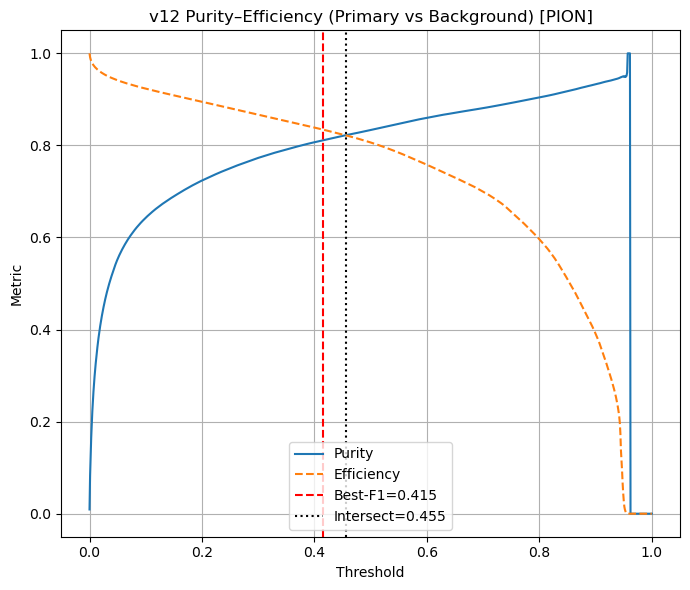

[v12 KAON SECONDARY] Best-F1 thr=0.301 | Purity=57.74% | Eff=56.60% | F1=0.572


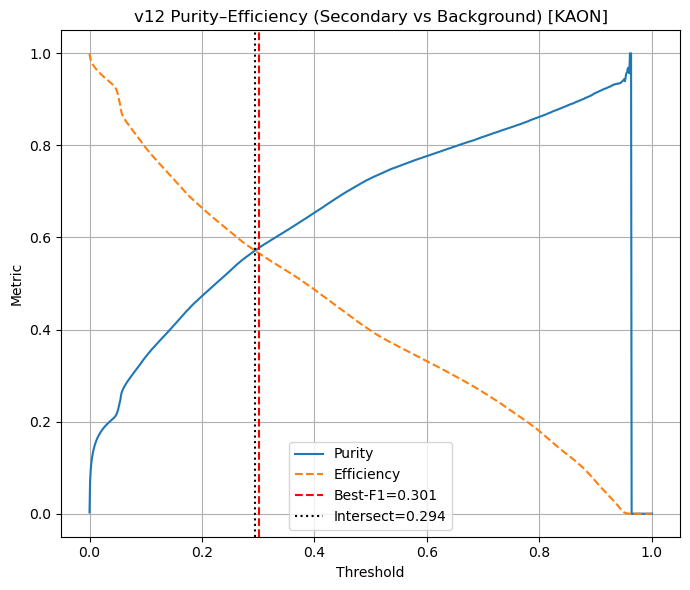

[v12 PION SECONDARY] Best-F1 thr=0.317 | Purity=55.31% | Eff=55.88% | F1=0.556


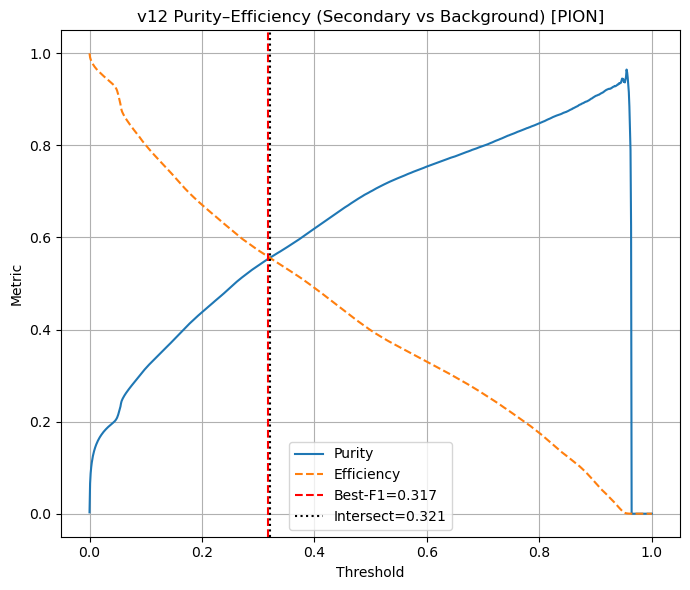


Part 2: Primary-count density by momentum + separation vs momentum (v10 + v12)
Scaling: CELL_LENGTH_M=0.018 → sqrt(1m/Lcell) = 7.454

mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)


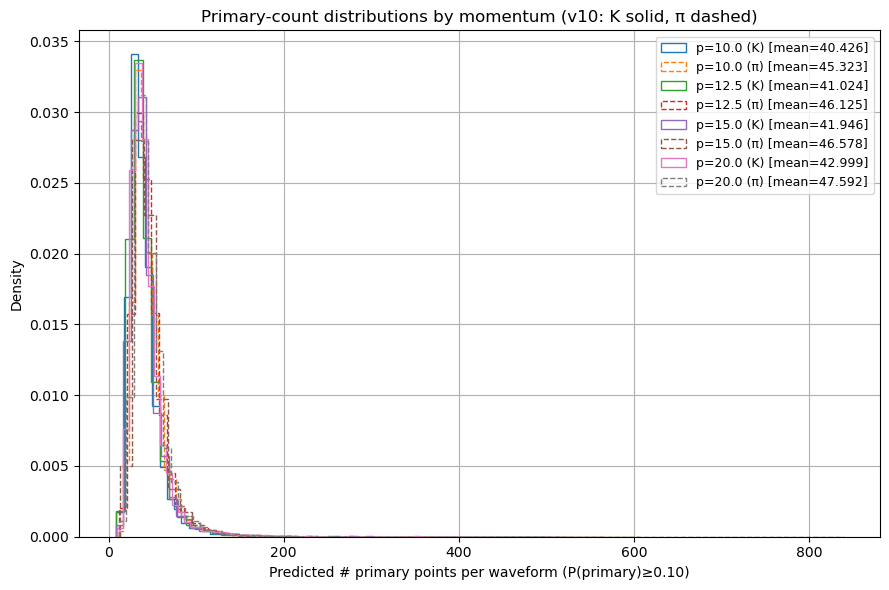

Saved: results/final_eval_v10_v12_with_density/part2_v10_primarycount_density_by_mom_thr0.10.png


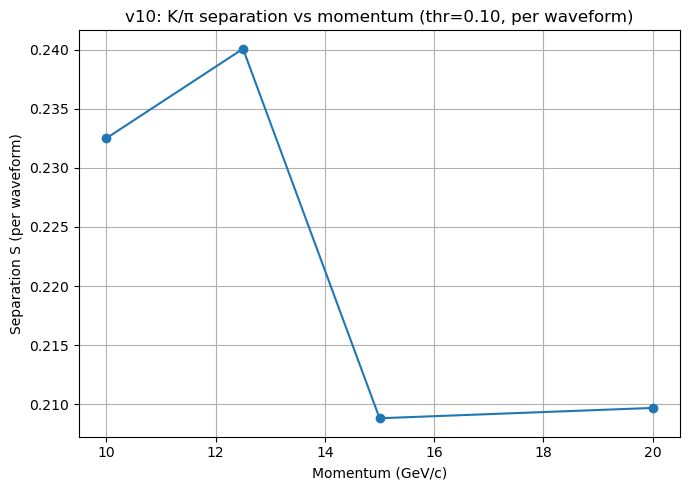

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v10_thr0.10_per_waveform.png


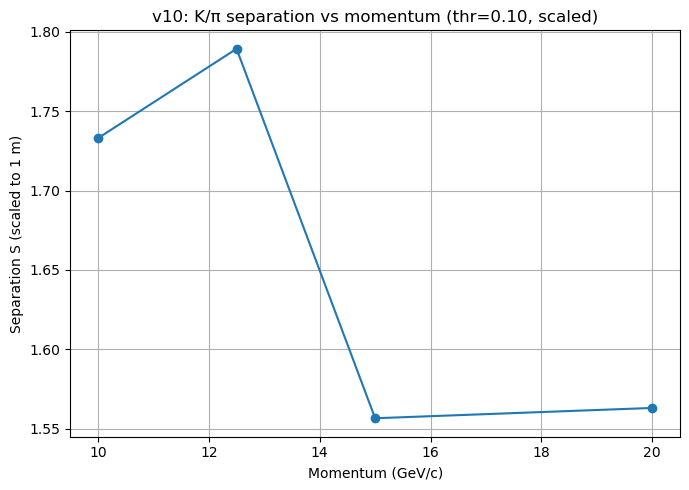

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v10_thr0.10_scaled_1m.png
mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)


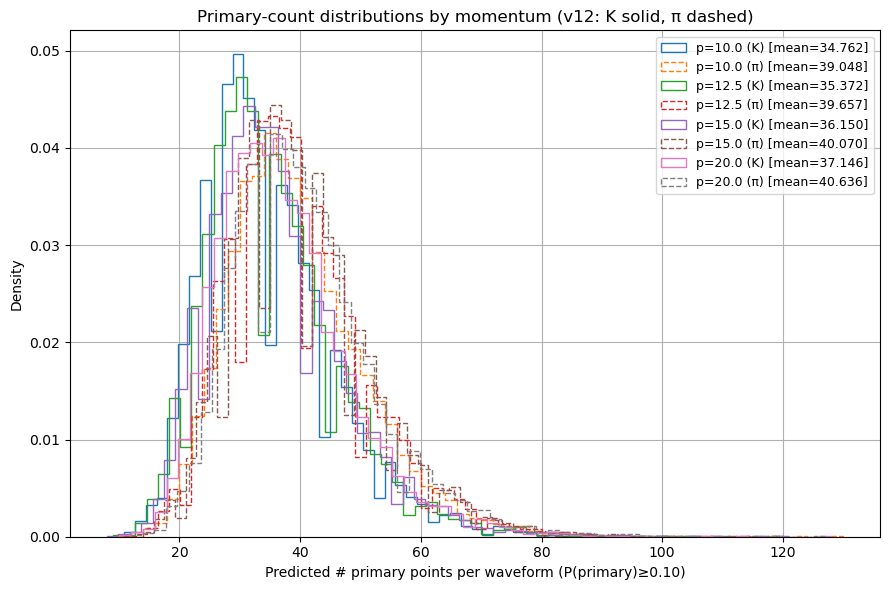

Saved: results/final_eval_v10_v12_with_density/part2_v12_primarycount_density_by_mom_thr0.10.png


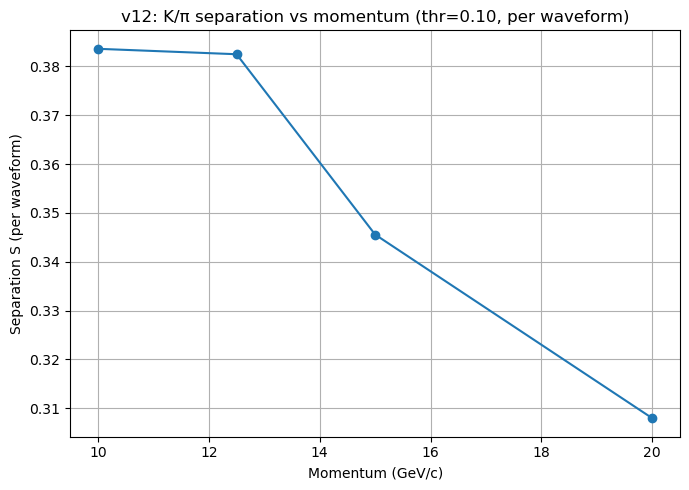

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v12_thr0.10_per_waveform.png


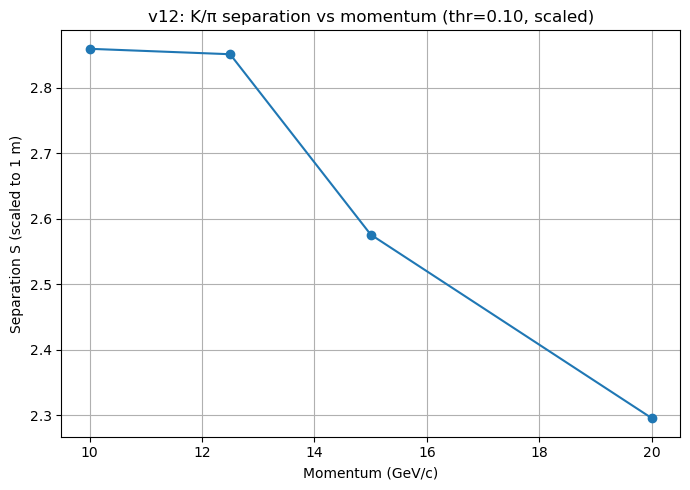

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v12_thr0.10_scaled_1m.png
mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)


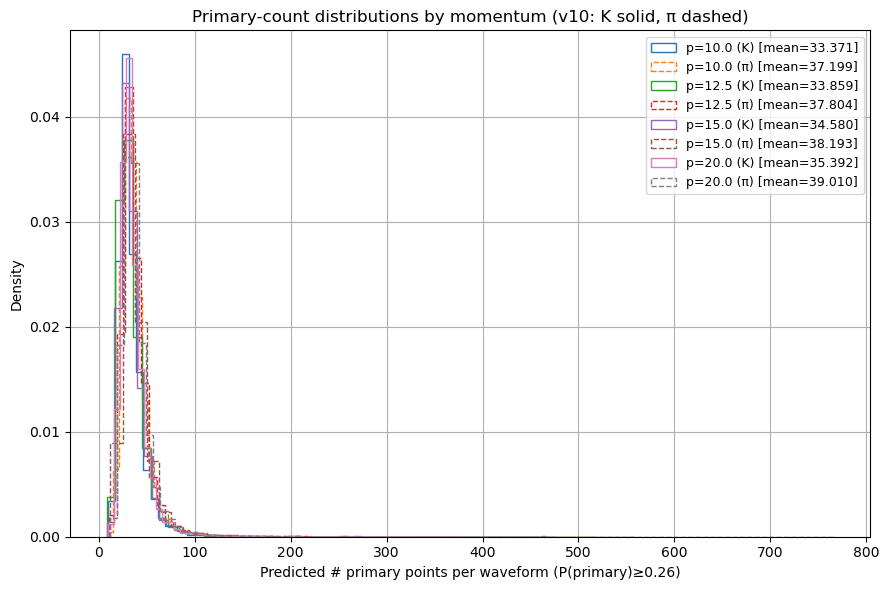

Saved: results/final_eval_v10_v12_with_density/part2_v10_primarycount_density_by_mom_thr0.26.png


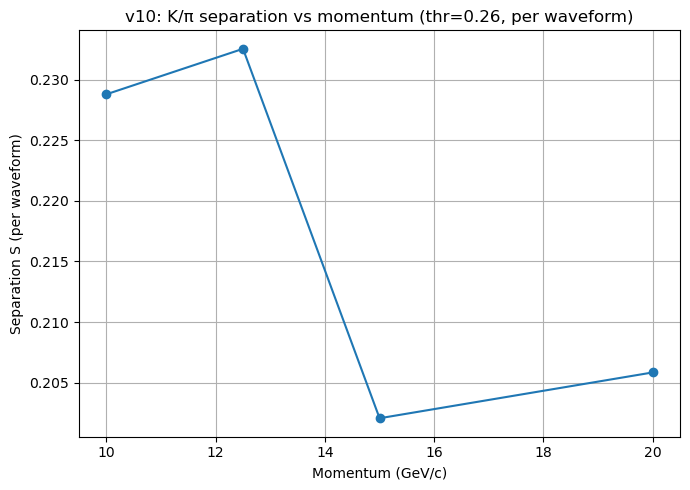

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v10_thr0.26_per_waveform.png


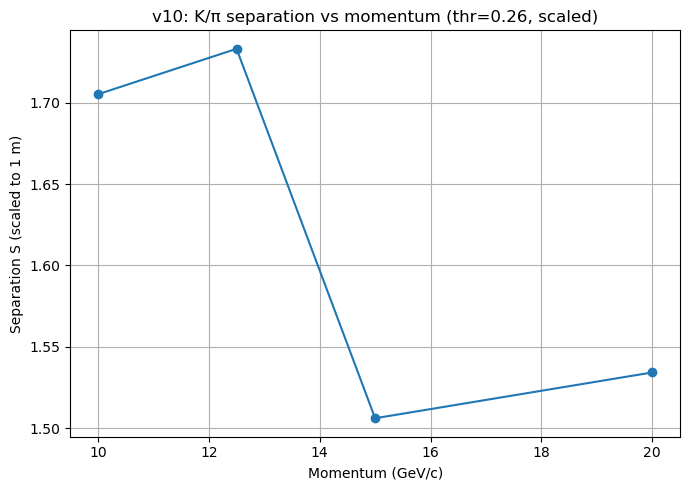

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v10_thr0.26_scaled_1m.png
mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)


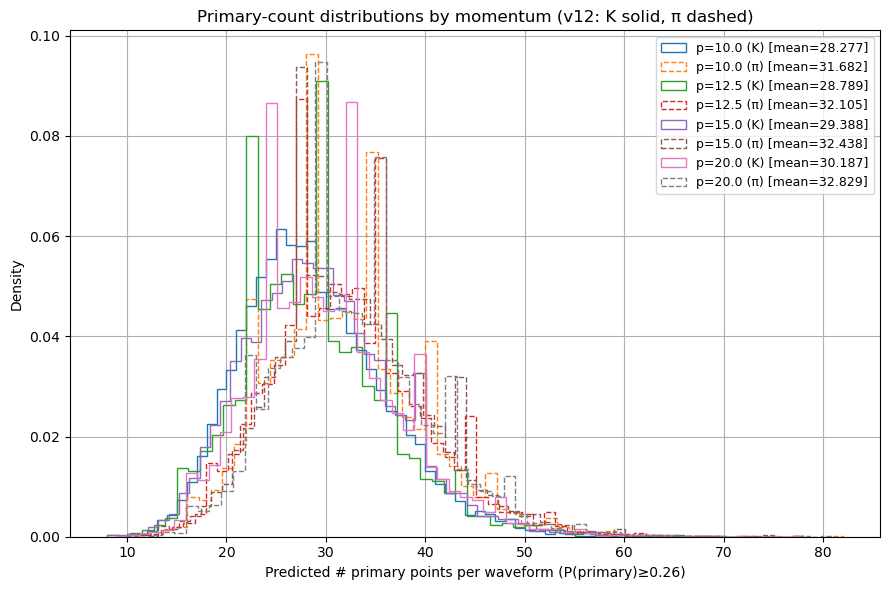

Saved: results/final_eval_v10_v12_with_density/part2_v12_primarycount_density_by_mom_thr0.26.png


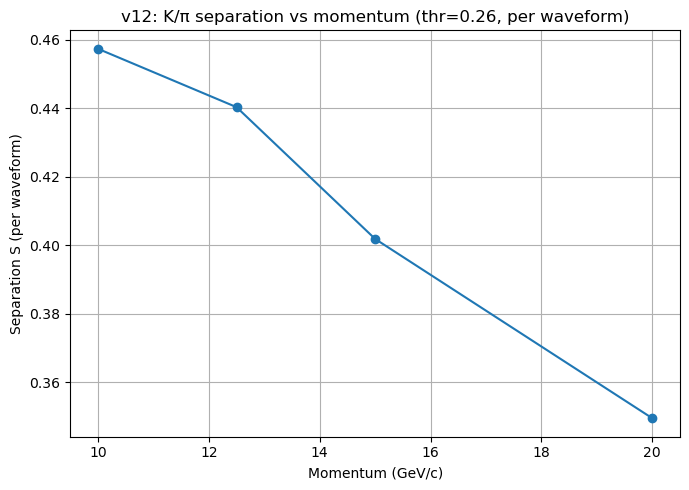

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v12_thr0.26_per_waveform.png


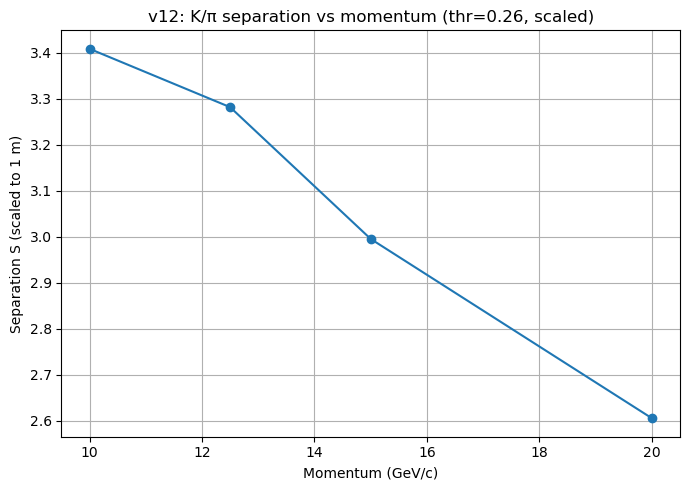

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v12_thr0.26_scaled_1m.png
mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)


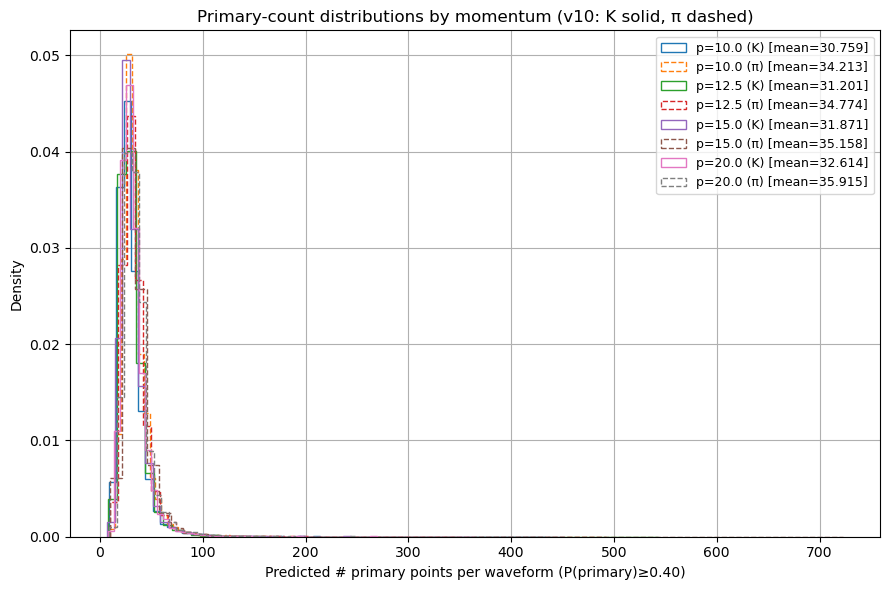

Saved: results/final_eval_v10_v12_with_density/part2_v10_primarycount_density_by_mom_thr0.40.png


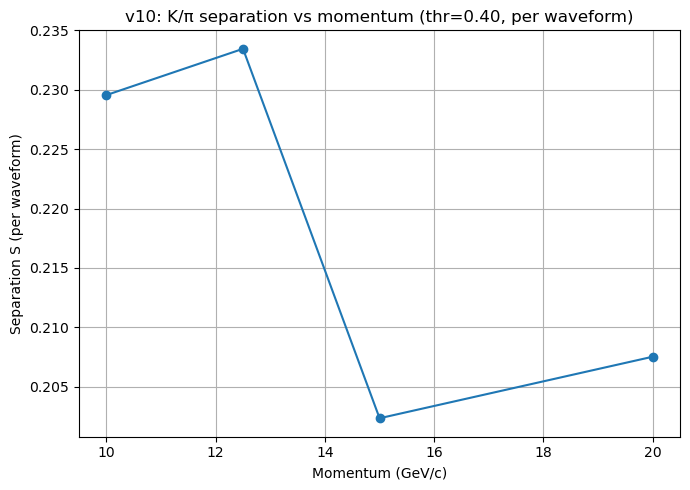

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v10_thr0.40_per_waveform.png


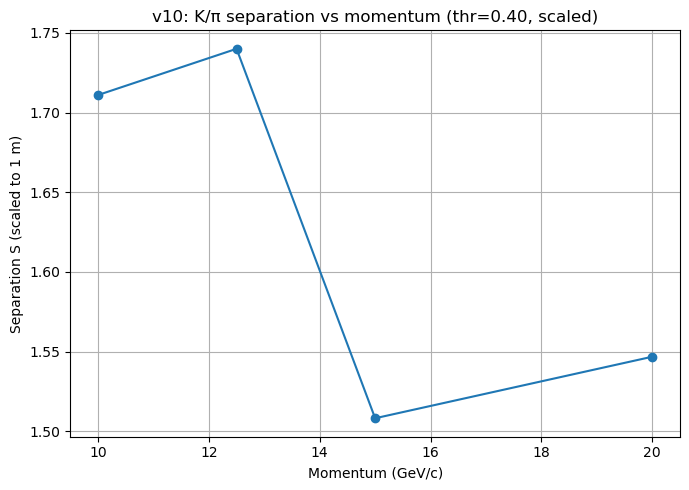

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v10_thr0.40_scaled_1m.png
mom~7.5: skip density (K=10000, Pi=0)
mom~17.5: skip density (K=10000, Pi=0)


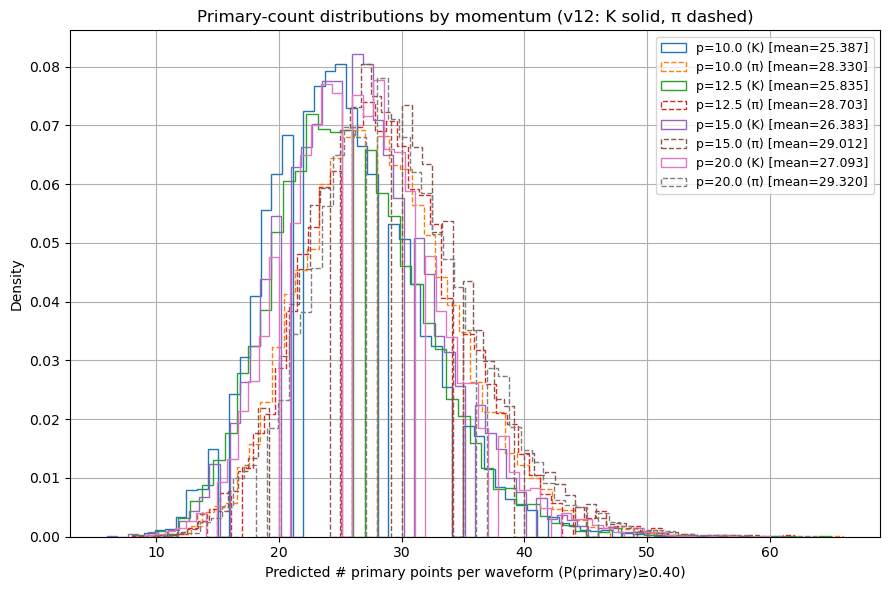

Saved: results/final_eval_v10_v12_with_density/part2_v12_primarycount_density_by_mom_thr0.40.png


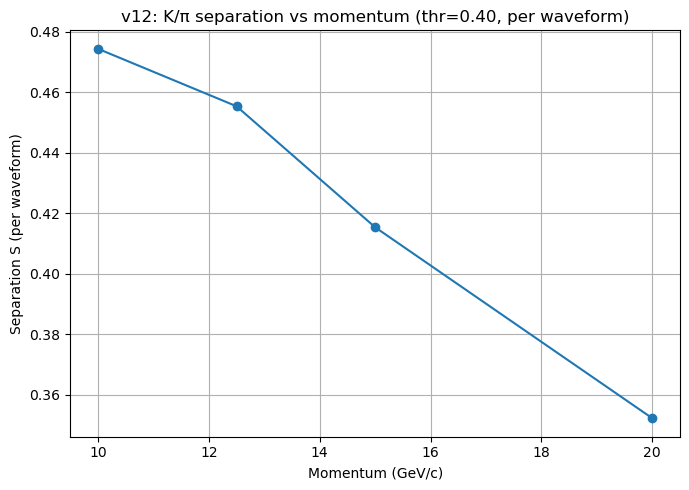

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v12_thr0.40_per_waveform.png


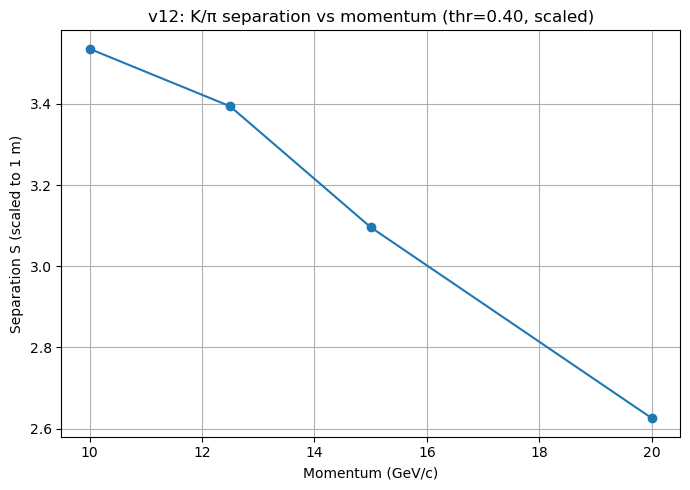

Saved: results/final_eval_v10_v12_with_density/sep_vs_mom_v12_thr0.40_scaled_1m.png

✅ Done. Outputs in: results/final_eval_v10_v12_with_density


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ = "PionsKaons/batch_0.npz"  # IMPORTANT: batch_0 has pid=130/211

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"

OUTDIR = "results/final_eval_v10_v12_with_density"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 64
NUM_TIMESTEPS = 20
THRESH_GRID = np.linspace(0, 1, 1001)

PID_KAON = 130
PID_PION = 211

PRIMARY_TAG_VALUE = 1
SECONDARY_TAG_VALUE = 2

# thresholds used for:
# 1) purity/eff curves (scan THRESH_GRID)
# 2) count distributions & separation-vs-mom (use these fixed thresholds)
COUNT_THRESHOLDS = [0.10, 0.26, 0.40]

# scaling to compare with paper
CELL_LENGTH_M = 0.018    # EDIT if needed
TARGET_TRACK_M = 1.0

# histogram settings
HIST_BINS = 60

# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x); spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)
            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)
        return torch.stack(spk_out, dim=2).mean(dim=2)

# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("wf_i:", wf_i.shape, wf_i.dtype)
    print("mom:", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print("tag_values unique:", np.unique(tag_values))
    print()
    return wf_i, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_truth_binary_from_tags(tag_times, tag_values, T, positive_value):
    N, K = tag_times.shape
    y = np.zeros((N, T), dtype=np.uint8)
    valid = (tag_times >= 0) & (tag_times < T)
    is_pos = valid & (tag_values == positive_value)
    rows, cols = np.where(is_pos)
    t = tag_times[rows, cols]
    y[rows, t] = 1
    return y

def infer_probs(model, wf_i, scaler, device, label):
    x = scaler.transform(wf_i.reshape(-1,1)).reshape(wf_i.shape[0], wf_i.shape[1], 1)
    x_t = torch.tensor(x, dtype=torch.float32)
    loader = torch.utils.data.DataLoader(x_t, batch_size=BATCH_SIZE, shuffle=False)

    probs_all = []
    model.eval()
    with torch.no_grad():
        for xb in tqdm(loader, desc=label, mininterval=1.0):
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            probs_all.append(probs)
    return np.concatenate(probs_all, axis=0)

def purity_eff_curve(y_true_bin, p_pos, thresholds):
    yt = y_true_bin.reshape(-1).astype(np.uint8)
    pp = p_pos.reshape(-1).astype(np.float32)
    purity = np.zeros_like(thresholds, dtype=np.float64)
    eff    = np.zeros_like(thresholds, dtype=np.float64)

    for i, thr in enumerate(thresholds):
        pred = pp >= thr
        TP = np.sum(pred & (yt == 1))
        FP = np.sum(pred & (yt == 0))
        FN = np.sum((~pred) & (yt == 1))
        purity[i] = TP/(TP+FP) if (TP+FP)>0 else 0.0
        eff[i]    = TP/(TP+FN) if (TP+FN)>0 else 0.0
    return purity, eff

def best_f1(purity, eff, thresholds):
    f1 = 2*purity*eff/(purity+eff+1e-12)
    idx = int(np.nanargmax(f1))
    return float(thresholds[idx]), float(purity[idx]), float(eff[idx]), float(f1[idx])

def intersection_thr(purity, eff, thresholds):
    # find where purity-eff crosses 0
    diff = purity - eff
    s = np.sign(diff)
    idxs = np.where(s[:-1]*s[1:] < 0)[0]
    if len(idxs) == 0:
        return np.nan
    # pick the crossing closest to best-F1 (stable choice)
    thr_f1, _, _, _ = best_f1(purity, eff, thresholds)
    cand = []
    for i in idxs:
        x0, x1 = thresholds[i], thresholds[i+1]
        y0, y1 = diff[i], diff[i+1]
        t = -y0/(y1-y0+1e-12)
        cand.append(x0 + (x1-x0)*t)
    cand = np.array(cand)
    return float(cand[np.argmin(np.abs(cand - thr_f1))])

def plot_pe_inline(thresholds, purity, eff, thr_f1, thr_int, title, out_png):
    plt.figure(figsize=(7,6))
    plt.plot(thresholds, purity, label="Purity")
    plt.plot(thresholds, eff, "--", label="Efficiency")
    plt.axvline(thr_f1, color="r", ls="--", label=f"Best-F1={thr_f1:.3f}")
    if np.isfinite(thr_int):
        plt.axvline(thr_int, color="k", ls=":", label=f"Intersect={thr_int:.3f}")
    plt.xlabel("Threshold")
    plt.ylabel("Metric")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0*abs(muK - muPi)/(sigK + sigPi + 1e-12)

def plot_primarycount_density_by_mom(counts, mom, pid, thr, label, out_png):
    """
    Replicates your desired plot:
      Primary-count distributions by momentum (K solid, π dashed)
    """
    moms = sorted(np.unique(mom).tolist())
    plt.figure(figsize=(9,6))
    for p in moms:
        mk = (mom == p) & (pid == PID_KAON)
        mpi = (mom == p) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            print(f"mom~{p}: skip density (K={int(mk.sum())}, Pi={int(mpi.sum())})")
            continue

        ck = counts[mk]
        cpi = counts[mpi]
        plt.hist(ck, bins=HIST_BINS, density=True, histtype="step",
                 label=f"p={p:.1f} (K) [mean={ck.mean():.3f}]")
        plt.hist(cpi, bins=HIST_BINS, density=True, histtype="step", linestyle="--",
                 label=f"p={p:.1f} (π) [mean={cpi.mean():.3f}]")

    plt.xlabel(f"Predicted # primary points per waveform (P(primary)≥{thr:.2f})")
    plt.ylabel("Density")
    plt.title(f"Primary-count distributions by momentum ({label}: K solid, π dashed)")
    plt.grid(True)
    plt.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_sep_vs_mom(counts, mom, pid, label, thr, scale_to_1m):
    moms = sorted(np.unique(mom).tolist())
    moms_used = []
    Sw, S1m = [], []

    for p in moms:
        mk = (mom == p) & (pid == PID_KAON)
        mpi = (mom == p) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        S = sep_paper(muK, sigK, muPi, sigPi)

        moms_used.append(float(p))
        Sw.append(float(S))
        S1m.append(float(S * scale_to_1m))

    # per waveform
    plt.figure(figsize=(7,5))
    plt.plot(moms_used, Sw, marker="o")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation S (per waveform)")
    plt.title(f"{label}: K/π separation vs momentum (thr={thr:.2f}, per waveform)")
    plt.grid(True)
    plt.tight_layout()
    out_png = os.path.join(OUTDIR, f"sep_vs_mom_{label}_thr{thr:.2f}_per_waveform.png")
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()
    print("Saved:", out_png)

    # scaled to 1m
    plt.figure(figsize=(7,5))
    plt.plot(moms_used, S1m, marker="o")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation S (scaled to 1 m)")
    plt.title(f"{label}: K/π separation vs momentum (thr={thr:.2f}, scaled)")
    plt.grid(True)
    plt.tight_layout()
    out_png = os.path.join(OUTDIR, f"sep_vs_mom_{label}_thr{thr:.2f}_scaled_1m.png")
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()
    print("Saved:", out_png)

# ============================================================
# MAIN
# ============================================================
def main():
    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_npz(DATA_NPZ)
    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    y_true_primary = build_truth_binary_from_tags(tag_times, tag_values, T, PRIMARY_TAG_VALUE)
    y_true_secondary = build_truth_binary_from_tags(tag_times, tag_values, T, SECONDARY_TAG_VALUE)
    print("Overall TRUE primary fraction:", float(y_true_primary.mean()))
    print("Overall TRUE secondary fraction:", float(y_true_secondary.mean()))
    has_secondary_truth = (y_true_secondary.sum() > 0)
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device, "\n")

    # ============================================================
    # PART 1: purity-efficiency curves for v10 and v12
    # ============================================================
    print("==============================")
    print("Part 1: Purity–Efficiency curves (v10 + v12)")
    print("==============================")

    # v10
    v10 = ConvSNN_Deep(num_classes=2).to(device)
    v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
    probs_v10 = infer_probs(v10, wf_i, scaler, device, label="Inference v10")
    p_primary_v10 = probs_v10[:, :, 1]

    for this_pid, name in [(PID_KAON, "KAON"), (PID_PION, "PION")]:
        m = (pid == this_pid)
        purity, eff = purity_eff_curve(y_true_primary[m], p_primary_v10[m], THRESH_GRID)
        thr_f1, p_f1, e_f1, f1 = best_f1(purity, eff, THRESH_GRID)
        thr_int = intersection_thr(purity, eff, THRESH_GRID)
        print(f"[v10 {name}] Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")
        if np.isfinite(thr_int):
            idx = int(np.argmin(np.abs(THRESH_GRID - thr_int)))
            print(f"           Intersect thr≈{thr_int:.3f} | Purity≈{purity[idx]*100:.2f}% | Eff≈{eff[idx]*100:.2f}%")
        else:
            print("           Intersect: (no crossing)")
        out_png = os.path.join(OUTDIR, f"part1_v10_purity_eff_{name.lower()}.png")
        plot_pe_inline(THRESH_GRID, purity, eff, thr_f1, thr_int,
                       f"v10 Purity–Efficiency (Primary vs Background) [{name}]",
                       out_png)

    # v12
    v12 = ConvSNN_Deep(num_classes=3).to(device)
    v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
    probs_v12 = infer_probs(v12, wf_i, scaler, device, label="Inference v12")
    p_primary_v12 = probs_v12[:, :, 1]
    p_secondary_v12 = probs_v12[:, :, 2]

    for this_pid, name in [(PID_KAON, "KAON"), (PID_PION, "PION")]:
        m = (pid == this_pid)
        purity, eff = purity_eff_curve(y_true_primary[m], p_primary_v12[m], THRESH_GRID)
        thr_f1, p_f1, e_f1, f1 = best_f1(purity, eff, THRESH_GRID)
        thr_int = intersection_thr(purity, eff, THRESH_GRID)
        print(f"[v12 {name} PRIMARY] Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")
        out_png = os.path.join(OUTDIR, f"part1_v12_primary_purity_eff_{name.lower()}.png")
        plot_pe_inline(THRESH_GRID, purity, eff, thr_f1, thr_int,
                       f"v12 Purity–Efficiency (Primary vs Background) [{name}]",
                       out_png)

    if has_secondary_truth:
        for this_pid, name in [(PID_KAON, "KAON"), (PID_PION, "PION")]:
            m = (pid == this_pid)
            purity, eff = purity_eff_curve(y_true_secondary[m], p_secondary_v12[m], THRESH_GRID)
            thr_f1, p_f1, e_f1, f1 = best_f1(purity, eff, THRESH_GRID)
            thr_int = intersection_thr(purity, eff, THRESH_GRID)
            print(f"[v12 {name} SECONDARY] Best-F1 thr={thr_f1:.3f} | Purity={p_f1*100:.2f}% | Eff={e_f1*100:.2f}% | F1={f1:.3f}")
            out_png = os.path.join(OUTDIR, f"part1_v12_secondary_purity_eff_{name.lower()}.png")
            plot_pe_inline(THRESH_GRID, purity, eff, thr_f1, thr_int,
                           f"v12 Purity–Efficiency (Secondary vs Background) [{name}]",
                           out_png)
    else:
        print("NOTE: No secondary truth tags (tag_value=2) found. Skipping secondary curves.\n")

    # ============================================================
    # PART 2: density histograms + separation plots (v10 + v12)
    # ============================================================
    print("\n==============================")
    print("Part 2: Primary-count density by momentum + separation vs momentum (v10 + v12)")
    print("==============================")

    scale_to_1m = np.sqrt(TARGET_TRACK_M / CELL_LENGTH_M)
    print(f"Scaling: CELL_LENGTH_M={CELL_LENGTH_M} → sqrt(1m/Lcell) = {scale_to_1m:.3f}\n")

    for thr in COUNT_THRESHOLDS:
        # v10 counts
        counts_v10 = (p_primary_v10 >= thr).sum(axis=1).astype(np.int32)
        out_png = os.path.join(OUTDIR, f"part2_v10_primarycount_density_by_mom_thr{thr:.2f}.png")
        plot_primarycount_density_by_mom(counts_v10, mom, pid, thr, "v10", out_png)
        plot_sep_vs_mom(counts_v10, mom, pid, "v10", thr, scale_to_1m)

        # v12 counts
        counts_v12 = (p_primary_v12 >= thr).sum(axis=1).astype(np.int32)
        out_png = os.path.join(OUTDIR, f"part2_v12_primarycount_density_by_mom_thr{thr:.2f}.png")
        plot_primarycount_density_by_mom(counts_v12, mom, pid, thr, "v12", out_png)
        plot_sep_vs_mom(counts_v12, mom, pid, "v12", thr, scale_to_1m)

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Scaling for 1m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
wf_i: (100000, 3000) float32
mom: (100000,) unique: [ 7.5 10.  12.5 15.  17.5 20. ]
pid unique: [130 211] counts: [60000 40000]
tag_values unique: [0 1 2]



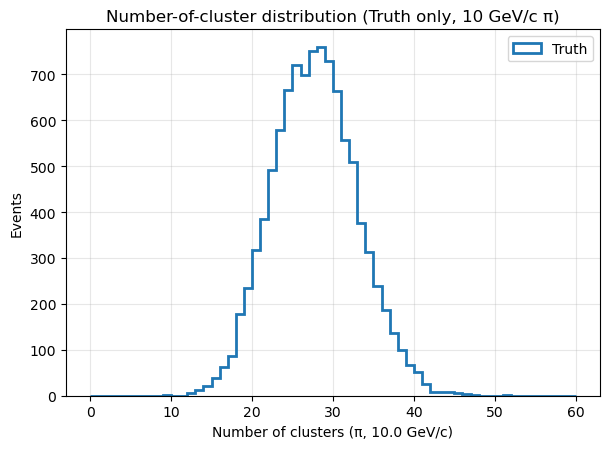

Saved: results/final_eval_v10_v12_sep_only/fig8_like_truth_only_10gev_pion.png
Device: cpu 



/tmp/ipykernel_231/2353191313.py:257: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
Inference v10: 100%|███

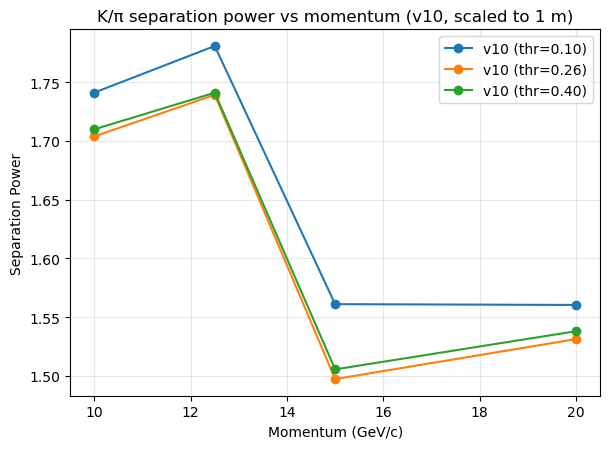

Saved: results/final_eval_v10_v12_sep_only/fig9_like_sep_power_vs_mom_v10_scaled_1m.png


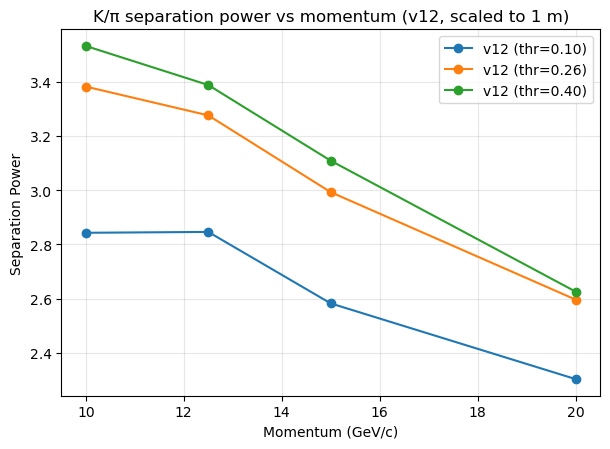

Saved: results/final_eval_v10_v12_sep_only/fig9_like_sep_power_vs_mom_v12_scaled_1m.png

✅ Done. Outputs in: results/final_eval_v10_v12_sep_only


In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ = "PionsKaons/batch_0.npz"  # batch_0 has pid=130/211

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"

OUTDIR = "results/final_eval_v10_v12_sep_only"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 64
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

PRIMARY_TAG_VALUE = 1

# Fixed thresholds to match paper-style comparison
COUNT_THRESHOLDS = [0.10, 0.26, 0.40]

# ----- scaling (paper track length 1m; best guess cell length = 18 mm) -----
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)  # sqrt(1000/18)

# histogram settings
HIST_BINS = 60
HIST_RANGE = (0, 60)  # to resemble paper axis

# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1) -> conv wants (B, C, T)
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);   spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            # time-major to feed FC across time axis as features
            spk4 = spk4.permute(0, 2, 1)  # (B, T, 128)
            fc = self.fc1(spk4)           # (B, T, 128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)     # (B, T, num_classes)
            spk_out.append(out)

        # average over SNN steps -> (B, T, num_classes)
        return torch.stack(spk_out, dim=2).mean(dim=2)

# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]  # expected (N, T)
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("wf_i:", wf_i.shape, wf_i.dtype)
    print("mom:", mom.shape, "unique:", np.unique(mom))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print("tag_values unique:", np.unique(tag_values))
    print()
    return wf_i, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    # If tag_times look 1-based, convert
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_truth_binary_from_tags(tag_times, tag_values, T, positive_value):
    """
    y[n,t]=1 if there is a tag at time t with tag_value==positive_value
    """
    N, K = tag_times.shape
    y = np.zeros((N, T), dtype=np.uint8)

    valid = (tag_times >= 0) & (tag_times < T)
    is_pos = valid & (tag_values == positive_value)

    rows, cols = np.where(is_pos)
    t = tag_times[rows, cols]
    y[rows, t] = 1
    return y

def infer_probs(model, wf_i, scaler, device, label):
    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(wf_i.shape[0], wf_i.shape[1], 1)
    x_t = torch.tensor(x, dtype=torch.float32)

    loader = torch.utils.data.DataLoader(x_t, batch_size=BATCH_SIZE, shuffle=False)

    probs_all = []
    model.eval()
    with torch.no_grad():
        for xb in tqdm(loader, desc=label, mininterval=1.0):
            xb = xb.to(device)
            logits = model(xb)  # (B, T, C)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            probs_all.append(probs)

    return np.concatenate(probs_all, axis=0)  # (N, T, C)

def sep_paper(muK, sigK, muPi, sigPi):
    # paper formula: 2|muK - muPi|/(sigK + sigPi)
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid):
    moms = sorted(np.unique(mom).tolist())
    moms_used, S = [], []
    for p in moms:
        mk = (mom == p) & (pid == PID_KAON)
        mpi = (mom == p) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)

        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))
    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_truth_cluster_dist_10gev(truth_counts, mom, pid, out_png):
    """
    Fig.8-like: only 10 GeV/c, only Truth line, pion sample.
    Use event counts (not density).
    """
    m = (pid == PID_PION) & (np.isclose(mom, 10.0))
    x = truth_counts[m].astype(np.int32)

    if x.size == 0:
        print("No events found for pid=PION and mom=10.0. Check dataset momentum values.")
        return

    plt.figure(figsize=(6.2, 4.6))
    plt.hist(
        x,
        bins=HIST_BINS,
        range=HIST_RANGE,
        histtype="step",
        linewidth=2.0,
        label="Truth"
    )
    plt.xlabel("Number of clusters (π, 10.0 GeV/c)")
    plt.ylabel("Events")
    plt.title("Number-of-cluster distribution (Truth only, 10 GeV/c π)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_sep_power_fig9_style(moms, curves_dict, title, out_png):
    """
    curves_dict: {label: S_scaled_array}
    """
    plt.figure(figsize=(6.2, 4.6))
    for lab, y in curves_dict.items():
        plt.plot(moms, y, marker="o", label=lab)

    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()
    print("Saved:", out_png)

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling for 1m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_npz(DATA_NPZ)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    # Truth counts per waveform (clusters)
    y_true_primary = build_truth_binary_from_tags(tag_times, tag_values, T, PRIMARY_TAG_VALUE)
    truth_counts = y_true_primary.sum(axis=1).astype(np.int32)

    # --- Fig.8-like (Truth only, 10 GeV/c π) ---
    out_png = os.path.join(OUTDIR, "fig8_like_truth_only_10gev_pion.png")
    plot_truth_cluster_dist_10gev(truth_counts, mom, pid, out_png)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device, "\n")

    # ============================================================
    # v10 inference
    # ============================================================
    v10 = ConvSNN_Deep(num_classes=2).to(device)
    v10.load_state_dict(torch.load(V10_BEST_PT, map_location=device))
    probs_v10 = infer_probs(v10, wf_i, scaler, device, label="Inference v10")
    p_primary_v10 = probs_v10[:, :, 1]  # (N, T)

    # ============================================================
    # v12 inference
    # ============================================================
    v12 = ConvSNN_Deep(num_classes=3).to(device)
    v12.load_state_dict(torch.load(V12_BEST_PT, map_location=device))
    probs_v12 = infer_probs(v12, wf_i, scaler, device, label="Inference v12")
    p_primary_v12 = probs_v12[:, :, 1]  # (N, T)

    # ============================================================
    # Fig.9-like: separation power vs momentum (scaled to 1m)
    # (three threshold curves)
    # ============================================================
    # --- v10 curves ---
    curves_v10 = {}
    moms_ref = None
    for thr in COUNT_THRESHOLDS:
        counts = (p_primary_v10 >= thr).sum(axis=1).astype(np.int32)  # clusters per waveform
        moms_used, S = separation_vs_momentum(counts, mom, pid)
        S_scaled = S * SCALE_TO_1M
        curves_v10[f"v10 (thr={thr:.2f})"] = S_scaled
        moms_ref = moms_used if moms_ref is None else moms_ref

    out_png = os.path.join(OUTDIR, "fig9_like_sep_power_vs_mom_v10_scaled_1m.png")
    plot_sep_power_fig9_style(
        moms_ref,
        curves_v10,
        "K/π separation power vs momentum (v10, scaled to 1 m)",
        out_png
    )

    # --- v12 curves ---
    curves_v12 = {}
    moms_ref = None
    for thr in COUNT_THRESHOLDS:
        counts = (p_primary_v12 >= thr).sum(axis=1).astype(np.int32)
        moms_used, S = separation_vs_momentum(counts, mom, pid)
        S_scaled = S * SCALE_TO_1M
        curves_v12[f"v12 (thr={thr:.2f})"] = S_scaled
        moms_ref = moms_used if moms_ref is None else moms_ref

    out_png = os.path.join(OUTDIR, "fig9_like_sep_power_vs_mom_v12_scaled_1m.png")
    plot_sep_power_fig9_style(
        moms_ref,
        curves_v12,
        "K/π separation power vs momentum (v12, scaled to 1 m)",
        out_png
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0 unique: [ 7.5 10.  12.5 15.  17.5 20. ]
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5 unique: [ 5.   7.5 17.5]
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203 unique: [ 0.20001669  0.20007403  0.20010513 ... 19.999239   19.999472
 19.999886  ]
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 19.99993896484375 unique: [ 0.20036636  0.20040736  0.2

/tmp/ipykernel_6391/338930646.py:197: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):
Inference v10 (counts): 100%|██████████| 1719/1719 [16:10<00:00,  1.77it/s]
/tmp/ipykernel_6391/338930646.py:197: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):
Inference v12 (counts): 100%|██████████| 1719/1719 [16:13<00:00,  1.77it/s]


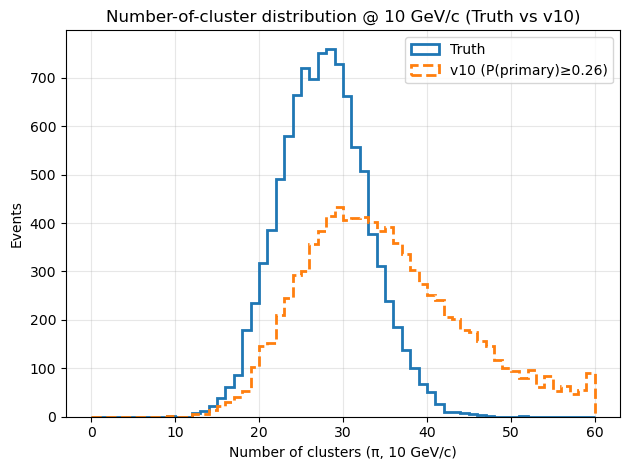

Saved: results/final_eval_v10_v12_all_batches/fig8_like_truth_vs_v10_thr0.26_10gev_pion.png


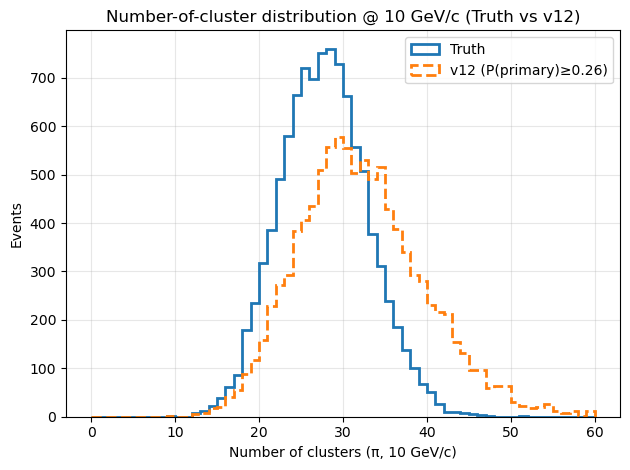

Saved: results/final_eval_v10_v12_all_batches/fig8_like_truth_vs_v12_thr0.26_10gev_pion.png


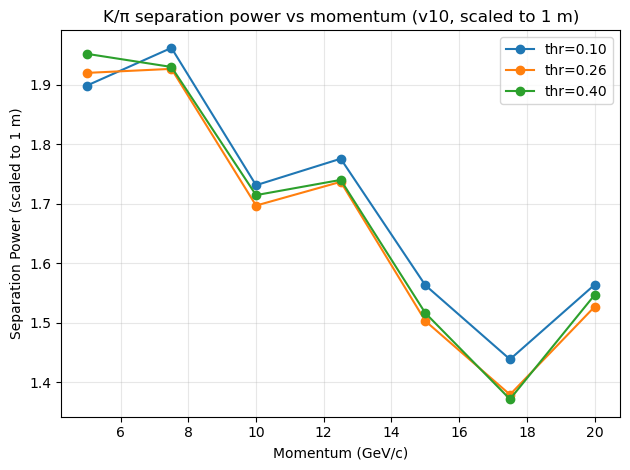

Saved: results/final_eval_v10_v12_all_batches/fig9_like_sep_power_vs_mom_v10_scaled_1m.png


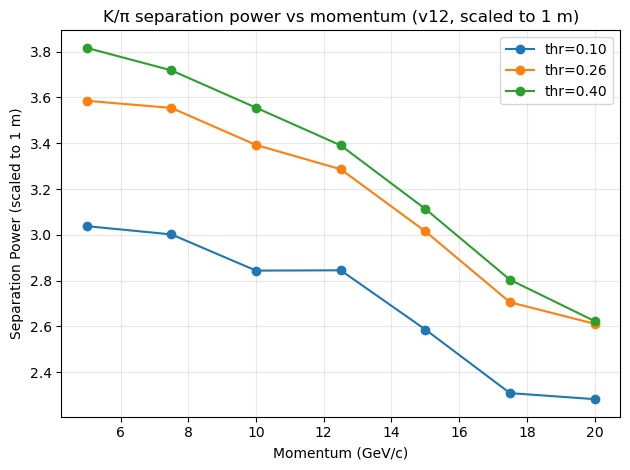

Saved: results/final_eval_v10_v12_all_batches/fig9_like_sep_power_vs_mom_v12_scaled_1m.png

✅ Done. Outputs in: results/final_eval_v10_v12_all_batches


In [7]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"

# Evaluate on multiple batches
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0 ... batch_4

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"

OUTDIR = "results/final_eval_v10_v12_all_batches"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256          # bump this up if GPU has room (128/256/512)
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

PRIMARY_TAG_VALUE = 1

# thresholds for separation curves (Fig.9-like)
COUNT_THRESHOLDS = [0.10, 0.26, 0.40]

# threshold used for the "Fig.8-like" number-of-cluster distribution overlay
FIG8_THRESH = 0.26

# scaling to 1 m track length (paper assumption: 18 mm per cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)  # sqrt(1000/18)

# histogram settings
HIST_BINS = 60
HIST_RANGE = (0, 60)  # match paper-ish axis

# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1) -> conv wants (B, C, T)
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)   # (B, T, 128)
            fc = self.fc1(spk4)            # (B, T, 128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)      # (B, T, num_classes)
            spk_out.append(out)

        # average over SNN steps -> (B, T, C)
        return torch.stack(spk_out, dim=2).mean(dim=2)

# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()), "unique:", np.unique(mom))
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_truth_binary_from_tags(tag_times, tag_values, T, positive_value):
    N, K = tag_times.shape
    y = np.zeros((N, T), dtype=np.uint8)

    valid = (tag_times >= 0) & (tag_times < T)
    is_pos = valid & (tag_values == positive_value)
    rows, cols = np.where(is_pos)
    t = tag_times[rows, cols]
    y[rows, t] = 1
    return y

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "unique:", np.unique(mom))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def infer_primary_counts_for_thresholds(model, wf_i, scaler, device, thresholds, label):
    """
    Fast inference:
      returns dict {thr: counts_array shape (N,)}
    where counts are #timesteps with P(primary) >= thr.
    Avoids storing full (N,T,C).
    """
    N, T = wf_i.shape

    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)  # zero-copy

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    thresholds = list(sorted(set([float(t) for t in thresholds])))
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thresholds}

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=label, mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.cuda.amp.autocast(True):
                    logits = model(xb)  # (B,T,C)
                    probs = torch.softmax(logits, dim=-1)
                    p_primary = probs[..., 1]  # (B,T)
            else:
                logits = model(xb)
                probs = torch.softmax(logits, dim=-1)
                p_primary = probs[..., 1]

            # compute counts per threshold on GPU, then move small vectors to CPU
            for thr in thresholds:
                counts = (p_primary >= thr).sum(dim=1).to(torch.int32).cpu().numpy()
                out[thr][idx0:idx0+bs] = counts

            idx0 += bs

    return out

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid):
    moms = sorted(np.unique(mom).tolist())
    moms_used, S = [], []
    for p in moms:
        mk = (mom == p) & (pid == PID_KAON)
        mpi = (mom == p) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)

        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_fig8_overlay_truth_vs_model(truth_counts, model_counts, mom, pid, model_name, thr, out_png):
    """
    Fig.8-like: only 10 GeV/c, only PION sample.
    Plot event counts (not density): Truth + model.
    """
    mask = (pid == PID_PION) & (np.isclose(mom, 10.0))
    xt = truth_counts[mask].astype(np.int32)
    xm = model_counts[mask].astype(np.int32)

    if xt.size == 0:
        print("No events found for pid=PION and mom=10.0. Check np.unique(mom).")
        return

    plt.figure(figsize=(6.4, 4.8))
    plt.hist(xt, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.0, label="Truth")
    plt.hist(xm, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.0, linestyle="--",
             label=f"{model_name} (P(primary)≥{thr:.2f})")

    plt.xlabel("Number of clusters (π, 10 GeV/c)")
    plt.ylabel("Events")
    plt.title(f"Number-of-cluster distribution @ 10 GeV/c (Truth vs {model_name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_sep_power_curves(moms, curves_dict, title, out_png):
    plt.figure(figsize=(6.4, 4.8))
    for lab, y in curves_dict.items():
        plt.plot(moms, y, marker="o", label=lab)

    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()
    print("Saved:", out_png)

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    y_true_primary = build_truth_binary_from_tags(tag_times, tag_values, T, PRIMARY_TAG_VALUE)
    truth_counts = y_true_primary.sum(axis=1).astype(np.int32)
    print("Overall TRUE primary fraction:", float(y_true_primary.mean()))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ------------------------------------------------------------
    # Load models
    # ------------------------------------------------------------
    v10 = ConvSNN_Deep(num_classes=2).to(device)
    v10_state = torch.load(V10_BEST_PT, map_location=device, weights_only=True)
    v10.load_state_dict(v10_state)

    v12 = ConvSNN_Deep(num_classes=3).to(device)
    v12_state = torch.load(V12_BEST_PT, map_location=device, weights_only=True)
    v12.load_state_dict(v12_state)

    # We need counts for FIG8_THRESH plus separation thresholds
    THRS_NEEDED = sorted(set(COUNT_THRESHOLDS + [FIG8_THRESH]))

    # ------------------------------------------------------------
    # Inference -> counts (fast, no full probs stored)
    # ------------------------------------------------------------
    counts_v10_dict = infer_primary_counts_for_thresholds(
        v10, wf_i, scaler, device, THRS_NEEDED, label="Inference v10 (counts)"
    )
    counts_v12_dict = infer_primary_counts_for_thresholds(
        v12, wf_i, scaler, device, THRS_NEEDED, label="Inference v12 (counts)"
    )

    # ------------------------------------------------------------
    # Fig.8-like: Truth vs v10 (10 GeV pion) and Truth vs v12 (10 GeV pion)
    # (two graphs, as requested)
    # ------------------------------------------------------------
    out_png = os.path.join(OUTDIR, f"fig8_like_truth_vs_v10_thr{FIG8_THRESH:.2f}_10gev_pion.png")
    plot_fig8_overlay_truth_vs_model(
        truth_counts, counts_v10_dict[FIG8_THRESH], mom, pid, "v10", FIG8_THRESH, out_png
    )

    out_png = os.path.join(OUTDIR, f"fig8_like_truth_vs_v12_thr{FIG8_THRESH:.2f}_10gev_pion.png")
    plot_fig8_overlay_truth_vs_model(
        truth_counts, counts_v12_dict[FIG8_THRESH], mom, pid, "v12", FIG8_THRESH, out_png
    )

    # ------------------------------------------------------------
    # Fig.9-like: Separation power vs momentum (scaled to 1 m)
    # v10 plot (3 threshold curves)
    # ------------------------------------------------------------
    curves_v10 = {}
    moms_ref = None
    for thr in COUNT_THRESHOLDS:
        moms_used, S = separation_vs_momentum(counts_v10_dict[thr], mom, pid)
        S_scaled = S * SCALE_TO_1M
        curves_v10[f"thr={thr:.2f}"] = S_scaled
        moms_ref = moms_used

    out_png = os.path.join(OUTDIR, "fig9_like_sep_power_vs_mom_v10_scaled_1m.png")
    plot_sep_power_curves(
        moms_ref, curves_v10,
        "K/π separation power vs momentum (v10, scaled to 1 m)",
        out_png
    )

    # v12 plot (3 threshold curves)
    curves_v12 = {}
    moms_ref = None
    for thr in COUNT_THRESHOLDS:
        moms_used, S = separation_vs_momentum(counts_v12_dict[thr], mom, pid)
        S_scaled = S * SCALE_TO_1M
        curves_v12[f"thr={thr:.2f}"] = S_scaled
        moms_ref = moms_used

    out_png = os.path.join(OUTDIR, "fig9_like_sep_power_vs_mom_v12_scaled_1m.png")
    plot_sep_power_curves(
        moms_ref, curves_v12,
        "K/π separation power vs momentum (v12, scaled to 1 m)",
        out_png
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Scaling to 1 m: sqrt(1000/18) = 7.453560
Fig8 y-axis: scaling π@10GeV sample to N_TARGET=100000

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0 unique: [ 7.5 10.  12.5 15.  17.5 20. ]
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5 unique: [ 5.   7.5 17.5]
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203 unique: [ 0.20001669  0.20007403  0.20010513 ... 19.999239   19.999472
 19.999886  ]
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 

/tmp/ipykernel_187/1957653220.py:200: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):
Inference v10 (counts): 100%|██████████| 1719/1719 [18:59<00:00,  1.51it/s]
/tmp/ipykernel_187/1957653220.py:200: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):
Inference v12 (counts): 100%|██████████| 1719/1719 [19:02<00:00,  1.51it/s]


[Fig8 v10] π@10GeV sample N=10000 -> scaling to 100000 with weight=10.000000


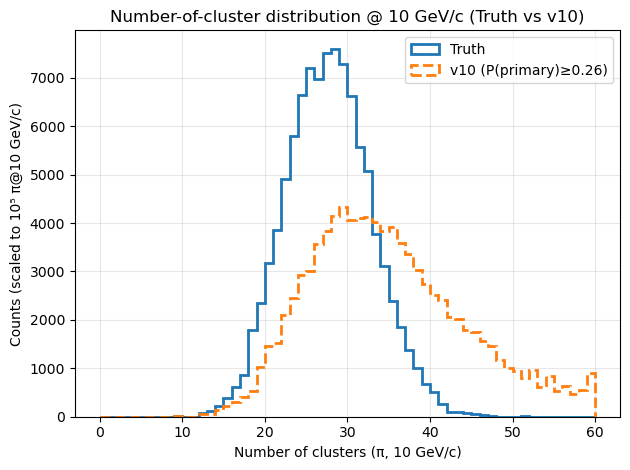

Saved: results/final_eval_v10_v12_all_batches/fig8_like_truth_vs_v10_thr0.26_10gev_pion_scaled1e5.png
[Fig8 v12] π@10GeV sample N=10000 -> scaling to 100000 with weight=10.000000


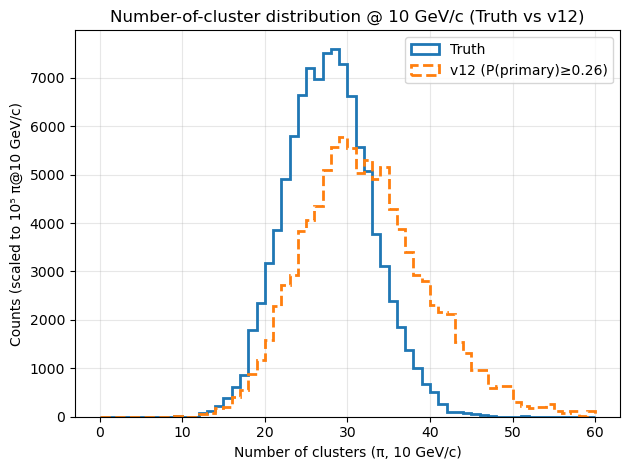

Saved: results/final_eval_v10_v12_all_batches/fig8_like_truth_vs_v12_thr0.26_10gev_pion_scaled1e5.png


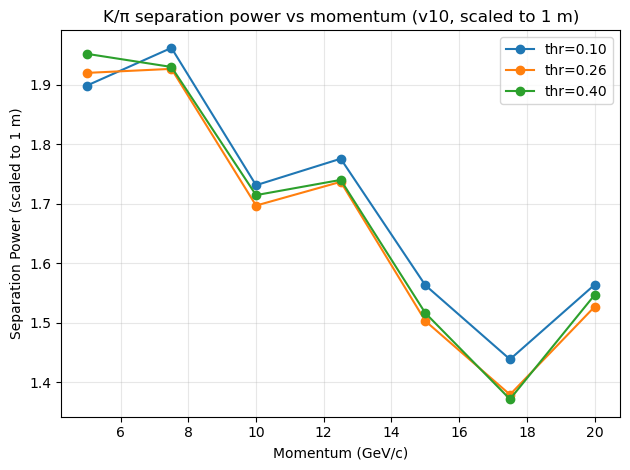

Saved: results/final_eval_v10_v12_all_batches/fig9_like_sep_power_vs_mom_v10_scaled_1m.png


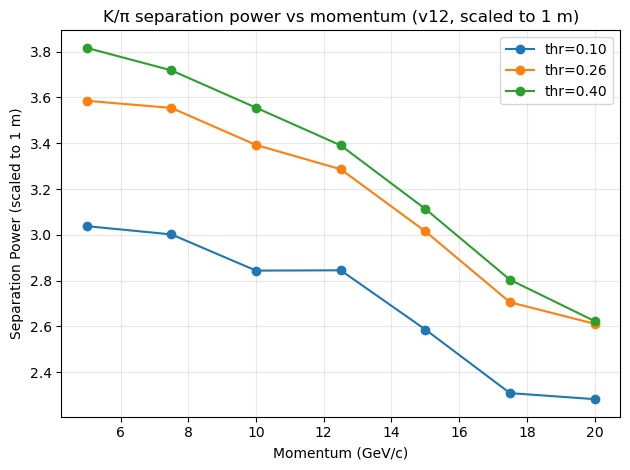

Saved: results/final_eval_v10_v12_all_batches/fig9_like_sep_power_vs_mom_v12_scaled_1m.png

✅ Done. Outputs in: results/final_eval_v10_v12_all_batches


In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"

# Evaluate on multiple batches
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0 ... batch_4

V10_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"
V12_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"

OUTDIR = "results/final_eval_v10_v12_all_batches"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256          # bump this up if GPU has room (128/256/512)
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

PRIMARY_TAG_VALUE = 1

# thresholds for separation curves (Fig.9-like)
COUNT_THRESHOLDS = [0.10, 0.26, 0.40]

# threshold used for the "Fig.8-like" number-of-cluster distribution overlay
FIG8_THRESH = 0.26

# scaling to 1 m track length (paper assumption: 18 mm per cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)  # sqrt(1000/18)

# histogram settings
HIST_BINS = 60
HIST_RANGE = (0, 60)  # match paper-ish axis

# Fig.8 y-axis scaling target (paper-like)
FIG8_N_TARGET = 100000  # scale π@10GeV sample to 1e5 events for comparable y-axis

# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1) -> conv wants (B, C, T)
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)   # (B, T, 128)
            fc = self.fc1(spk4)            # (B, T, 128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)      # (B, T, num_classes)
            spk_out.append(out)

        # average over SNN steps -> (B, T, C)
        return torch.stack(spk_out, dim=2).mean(dim=2)

# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()), "unique:", np.unique(mom))
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_truth_binary_from_tags(tag_times, tag_values, T, positive_value):
    N, K = tag_times.shape
    y = np.zeros((N, T), dtype=np.uint8)

    valid = (tag_times >= 0) & (tag_times < T)
    is_pos = valid & (tag_values == positive_value)
    rows, cols = np.where(is_pos)
    t = tag_times[rows, cols]
    y[rows, t] = 1
    return y

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "unique:", np.unique(mom))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def infer_primary_counts_for_thresholds(model, wf_i, scaler, device, thresholds, label):
    """
    Fast inference:
      returns dict {thr: counts_array shape (N,)}
    where counts are #timesteps with P(primary) >= thr.
    Avoids storing full (N,T,C).
    """
    N, T = wf_i.shape

    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)  # zero-copy

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    thresholds = list(sorted(set([float(t) for t in thresholds])))
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thresholds}

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=label, mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.cuda.amp.autocast(True):
                    logits = model(xb)  # (B,T,C)
                    probs = torch.softmax(logits, dim=-1)
                    p_primary = probs[..., 1]  # (B,T)
            else:
                logits = model(xb)
                probs = torch.softmax(logits, dim=-1)
                p_primary = probs[..., 1]

            for thr in thresholds:
                counts = (p_primary >= thr).sum(dim=1).to(torch.int32).cpu().numpy()
                out[thr][idx0:idx0+bs] = counts

            idx0 += bs

    return out

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid):
    moms = sorted(np.unique(mom).tolist())
    moms_used, S = [], []
    for p in moms:
        mk = (mom == p) & (pid == PID_KAON)
        mpi = (mom == p) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)

        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_fig8_overlay_truth_vs_model(truth_counts, model_counts, mom, pid, model_name, thr, out_png,
                                     N_TARGET=FIG8_N_TARGET):
    """
    Fig.8-like: only 10 GeV/c, only PION sample.
    We scale histogram counts to a fixed target sample size (default 1e5)
    so the y-axis is comparable to paper-style plots.

    Weight per event = N_TARGET / N_sample.
    """
    mask = (pid == PID_PION) & (np.isclose(mom, 10.0))
    xt = truth_counts[mask].astype(np.int32)
    xm = model_counts[mask].astype(np.int32)

    N = int(mask.sum())
    if N == 0:
        print("No events found for pid=PION and mom=10.0. Check np.unique(mom).")
        return

    scale = float(N_TARGET) / float(N)
    w = np.ones(N, dtype=np.float32) * scale
    print(f"[Fig8 {model_name}] π@10GeV sample N={N} -> scaling to {N_TARGET} with weight={scale:.6f}")

    plt.figure(figsize=(6.4, 4.8))
    plt.hist(xt, bins=HIST_BINS, range=HIST_RANGE, weights=w,
             histtype="step", linewidth=2.0, label="Truth")
    plt.hist(xm, bins=HIST_BINS, range=HIST_RANGE, weights=w,
             histtype="step", linewidth=2.0, linestyle="--",
             label=f"{model_name} (P(primary)≥{thr:.2f})")

    plt.xlabel("Number of clusters (π, 10 GeV/c)")
    plt.ylabel("Counts (scaled to 10⁵ π@10 GeV/c)")
    plt.title(f"Number-of-cluster distribution @ 10 GeV/c (Truth vs {model_name})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_sep_power_curves(moms, curves_dict, title, out_png):
    plt.figure(figsize=(6.4, 4.8))
    for lab, y in curves_dict.items():
        plt.plot(moms, y, marker="o", label=lab)

    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    plt.close()
    print("Saved:", out_png)

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}")
    print(f"Fig8 y-axis: scaling π@10GeV sample to N_TARGET={FIG8_N_TARGET}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    y_true_primary = build_truth_binary_from_tags(tag_times, tag_values, T, PRIMARY_TAG_VALUE)
    truth_counts = y_true_primary.sum(axis=1).astype(np.int32)
    print("Overall TRUE primary fraction:", float(y_true_primary.mean()))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ------------------------------------------------------------
    # Load models
    # ------------------------------------------------------------
    v10 = ConvSNN_Deep(num_classes=2).to(device)
    v10_state = torch.load(V10_BEST_PT, map_location=device, weights_only=True)
    v10.load_state_dict(v10_state)

    v12 = ConvSNN_Deep(num_classes=3).to(device)
    v12_state = torch.load(V12_BEST_PT, map_location=device, weights_only=True)
    v12.load_state_dict(v12_state)

    # We need counts for FIG8_THRESH plus separation thresholds
    THRS_NEEDED = sorted(set(COUNT_THRESHOLDS + [FIG8_THRESH]))

    # ------------------------------------------------------------
    # Inference -> counts (fast, no full probs stored)
    # ------------------------------------------------------------
    counts_v10_dict = infer_primary_counts_for_thresholds(
        v10, wf_i, scaler, device, THRS_NEEDED, label="Inference v10 (counts)"
    )
    counts_v12_dict = infer_primary_counts_for_thresholds(
        v12, wf_i, scaler, device, THRS_NEEDED, label="Inference v12 (counts)"
    )

    # ------------------------------------------------------------
    # Fig.8-like: Truth vs v10 and Truth vs v12 (10 GeV pion)
    # ------------------------------------------------------------
    out_png = os.path.join(OUTDIR, f"fig8_like_truth_vs_v10_thr{FIG8_THRESH:.2f}_10gev_pion_scaled1e5.png")
    plot_fig8_overlay_truth_vs_model(
        truth_counts, counts_v10_dict[FIG8_THRESH], mom, pid, "v10", FIG8_THRESH, out_png
    )

    out_png = os.path.join(OUTDIR, f"fig8_like_truth_vs_v12_thr{FIG8_THRESH:.2f}_10gev_pion_scaled1e5.png")
    plot_fig8_overlay_truth_vs_model(
        truth_counts, counts_v12_dict[FIG8_THRESH], mom, pid, "v12", FIG8_THRESH, out_png
    )

    # ------------------------------------------------------------
    # Fig.9-like: Separation power vs momentum (scaled to 1 m)
    # v10 plot (3 threshold curves)
    # ------------------------------------------------------------
    curves_v10 = {}
    moms_ref = None
    for thr in COUNT_THRESHOLDS:
        moms_used, S = separation_vs_momentum(counts_v10_dict[thr], mom, pid)
        S_scaled = S * SCALE_TO_1M
        curves_v10[f"thr={thr:.2f}"] = S_scaled
        moms_ref = moms_used

    out_png = os.path.join(OUTDIR, "fig9_like_sep_power_vs_mom_v10_scaled_1m.png")
    plot_sep_power_curves(
        moms_ref, curves_v10,
        "K/π separation power vs momentum (v10, scaled to 1 m)",
        out_png
    )

    # v12 plot (3 threshold curves)
    curves_v12 = {}
    moms_ref = None
    for thr in COUNT_THRESHOLDS:
        moms_used, S = separation_vs_momentum(counts_v12_dict[thr], mom, pid)
        S_scaled = S * SCALE_TO_1M
        curves_v12[f"thr={thr:.2f}"] = S_scaled
        moms_ref = moms_used

    out_png = os.path.join(OUTDIR, "fig9_like_sep_power_vs_mom_v12_scaled_1m.png")
    plot_sep_power_curves(
        moms_ref, curves_v12,
        "K/π separation power vs momentum (v12, scaled to 1 m)",
        out_png
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


✅ loads batch_0…batch_4
✅ computes truth cluster counts from tags
✅ runs binary model (2-class) and 3-class model (3-class)
✅ scans threshold to maximize average separation power across fixed momenta
✅ uses the optimized threshold to make the Fig.8-like cluster distribution plot
✅ renames plots/labels to “2-class model” and “3-class model” (not v10/v12)
✅ optional “Dylan idea”: background-first filter, then primary cut (default off)

Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 19.99993896484375
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_4.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001369714736938 19.999898910522

/tmp/ipykernel_394/3485905266.py:372: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):
Inference+scan (2class): 100%|██████████| 1719/1719 [16:11<00:00,  1.77it/s]


[2-class] Best thr = 0.95  avg sep(1m) = 1.8836


/tmp/ipykernel_394/3485905266.py:372: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):
Inference+scan (3class): 100%|██████████| 1719/1719 [16:15<00:00,  1.76it/s]


[3-class] Best thr = 0.45  avg sep(1m) = 3.2933


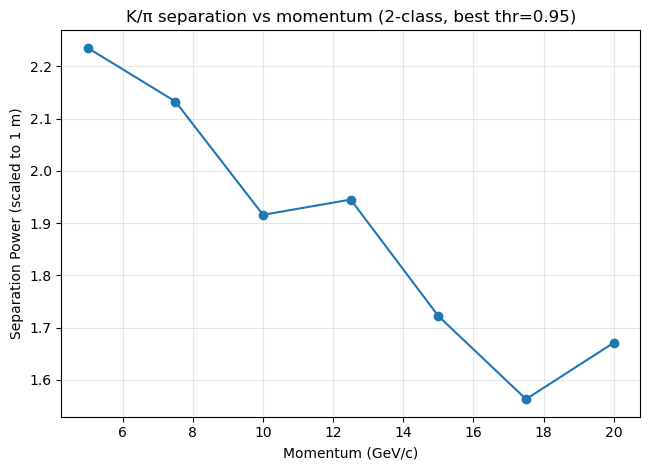

Saved: results/final_eval_threshold_scan/sep_curve_2class_best.png


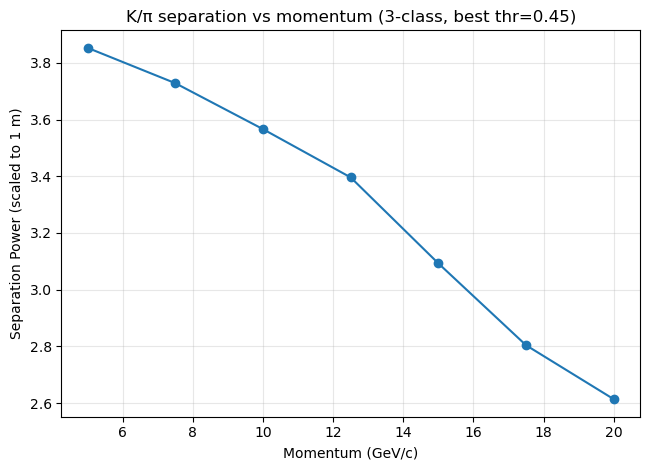

Saved: results/final_eval_threshold_scan/sep_curve_3class_best.png


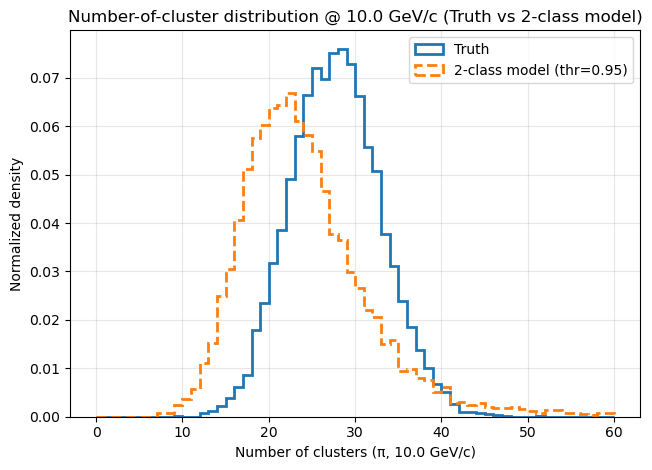

Saved: results/final_eval_threshold_scan/fig8_like_truth_vs_2class_bestthr_0.95.png


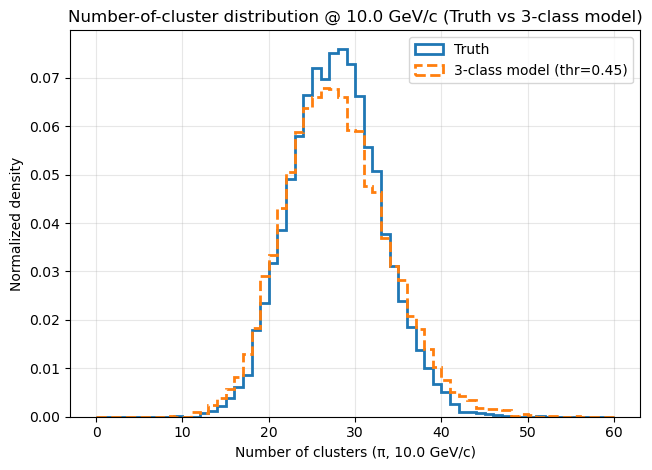

Saved: results/final_eval_threshold_scan/fig8_like_truth_vs_3class_bestthr_0.45.png

✅ Done. Outputs in: results/final_eval_threshold_scan


In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0..batch_4

# checkpoints
BIN2_BEST_PT   = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"         # 2-class model
TRI3_BEST_PT   = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"     # 3-class model

OUTDIR = "results/final_eval_threshold_scan"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

# truth tag values (your dataset)
TAG_BG   = 0
TAG_PRI  = 1
TAG_SEC  = 2

# separation power scaling to 1m track (paper uses 18mm cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

# Paper: separation optimization uses fixed momenta
# (they list 5, 7.5, 10, 12.5, 15, 17.5, 20 GeV/c)
OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]

# threshold scan grid
THR_GRID = np.linspace(0.05, 0.95, 19)  # 0.05,0.10,...0.95

# Fig.8 histogram styling
HIST_BINS = 60
HIST_RANGE = (0, 60)
FIG8_MOM = 10.0   # paper Fig.8 is 10 GeV/c pion sample

# Y-axis normalization mode:
#   "counts"  -> raw event counts (your current)
#   "density" -> area=1 (shape-only comparison)
#   "peak1"   -> normalize each curve so its max bin height = 1
Y_NORM_MODE = "density"


# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1) -> conv wants (B, C, T)
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)   # (B, T, 128)
            fc = self.fc1(spk4)            # (B, T, 128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)      # (B, T, num_classes)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)


# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "min/max:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    # If they look 1-based, convert
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    """
    Dense per-timestep labels for each waveform.
    Default label is background.
    """
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)

    valid = (tag_times >= 0) & (tag_times < T)
    rows, cols = np.where(valid)
    t = tag_times[rows, cols]
    y[rows, t] = tag_values[rows, cols].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use=None):
    """
    Returns (moms_used, S_array) for the momenta you want.
    """
    if moms_to_use is None:
        moms_to_use = sorted(np.unique(mom).tolist())

    moms_used, S = [], []
    for p in moms_to_use:
        mk = (np.isclose(mom, p)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p)) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def _normalize_histmode(mode):
    mode = mode.lower().strip()
    if mode not in ("counts", "density", "peak1"):
        raise ValueError("Y_NORM_MODE must be one of: counts, density, peak1")
    return mode

def plot_fig8_overlay(truth_counts, model_counts, mom, pid, model_label, thr, out_png):
    """
    Fig.8-like: 10 GeV/c pion sample.
    """
    mode = _normalize_histmode(Y_NORM_MODE)

    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xt = truth_counts[mask].astype(np.int32)
    xm = model_counts[mask].astype(np.int32)

    if xt.size == 0:
        print("No events found for pid=PION and mom=10.0. Check np.unique(mom).")
        return

    plt.figure(figsize=(6.6, 4.8))

    if mode == "counts":
        plt.hist(xt, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.0, label="Truth")
        plt.hist(xm, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.0, linestyle="--",
                 label=f"{model_label} (thr={thr:.2f})")
        plt.ylabel("Events")

    elif mode == "density":
        plt.hist(xt, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.0, density=True, label="Truth")
        plt.hist(xm, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.0, linestyle="--",
                 density=True, label=f"{model_label} (thr={thr:.2f})")
        plt.ylabel("Normalized density")

    elif mode == "peak1":
        # manually normalize by max bin height
        ht, edges = np.histogram(xt, bins=HIST_BINS, range=HIST_RANGE)
        hm, _     = np.histogram(xm, bins=HIST_BINS, range=HIST_RANGE)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ht = ht / (ht.max() + 1e-12)
        hm = hm / (hm.max() + 1e-12)
        plt.step(centers, ht, where="mid", linewidth=2.0, label="Truth")
        plt.step(centers, hm, where="mid", linewidth=2.0, linestyle="--",
                 label=f"{model_label} (thr={thr:.2f})")
        plt.ylabel("Normalized (peak=1)")

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c (Truth vs {model_label})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_sep_power(moms, S_scaled, title, out_png):
    plt.figure(figsize=(6.6, 4.8))
    plt.plot(moms, S_scaled, marker="o")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def infer_counts_scan_thresholds(
    model,
    wf_i,
    scaler,
    device,
    thr_grid,
    which_model,
    use_bg_first=False,
    bg_purity_target=0.90,
    y_dense_truth=None,
):
    """
    Returns:
      counts_by_thr: dict(thr -> counts[N])
      extra: dict with bg_thr if bg_first enabled

    For 3-class model:
      p_bg = probs[...,0], p_pri = probs[...,1], p_sec = probs[...,2]
      cluster count is #t with p_pri >= thr (optionally with a BG filter first).

    BG-first option (Dylan suggestion):
      - choose bg_thr such that predicted-BG purity ~= bg_purity_target
      - "remove" timesteps predicted as BG (p_bg >= bg_thr)
      - then apply p_pri threshold on remaining timesteps
    """
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}
    extra = {}

    # Prepare data
    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    # If bg-first is enabled, we need to estimate bg_thr.
    # We do this from a small subsample for speed (and stability).
    bg_thr = None
    if use_bg_first:
        if which_model != "3class":
            raise ValueError("BG-first only makes sense for the 3-class model.")
        if y_dense_truth is None:
            raise ValueError("BG-first requested but y_dense_truth is None.")
        # subsample ~50k events max
        rng = np.random.default_rng(0)
        idx = rng.choice(N, size=min(N, 50000), replace=False)
        # run quick forward to get p_bg on subsample (no scan yet)
        xb = x_t[idx].to(device)
        with torch.inference_mode():
            if use_amp:
                with torch.cuda.amp.autocast(True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)
        p_bg = probs[..., 0].detach().cpu().numpy().reshape(-1)
        truth_bg = (y_dense_truth[idx] == TAG_BG).reshape(-1)

        # scan bg threshold for desired predicted-BG purity
        # predicted BG = p_bg >= thr
        cand = np.linspace(0.05, 0.99, 50)
        best = None
        for thr in cand:
            pred_bg = (p_bg >= thr)
            tp = np.sum(pred_bg & truth_bg)
            fp = np.sum(pred_bg & (~truth_bg))
            if tp + fp == 0:
                continue
            purity = tp / (tp + fp)
            # choose smallest thr that reaches target purity (keeps more BG removed)
            if purity >= bg_purity_target:
                best = thr
                break
        bg_thr = best if best is not None else 0.95  # fallback
        extra["bg_thr"] = float(bg_thr)
        extra["bg_purity_target"] = float(bg_purity_target)
        print(f"[3-class] BG-first enabled: using bg_thr={bg_thr:.3f} (target purity={bg_purity_target:.3f})")

    # Main scan
    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=f"Inference+scan ({which_model})", mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.cuda.amp.autocast(True):
                    probs = torch.softmax(model(xb), dim=-1)  # (B,T,C)
            else:
                probs = torch.softmax(model(xb), dim=-1)

            # primary probability (for both models)
            # 2-class: index 1 = "primary"
            # 3-class: index 1 = "primary"
            p_pri = probs[..., 1]  # (B,T)

            if use_bg_first:
                p_bg = probs[..., 0]  # (B,T)
                keep = (p_bg < bg_thr)  # keep non-background timesteps
            else:
                keep = None

            for thr in thr_grid:
                if keep is None:
                    counts = (p_pri >= thr).sum(dim=1)
                else:
                    counts = ((p_pri >= thr) & keep).sum(dim=1)
                out[thr][idx0:idx0+bs] = counts.to(torch.int32).cpu().numpy()

            idx0 += bs

    return out, extra

def pick_best_threshold_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt):
    """
    For each threshold, compute separation power at the fixed momenta,
    scale to 1m, and take average across available momenta.
    """
    best_thr, best_score = None, -1e9
    curve = {}

    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_to_use=moms_for_opt)
        if S.size == 0:
            continue
        S_scaled = S * SCALE_TO_1M
        score = float(np.mean(S_scaled))
        curve[thr] = (moms_used, S_scaled, score)

        if score > best_score:
            best_score = score
            best_thr = thr

    return best_thr, best_score, curve


# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    # Dense truth labels per timestep, then truth primary counts per event
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)
    print("Truth primary-count mean:", float(truth_counts.mean()))
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ------------------------------------------------------------
    # Load models
    # ------------------------------------------------------------
    model_2class = ConvSNN_Deep(num_classes=2).to(device)
    model_2class.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_3class = ConvSNN_Deep(num_classes=3).to(device)
    model_3class.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ------------------------------------------------------------
    # 2-class scan
    # ------------------------------------------------------------
    counts2, extra2 = infer_counts_scan_thresholds(
        model_2class, wf_i, scaler, device, THR_GRID,
        which_model="2class",
        use_bg_first=False,
        y_dense_truth=None
    )
    best_thr2, best_score2, curve2 = pick_best_threshold_by_avg_sep(counts2, mom, pid, OPT_MOMENTA)
    print(f"[2-class] Best thr = {best_thr2:.2f}  avg sep(1m) = {best_score2:.4f}")

    # ------------------------------------------------------------
    # 3-class scan (optionally BG-first)
    # ------------------------------------------------------------
    USE_BG_FIRST = False            # <-- set True to try Dylan's suggestion
    BG_PURITY_TARGET = 0.8986       # paper peak-finding purity number; decent starting point

    counts3, extra3 = infer_counts_scan_thresholds(
        model_3class, wf_i, scaler, device, THR_GRID,
        which_model="3class",
        use_bg_first=USE_BG_FIRST,
        bg_purity_target=BG_PURITY_TARGET,
        y_dense_truth=y_dense
    )
    best_thr3, best_score3, curve3 = pick_best_threshold_by_avg_sep(counts3, mom, pid, OPT_MOMENTA)
    print(f"[3-class] Best thr = {best_thr3:.2f}  avg sep(1m) = {best_score3:.4f}")
    if USE_BG_FIRST:
        print(f"[3-class] BG-first info:", extra3)

    # ------------------------------------------------------------
    # Plot: separation curves at best thresholds (for visibility)
    # ------------------------------------------------------------
    moms2, S2 = separation_vs_momentum(counts2[best_thr2], mom, pid, moms_to_use=OPT_MOMENTA)
    moms3, S3 = separation_vs_momentum(counts3[best_thr3], mom, pid, moms_to_use=OPT_MOMENTA)

    plot_sep_power(
        moms2, S2 * SCALE_TO_1M,
        title=f"K/π separation vs momentum (2-class, best thr={best_thr2:.2f})",
        out_png=os.path.join(OUTDIR, "sep_curve_2class_best.png")
    )
    plot_sep_power(
        moms3, S3 * SCALE_TO_1M,
        title=f"K/π separation vs momentum (3-class, best thr={best_thr3:.2f})",
        out_png=os.path.join(OUTDIR, "sep_curve_3class_best.png")
    )

    # ------------------------------------------------------------
    # Fig.8-like: use the optimized threshold (as paper does)
    # ------------------------------------------------------------
    out_png = os.path.join(OUTDIR, f"fig8_like_truth_vs_2class_bestthr_{best_thr2:.2f}.png")
    plot_fig8_overlay(
        truth_counts, counts2[best_thr2], mom, pid,
        model_label="2-class model",
        thr=best_thr2,
        out_png=out_png
    )

    out_png = os.path.join(OUTDIR, f"fig8_like_truth_vs_3class_bestthr_{best_thr3:.2f}.png")
    plot_fig8_overlay(
        truth_counts, counts3[best_thr3], mom, pid,
        model_label=("3-class model (BG-first)" if USE_BG_FIRST else "3-class model"),
        thr=best_thr3,
        out_png=out_png
    )

    # Save the chosen thresholds so you can report them easily
    np.savez(
        os.path.join(OUTDIR, "best_thresholds.npz"),
        best_thr_2class=float(best_thr2),
        best_thr_3class=float(best_thr3),
        best_avg_sep_2class=float(best_score2),
        best_avg_sep_3class=float(best_score3),
        used_bg_first=bool(USE_BG_FIRST),
        bg_thr=float(extra3.get("bg_thr", np.nan)) if isinstance(extra3, dict) else np.nan
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"

# Evaluate on multiple batches
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0 ... batch_4

# Model checkpoints (your naming)
BEST_PT_2CLASS = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"
BEST_PT_3CLASS = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"

OUTDIR = "results/final_eval_2class_3class_all_batches"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256          # increase if you have room
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

PRIMARY_TAG_VALUE = 1

# thresholds to plot on separation curves (paper-style: 3 lines)
COUNT_THRESHOLDS = [0.10, 0.26, 0.40]

# Fig.8 uses the "best" threshold chosen by maximizing separation power
# (we'll compute this from a scan)
THR_SCAN = np.linspace(0.0, 1.0, 201)   # scan granularity

# scaling to 1 m track length (assumption: 18 mm per cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)  # sqrt(1000/18)

# histogram settings
HIST_BINS = 60
HIST_RANGE = (0, 60)

FIG8_MOM = 10.0  # paper plot shown at 10 GeV/c

# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1) -> conv wants (B, C, T)
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)   # (B, T, 128)
            fc = self.fc1(spk4)            # (B, T, 128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)      # (B, T, num_classes)
            spk_out.append(out)

        # average over SNN steps -> (B, T, C)
        return torch.stack(spk_out, dim=2).mean(dim=2)

# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()))
    print("  mom unique (sample):", np.unique(mom)[:10], "..." if np.unique(mom).size > 10 else "")
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()

    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "mom unique count:", np.unique(mom).size)
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_truth_binary_from_tags(tag_times, tag_values, T, positive_value):
    N, K = tag_times.shape
    y = np.zeros((N, T), dtype=np.uint8)

    valid = (tag_times >= 0) & (tag_times < T)
    is_pos = valid & (tag_values == positive_value)
    rows, cols = np.where(is_pos)
    t = tag_times[rows, cols]
    y[rows, t] = 1
    return y

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid):
    # NOTE: if mom is continuous, this will create many points.
    # We'll bin momenta later for "average across pT".
    moms = sorted(np.unique(mom).tolist())
    moms_used, S = [], []
    for p in moms:
        mk = (mom == p) & (pid == PID_KAON)
        mpi = (mom == p) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)

        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def compute_counts_from_probs(p_primary, thresholds):
    # p_primary: (B,T) torch tensor on GPU
    out = {}
    for thr in thresholds:
        out[thr] = (p_primary >= thr).sum(dim=1).to(torch.int32)
    return out

def infer_counts_for_thresholds(model, wf_i, scaler, device, thresholds, label):
    """
    Efficient inference:
    - does NOT store full probs
    - returns dict {thr: counts (N,)}
    """
    N, T = wf_i.shape

    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    thresholds = list(sorted(set([float(t) for t in thresholds])))
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thresholds}

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=label, mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.cuda.amp.autocast(True):
                    logits = model(xb)  # (B,T,C)
                    probs = torch.softmax(logits, dim=-1)
                    p_primary = probs[..., 1]  # (B,T)  <-- CUT ON PRIMARY NODE
            else:
                logits = model(xb)
                probs = torch.softmax(logits, dim=-1)
                p_primary = probs[..., 1]

            counts_dict = compute_counts_from_probs(p_primary, thresholds)
            for thr in thresholds:
                out[thr][idx0:idx0+bs] = counts_dict[thr].cpu().numpy()

            idx0 += bs

    return out

def find_best_threshold_by_avg_sep(counts_dict, mom, pid, thr_list):
    """
    For each threshold:
      - compute separation vs momentum
      - take average separation across momentum points (unweighted mean)
      - pick argmax

    Returns: best_thr, table (thr -> avg_sep_scaled)
    """
    avg_sep_scaled = {}
    for thr in thr_list:
        moms_used, S = separation_vs_momentum(counts_dict[thr], mom, pid)
        if S.size == 0:
            avg_sep_scaled[thr] = -np.inf
            continue
        avg_sep_scaled[thr] = float(np.mean(S) * SCALE_TO_1M)

    best_thr = max(avg_sep_scaled.keys(), key=lambda t: avg_sep_scaled[t])
    return best_thr, avg_sep_scaled

def plot_fig8_truth_vs_model_counts(truth_counts, model_counts, mom, pid, model_label, thr, out_png):
    """
    Paper-style Fig.8:
    - Use raw event counts (y-axis = Events)
    - Only pions at 10 GeV/c
    """
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xt = truth_counts[mask].astype(np.int32)
    xm = model_counts[mask].astype(np.int32)

    if xt.size == 0:
        print(f"No events for pid=PION and mom={FIG8_MOM}.")
        return

    plt.figure(figsize=(6.6, 4.8))
    plt.hist(xt, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.0, label="Truth")
    plt.hist(xm, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.0, linestyle="--",
             label=f"{model_label} (thr={thr:.2f})")

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Events")  # paper-style
    plt.title("Number-of-cluster distribution")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_sep_power_curves(moms, curves_dict, title, out_png):
    plt.figure(figsize=(6.6, 4.8))
    for lab, y in curves_dict.items():
        plt.plot(moms, y, marker="o", label=lab)

    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_thr_scan(avg_sep_scaled, title, out_png):
    thrs = np.array(sorted(avg_sep_scaled.keys()), dtype=np.float64)
    vals = np.array([avg_sep_scaled[t] for t in thrs], dtype=np.float64)

    plt.figure(figsize=(6.6, 4.2))
    plt.plot(thrs, vals, marker="o")
    plt.xlabel("Primary probability threshold")
    plt.ylabel("Avg separation power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", out_png)

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    # Truth counts per waveform (clusters)
    y_true_primary = build_truth_binary_from_tags(tag_times, tag_values, T, PRIMARY_TAG_VALUE)
    truth_counts = y_true_primary.sum(axis=1).astype(np.int32)
    print("Overall TRUE primary fraction:", float(y_true_primary.mean()))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ------------------------------------------------------------
    # Load models
    # ------------------------------------------------------------
    model_2class = ConvSNN_Deep(num_classes=2).to(device)
    st2 = torch.load(BEST_PT_2CLASS, map_location=device, weights_only=True)
    model_2class.load_state_dict(st2)

    model_3class = ConvSNN_Deep(num_classes=3).to(device)
    st3 = torch.load(BEST_PT_3CLASS, map_location=device, weights_only=True)
    model_3class.load_state_dict(st3)

    # thresholds needed:
    # - scan thresholds to choose best for Fig.8
    # - fixed thresholds for Fig.9 comparison lines
    THRS_NEEDED_2 = sorted(set(list(THR_SCAN) + COUNT_THRESHOLDS))
    THRS_NEEDED_3 = sorted(set(list(THR_SCAN) + COUNT_THRESHOLDS))

    # ------------------------------------------------------------
    # Inference -> counts for all needed thresholds
    # (cut is always applied to PRIMARY node prob)
    # ------------------------------------------------------------
    counts_2 = infer_counts_for_thresholds(
        model_2class, wf_i, scaler, device, THRS_NEEDED_2, label="Inference 2-class (counts)"
    )
    counts_3 = infer_counts_for_thresholds(
        model_3class, wf_i, scaler, device, THRS_NEEDED_3, label="Inference 3-class (counts)"
    )

    # ------------------------------------------------------------
    # Choose best threshold by maximizing average separation power
    # (scaled to 1m) across momentum points
    # ------------------------------------------------------------
    best_thr_2, avgsep_2 = find_best_threshold_by_avg_sep(counts_2, mom, pid, THR_SCAN)
    best_thr_3, avgsep_3 = find_best_threshold_by_avg_sep(counts_3, mom, pid, THR_SCAN)

    print(f"[2-class] Best thr by avg sep: {best_thr_2:.3f} | avg sep (scaled)={avgsep_2[best_thr_2]:.4f}")
    print(f"[3-class] Best thr by avg sep: {best_thr_3:.3f} | avg sep (scaled)={avgsep_3[best_thr_3]:.4f}")

    # Save scan plots (helpful for discussion)
    plot_thr_scan(
        avgsep_2,
        "Threshold scan (2-class): avg separation power (scaled)",
        os.path.join(OUTDIR, "thr_scan_2class_avg_sep_scaled.png"),
    )
    plot_thr_scan(
        avgsep_3,
        "Threshold scan (3-class): avg separation power (scaled)",
        os.path.join(OUTDIR, "thr_scan_3class_avg_sep_scaled.png"),
    )

    # ------------------------------------------------------------
    # Fig.8-like: Truth vs model at BEST threshold
    # ------------------------------------------------------------
    out_png = os.path.join(OUTDIR, f"fig8_truth_vs_2class_bestthr{best_thr_2:.3f}_pion10gev.png")
    plot_fig8_truth_vs_model_counts(
        truth_counts, counts_2[float(best_thr_2)], mom, pid, "2-class", float(best_thr_2), out_png
    )

    out_png = os.path.join(OUTDIR, f"fig8_truth_vs_3class_bestthr{best_thr_3:.3f}_pion10gev.png")
    plot_fig8_truth_vs_model_counts(
        truth_counts, counts_3[float(best_thr_3)], mom, pid, "3-class", float(best_thr_3), out_png
    )

    # ------------------------------------------------------------
    # Fig.9-like: Separation power vs momentum (3 curves for 0.10/0.26/0.40)
    # 2-class
    # ------------------------------------------------------------
    curves_2 = {}
    moms_ref = None
    for thr in COUNT_THRESHOLDS:
        moms_used, S = separation_vs_momentum(counts_2[thr], mom, pid)
        curves_2[f"thr={thr:.2f}"] = S * SCALE_TO_1M
        moms_ref = moms_used

    plot_sep_power_curves(
        moms_ref, curves_2,
        "K/π separation power vs momentum (2-class, scaled to 1 m)",
        os.path.join(OUTDIR, "fig9_sep_vs_mom_2class_scaled_1m.png"),
    )

    # 3-class
    curves_3 = {}
    moms_ref = None
    for thr in COUNT_THRESHOLDS:
        moms_used, S = separation_vs_momentum(counts_3[thr], mom, pid)
        curves_3[f"thr={thr:.2f}"] = S * SCALE_TO_1M
        moms_ref = moms_used

    plot_sep_power_curves(
        moms_ref, curves_3,
        "K/π separation power vs momentum (3-class, scaled to 1 m)",
        os.path.join(OUTDIR, "fig9_sep_vs_mom_3class_scaled_1m.png"),
    )

    print("\n✅ Done. Outputs in:", OUTDIR)
    print("Notes:")
    print(" - Fig.8 uses BEST threshold from scan (avg separation over momentum points).")
    print(" - Fig.9 shows three curves for thr=0.10, 0.26, 0.40 (paper-style).")
    print(" - For 3-class, cuts are applied ONLY to the PRIMARY output node (class index 1).")

if __name__ == "__main__":
    main()


Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0
  mom unique (sample): [ 7.5 10.  12.5 15.  17.5 20. ] 
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5
  mom unique (sample): [ 5.   7.5 17.5] 
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203
  mom unique (sample): [0.20001669 0.20007403 0.20010513 0.20061393 0.20071284 0.20085068
 0.20102552 0.20192254 0.20200709 0.20218861] ...
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (1000

/tmp/ipykernel_1716/2683521099.py:233: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):
Inference 2-class (counts):   1%|▏         | 25/1719 [00:15<16:15,  1.74it/s]

Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 19.99993896484375
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_4.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001369714736938 19.999898910522

/tmp/ipykernel_292/166140518.py:386: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):
Inference+scan (2class): 100%|██████████| 1719/1719 [16:57<00:00,  1.69it/s]


[2-class] Best thr = 0.95  avg sep(1m) = 1.8836


/tmp/ipykernel_292/166140518.py:386: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):
Inference+scan (3class): 100%|██████████| 1719/1719 [17:00<00:00,  1.68it/s]


[3-class] Best thr = 0.45  avg sep(1m) = 3.2933


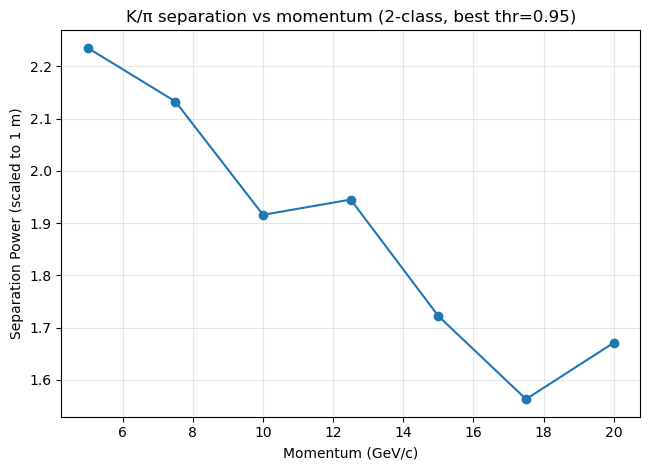

Saved: results/final_eval_threshold_scan/sep_curve_2class_best.png


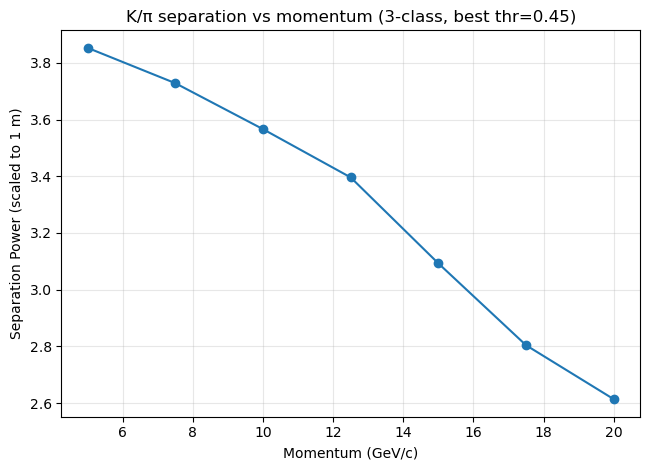

Saved: results/final_eval_threshold_scan/sep_curve_3class_best.png


KeyError: 0.26

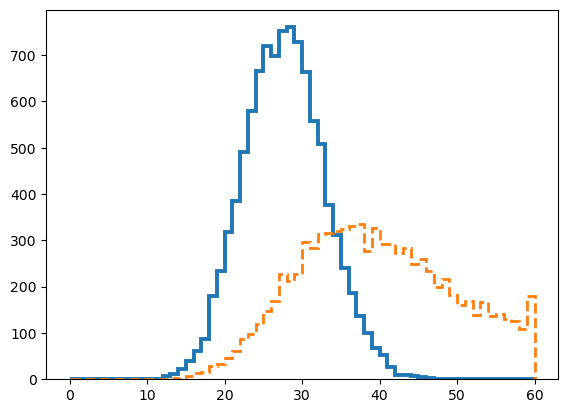

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0..batch_4

# checkpoints
BIN2_BEST_PT   = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"         # 2-class model
TRI3_BEST_PT   = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"     # 3-class model

OUTDIR = "results/final_eval_threshold_scan"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

# truth tag values (your dataset)
TAG_BG   = 0
TAG_PRI  = 1
TAG_SEC  = 2

# separation power scaling to 1m track (paper uses 18mm cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

# Paper: separation optimization uses fixed momenta
# (they list 5, 7.5, 10, 12.5, 15, 17.5, 20 GeV/c)
OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]

# threshold scan grid (must include paper thresholds & best thresholds)
THR_GRID = np.linspace(0.05, 0.95, 19)  # 0.05,0.10,...0.95

# Paper comparison thresholds for Fig.8-style plots
PAPER_THR_LIST = [0.10, 0.26, 0.40]

# Fig.8 histogram styling
HIST_BINS = 60
HIST_RANGE = (0, 60)
FIG8_MOM = 10.0   # paper Fig.8 is 10 GeV/c pion sample

# Paper requires y-axis to be "Number of waveforms", so use counts
Y_NORM_MODE = "counts"


# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1) -> conv wants (B, C, T)
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)   # (B, T, 128)
            fc = self.fc1(spk4)            # (B, T, 128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)      # (B, T, num_classes)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)


# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "min/max:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    # If they look 1-based, convert
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    """
    Dense per-timestep labels for each waveform.
    Default label is background.
    """
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)

    valid = (tag_times >= 0) & (tag_times < T)
    rows, cols = np.where(valid)
    t = tag_times[rows, cols]
    y[rows, t] = tag_values[rows, cols].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use=None):
    """
    Returns (moms_used, S_array) for the momenta you want.
    """
    if moms_to_use is None:
        moms_to_use = sorted(np.unique(mom).tolist())

    moms_used, S = [], []
    for p in moms_to_use:
        mk = (np.isclose(mom, p)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p)) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_sep_power(moms, S_scaled, title, out_png):
    plt.figure(figsize=(6.6, 4.8))
    plt.plot(moms, S_scaled, marker="o")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_fig8_overlay_multi_thr(
    truth_counts,
    counts_by_thr,
    mom,
    pid,
    model_label,
    thr_list,
    best_thr,
    out_png,
):
    """
    Fig.8-like plot:
    - 10 GeV/c pion sample
    - Truth + fixed paper thresholds (0.10, 0.26, 0.40) + best thr
    - Y-axis: Number of waveforms
    """

    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xt = truth_counts[mask].astype(np.int32)

    if xt.size == 0:
        print("No events found for pid=PION and mom=10.0.")
        return

    plt.figure(figsize=(6.6, 4.8))

    # Truth
    plt.hist(
        xt,
        bins=HIST_BINS,
        range=HIST_RANGE,
        histtype="step",
        linewidth=2.8,
        label="Truth",
    )

    # Paper thresholds
    for thr in thr_list:
        xm = counts_by_thr[thr][mask].astype(np.int32)
        plt.hist(
            xm,
            bins=HIST_BINS,
            range=HIST_RANGE,
            histtype="step",
            linewidth=2.0,
            linestyle="--",
            label=f"{model_label} (thr={thr:.2f})",
        )

    # Best threshold (this work)
    xm_best = counts_by_thr[best_thr][mask].astype(np.int32)
    plt.hist(
        xm_best,
        bins=HIST_BINS,
        range=HIST_RANGE,
        histtype="step",
        linewidth=2.5,
        linestyle="-.",
        label=f"{model_label} (best thr={best_thr:.2f})",
    )

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def infer_counts_scan_thresholds(
    model,
    wf_i,
    scaler,
    device,
    thr_grid,
    which_model,
    use_bg_first=False,
    bg_purity_target=0.90,
    y_dense_truth=None,
):
    """
    Returns:
      counts_by_thr: dict(thr -> counts[N])
      extra: dict with bg_thr if bg_first enabled

    For 3-class model:
      p_bg = probs[...,0], p_pri = probs[...,1], p_sec = probs[...,2]
      cluster count is #t with p_pri >= thr (optionally with a BG filter first).

    BG-first option:
      - choose bg_thr such that predicted-BG purity ~= bg_purity_target
      - remove timesteps predicted as BG (p_bg >= bg_thr)
      - then apply p_pri threshold on remaining timesteps
    """
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}
    extra = {}

    # Prepare data
    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    # BG-first threshold estimation (optional)
    bg_thr = None
    if use_bg_first:
        if which_model != "3class":
            raise ValueError("BG-first only makes sense for the 3-class model.")
        if y_dense_truth is None:
            raise ValueError("BG-first requested but y_dense_truth is None.")

        rng = np.random.default_rng(0)
        idx = rng.choice(N, size=min(N, 50000), replace=False)

        xb = x_t[idx].to(device)
        with torch.inference_mode():
            if use_amp:
                with torch.cuda.amp.autocast(True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

        p_bg = probs[..., 0].detach().cpu().numpy().reshape(-1)
        truth_bg = (y_dense_truth[idx] == TAG_BG).reshape(-1)

        cand = np.linspace(0.05, 0.99, 50)
        best = None
        for thr in cand:
            pred_bg = (p_bg >= thr)
            tp = np.sum(pred_bg & truth_bg)
            fp = np.sum(pred_bg & (~truth_bg))
            if tp + fp == 0:
                continue
            purity = tp / (tp + fp)
            if purity >= bg_purity_target:
                best = thr
                break

        bg_thr = best if best is not None else 0.95
        extra["bg_thr"] = float(bg_thr)
        extra["bg_purity_target"] = float(bg_purity_target)
        print(f"[3-class] BG-first enabled: using bg_thr={bg_thr:.3f} (target purity={bg_purity_target:.3f})")

    # Main scan
    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=f"Inference+scan ({which_model})", mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.cuda.amp.autocast(True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

            p_pri = probs[..., 1]  # (B,T)

            if use_bg_first:
                p_bg = probs[..., 0]
                keep = (p_bg < bg_thr)
            else:
                keep = None

            for thr in thr_grid:
                if keep is None:
                    counts = (p_pri >= thr).sum(dim=1)
                else:
                    counts = ((p_pri >= thr) & keep).sum(dim=1)
                out[thr][idx0:idx0+bs] = counts.to(torch.int32).cpu().numpy()

            idx0 += bs

    return out, extra

def pick_best_threshold_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt):
    """
    For each threshold, compute separation power at fixed momenta,
    scale to 1m, and take average across available momenta.
    """
    best_thr, best_score = None, -1e9
    curve = {}

    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_to_use=moms_for_opt)
        if S.size == 0:
            continue
        S_scaled = S * SCALE_TO_1M
        score = float(np.mean(S_scaled))
        curve[thr] = (moms_used, S_scaled, score)

        if score > best_score:
            best_score = score
            best_thr = thr

    return best_thr, best_score, curve


# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    # Dense truth labels per timestep, then truth primary counts per event
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)
    print("Truth primary-count mean:", float(truth_counts.mean()))
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ------------------------------------------------------------
    # Load models
    # ------------------------------------------------------------
    model_2class = ConvSNN_Deep(num_classes=2).to(device)
    model_2class.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_3class = ConvSNN_Deep(num_classes=3).to(device)
    model_3class.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ------------------------------------------------------------
    # 2-class scan
    # ------------------------------------------------------------
    counts2, _ = infer_counts_scan_thresholds(
        model_2class, wf_i, scaler, device, THR_GRID,
        which_model="2class",
        use_bg_first=False,
        y_dense_truth=None
    )
    best_thr2, best_score2, _ = pick_best_threshold_by_avg_sep(counts2, mom, pid, OPT_MOMENTA)
    print(f"[2-class] Best thr = {best_thr2:.2f}  avg sep(1m) = {best_score2:.4f}")

    # ------------------------------------------------------------
    # 3-class scan (optionally BG-first)
    # ------------------------------------------------------------
    USE_BG_FIRST = False
    BG_PURITY_TARGET = 0.8986

    counts3, extra3 = infer_counts_scan_thresholds(
        model_3class, wf_i, scaler, device, THR_GRID,
        which_model="3class",
        use_bg_first=USE_BG_FIRST,
        bg_purity_target=BG_PURITY_TARGET,
        y_dense_truth=y_dense
    )
    best_thr3, best_score3, _ = pick_best_threshold_by_avg_sep(counts3, mom, pid, OPT_MOMENTA)
    print(f"[3-class] Best thr = {best_thr3:.2f}  avg sep(1m) = {best_score3:.4f}")
    if USE_BG_FIRST:
        print(f"[3-class] BG-first info:", extra3)

    # ------------------------------------------------------------
    # Plot: separation curves at best thresholds
    # ------------------------------------------------------------
    moms2, S2 = separation_vs_momentum(counts2[best_thr2], mom, pid, moms_to_use=OPT_MOMENTA)
    moms3, S3 = separation_vs_momentum(counts3[best_thr3], mom, pid, moms_to_use=OPT_MOMENTA)

    plot_sep_power(
        moms2, S2 * SCALE_TO_1M,
        title=f"K/π separation vs momentum (2-class, best thr={best_thr2:.2f})",
        out_png=os.path.join(OUTDIR, "sep_curve_2class_best.png")
    )
    plot_sep_power(
        moms3, S3 * SCALE_TO_1M,
        title=f"K/π separation vs momentum (3-class, best thr={best_thr3:.2f})",
        out_png=os.path.join(OUTDIR, "sep_curve_3class_best.png")
    )

    # ------------------------------------------------------------
    # Fig.8-like plots — PAPER thresholds + OUR best threshold
    # ------------------------------------------------------------
    plot_fig8_overlay_multi_thr(
        truth_counts,
        counts2,
        mom,
        pid,
        model_label="2-class model",
        thr_list=PAPER_THR_LIST,
        best_thr=best_thr2,
        out_png=os.path.join(OUTDIR, "fig8_like_2class_paper_plus_best.png"),
    )

    plot_fig8_overlay_multi_thr(
        truth_counts,
        counts3,
        mom,
        pid,
        model_label=("3-class model (BG-first)" if USE_BG_FIRST else "3-class model"),
        thr_list=PAPER_THR_LIST,
        best_thr=best_thr3,
        out_png=os.path.join(OUTDIR, "fig8_like_3class_paper_plus_best.png"),
    )

    # Save chosen thresholds
    np.savez(
        os.path.join(OUTDIR, "best_thresholds.npz"),
        best_thr_2class=float(best_thr2),
        best_thr_3class=float(best_thr3),
        best_avg_sep_2class=float(best_score2),
        best_avg_sep_3class=float(best_score3),
        used_bg_first=bool(USE_BG_FIRST),
        bg_thr=float(extra3.get("bg_thr", np.nan)) if isinstance(extra3, dict) else np.nan
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 19.99993896484375
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_4.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001369714736938 19.999898910522

Inference+scan (2class): 100%|██████████| 1719/1719 [16:58<00:00,  1.69it/s]


[2-class] Best thr = 0.95  avg sep(1m) = 1.8836


Inference+scan (3class): 100%|██████████| 1719/1719 [17:01<00:00,  1.68it/s]


[3-class] Best thr = 0.45  avg sep(1m) = 3.2933


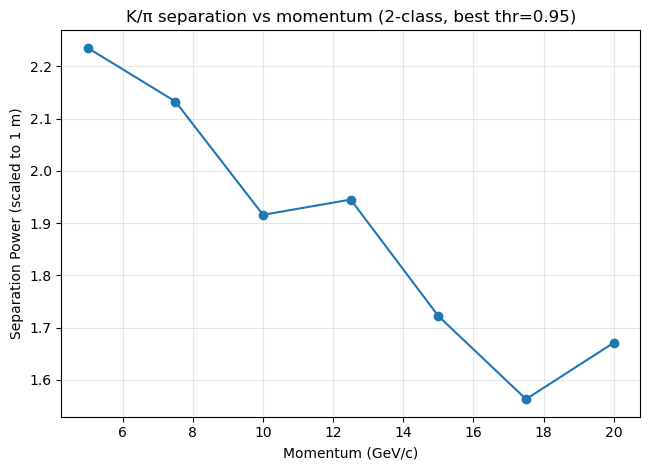

Saved: results/final_eval_threshold_scan/sep_curve_2class_best.png


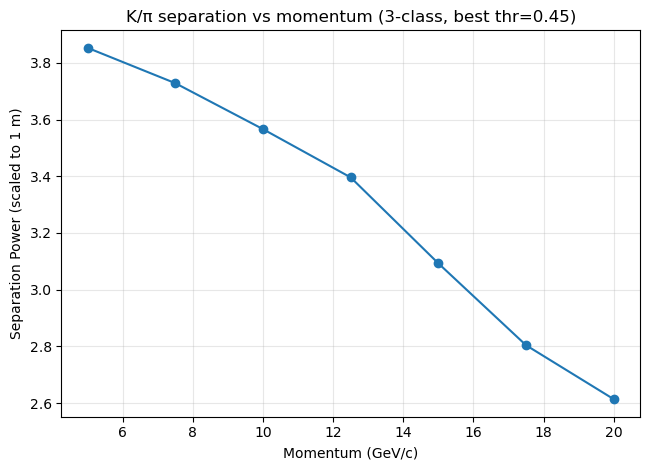

Saved: results/final_eval_threshold_scan/sep_curve_3class_best.png


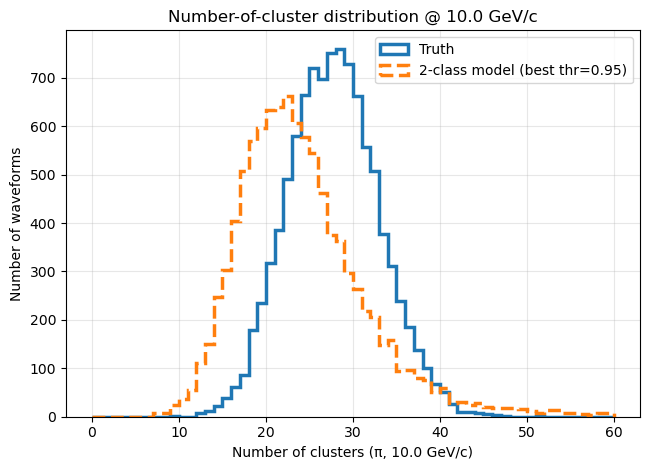

Saved: results/final_eval_threshold_scan/fig8_like_2class_bestthr_0.95.png


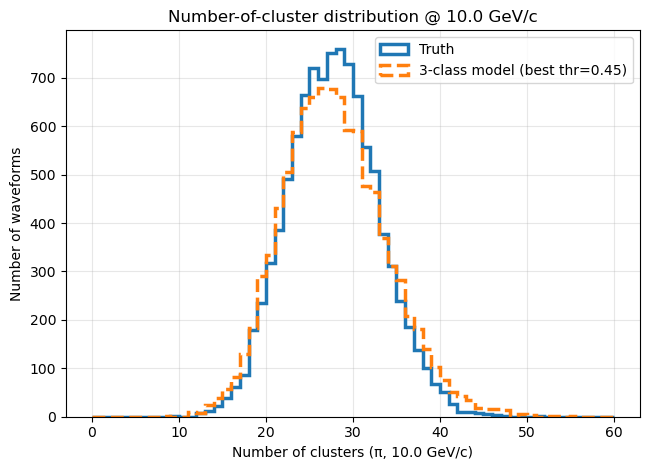

Saved: results/final_eval_threshold_scan/fig8_like_3class_bestthr_0.45.png

✅ Done. Outputs in: results/final_eval_threshold_scan


In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0..batch_4

# checkpoints
BIN2_BEST_PT   = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"         # 2-class model
TRI3_BEST_PT   = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"     # 3-class model

OUTDIR = "results/final_eval_threshold_scan"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

# truth tag values (your dataset)
TAG_BG   = 0
TAG_PRI  = 1
TAG_SEC  = 2

# separation power scaling to 1m track (paper uses 18mm cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

# Paper: separation optimization uses fixed momenta
OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]

# threshold scan grid
THR_GRID = np.linspace(0.05, 0.95, 19)  # 0.05,0.10,...0.95

# Fig.8 histogram styling
HIST_BINS = 60
HIST_RANGE = (0, 60)
FIG8_MOM = 10.0   # paper Fig.8 is 10 GeV/c pion sample


# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1) -> conv wants (B, C, T)
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)   # (B, T, 128)
            fc = self.fc1(spk4)            # (B, T, 128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)      # (B, T, num_classes)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)


# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "min/max:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    # If they look 1-based, convert
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    """
    Dense per-timestep labels for each waveform.
    Default label is background.
    """
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)

    valid = (tag_times >= 0) & (tag_times < T)
    rows, cols = np.where(valid)
    t = tag_times[rows, cols]
    y[rows, t] = tag_values[rows, cols].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use=None):
    """
    Returns (moms_used, S_array) for the momenta you want.
    """
    if moms_to_use is None:
        moms_to_use = sorted(np.unique(mom).tolist())

    moms_used, S = [], []
    for p in moms_to_use:
        mk = (np.isclose(mom, p)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p)) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_sep_power(moms, S_scaled, title, out_png):
    plt.figure(figsize=(6.6, 4.8))
    plt.plot(moms, S_scaled, marker="o")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_fig8_bestthr_overlay(truth_counts, counts_best, mom, pid, model_label, best_thr, out_png):
    """
    Fig.8-like: 10 GeV/c pion sample.
    Plot Truth vs Model at BEST threshold only.
    Y-axis must be: "Number of waveforms"
    """
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xt = truth_counts[mask].astype(np.int32)
    xm = counts_best[mask].astype(np.int32)

    if xt.size == 0:
        print("No events found for pid=PION and mom=10.0. Check np.unique(mom).")
        return

    plt.figure(figsize=(6.6, 4.8))
    plt.hist(xt, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.5, label="Truth")
    plt.hist(
        xm, bins=HIST_BINS, range=HIST_RANGE, histtype="step",
        linewidth=2.5, linestyle="--",
        label=f"{model_label} (best thr={best_thr:.2f})"
    )

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")  # <-- exactly as requested
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def infer_counts_scan_thresholds(
    model,
    wf_i,
    scaler,
    device,
    thr_grid,
    which_model,
    use_bg_first=False,
    bg_purity_target=0.90,
    y_dense_truth=None,
):
    """
    Returns:
      counts_by_thr: dict(thr -> counts[N])
      extra: dict with bg_thr if bg_first enabled

    For 3-class model:
      p_bg = probs[...,0], p_pri = probs[...,1], p_sec = probs[...,2]
      cluster count is #t with p_pri >= thr (optionally with a BG filter first).
    """
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}
    extra = {}

    # Prepare data
    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    # BG-first (optional)
    bg_thr = None
    if use_bg_first:
        if which_model != "3class":
            raise ValueError("BG-first only makes sense for the 3-class model.")
        if y_dense_truth is None:
            raise ValueError("BG-first requested but y_dense_truth is None.")

        rng = np.random.default_rng(0)
        idx = rng.choice(N, size=min(N, 50000), replace=False)
        xb = x_t[idx].to(device)

        with torch.inference_mode():
            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

        p_bg = probs[..., 0].detach().cpu().numpy().reshape(-1)
        truth_bg = (y_dense_truth[idx] == TAG_BG).reshape(-1)

        cand = np.linspace(0.05, 0.99, 50)
        best = None
        for thr in cand:
            pred_bg = (p_bg >= thr)
            tp = np.sum(pred_bg & truth_bg)
            fp = np.sum(pred_bg & (~truth_bg))
            if tp + fp == 0:
                continue
            purity = tp / (tp + fp)
            if purity >= bg_purity_target:
                best = thr
                break

        bg_thr = best if best is not None else 0.95
        extra["bg_thr"] = float(bg_thr)
        extra["bg_purity_target"] = float(bg_purity_target)
        print(f"[3-class] BG-first enabled: using bg_thr={bg_thr:.3f} (target purity={bg_purity_target:.3f})")

    # Main scan
    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=f"Inference+scan ({which_model})", mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)  # (B,T,C)
            else:
                probs = torch.softmax(model(xb), dim=-1)

            p_pri = probs[..., 1]  # (B,T)

            if use_bg_first:
                p_bg = probs[..., 0]
                keep = (p_bg < bg_thr)
            else:
                keep = None

            for thr in thr_grid:
                if keep is None:
                    counts = (p_pri >= thr).sum(dim=1)
                else:
                    counts = ((p_pri >= thr) & keep).sum(dim=1)
                out[thr][idx0:idx0+bs] = counts.to(torch.int32).cpu().numpy()

            idx0 += bs

    return out, extra

def pick_best_threshold_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt):
    """
    For each threshold, compute separation power at fixed momenta,
    scale to 1m, and take average across available momenta.
    """
    best_thr, best_score = None, -1e9
    curve = {}

    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_to_use=moms_for_opt)
        if S.size == 0:
            continue
        S_scaled = S * SCALE_TO_1M
        score = float(np.mean(S_scaled))
        curve[thr] = (moms_used, S_scaled, score)

        if score > best_score:
            best_score = score
            best_thr = thr

    return best_thr, best_score, curve


# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    # Dense truth labels per timestep, then truth primary counts per event
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)
    print("Truth primary-count mean:", float(truth_counts.mean()))
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ------------------------------------------------------------
    # Load models
    # ------------------------------------------------------------
    model_2class = ConvSNN_Deep(num_classes=2).to(device)
    model_2class.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_3class = ConvSNN_Deep(num_classes=3).to(device)
    model_3class.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ------------------------------------------------------------
    # 2-class scan
    # ------------------------------------------------------------
    counts2, _ = infer_counts_scan_thresholds(
        model_2class, wf_i, scaler, device, THR_GRID,
        which_model="2class",
        use_bg_first=False,
        y_dense_truth=None
    )
    best_thr2, best_score2, _ = pick_best_threshold_by_avg_sep(counts2, mom, pid, OPT_MOMENTA)
    print(f"[2-class] Best thr = {best_thr2:.2f}  avg sep(1m) = {best_score2:.4f}")

    # ------------------------------------------------------------
    # 3-class scan (optionally BG-first)
    # ------------------------------------------------------------
    USE_BG_FIRST = False
    BG_PURITY_TARGET = 0.8986

    counts3, extra3 = infer_counts_scan_thresholds(
        model_3class, wf_i, scaler, device, THR_GRID,
        which_model="3class",
        use_bg_first=USE_BG_FIRST,
        bg_purity_target=BG_PURITY_TARGET,
        y_dense_truth=y_dense
    )
    best_thr3, best_score3, _ = pick_best_threshold_by_avg_sep(counts3, mom, pid, OPT_MOMENTA)
    print(f"[3-class] Best thr = {best_thr3:.2f}  avg sep(1m) = {best_score3:.4f}")
    if USE_BG_FIRST:
        print(f"[3-class] BG-first info:", extra3)

    # ------------------------------------------------------------
    # Plot: separation curves at best thresholds
    # ------------------------------------------------------------
    moms2, S2 = separation_vs_momentum(counts2[best_thr2], mom, pid, moms_to_use=OPT_MOMENTA)
    moms3, S3 = separation_vs_momentum(counts3[best_thr3], mom, pid, moms_to_use=OPT_MOMENTA)

    plot_sep_power(
        moms2, S2 * SCALE_TO_1M,
        title=f"K/π separation vs momentum (2-class, best thr={best_thr2:.2f})",
        out_png=os.path.join(OUTDIR, "sep_curve_2class_best.png")
    )
    plot_sep_power(
        moms3, S3 * SCALE_TO_1M,
        title=f"K/π separation vs momentum (3-class, best thr={best_thr3:.2f})",
        out_png=os.path.join(OUTDIR, "sep_curve_3class_best.png")
    )

    # ------------------------------------------------------------
    # Fig.8-like: ONLY best threshold (as you requested)
    # ------------------------------------------------------------
    plot_fig8_bestthr_overlay(
        truth_counts=truth_counts,
        counts_best=counts2[best_thr2],
        mom=mom,
        pid=pid,
        model_label="2-class model",
        best_thr=best_thr2,
        out_png=os.path.join(OUTDIR, f"fig8_like_2class_bestthr_{best_thr2:.2f}.png"),
    )

    plot_fig8_bestthr_overlay(
        truth_counts=truth_counts,
        counts_best=counts3[best_thr3],
        mom=mom,
        pid=pid,
        model_label=("3-class model (BG-first)" if USE_BG_FIRST else "3-class model"),
        best_thr=best_thr3,
        out_png=os.path.join(OUTDIR, f"fig8_like_3class_bestthr_{best_thr3:.2f}.png"),
    )

    # Save chosen thresholds
    np.savez(
        os.path.join(OUTDIR, "best_thresholds.npz"),
        best_thr_2class=float(best_thr2),
        best_thr_3class=float(best_thr3),
        best_avg_sep_2class=float(best_score2),
        best_avg_sep_3class=float(best_score3),
        used_bg_first=bool(USE_BG_FIRST),
        bg_thr=float(extra3.get("bg_thr", np.nan)) if isinstance(extra3, dict) else np.nan
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 19.99993896484375
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_4.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001369714736938 19.999898910522

Inference+scan (2class): 100%|██████████| 1719/1719 [45:19<00:00,  1.58s/it]


[2-class v10] Best thr = 0.95  avg sep(1m) = 1.8836


Inference+scan (3class): 100%|██████████| 1719/1719 [45:33<00:00,  1.59s/it]


[3-class v12] Best thr = 0.45  avg sep(1m) = 3.2933
[dy/dx] robust dy scale ~ 0.00828828


dy/dx scan: 100%|██████████| 440000/440000 [01:52<00:00, 3921.76it/s]


[dy/dx] Best thr = 0.05  avg sep(1m) = 2.4344
[dy/dx] info: {'dy_scale': 0.008288279690585966, 'smooth_win': 5}



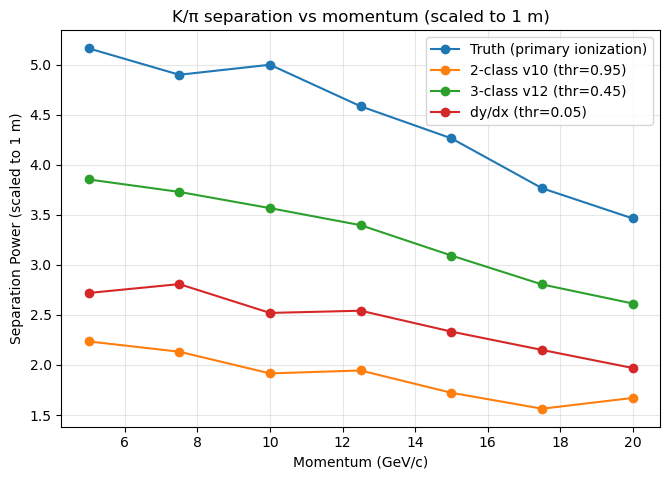

Saved: results/final_eval_threshold_scan_v10v12_dydx_truth/sep_curve_4lines_truth_v10_v12_dydx.png


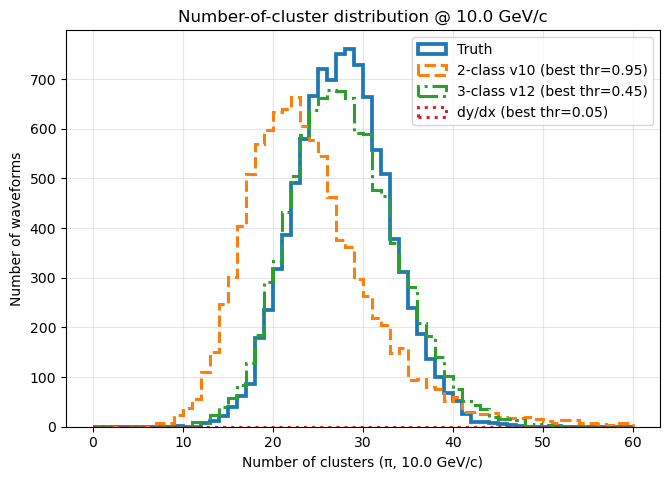

Saved: results/final_eval_threshold_scan_v10v12_dydx_truth/fig8_like_overlay_truth_v10_v12_dydx.png

✅ Done. Outputs in: results/final_eval_threshold_scan_v10v12_dydx_truth


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0..batch_4

# checkpoints (your naming)
BIN2_BEST_PT   = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"         # 2-class model (v10)
TRI3_BEST_PT   = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"     # 3-class model (v12)

OUTDIR = "results/final_eval_threshold_scan_v10v12_dydx_truth"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

# truth tag values (your dataset)
TAG_BG   = 0
TAG_PRI  = 1
TAG_SEC  = 2

# separation power scaling to 1m track (paper uses 18mm cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

# Paper: separation optimization uses fixed momenta
OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]

# threshold scan grid
THR_GRID = np.linspace(0.05, 0.95, 19)  # 0.05,0.10,...0.95

# Fig.8 histogram styling
HIST_BINS = 60
HIST_RANGE = (0, 60)
FIG8_MOM = 10.0   # paper Fig.8 is 10 GeV/c pion sample

# "D2" per your note: use regular dy/dx algo (first-derivative threshold)
# We'll scan derivative threshold on a normalized scale.
DYDX_THR_GRID = np.linspace(0.05, 0.95, 19)

# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1) -> conv wants (B, C, T)
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)   # (B, T, 128)
            fc = self.fc1(spk4)            # (B, T, 128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)      # (B, T, num_classes)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)


# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "min/max:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    rows, cols = np.where(valid)
    t = tag_times[rows, cols]
    y[rows, t] = tag_values[rows, cols].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use=None):
    if moms_to_use is None:
        moms_to_use = sorted(np.unique(mom).tolist())

    moms_used, S = [], []
    for p in moms_to_use:
        mk = (np.isclose(mom, p)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p)) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_sep_power_4lines(moms, lines_dict, title, out_png):
    """
    lines_dict: {label: S_scaled_array}
    """
    plt.figure(figsize=(6.8, 4.9))
    for label, y in lines_dict.items():
        plt.plot(moms, y, marker="o", label=label)
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_fig8_overlay_4(truth_counts, counts_2c, counts_3c, counts_dydx, mom, pid, best_thr2, best_thr3, best_thrd, out_png):
    """
    ONE graph: Truth + 2-class + 3-class + dy/dx(D2 per your wording)
    Y-axis: Number of waveforms
    """
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xt = truth_counts[mask].astype(np.int32)
    x2 = counts_2c[mask].astype(np.int32)
    x3 = counts_3c[mask].astype(np.int32)
    xd = counts_dydx[mask].astype(np.int32)

    if xt.size == 0:
        print("No events found for pid=PION and mom=10.0. Check np.unique(mom).")
        return

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.7, label="Truth")
    plt.hist(x2, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.2, linestyle="--",
             label=f"2-class v10 (best thr={best_thr2:.2f})")
    plt.hist(x3, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.2, linestyle="-.",
             label=f"3-class v12 (best thr={best_thr3:.2f})")
    plt.hist(xd, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.2, linestyle=":",
             label=f"dy/dx (best thr={best_thrd:.2f})")

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png)

# ---------------------------
# SNN inference → counts(thr)
# ---------------------------
def infer_counts_scan_thresholds(
    model,
    wf_i,
    scaler,
    device,
    thr_grid,
    which_model,
    use_bg_first=False,
    bg_purity_target=0.90,
    y_dense_truth=None,
):
    """
    For 2-class model: we still use probs[...,1] as "signal/primary-like" score.
    For 3-class model: use probs[...,1] as "primary" score, probs[...,0] as background score.
    """
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}
    extra = {}

    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    # BG-first (optional for 3-class)
    bg_thr = None
    if use_bg_first:
        if which_model != "3class":
            raise ValueError("BG-first only makes sense for the 3-class model.")
        if y_dense_truth is None:
            raise ValueError("BG-first requested but y_dense_truth is None.")

        rng = np.random.default_rng(0)
        idx = rng.choice(N, size=min(N, 50000), replace=False)
        xb = x_t[idx].to(device)

        with torch.inference_mode():
            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

        p_bg = probs[..., 0].detach().cpu().numpy().reshape(-1)
        truth_bg = (y_dense_truth[idx] == TAG_BG).reshape(-1)

        cand = np.linspace(0.05, 0.99, 50)
        best = None
        for thr in cand:
            pred_bg = (p_bg >= thr)
            tp = np.sum(pred_bg & truth_bg)
            fp = np.sum(pred_bg & (~truth_bg))
            if tp + fp == 0:
                continue
            purity = tp / (tp + fp)
            if purity >= bg_purity_target:
                best = thr
                break

        bg_thr = best if best is not None else 0.95
        extra["bg_thr"] = float(bg_thr)
        extra["bg_purity_target"] = float(bg_purity_target)
        print(f"[3-class] BG-first enabled: using bg_thr={bg_thr:.3f} (target purity={bg_purity_target:.3f})")

    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=f"Inference+scan ({which_model})", mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)  # (B,T,C)
            else:
                probs = torch.softmax(model(xb), dim=-1)

            # use class-1 as "primary-like score" consistently
            p_pri = probs[..., 1]  # (B,T)

            if use_bg_first:
                p_bg = probs[..., 0]
                keep = (p_bg < bg_thr)
            else:
                keep = None

            for thr in thr_grid:
                if keep is None:
                    counts = (p_pri >= thr).sum(dim=1)
                else:
                    counts = ((p_pri >= thr) & keep).sum(dim=1)
                out[thr][idx0:idx0+bs] = counts.to(torch.int32).cpu().numpy()

            idx0 += bs

    return out, extra

def pick_best_threshold_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt):
    best_thr, best_score = None, -1e9
    curve = {}

    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_to_use=moms_for_opt)
        if S.size == 0:
            continue
        S_scaled = S * SCALE_TO_1M
        score = float(np.mean(S_scaled))
        curve[thr] = (moms_used, S_scaled, score)

        if score > best_score:
            best_score = score
            best_thr = thr

    return best_thr, best_score, curve

# ------------------------------------------------------------
# dy/dx "D2" (per your wording): derivative threshold method
# ------------------------------------------------------------
def smooth_ma(x, win=5):
    if win <= 1:
        return x
    k = np.ones(win, dtype=np.float32) / float(win)
    # reflect-pad to reduce edge artifacts
    xp = np.pad(x, (win//2, win//2), mode="reflect")
    return np.convolve(xp, k, mode="valid")

def dydx_counts_scan(wf_i, thr_grid, smooth_win=5):
    """
    Counts peaks using first derivative sign-change + derivative magnitude threshold.

    Steps per waveform:
      1) smooth waveform
      2) dy = diff(y)
      3) peak at i if dy[i-1] > +thr and dy[i] < -thr (sharp up then down)
    To make thr_grid comparable across events, we normalize dy by a robust scale.
    """
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}

    # robust global scale for dy to map thresholds into [0,1]-ish
    # (median absolute deviation of dy across a subsample)
    rng = np.random.default_rng(0)
    idx = rng.choice(N, size=min(N, 20000), replace=False)
    dy_all = []
    for j in idx:
        y = smooth_ma(wf_i[j].astype(np.float32), win=smooth_win)
        dy = np.diff(y)
        dy_all.append(dy)
    dy_all = np.concatenate(dy_all)
    mad = np.median(np.abs(dy_all - np.median(dy_all))) + 1e-12
    scale = 1.4826 * mad  # approx std if normal
    print(f"[dy/dx] robust dy scale ~ {scale:.6g}")

    for n in tqdm(range(N), desc="dy/dx scan", mininterval=1.0):
        y = smooth_ma(wf_i[n].astype(np.float32), win=smooth_win)
        dy = np.diff(y) / scale  # normalized derivative
        # candidate peaks where sign flips + to -
        # peak index refers to y index (1..T-2), but we just count them
        for thr in thr_grid:
            thrv = thr  # already in 0..1
            peaks = np.sum((dy[:-1] > thrv) & (dy[1:] < -thrv))
            out[thr][n] = int(peaks)

    return out, {"dy_scale": float(scale), "smooth_win": int(smooth_win)}

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    # Truth primary counts (this is your "primary ionization" baseline)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)
    print("Truth primary-count mean:", float(truth_counts.mean()))
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ------------------------------------------------------------
    # Load SNN models
    # ------------------------------------------------------------
    model_2class = ConvSNN_Deep(num_classes=2).to(device)
    model_2class.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_3class = ConvSNN_Deep(num_classes=3).to(device)
    model_3class.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ------------------------------------------------------------
    # 2-class (v10) scan
    # ------------------------------------------------------------
    counts2_by_thr, _ = infer_counts_scan_thresholds(
        model_2class, wf_i, scaler, device, THR_GRID,
        which_model="2class",
        use_bg_first=False,
        y_dense_truth=None
    )
    best_thr2, best_score2, _ = pick_best_threshold_by_avg_sep(counts2_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[2-class v10] Best thr = {best_thr2:.2f}  avg sep(1m) = {best_score2:.4f}")

    # ------------------------------------------------------------
    # 3-class (v12) scan
    # ------------------------------------------------------------
    USE_BG_FIRST = False
    BG_PURITY_TARGET = 0.8986

    counts3_by_thr, extra3 = infer_counts_scan_thresholds(
        model_3class, wf_i, scaler, device, THR_GRID,
        which_model="3class",
        use_bg_first=USE_BG_FIRST,
        bg_purity_target=BG_PURITY_TARGET,
        y_dense_truth=y_dense
    )
    best_thr3, best_score3, _ = pick_best_threshold_by_avg_sep(counts3_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[3-class v12] Best thr = {best_thr3:.2f}  avg sep(1m) = {best_score3:.4f}")
    if USE_BG_FIRST:
        print(f"[3-class] BG-first info:", extra3)

    # ------------------------------------------------------------
    # dy/dx ("D2" per your note) scan
    # ------------------------------------------------------------
    dydx_by_thr, extra_d = dydx_counts_scan(wf_i, DYDX_THR_GRID, smooth_win=5)
    best_thrd, best_scored, _ = pick_best_threshold_by_avg_sep(dydx_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[dy/dx] Best thr = {best_thrd:.2f}  avg sep(1m) = {best_scored:.4f}")
    print("[dy/dx] info:", extra_d)
    print()

    # ------------------------------------------------------------
    # Build the 4-line separation plot:
    #   3-class best, 2-class best, dy/dx best, Truth (primary ionization)
    # ------------------------------------------------------------
    moms, S_truth = separation_vs_momentum(truth_counts, mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_2     = separation_vs_momentum(counts2_by_thr[best_thr2], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_3     = separation_vs_momentum(counts3_by_thr[best_thr3], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_d     = separation_vs_momentum(dydx_by_thr[best_thrd], mom, pid, moms_to_use=OPT_MOMENTA)

    plot_sep_power_4lines(
        moms=moms,
        lines_dict={
            f"Truth (primary ionization)": S_truth * SCALE_TO_1M,
            f"2-class v10 (thr={best_thr2:.2f})": S_2 * SCALE_TO_1M,
            f"3-class v12 (thr={best_thr3:.2f})": S_3 * SCALE_TO_1M,
            f"dy/dx (thr={best_thrd:.2f})": S_d * SCALE_TO_1M,
        },
        title="K/π separation vs momentum (scaled to 1 m)",
        out_png=os.path.join(OUTDIR, "sep_curve_4lines_truth_v10_v12_dydx.png"),
    )

    # ------------------------------------------------------------
    # One Fig.8-like histogram overlay: Truth + v10 + v12 + dy/dx
    # ------------------------------------------------------------
    plot_fig8_overlay_4(
        truth_counts=truth_counts,
        counts_2c=counts2_by_thr[best_thr2],
        counts_3c=counts3_by_thr[best_thr3],
        counts_dydx=dydx_by_thr[best_thrd],
        mom=mom,
        pid=pid,
        best_thr2=best_thr2,
        best_thr3=best_thr3,
        best_thrd=best_thrd,
        out_png=os.path.join(OUTDIR, "fig8_like_overlay_truth_v10_v12_dydx.png"),
    )

    # ------------------------------------------------------------
    # Save chosen thresholds + quick metadata
    # ------------------------------------------------------------
    np.savez(
        os.path.join(OUTDIR, "best_thresholds_v10v12_dydx_truth.npz"),
        best_thr_2class=float(best_thr2),
        best_thr_3class=float(best_thr3),
        best_thr_dydx=float(best_thrd),
        best_avg_sep_2class=float(best_score2),
        best_avg_sep_3class=float(best_score3),
        best_avg_sep_dydx=float(best_scored),
        used_bg_first=bool(USE_BG_FIRST),
        bg_thr=float(extra3.get("bg_thr", np.nan)) if isinstance(extra3, dict) else np.nan,
        dydx_scale=float(extra_d.get("dy_scale", np.nan)) if isinstance(extra_d, dict) else np.nan,
        dydx_smooth_win=int(extra_d.get("smooth_win", 0)) if isinstance(extra_d, dict) else 0,
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 19.99993896484375
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_4.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001369714736938 19.999898910522

Inference+scan (2class): 100%|██████████| 1719/1719 [16:12<00:00,  1.77it/s]


[2-class v10] Best thr = 0.95  avg sep(1m) = 1.8836


Inference+scan (3class): 100%|██████████| 1719/1719 [16:16<00:00,  1.76it/s]


[3-class v12] Best thr = 0.45  avg sep(1m) = 3.2933
[D2] robust d2 scale ~ 0.00540472


D2 scan: 100%|██████████| 440000/440000 [10:17<00:00, 712.27it/s]


[D2 traditional] Best thr = 0.05  avg sep(1m) = 2.7189
[D2] info: {'d2_scale': 0.0054047218963428675, 'smooth_win': 7, 'merge_window': 2}



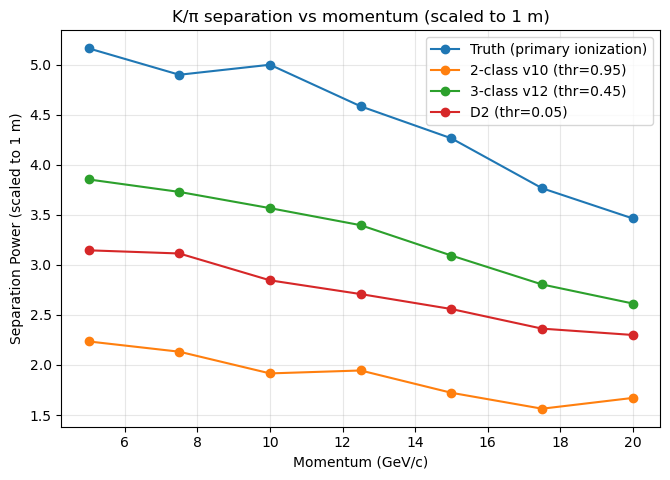

Saved: results/final_eval_threshold_scan_v10v12_D2_truth/sep_curve_4lines_truth_v10_v12_D2.png


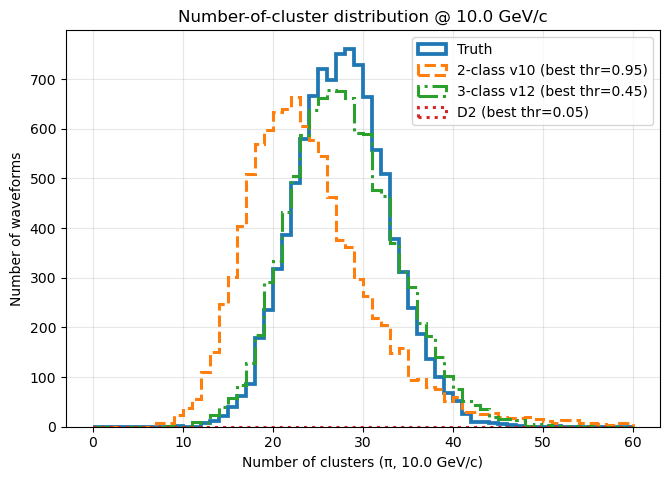

Saved: results/final_eval_threshold_scan_v10v12_D2_truth/fig8_like_overlay_truth_v10_v12_D2.png
D2 counts @ 10.0 GeV/c (π): min/mean/max = 202 398.3876 480

✅ Done. Outputs in: results/final_eval_threshold_scan_v10v12_D2_truth


In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0..batch_4

# checkpoints (your naming)
BIN2_BEST_PT   = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"         # 2-class model (v10)
TRI3_BEST_PT   = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"     # 3-class model (v12)

OUTDIR = "results/final_eval_threshold_scan_v10v12_D2_truth"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

# truth tag values (your dataset)
TAG_BG   = 0
TAG_PRI  = 1
TAG_SEC  = 2

# separation power scaling to 1m track (paper uses 18mm cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

# Paper: separation optimization uses fixed momenta
OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]

# threshold scan grid for ML (probability)
THR_GRID = np.linspace(0.05, 0.95, 19)  # 0.05,0.10,...0.95

# threshold scan grid for D2 baseline (normalized D2 magnitude)
D2_THR_GRID = np.linspace(0.05, 0.95, 19)

# Fig.8 histogram styling
HIST_BINS = 60
HIST_RANGE = (0, 60)
FIG8_MOM = 10.0   # paper Fig.8 is 10 GeV/c pion sample

# D2 baseline parameters (traditional-ish)
D2_SMOOTH_WIN   = 7     # moving-average smoothing window (samples)
D2_MERGE_WINDOW = 2     # merge peak candidates closer than this (samples)

# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1) -> conv wants (B, C, T)
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)   # (B, T, 128)
            fc = self.fc1(spk4)            # (B, T, 128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)      # (B, T, num_classes)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)


# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "min/max:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    rows, cols = np.where(valid)
    t = tag_times[rows, cols]
    y[rows, t] = tag_values[rows, cols].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use=None):
    if moms_to_use is None:
        moms_to_use = sorted(np.unique(mom).tolist())

    moms_used, S = [], []
    for p in moms_to_use:
        mk = (np.isclose(mom, p)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p)) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_sep_power_4lines(moms, lines_dict, title, out_png):
    plt.figure(figsize=(6.8, 4.9))
    for label, y in lines_dict.items():
        plt.plot(moms, y, marker="o", label=label)
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_fig8_overlay_4(truth_counts, counts_2c, counts_3c, counts_d2, mom, pid, best_thr2, best_thr3, best_thrd2, out_png):
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xt = truth_counts[mask].astype(np.int32)
    x2 = counts_2c[mask].astype(np.int32)
    x3 = counts_3c[mask].astype(np.int32)
    xd = counts_d2[mask].astype(np.int32)

    if xt.size == 0:
        print("No events found for pid=PION and mom=10.0. Check np.unique(mom).")
        return

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.7, label="Truth")
    plt.hist(x2, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.2, linestyle="--",
             label=f"2-class v10 (best thr={best_thr2:.2f})")
    plt.hist(x3, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.2, linestyle="-.",
             label=f"3-class v12 (best thr={best_thr3:.2f})")
    plt.hist(xd, bins=HIST_BINS, range=HIST_RANGE, histtype="step", linewidth=2.2, linestyle=":",
             label=f"D2 (best thr={best_thrd2:.2f})")

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png)

# ---------------------------
# SNN inference → counts(thr)
# ---------------------------
def infer_counts_scan_thresholds(
    model,
    wf_i,
    scaler,
    device,
    thr_grid,
    which_model,
    use_bg_first=False,
    bg_purity_target=0.90,
    y_dense_truth=None,
):
    """
    For 2-class model: use probs[...,1] as "signal/primary-like" score.
    For 3-class model: use probs[...,1] as "primary" score, probs[...,0] for background.
    """
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}
    extra = {}

    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    # BG-first optional for 3-class
    bg_thr = None
    if use_bg_first:
        if which_model != "3class":
            raise ValueError("BG-first only makes sense for the 3-class model.")
        if y_dense_truth is None:
            raise ValueError("BG-first requested but y_dense_truth is None.")

        rng = np.random.default_rng(0)
        idx = rng.choice(N, size=min(N, 50000), replace=False)
        xb = x_t[idx].to(device)

        with torch.inference_mode():
            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

        p_bg = probs[..., 0].detach().cpu().numpy().reshape(-1)
        truth_bg = (y_dense_truth[idx] == TAG_BG).reshape(-1)

        cand = np.linspace(0.05, 0.99, 50)
        best = None
        for thr in cand:
            pred_bg = (p_bg >= thr)
            tp = np.sum(pred_bg & truth_bg)
            fp = np.sum(pred_bg & (~truth_bg))
            if tp + fp == 0:
                continue
            purity = tp / (tp + fp)
            if purity >= bg_purity_target:
                best = thr
                break

        bg_thr = best if best is not None else 0.95
        extra["bg_thr"] = float(bg_thr)
        extra["bg_purity_target"] = float(bg_purity_target)
        print(f"[3-class] BG-first enabled: using bg_thr={bg_thr:.3f} (target purity={bg_purity_target:.3f})")

    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=f"Inference+scan ({which_model})", mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)  # (B,T,C)
            else:
                probs = torch.softmax(model(xb), dim=-1)

            p_pri = probs[..., 1]  # class-1 score

            if use_bg_first:
                p_bg = probs[..., 0]
                keep = (p_bg < bg_thr)
            else:
                keep = None

            for thr in thr_grid:
                if keep is None:
                    counts = (p_pri >= thr).sum(dim=1)
                else:
                    counts = ((p_pri >= thr) & keep).sum(dim=1)
                out[thr][idx0:idx0+bs] = counts.to(torch.int32).cpu().numpy()

            idx0 += bs

    return out, extra

def pick_best_threshold_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt):
    best_thr, best_score = None, -1e9
    curve = {}
    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_to_use=moms_for_opt)
        if S.size == 0:
            continue
        S_scaled = S * SCALE_TO_1M
        score = float(np.mean(S_scaled))
        curve[thr] = (moms_used, S_scaled, score)
        if score > best_score:
            best_score = score
            best_thr = thr
    return best_thr, best_score, curve

# ------------------------------------------------------------
# Traditional baseline: D2 (second-derivative) + simple merging
# ------------------------------------------------------------
def d2_counts_scan(wf_i, thr_grid, smooth_win=7, merge_window=2):
    """
    D2 baseline: threshold on second derivative magnitude (normalized).
    Peak candidate if:
        d1 crosses + -> -  AND  d2 is sufficiently negative (concave down)
    Then merge nearby peaks into one cluster (simple peak-merging approximation).
    """
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}

    def smooth_ma(x, win):
        if win <= 1:
            return x
        k = np.ones(win, dtype=np.float32) / float(win)
        xp = np.pad(x, (win//2, win//2), mode="reflect")
        return np.convolve(xp, k, mode="valid")

    # robust scale for d2
    rng = np.random.default_rng(0)
    idx = rng.choice(N, size=min(N, 20000), replace=False)
    d2_all = []
    for j in idx:
        y = smooth_ma(wf_i[j].astype(np.float32), smooth_win)
        d1 = np.diff(y)
        d2 = np.diff(d1)
        d2_all.append(d2)
    d2_all = np.concatenate(d2_all)
    mad = np.median(np.abs(d2_all - np.median(d2_all))) + 1e-12
    scale = 1.4826 * mad
    print(f"[D2] robust d2 scale ~ {scale:.6g}")

    for n in tqdm(range(N), desc="D2 scan", mininterval=1.0):
        y = smooth_ma(wf_i[n].astype(np.float32), smooth_win)
        d1 = np.diff(y)                 # len T-1
        d2 = np.diff(d1) / scale        # len T-2, aligned to y index 1..T-2

        # sign flip d1: local max at y-index k where d1[k-1] > 0 and d1[k] < 0
        sign_flip = np.where((d1[:-1] > 0) & (d1[1:] < 0))[0] + 1  # y-index candidates

        for thr in thr_grid:
            # require strong concavity at candidate: d2[k-1] < -thr
            cand = sign_flip[d2[sign_flip - 1] < -thr]

            if cand.size == 0:
                out[thr][n] = 0
                continue

            cand.sort()
            clusters = 1
            last = cand[0]
            for t in cand[1:]:
                if (t - last) > merge_window:
                    clusters += 1
                    last = t
            out[thr][n] = clusters

    return out, {"d2_scale": float(scale), "smooth_win": int(smooth_win), "merge_window": int(merge_window)}

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    # Truth primary counts (your "primary ionization" baseline)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)
    print("Truth primary-count mean:", float(truth_counts.mean()))
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ------------------------------------------------------------
    # Load SNN models
    # ------------------------------------------------------------
    model_2class = ConvSNN_Deep(num_classes=2).to(device)
    model_2class.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_3class = ConvSNN_Deep(num_classes=3).to(device)
    model_3class.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ------------------------------------------------------------
    # 2-class (v10) scan
    # ------------------------------------------------------------
    counts2_by_thr, _ = infer_counts_scan_thresholds(
        model_2class, wf_i, scaler, device, THR_GRID,
        which_model="2class",
        use_bg_first=False,
        y_dense_truth=None
    )
    best_thr2, best_score2, _ = pick_best_threshold_by_avg_sep(counts2_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[2-class v10] Best thr = {best_thr2:.2f}  avg sep(1m) = {best_score2:.4f}")

    # ------------------------------------------------------------
    # 3-class (v12) scan
    # ------------------------------------------------------------
    USE_BG_FIRST = False
    BG_PURITY_TARGET = 0.8986

    counts3_by_thr, extra3 = infer_counts_scan_thresholds(
        model_3class, wf_i, scaler, device, THR_GRID,
        which_model="3class",
        use_bg_first=USE_BG_FIRST,
        bg_purity_target=BG_PURITY_TARGET,
        y_dense_truth=y_dense
    )
    best_thr3, best_score3, _ = pick_best_threshold_by_avg_sep(counts3_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[3-class v12] Best thr = {best_thr3:.2f}  avg sep(1m) = {best_score3:.4f}")
    if USE_BG_FIRST:
        print(f"[3-class] BG-first info:", extra3)

    # ------------------------------------------------------------
    # Traditional baseline: D2 scan
    # ------------------------------------------------------------
    d2_by_thr, extra_d2 = d2_counts_scan(
        wf_i, D2_THR_GRID,
        smooth_win=D2_SMOOTH_WIN,
        merge_window=D2_MERGE_WINDOW
    )
    best_thrd2, best_scored2, _ = pick_best_threshold_by_avg_sep(d2_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[D2 traditional] Best thr = {best_thrd2:.2f}  avg sep(1m) = {best_scored2:.4f}")
    print("[D2] info:", extra_d2)
    print()

    # ------------------------------------------------------------
    # 4-line separation plot:
    #   Truth, v10, v12, D2
    # ------------------------------------------------------------
    moms, S_truth = separation_vs_momentum(truth_counts, mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_2     = separation_vs_momentum(counts2_by_thr[best_thr2], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_3     = separation_vs_momentum(counts3_by_thr[best_thr3], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_d2    = separation_vs_momentum(d2_by_thr[best_thrd2], mom, pid, moms_to_use=OPT_MOMENTA)

    plot_sep_power_4lines(
        moms=moms,
        lines_dict={
            "Truth (primary ionization)": S_truth * SCALE_TO_1M,
            f"2-class v10 (thr={best_thr2:.2f})": S_2 * SCALE_TO_1M,
            f"3-class v12 (thr={best_thr3:.2f})": S_3 * SCALE_TO_1M,
            f"D2 (thr={best_thrd2:.2f})": S_d2 * SCALE_TO_1M,
        },
        title="K/π separation vs momentum (scaled to 1 m)",
        out_png=os.path.join(OUTDIR, "sep_curve_4lines_truth_v10_v12_D2.png"),
    )

    # ------------------------------------------------------------
    # One Fig.8-like histogram overlay: Truth + v10 + v12 + D2
    # ------------------------------------------------------------
    plot_fig8_overlay_4(
        truth_counts=truth_counts,
        counts_2c=counts2_by_thr[best_thr2],
        counts_3c=counts3_by_thr[best_thr3],
        counts_d2=d2_by_thr[best_thrd2],
        mom=mom,
        pid=pid,
        best_thr2=best_thr2,
        best_thr3=best_thr3,
        best_thrd2=best_thrd2,
        out_png=os.path.join(OUTDIR, "fig8_like_overlay_truth_v10_v12_D2.png"),
    )

    # ------------------------------------------------------------
    # Quick sanity prints for D2 @ 10 GeV/c pion
    # ------------------------------------------------------------
    mask10 = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    d2_counts10 = d2_by_thr[best_thrd2][mask10]
    if d2_counts10.size > 0:
        print(f"D2 counts @ {FIG8_MOM:.1f} GeV/c (π): min/mean/max =",
              int(d2_counts10.min()), float(d2_counts10.mean()), int(d2_counts10.max()))
    else:
        print("No pion@10GeV samples found for D2 sanity print.")

    # ------------------------------------------------------------
    # Save thresholds/metadata
    # ------------------------------------------------------------
    np.savez(
        os.path.join(OUTDIR, "best_thresholds_v10v12_D2_truth.npz"),
        best_thr_2class=float(best_thr2),
        best_thr_3class=float(best_thr3),
        best_thr_D2=float(best_thrd2),
        best_avg_sep_2class=float(best_score2),
        best_avg_sep_3class=float(best_score3),
        best_avg_sep_D2=float(best_scored2),
        used_bg_first=bool(USE_BG_FIRST),
        bg_thr=float(extra3.get("bg_thr", np.nan)) if isinstance(extra3, dict) else np.nan,
        d2_scale=float(extra_d2.get("d2_scale", np.nan)) if isinstance(extra_d2, dict) else np.nan,
        d2_smooth_win=int(extra_d2.get("smooth_win", 0)) if isinstance(extra_d2, dict) else 0,
        d2_merge_window=int(extra_d2.get("merge_window", 0)) if isinstance(extra_d2, dict) else 0,
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 19.99993896484375
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_4.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001369714736938 19.999898910522

Inference+scan (2class): 100%|██████████| 1719/1719 [16:11<00:00,  1.77it/s]


[2-class v10] Best thr = 0.95  avg sep(1m) = 1.8836


Inference+scan (3class): 100%|██████████| 1719/1719 [16:15<00:00,  1.76it/s]


[3-class v12] Best thr = 0.45  avg sep(1m) = 3.2933


D2 scan (paperish): 100%|██████████| 440000/440000 [10:58<00:00, 668.65it/s]


[D2] Best thr = 0.0050  avg sep(1m) = 2.7116
[D2] info: {'smooth_win': 7, 'merge_window': 2, 'norm_pctl': 99.0}

[D2 @ 10.0 GeV/c pion] min/mean/max: 169 398.4495 480
[D2 @ 10.0 GeV/c pion] nonzero fraction: 1.0


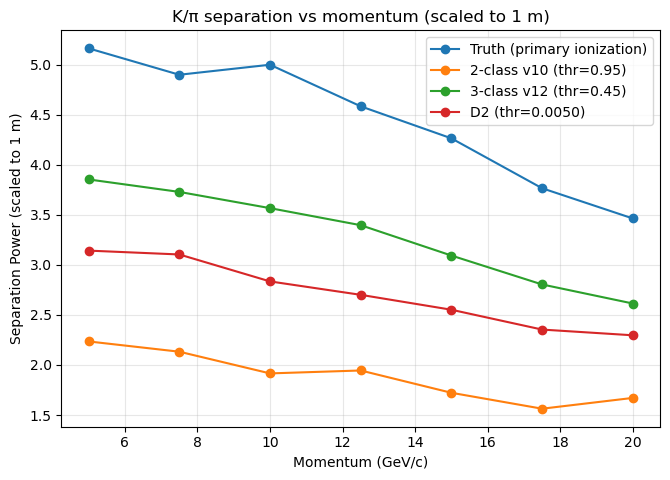

Saved: results/final_eval_threshold_scan_v10v12_D2_truth_fixed/sep_curve_4lines_truth_v10_v12_D2.png


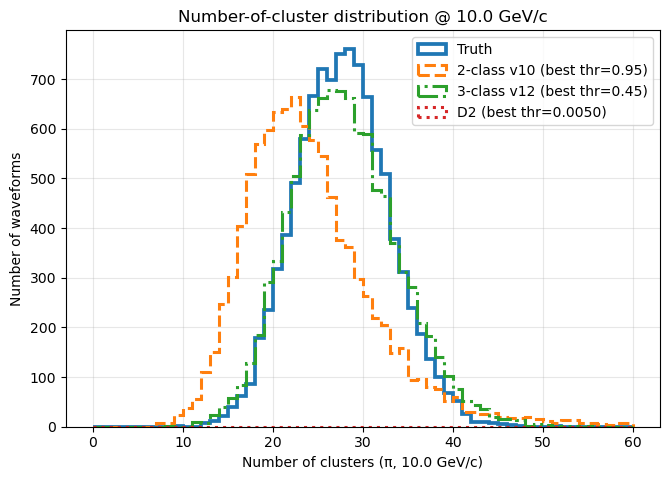

Saved: results/final_eval_threshold_scan_v10v12_D2_truth_fixed/fig8_like_overlay_truth_v10_v12_D2.png

✅ Done. Outputs in: results/final_eval_threshold_scan_v10v12_D2_truth_fixed


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0..batch_4

BIN2_BEST_PT   = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"         # 2-class model (v10)
TRI3_BEST_PT   = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"     # 3-class model (v12)

OUTDIR = "results/final_eval_threshold_scan_v10v12_D2_truth_fixed"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

TAG_BG   = 0
TAG_PRI  = 1
TAG_SEC  = 2

CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]

THR_GRID = np.linspace(0.05, 0.95, 19)  # ML probability thresholds

# D2 threshold axis in the paper is 0..1; Fig.6 optimum shown around ~0.053.
# We'll scan around that region + wider.
D2_THR_GRID = np.concatenate([
    np.linspace(0.005, 0.08, 16),   # dense near paper-like optimum
    np.linspace(0.09, 0.40, 8),
    np.linspace(0.45, 0.90, 10),
])

FIG8_MOM = 10.0

# Histogram bins: use integer bin edges so spikes at 0 show clearly if they exist
HIST_BINS = np.arange(0, 61, 1)  # 0..60
HIST_RANGE = None  # ignored when bins is array

# D2 baseline parameters
D2_SMOOTH_WIN   = 7     # moving average (paper recommends low-pass like moving average before derivatives)
D2_MERGE_WINDOW = 2     # merge close-by peaks into one cluster
D2_NORM_PCTL    = 99.0  # percentile used to normalize D2 score per waveform

# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)

# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "min/max:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    rows, cols = np.where(valid)
    t = tag_times[rows, cols]
    y[rows, t] = tag_values[rows, cols].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use=None):
    if moms_to_use is None:
        moms_to_use = sorted(np.unique(mom).tolist())

    moms_used, S = [], []
    for p in moms_to_use:
        mk = (np.isclose(mom, p)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p)) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_sep_power_4lines(moms, lines_dict, title, out_png):
    plt.figure(figsize=(6.8, 4.9))
    for label, y in lines_dict.items():
        plt.plot(moms, y, marker="o", label=label)
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_fig8_overlay_4(truth_counts, counts_2c, counts_3c, counts_d2, mom, pid, best_thr2, best_thr3, best_thrd2, out_png):
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xt = truth_counts[mask].astype(np.int32)
    x2 = counts_2c[mask].astype(np.int32)
    x3 = counts_3c[mask].astype(np.int32)
    xd = counts_d2[mask].astype(np.int32)

    if xt.size == 0:
        print("No events found for pid=PION and mom=10.0. Check np.unique(mom).")
        return

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt, bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth")
    plt.hist(x2, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="--",
             label=f"2-class v10 (best thr={best_thr2:.2f})")
    plt.hist(x3, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="-.",
             label=f"3-class v12 (best thr={best_thr3:.2f})")
    plt.hist(xd, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":",
             label=f"D2 (best thr={best_thrd2:.4f})")

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png)

# ---------------------------
# SNN inference → counts(thr)
# ---------------------------
def infer_counts_scan_thresholds(
    model,
    wf_i,
    scaler,
    device,
    thr_grid,
    which_model,
    use_bg_first=False,
    bg_purity_target=0.90,
    y_dense_truth=None,
):
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}
    extra = {}

    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    bg_thr = None
    if use_bg_first:
        if which_model != "3class":
            raise ValueError("BG-first only makes sense for the 3-class model.")
        if y_dense_truth is None:
            raise ValueError("BG-first requested but y_dense_truth is None.")

        rng = np.random.default_rng(0)
        idx = rng.choice(N, size=min(N, 50000), replace=False)
        xb = x_t[idx].to(device)

        with torch.inference_mode():
            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

        p_bg = probs[..., 0].detach().cpu().numpy().reshape(-1)
        truth_bg = (y_dense_truth[idx] == TAG_BG).reshape(-1)

        cand = np.linspace(0.05, 0.99, 50)
        best = None
        for thr in cand:
            pred_bg = (p_bg >= thr)
            tp = np.sum(pred_bg & truth_bg)
            fp = np.sum(pred_bg & (~truth_bg))
            if tp + fp == 0:
                continue
            purity = tp / (tp + fp)
            if purity >= bg_purity_target:
                best = thr
                break

        bg_thr = best if best is not None else 0.95
        extra["bg_thr"] = float(bg_thr)
        extra["bg_purity_target"] = float(bg_purity_target)
        print(f"[3-class] BG-first enabled: using bg_thr={bg_thr:.3f} (target purity={bg_purity_target:.3f})")

    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=f"Inference+scan ({which_model})", mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

            p_pri = probs[..., 1]

            if use_bg_first:
                p_bg = probs[..., 0]
                keep = (p_bg < bg_thr)
            else:
                keep = None

            for thr in thr_grid:
                if keep is None:
                    counts = (p_pri >= thr).sum(dim=1)
                else:
                    counts = ((p_pri >= thr) & keep).sum(dim=1)

                out[thr][idx0:idx0+bs] = counts.to(torch.int32).cpu().numpy()

            idx0 += bs

    return out, extra

def pick_best_threshold_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt):
    best_thr, best_score = None, -1e9
    curve = {}
    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_to_use=moms_for_opt)
        if S.size == 0:
            continue
        S_scaled = S * SCALE_TO_1M
        score = float(np.mean(S_scaled))
        curve[thr] = (moms_used, S_scaled, score)
        if score > best_score:
            best_score = score
            best_thr = thr
    return best_thr, best_score, curve

# ------------------------------------------------------------
# Paper-faithful-ish D2: threshold on SECOND derivative
# + moving average preprocessing
# + candidate = local maximum AND D2 score > threshold
# ------------------------------------------------------------
def d2_counts_scan_paperish(wf_i, thr_grid, smooth_win=7, merge_window=2, norm_pctl=99.0):
    """
    Output counts per waveform for each threshold in [0,1] (paper-like axis).

    Steps:
      1) moving-average smooth (paper recommends low-pass like moving average)
      2) d1 = diff(y), d2 = diff(d1)
      3) candidate peaks at local maxima: d1 crosses + -> -
      4) D2 score = -d2 at that location (concave down)
      5) normalize D2 score per waveform by a high percentile so thresholds are meaningful (0..1-ish)
      6) keep candidates with score_norm >= thr
      7) merge candidates within merge_window
    """
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}

    def smooth_ma(x, win):
        if win <= 1:
            return x
        k = np.ones(win, dtype=np.float32) / float(win)
        xp = np.pad(x, (win//2, win//2), mode="reflect")
        return np.convolve(xp, k, mode="valid")

    for n in tqdm(range(N), desc="D2 scan (paperish)", mininterval=1.0):
        y = smooth_ma(wf_i[n].astype(np.float32), smooth_win)

        d1 = np.diff(y)        # len T-1
        d2 = np.diff(d1)       # len T-2, aligns with y index 1..T-2 via d2[k-1]

        # local maxima candidates
        cand = np.where((d1[:-1] > 0) & (d1[1:] < 0))[0] + 1  # y-index candidates

        if cand.size == 0:
            for thr in thr_grid:
                out[thr][n] = 0
            continue

        # D2 score at each candidate (concave down => -d2 positive)
        score = (-d2[cand - 1]).astype(np.float32)
        # robust per-waveform normalization to map into ~[0,1]
        sref = np.percentile(score, norm_pctl) + 1e-12
        score_norm = score / sref

        # for each threshold, count merged peaks passing score threshold
        order = np.argsort(cand)
        cand_sorted = cand[order]
        score_sorted = score_norm[order]

        for thr in thr_grid:
            keep = cand_sorted[score_sorted >= thr]
            if keep.size == 0:
                out[thr][n] = 0
                continue

            clusters = 1
            last = keep[0]
            for t in keep[1:]:
                if (t - last) > merge_window:
                    clusters += 1
                    last = t
            out[thr][n] = int(clusters)

    return out, {"smooth_win": int(smooth_win), "merge_window": int(merge_window), "norm_pctl": float(norm_pctl)}

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)

    print("Truth primary-count mean:", float(truth_counts.mean()))
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ----------------------------
    # Load models
    # ----------------------------
    model_2class = ConvSNN_Deep(num_classes=2).to(device)
    model_2class.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_3class = ConvSNN_Deep(num_classes=3).to(device)
    model_3class.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ----------------------------
    # v10 2-class scan
    # ----------------------------
    counts2_by_thr, _ = infer_counts_scan_thresholds(
        model_2class, wf_i, scaler, device, THR_GRID,
        which_model="2class",
        use_bg_first=False,
        y_dense_truth=None
    )
    best_thr2, best_score2, _ = pick_best_threshold_by_avg_sep(counts2_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[2-class v10] Best thr = {best_thr2:.2f}  avg sep(1m) = {best_score2:.4f}")

    # ----------------------------
    # v12 3-class scan
    # ----------------------------
    USE_BG_FIRST = False
    BG_PURITY_TARGET = 0.8986

    counts3_by_thr, extra3 = infer_counts_scan_thresholds(
        model_3class, wf_i, scaler, device, THR_GRID,
        which_model="3class",
        use_bg_first=USE_BG_FIRST,
        bg_purity_target=BG_PURITY_TARGET,
        y_dense_truth=y_dense
    )
    best_thr3, best_score3, _ = pick_best_threshold_by_avg_sep(counts3_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[3-class v12] Best thr = {best_thr3:.2f}  avg sep(1m) = {best_score3:.4f}")
    if USE_BG_FIRST:
        print(f"[3-class] BG-first info:", extra3)

    # ----------------------------
    # D2 (paperish) scan
    # ----------------------------
    d2_by_thr, extra_d2 = d2_counts_scan_paperish(
        wf_i,
        D2_THR_GRID,
        smooth_win=D2_SMOOTH_WIN,
        merge_window=D2_MERGE_WINDOW,
        norm_pctl=D2_NORM_PCTL,
    )
    best_thrd2, best_scored2, _ = pick_best_threshold_by_avg_sep(d2_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[D2] Best thr = {best_thrd2:.4f}  avg sep(1m) = {best_scored2:.4f}")
    print("[D2] info:", extra_d2)
    print()

    # ----------------------------
    # Sanity print: D2 @ 10 GeV/c pion
    # ----------------------------
    mask10 = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    x10 = d2_by_thr[best_thrd2][mask10]
    if x10.size > 0:
        print(f"[D2 @ {FIG8_MOM:.1f} GeV/c pion] min/mean/max:",
              int(x10.min()), float(x10.mean()), int(x10.max()))
        print(f"[D2 @ {FIG8_MOM:.1f} GeV/c pion] nonzero fraction:",
              float((x10 > 0).mean()))
    else:
        print("No pion@10GeV samples found.")

    # ----------------------------
    # Separation 4-line plot
    # ----------------------------
    moms, S_truth = separation_vs_momentum(truth_counts, mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_2     = separation_vs_momentum(counts2_by_thr[best_thr2], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_3     = separation_vs_momentum(counts3_by_thr[best_thr3], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_d2    = separation_vs_momentum(d2_by_thr[best_thrd2], mom, pid, moms_to_use=OPT_MOMENTA)

    plot_sep_power_4lines(
        moms=moms,
        lines_dict={
            "Truth (primary ionization)": S_truth * SCALE_TO_1M,
            f"2-class v10 (thr={best_thr2:.2f})": S_2 * SCALE_TO_1M,
            f"3-class v12 (thr={best_thr3:.2f})": S_3 * SCALE_TO_1M,
            f"D2 (thr={best_thrd2:.4f})": S_d2 * SCALE_TO_1M,
        },
        title="K/π separation vs momentum (scaled to 1 m)",
        out_png=os.path.join(OUTDIR, "sep_curve_4lines_truth_v10_v12_D2.png"),
    )

    # ----------------------------
    # Fig.8-like histogram overlay (Truth + v10 + v12 + D2)
    # ----------------------------
    plot_fig8_overlay_4(
        truth_counts=truth_counts,
        counts_2c=counts2_by_thr[best_thr2],
        counts_3c=counts3_by_thr[best_thr3],
        counts_d2=d2_by_thr[best_thrd2],
        mom=mom,
        pid=pid,
        best_thr2=best_thr2,
        best_thr3=best_thr3,
        best_thrd2=best_thrd2,
        out_png=os.path.join(OUTDIR, "fig8_like_overlay_truth_v10_v12_D2.png"),
    )

    # ----------------------------
    # Save thresholds/metadata
    # ----------------------------
    np.savez(
        os.path.join(OUTDIR, "best_thresholds_v10v12_D2_truth.npz"),
        best_thr_2class=float(best_thr2),
        best_thr_3class=float(best_thr3),
        best_thr_D2=float(best_thrd2),
        best_avg_sep_2class=float(best_score2),
        best_avg_sep_3class=float(best_score3),
        best_avg_sep_D2=float(best_scored2),
        used_bg_first=bool(USE_BG_FIRST),
        bg_thr=float(extra3.get("bg_thr", np.nan)) if isinstance(extra3, dict) else np.nan,
        d2_smooth_win=int(extra_d2.get("smooth_win", 0)),
        d2_merge_window=int(extra_d2.get("merge_window", 0)),
        d2_norm_pctl=float(extra_d2.get("norm_pctl", np.nan)),
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 19.99993896484375
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_4.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001369714736938 19.999898910522

Inference+scan (2class): 100%|██████████| 1719/1719 [16:13<00:00,  1.77it/s]


[2-class v10] Best thr = 0.95  avg sep(1m) = 1.8836


Inference+scan (3class): 100%|██████████| 1719/1719 [16:17<00:00,  1.76it/s]


[3-class v12] Best thr = 0.45  avg sep(1m) = 3.2933


D2 scan: 100%|██████████| 440000/440000 [03:10<00:00, 2305.06it/s]


[D2] Best thr = 0.05  avg sep(1m) = 1.9251
[D2] info: {'smooth_win': 15, 'merge_window': 6, 'norm_pctl': 99.5}

[D2 @ 10.0 GeV/c pion] min/mean/max: 8 186.8285 282
[D2 @ 10.0 GeV/c pion] frac within 0..60: 0.0031


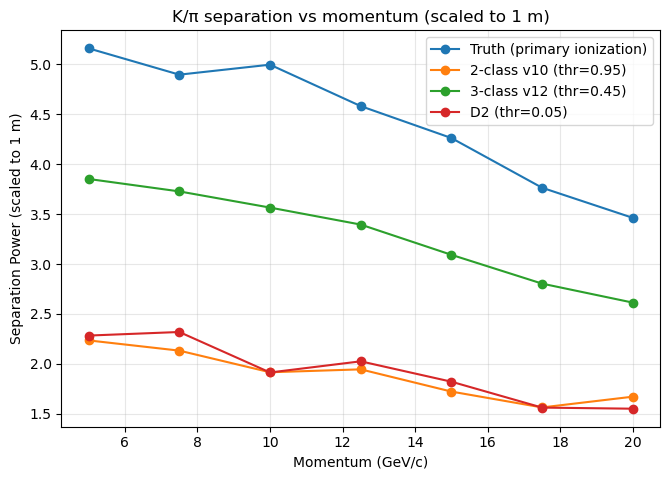

Saved: results/final_eval_threshold_scan_v10v12_D2_truth_fixed2/sep_curve_4lines_truth_v10_v12_D2.png


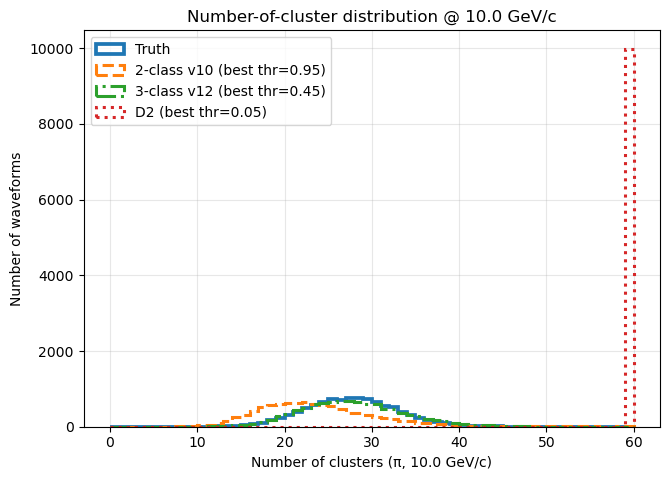

Saved: results/final_eval_threshold_scan_v10v12_D2_truth_fixed2/fig8_like_overlay_truth_v10_v12_D2.png

✅ Done. Outputs in: results/final_eval_threshold_scan_v10v12_D2_truth_fixed2


In [7]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0..batch_4

# checkpoints
BIN2_BEST_PT   = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"         # 2-class model (v10)
TRI3_BEST_PT   = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"     # 3-class model (v12)

OUTDIR = "results/final_eval_threshold_scan_v10v12_D2_truth_fixed2"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

# truth tag values (your dataset)
TAG_BG   = 0
TAG_PRI  = 1
TAG_SEC  = 2

# separation power scaling to 1m track (paper uses 18mm cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

# Paper: separation optimization uses fixed momenta
OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]

# ML threshold scan grid (probability)
THR_GRID = np.linspace(0.05, 0.95, 19)  # 0.05,0.10,...0.95

# D2 threshold scan grid (paper-like 0..1 axis; avoid ultra-low thresholds that explode counts)
D2_THR_GRID = np.linspace(0.05, 0.95, 19)

# Fig.8 histogram styling (paper-like range 0..60)
HIST_BINS = np.arange(0, 61, 1)  # integer bins so spikes are visible
FIG8_MOM = 10.0   # paper Fig.8 is 10 GeV/c pion sample

# D2 baseline parameters (tuned to avoid insane over-counting)
D2_SMOOTH_WIN   = 15    # stronger low-pass to suppress ripple peaks
D2_MERGE_WINDOW = 6     # merge peaks closer than this into one cluster
D2_NORM_PCTL    = 99.5  # normalize D2 score per waveform by a high percentile

# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        # x: (B, T, 1) -> conv wants (B, C, T)
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)   # (B, T, 128)
            fc = self.fc1(spk4)            # (B, T, 128)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)      # (B, T, num_classes)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)

# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "min/max:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    rows, cols = np.where(valid)
    t = tag_times[rows, cols]
    y[rows, t] = tag_values[rows, cols].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use=None):
    if moms_to_use is None:
        moms_to_use = sorted(np.unique(mom).tolist())

    moms_used, S = [], []
    for p in moms_to_use:
        mk = (np.isclose(mom, p)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p)) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_sep_power_4lines(moms, lines_dict, title, out_png):
    plt.figure(figsize=(6.8, 4.9))
    for label, y in lines_dict.items():
        plt.plot(moms, y, marker="o", label=label)
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_fig8_overlay_4(truth_counts, counts_2c, counts_3c, counts_d2, mom, pid,
                        best_thr2, best_thr3, best_thrd2, out_png):
    """
    One graph: Truth + 2-class + 3-class + D2.
    IMPORTANT: keep paper-like x-range 0..60, but clip D2 so it still appears.
    """
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xt = truth_counts[mask].astype(np.int32)
    x2 = counts_2c[mask].astype(np.int32)
    x3 = counts_3c[mask].astype(np.int32)
    xd = counts_d2[mask].astype(np.int32)

    if xt.size == 0:
        print("No events found for pid=PION and mom=10.0. Check np.unique(mom).")
        return

    # ---- critical: if D2 explodes >60, clip for a fair Fig.8-like overlay
    xd_plot = np.clip(xd, 0, 60)

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt, bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth")
    plt.hist(x2, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="--",
             label=f"2-class v10 (best thr={best_thr2:.2f})")
    plt.hist(x3, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="-.",
             label=f"3-class v12 (best thr={best_thr3:.2f})")
    plt.hist(xd_plot, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":",
             label=f"D2 (best thr={best_thrd2:.2f})")

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png)

# ---------------------------
# SNN inference → counts(thr)
# ---------------------------
def infer_counts_scan_thresholds(
    model,
    wf_i,
    scaler,
    device,
    thr_grid,
    which_model,
    use_bg_first=False,
    bg_purity_target=0.90,
    y_dense_truth=None,
):
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}
    extra = {}

    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    bg_thr = None
    if use_bg_first:
        if which_model != "3class":
            raise ValueError("BG-first only makes sense for the 3-class model.")
        if y_dense_truth is None:
            raise ValueError("BG-first requested but y_dense_truth is None.")

        rng = np.random.default_rng(0)
        idx = rng.choice(N, size=min(N, 50000), replace=False)
        xb = x_t[idx].to(device)

        with torch.inference_mode():
            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

        p_bg = probs[..., 0].detach().cpu().numpy().reshape(-1)
        truth_bg = (y_dense_truth[idx] == TAG_BG).reshape(-1)

        cand = np.linspace(0.05, 0.99, 50)
        best = None
        for thr in cand:
            pred_bg = (p_bg >= thr)
            tp = np.sum(pred_bg & truth_bg)
            fp = np.sum(pred_bg & (~truth_bg))
            if tp + fp == 0:
                continue
            purity = tp / (tp + fp)
            if purity >= bg_purity_target:
                best = thr
                break

        bg_thr = best if best is not None else 0.95
        extra["bg_thr"] = float(bg_thr)
        extra["bg_purity_target"] = float(bg_purity_target)
        print(f"[3-class] BG-first enabled: using bg_thr={bg_thr:.3f} (target purity={bg_purity_target:.3f})")

    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=f"Inference+scan ({which_model})", mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

            p_pri = probs[..., 1]

            if use_bg_first:
                p_bg = probs[..., 0]
                keep = (p_bg < bg_thr)
            else:
                keep = None

            for thr in thr_grid:
                if keep is None:
                    counts = (p_pri >= thr).sum(dim=1)
                else:
                    counts = ((p_pri >= thr) & keep).sum(dim=1)

                out[thr][idx0:idx0+bs] = counts.to(torch.int32).cpu().numpy()

            idx0 += bs

    return out, extra

def pick_best_threshold_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt):
    best_thr, best_score = None, -1e9
    curve = {}
    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_to_use=moms_for_opt)
        if S.size == 0:
            continue
        S_scaled = S * SCALE_TO_1M
        score = float(np.mean(S_scaled))
        curve[thr] = (moms_used, S_scaled, score)
        if score > best_score:
            best_score = score
            best_thr = thr
    return best_thr, best_score, curve

# ------------------------------------------------------------
# Paper-ish D2: second derivative with per-waveform normalization
# ------------------------------------------------------------
def d2_counts_scan_paperish(wf_i, thr_grid, smooth_win=15, merge_window=6, norm_pctl=99.5):
    """
    D2 baseline:
      - moving-average smooth
      - local maxima candidates via d1 sign flip +->-
      - D2 score = -d2 at candidate (concave-down strength)
      - normalize score per waveform by high percentile (0..1-ish axis like paper)
      - keep candidates where score_norm >= thr
      - merge nearby candidates into one cluster
    """
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}

    def smooth_ma(x, win):
        if win <= 1:
            return x
        k = np.ones(win, dtype=np.float32) / float(win)
        xp = np.pad(x, (win//2, win//2), mode="reflect")
        return np.convolve(xp, k, mode="valid")

    for n in tqdm(range(N), desc="D2 scan", mininterval=1.0):
        y = smooth_ma(wf_i[n].astype(np.float32), smooth_win)

        d1 = np.diff(y)          # len T-1
        d2 = np.diff(d1)         # len T-2 (align with y-index via d2[k-1])

        # local maxima candidates
        cand = np.where((d1[:-1] > 0) & (d1[1:] < 0))[0] + 1
        if cand.size == 0:
            for thr in thr_grid:
                out[thr][n] = 0
            continue

        score = (-d2[cand - 1]).astype(np.float32)
        sref = np.percentile(score, norm_pctl) + 1e-12
        score_norm = score / sref

        order = np.argsort(cand)
        cand_sorted = cand[order]
        score_sorted = score_norm[order]

        for thr in thr_grid:
            keep = cand_sorted[score_sorted >= thr]
            if keep.size == 0:
                out[thr][n] = 0
                continue

            clusters = 1
            last = keep[0]
            for t in keep[1:]:
                if (t - last) > merge_window:
                    clusters += 1
                    last = t
            out[thr][n] = int(clusters)

    return out, {"smooth_win": int(smooth_win), "merge_window": int(merge_window), "norm_pctl": float(norm_pctl)}

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)

    print("Truth primary-count mean:", float(truth_counts.mean()))
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ------------------------------------------------------------
    # Load SNN models
    # ------------------------------------------------------------
    model_2class = ConvSNN_Deep(num_classes=2).to(device)
    model_2class.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_3class = ConvSNN_Deep(num_classes=3).to(device)
    model_3class.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ------------------------------------------------------------
    # 2-class scan
    # ------------------------------------------------------------
    counts2_by_thr, _ = infer_counts_scan_thresholds(
        model_2class, wf_i, scaler, device, THR_GRID,
        which_model="2class",
        use_bg_first=False,
        y_dense_truth=None
    )
    best_thr2, best_score2, _ = pick_best_threshold_by_avg_sep(counts2_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[2-class v10] Best thr = {best_thr2:.2f}  avg sep(1m) = {best_score2:.4f}")

    # ------------------------------------------------------------
    # 3-class scan
    # ------------------------------------------------------------
    USE_BG_FIRST = False
    BG_PURITY_TARGET = 0.8986

    counts3_by_thr, extra3 = infer_counts_scan_thresholds(
        model_3class, wf_i, scaler, device, THR_GRID,
        which_model="3class",
        use_bg_first=USE_BG_FIRST,
        bg_purity_target=BG_PURITY_TARGET,
        y_dense_truth=y_dense
    )
    best_thr3, best_score3, _ = pick_best_threshold_by_avg_sep(counts3_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[3-class v12] Best thr = {best_thr3:.2f}  avg sep(1m) = {best_score3:.4f}")
    if USE_BG_FIRST:
        print(f"[3-class] BG-first info:", extra3)

    # ------------------------------------------------------------
    # D2 scan
    # ------------------------------------------------------------
    d2_by_thr, extra_d2 = d2_counts_scan_paperish(
        wf_i, D2_THR_GRID,
        smooth_win=D2_SMOOTH_WIN,
        merge_window=D2_MERGE_WINDOW,
        norm_pctl=D2_NORM_PCTL
    )
    best_thrd2, best_scored2, _ = pick_best_threshold_by_avg_sep(d2_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[D2] Best thr = {best_thrd2:.2f}  avg sep(1m) = {best_scored2:.4f}")
    print("[D2] info:", extra_d2)
    print()

    # ------------------------------------------------------------
    # Sanity prints @ 10 GeV pion
    # ------------------------------------------------------------
    mask10 = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xd10 = d2_by_thr[best_thrd2][mask10]
    if xd10.size > 0:
        print(f"[D2 @ {FIG8_MOM:.1f} GeV/c pion] min/mean/max:",
              int(xd10.min()), float(xd10.mean()), int(xd10.max()))
        print(f"[D2 @ {FIG8_MOM:.1f} GeV/c pion] frac within 0..60:",
              float(((xd10 >= 0) & (xd10 <= 60)).mean()))
    else:
        print("No pion@10GeV samples found.")

    # ------------------------------------------------------------
    # Separation curves (4 lines)
    # ------------------------------------------------------------
    moms, S_truth = separation_vs_momentum(truth_counts, mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_2     = separation_vs_momentum(counts2_by_thr[best_thr2], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_3     = separation_vs_momentum(counts3_by_thr[best_thr3], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_d2    = separation_vs_momentum(d2_by_thr[best_thrd2], mom, pid, moms_to_use=OPT_MOMENTA)

    plot_sep_power_4lines(
        moms=moms,
        lines_dict={
            "Truth (primary ionization)": S_truth * SCALE_TO_1M,
            f"2-class v10 (thr={best_thr2:.2f})": S_2 * SCALE_TO_1M,
            f"3-class v12 (thr={best_thr3:.2f})": S_3 * SCALE_TO_1M,
            f"D2 (thr={best_thrd2:.2f})": S_d2 * SCALE_TO_1M,
        },
        title="K/π separation vs momentum (scaled to 1 m)",
        out_png=os.path.join(OUTDIR, "sep_curve_4lines_truth_v10_v12_D2.png"),
    )

    # ------------------------------------------------------------
    # Fig.8-like cluster distribution overlay (Truth + v10 + v12 + D2)
    # ------------------------------------------------------------
    plot_fig8_overlay_4(
        truth_counts=truth_counts,
        counts_2c=counts2_by_thr[best_thr2],
        counts_3c=counts3_by_thr[best_thr3],
        counts_d2=d2_by_thr[best_thrd2],
        mom=mom,
        pid=pid,
        best_thr2=best_thr2,
        best_thr3=best_thr3,
        best_thrd2=best_thrd2,
        out_png=os.path.join(OUTDIR, "fig8_like_overlay_truth_v10_v12_D2.png"),
    )

    # ------------------------------------------------------------
    # Save thresholds/metadata
    # ------------------------------------------------------------
    np.savez(
        os.path.join(OUTDIR, "best_thresholds_v10v12_D2_truth.npz"),
        best_thr_2class=float(best_thr2),
        best_thr_3class=float(best_thr3),
        best_thr_D2=float(best_thrd2),
        best_avg_sep_2class=float(best_score2),
        best_avg_sep_3class=float(best_score3),
        best_avg_sep_D2=float(best_scored2),
        used_bg_first=False,
        d2_smooth_win=int(extra_d2["smooth_win"]),
        d2_merge_window=int(extra_d2["merge_window"]),
        d2_norm_pctl=float(extra_d2["norm_pctl"]),
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0..batch_4

# checkpoints
BIN2_BEST_PT   = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"         # 2-class model (v10)
TRI3_BEST_PT   = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"     # 3-class model (v12)

OUTDIR = "results/final_eval_threshold_scan_v10v12_D2_truth_paperfaithful"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

# truth tag values (your dataset)
TAG_BG   = 0
TAG_PRI  = 1
TAG_SEC  = 2

# separation power scaling to 1m track (paper uses 18mm cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

# Paper: separation optimization uses fixed momenta
OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]

# threshold scan grid for ML (probability)
THR_GRID = np.linspace(0.05, 0.95, 19)

# threshold scan grid for D2 (paper shows optimum near ~0.053 on [0,1] axis)
D2_THR_GRID = np.concatenate([
    np.linspace(0.01, 0.12, 24),   # dense near the optimum region
    np.linspace(0.14, 0.40, 14),
    np.linspace(0.45, 0.95, 11),
])

# Fig.8 histogram styling (paper ~0..60)
HIST_BINS = np.arange(0, 61, 1)
FIG8_MOM = 10.0

# D2 baseline parameters (paper-faithful behavior)
D2_SMOOTH_WIN   = 15     # low-pass (moving average) before derivatives
D2_MIN_DISTANCE = 6      # minimum separation between D2 candidates (samples)
D2_GLOBAL_PCTL  = 99.9   # global normalization reference for score -> [0,1]-like axis


# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)


# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}")
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n")
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}")
    print("  wf_i:", wf_i.shape, wf_i.dtype)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c)
    print("  tag_values unique:", np.unique(tag_values))
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print()
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===")
    print("wf_i:", wf.shape)
    print("mom :", mom.shape, "min/max:", float(mom.min()), float(mom.max()))
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c)
    print()
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based")
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    rows, cols = np.where(valid)
    t = tag_times[rows, cols]
    y[rows, t] = tag_values[rows, cols].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use=None):
    if moms_to_use is None:
        moms_to_use = sorted(np.unique(mom).tolist())

    moms_used, S = [], []
    for p in moms_to_use:
        mk = (np.isclose(mom, p)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p)) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_sep_power_4lines(moms, lines_dict, title, out_png):
    plt.figure(figsize=(6.8, 4.9))
    for label, y in lines_dict.items():
        plt.plot(moms, y, marker="o", label=label)
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png)

def plot_fig8_overlay_4(truth_counts, counts_2c, counts_3c, counts_d2, mom, pid,
                        best_thr2, best_thr3, best_thrd2, out_png):
    """
    Paper-like overlay range 0..60.
    (No clipping needed now if D2 behaves correctly. Still safe-clip at 60 to prevent plot blow-up.)
    """
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xt = truth_counts[mask].astype(np.int32)
    x2 = counts_2c[mask].astype(np.int32)
    x3 = counts_3c[mask].astype(np.int32)
    xd = counts_d2[mask].astype(np.int32)

    if xt.size == 0:
        print("No events found for pid=PION and mom=10.0. Check np.unique(mom).")
        return

    # safe clip to match Fig.8 axis (should NOT pile up if D2 is correct)
    xd_plot = np.clip(xd, 0, 60)

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt, bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth")
    plt.hist(x2, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="--",
             label=f"2-class v10 (best thr={best_thr2:.2f})")
    plt.hist(x3, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="-.",
             label=f"3-class v12 (best thr={best_thr3:.2f})")
    plt.hist(xd_plot, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":",
             label=f"D2 (best thr={best_thrd2:.4f})")

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png)

# ---------------------------
# SNN inference → counts(thr)
# ---------------------------
def infer_counts_scan_thresholds(
    model,
    wf_i,
    scaler,
    device,
    thr_grid,
    which_model,
    use_bg_first=False,
    bg_purity_target=0.90,
    y_dense_truth=None,
):
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}
    extra = {}

    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(device.type == "cuda"),
    )

    model.eval()
    torch.backends.cudnn.benchmark = (device.type == "cuda")
    use_amp = (device.type == "cuda")

    bg_thr = None
    if use_bg_first:
        if which_model != "3class":
            raise ValueError("BG-first only makes sense for the 3-class model.")
        if y_dense_truth is None:
            raise ValueError("BG-first requested but y_dense_truth is None.")

        rng = np.random.default_rng(0)
        idx = rng.choice(N, size=min(N, 50000), replace=False)
        xb = x_t[idx].to(device)

        with torch.inference_mode():
            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

        p_bg = probs[..., 0].detach().cpu().numpy().reshape(-1)
        truth_bg = (y_dense_truth[idx] == TAG_BG).reshape(-1)

        cand = np.linspace(0.05, 0.99, 50)
        best = None
        for thr in cand:
            pred_bg = (p_bg >= thr)
            tp = np.sum(pred_bg & truth_bg)
            fp = np.sum(pred_bg & (~truth_bg))
            if tp + fp == 0:
                continue
            purity = tp / (tp + fp)
            if purity >= bg_purity_target:
                best = thr
                break

        bg_thr = best if best is not None else 0.95
        extra["bg_thr"] = float(bg_thr)
        extra["bg_purity_target"] = float(bg_purity_target)
        print(f"[3-class] BG-first enabled: using bg_thr={bg_thr:.3f} (target purity={bg_purity_target:.3f})")

    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=f"Inference+scan ({which_model})", mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

            p_pri = probs[..., 1]

            if use_bg_first:
                p_bg = probs[..., 0]
                keep = (p_bg < bg_thr)
            else:
                keep = None

            for thr in thr_grid:
                if keep is None:
                    counts = (p_pri >= thr).sum(dim=1)
                else:
                    counts = ((p_pri >= thr) & keep).sum(dim=1)
                out[thr][idx0:idx0+bs] = counts.to(torch.int32).cpu().numpy()

            idx0 += bs

    return out, extra

def pick_best_threshold_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt):
    best_thr, best_score = None, -1e9
    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_to_use=moms_for_opt)
        if S.size == 0:
            continue
        S_scaled = S * SCALE_TO_1M
        score = float(np.mean(S_scaled))
        if score > best_score:
            best_score = score
            best_thr = thr
    return best_thr, best_score

# ------------------------------------------------------------
# PAPER-FAITHFUL D2:
# - smooth waveform
# - compute 2nd derivative
# - candidates = local maxima of (-d2)
# - threshold acts on 2nd derivative (normalized to [0,1]-like axis)
# ------------------------------------------------------------
def compute_global_d2_norm_ref(wf_i, smooth_win=15, pctl=99.9, max_events=20000, seed=0):
    """
    Build a GLOBAL normalization reference so D2 threshold is comparable to paper's [0,1] axis.
    We compute score = -d2 after smoothing and take a high percentile as the reference.
    """
    rng = np.random.default_rng(seed)
    N = wf_i.shape[0]
    idx = rng.choice(N, size=min(N, max_events), replace=False)

    def smooth_ma(x, win):
        if win <= 1:
            return x
        k = np.ones(win, dtype=np.float32) / float(win)
        xp = np.pad(x, (win//2, win//2), mode="reflect")
        return np.convolve(xp, k, mode="valid")

    scores = []
    for j in tqdm(idx, desc="Compute D2 global norm ref", mininterval=1.0):
        y = smooth_ma(wf_i[j].astype(np.float32), smooth_win)
        d2 = np.diff(np.diff(y))
        score = (-d2)  # concavity-down strength
        # keep only positive part (we only look for concave-down peaks)
        score = score[score > 0]
        if score.size > 0:
            scores.append(score)

    if len(scores) == 0:
        raise RuntimeError("Global D2 normalization failed: no positive scores collected.")

    scores = np.concatenate(scores)
    ref = np.percentile(scores, pctl) + 1e-12
    print(f"[D2] global norm ref = P{pctl}(-d2) = {ref:.6g}")
    return float(ref)

def d2_counts_scan_paperfaithful(wf_i, thr_grid, d2_ref,
                                smooth_win=15, min_distance=6):
    """
    Counts peaks by D2 peak-finding:
      score = (-d2)/d2_ref  (paper-like 0..1 axis)
      candidates = local maxima of score
      accept candidate if score_peak >= threshold
    """
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}

    def smooth_ma(x, win):
        if win <= 1:
            return x
        k = np.ones(win, dtype=np.float32) / float(win)
        xp = np.pad(x, (win//2, win//2), mode="reflect")
        return np.convolve(xp, k, mode="valid")

    for n in tqdm(range(N), desc="D2 scan (paper-faithful)", mininterval=1.0):
        y = smooth_ma(wf_i[n].astype(np.float32), smooth_win)
        d2 = np.diff(np.diff(y))                 # len T-2
        score = (-d2) / d2_ref                   # normalize to paper-like axis
        score[score < 0] = 0.0                   # only concave-down

        # candidates = local maxima of score (this is the missing piece in your old code)
        peaks, props = find_peaks(score, distance=min_distance)
        if peaks.size == 0:
            for thr in thr_grid:
                out[thr][n] = 0
            continue

        peak_heights = score[peaks]

        # For each threshold: count candidates above threshold
        # (This matches paper: threshold acts on second derivative; candidates above are peaks.)
        # No extra amplitude gating here (paper definition is derivative thresholding).
        for thr in thr_grid:
            out[thr][n] = int(np.sum(peak_heights >= thr))

    return out, {"smooth_win": int(smooth_win), "min_distance": int(min_distance), "d2_ref": float(d2_ref)}

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n")

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)

    print("Truth primary-count mean:", float(truth_counts.mean()))
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)))
    print()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
    print()

    # ------------------------------------------------------------
    # Load models
    # ------------------------------------------------------------
    model_2class = ConvSNN_Deep(num_classes=2).to(device)
    model_2class.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_3class = ConvSNN_Deep(num_classes=3).to(device)
    model_3class.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ------------------------------------------------------------
    # 2-class scan
    # ------------------------------------------------------------
    counts2_by_thr, _ = infer_counts_scan_thresholds(
        model_2class, wf_i, scaler, device, THR_GRID,
        which_model="2class",
        use_bg_first=False,
        y_dense_truth=None
    )
    best_thr2, best_score2 = pick_best_threshold_by_avg_sep(counts2_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[2-class v10] Best thr = {best_thr2:.2f}  avg sep(1m) = {best_score2:.4f}")

    # ------------------------------------------------------------
    # 3-class scan
    # ------------------------------------------------------------
    USE_BG_FIRST = False
    BG_PURITY_TARGET = 0.8986

    counts3_by_thr, extra3 = infer_counts_scan_thresholds(
        model_3class, wf_i, scaler, device, THR_GRID,
        which_model="3class",
        use_bg_first=USE_BG_FIRST,
        bg_purity_target=BG_PURITY_TARGET,
        y_dense_truth=y_dense
    )
    best_thr3, best_score3 = pick_best_threshold_by_avg_sep(counts3_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[3-class v12] Best thr = {best_thr3:.2f}  avg sep(1m) = {best_score3:.4f}")
    if USE_BG_FIRST:
        print(f"[3-class] BG-first info:", extra3)

    # ------------------------------------------------------------
    # D2: compute GLOBAL normalization ref, then scan thresholds
    # ------------------------------------------------------------
    d2_ref = compute_global_d2_norm_ref(
        wf_i,
        smooth_win=D2_SMOOTH_WIN,
        pctl=D2_GLOBAL_PCTL,
        max_events=20000,
        seed=0
    )

    d2_by_thr, extra_d2 = d2_counts_scan_paperfaithful(
        wf_i,
        D2_THR_GRID,
        d2_ref=d2_ref,
        smooth_win=D2_SMOOTH_WIN,
        min_distance=D2_MIN_DISTANCE
    )

    best_thrd2, best_scored2 = pick_best_threshold_by_avg_sep(d2_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[D2] Best thr = {best_thrd2:.4f}  avg sep(1m) = {best_scored2:.4f}")
    print("[D2] info:", extra_d2)
    print()

    # ------------------------------------------------------------
    # Sanity print: D2 @ 10 GeV pion
    # ------------------------------------------------------------
    mask10 = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM))
    xd10 = d2_by_thr[best_thrd2][mask10]
    if xd10.size > 0:
        print(f"[D2 @ {FIG8_MOM:.1f} GeV/c pion] min/mean/max:",
              int(xd10.min()), float(xd10.mean()), int(xd10.max()))
        print(f"[D2 @ {FIG8_MOM:.1f} GeV/c pion] frac > 60:",
              float((xd10 > 60).mean()))
    else:
        print("No pion@10GeV samples found.")

    # ------------------------------------------------------------
    # Separation plot (Truth + v10 + v12 + D2)
    # ------------------------------------------------------------
    moms, S_truth = separation_vs_momentum(truth_counts, mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_2     = separation_vs_momentum(counts2_by_thr[best_thr2], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_3     = separation_vs_momentum(counts3_by_thr[best_thr3], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_d2    = separation_vs_momentum(d2_by_thr[best_thrd2], mom, pid, moms_to_use=OPT_MOMENTA)

    plot_sep_power_4lines(
        moms=moms,
        lines_dict={
            "Truth (primary ionization)": S_truth * SCALE_TO_1M,
            f"2-class v10 (thr={best_thr2:.2f})": S_2 * SCALE_TO_1M,
            f"3-class v12 (thr={best_thr3:.2f})": S_3 * SCALE_TO_1M,
            f"D2 (thr={best_thrd2:.4f})": S_d2 * SCALE_TO_1M,
        },
        title="K/π separation vs momentum (scaled to 1 m)",
        out_png=os.path.join(OUTDIR, "sep_curve_4lines_truth_v10_v12_D2.png"),
    )

    # ------------------------------------------------------------
    # Fig.8-like histogram overlay (Truth + v10 + v12 + D2)
    # ------------------------------------------------------------
    plot_fig8_overlay_4(
        truth_counts=truth_counts,
        counts_2c=counts2_by_thr[best_thr2],
        counts_3c=counts3_by_thr[best_thr3],
        counts_d2=d2_by_thr[best_thrd2],
        mom=mom,
        pid=pid,
        best_thr2=best_thr2,
        best_thr3=best_thr3,
        best_thrd2=best_thrd2,
        out_png=os.path.join(OUTDIR, "fig8_like_overlay_truth_v10_v12_D2.png"),
    )

    # ------------------------------------------------------------
    # Save thresholds/metadata
    # ------------------------------------------------------------
    np.savez(
        os.path.join(OUTDIR, "best_thresholds_v10v12_D2_truth.npz"),
        best_thr_2class=float(best_thr2),
        best_thr_3class=float(best_thr3),
        best_thr_D2=float(best_thrd2),
        best_avg_sep_2class=float(best_score2),
        best_avg_sep_3class=float(best_score3),
        best_avg_sep_D2=float(best_scored2),
        d2_ref=float(d2_ref),
        d2_smooth_win=int(D2_SMOOTH_WIN),
        d2_min_distance=int(D2_MIN_DISTANCE),
        d2_global_pctl=float(D2_GLOBAL_PCTL),
        used_bg_first=bool(USE_BG_FIRST),
        bg_thr=float(extra3.get("bg_thr", np.nan)) if isinstance(extra3, dict) else np.nan,
    )

    print("\n✅ Done. Outputs in:", OUTDIR)

if __name__ == "__main__":
    main()


Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 19.99993896484375
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_4.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001369714736938 19.999898910522

Inference+scan (2class):   0%|          | 1/1719 [01:50<52:34:00, 110.15s/it]

START fast truth vs D2
Loading: PionsKaons/batch_0.npz
Loaded NPZ in 0.00s
wf_i: (100000, 3000) T= 3000
[FAST] random subset N=20000
Truth mean/std: 25.87495 5.357270528438502
Usable OPT momenta in subset: [10.0, 12.5, 15.0, 20.0]
[D2] global ref P99.9(-d2)+ = 0.0651243
Computing D2 counts...
[D2] processed 2000/20000 waveforms in 0.8s
[D2] processed 4000/20000 waveforms in 1.5s
[D2] processed 6000/20000 waveforms in 2.3s
[D2] processed 8000/20000 waveforms in 3.0s
[D2] processed 10000/20000 waveforms in 3.8s
[D2] processed 12000/20000 waveforms in 4.5s
[D2] processed 14000/20000 waveforms in 5.2s
[D2] processed 16000/20000 waveforms in 6.0s
[D2] processed 18000/20000 waveforms in 6.7s
[D2] processed 20000/20000 waveforms in 7.5s
[D2] Best thr=0.1152 avg sep(1m)=2.8160
[D2 @10GeV π] min/mean/max: 8 23.848710317460316 59


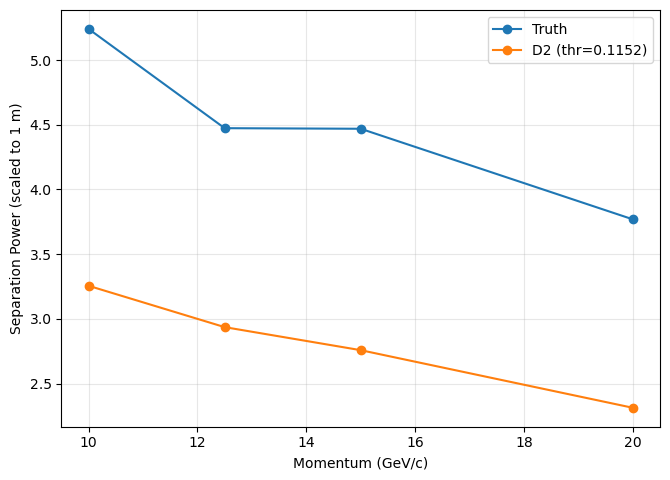

Saved: results/fast_truth_vs_D2_batch0/sep_truth_vs_D2.png


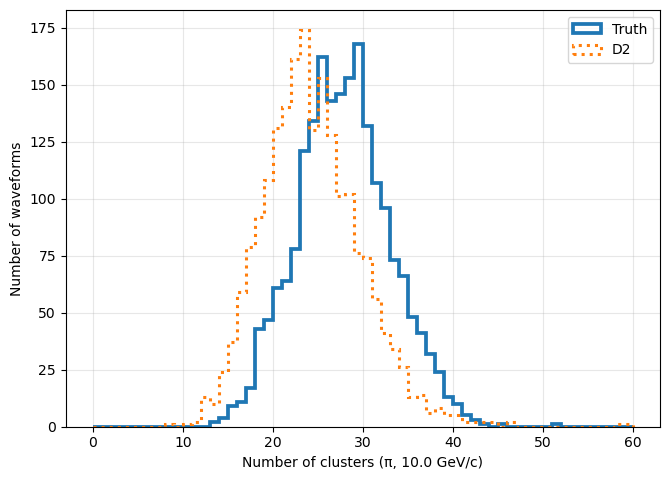

Saved: results/fast_truth_vs_D2_batch0/hist_truth_vs_D2_10GeVpi.png
DONE


In [5]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ---------------- CONFIG ----------------
NPZ_PATH = "PionsKaons/batch_0.npz"   # FAST: only batch_0
OUTDIR = "results/fast_truth_vs_D2_batch0"
os.makedirs(OUTDIR, exist_ok=True)

PID_KAON = 130
PID_PION = 211
TAG_BG, TAG_PRI, TAG_SEC = 0, 1, 2

CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
FIG8_MOM = 10.0
HIST_BINS = np.arange(0, 61, 1)

FAST_N_MAX = 20000     # quick test
FAST_SEED  = 0         # random subset seed

D2_SMOOTH_WIN = 15
D2_MIN_DISTANCE = 8
D2_GLOBAL_PCTL = 99.9
D2_THR_GRID = np.concatenate([
    np.linspace(0.01, 0.12, 24),
    np.linspace(0.14, 0.40, 14),
    np.linspace(0.45, 0.95, 11),
])

# -------------- helpers --------------
def smooth_ma(x, win):
    if win <= 1:
        return x
    k = np.ones(win, dtype=np.float32) / float(win)
    xp = np.pad(x, (win//2, win//2), mode="reflect")
    return np.convolve(xp, k, mode="valid")

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times -> converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    r, c = np.where(valid)
    t = tag_times[r, c]
    y[r, t] = tag_values[r, c].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use, atol=0.05, min_per_class=50):
    moms_used, S = [], []
    for p in moms_to_use:
        mk  = (np.isclose(mom, p, atol=atol)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p, atol=atol)) & (pid == PID_PION)
        if mk.sum() < min_per_class or mpi.sum() < min_per_class:
            continue
        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        moms_used.append(float(p))
        S.append(float(sep_paper(a.mean(), a.std(ddof=1), b.mean(), b.std(ddof=1))))
    return np.array(moms_used), np.array(S)

def pick_momenta_present(mom, pid, opt_momenta, min_per_class=50, atol=0.05):
    present = []
    for p in opt_momenta:
        mk  = (np.isclose(mom, p, atol=atol)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p, atol=atol)) & (pid == PID_PION)
        if mk.sum() >= min_per_class and mpi.sum() >= min_per_class:
            present.append(float(p))
    return present

def fallback_momenta_from_data(mom, pid, topk=7, min_per_class=50):
    mom_round = np.round(mom * 2) / 2.0  # round to 0.5 GeV
    vals, cnts = np.unique(mom_round, return_counts=True)
    order = np.argsort(-cnts)
    ok = []
    for v in vals[order]:
        mk  = (mom_round == v) & (pid == PID_KAON)
        mpi = (mom_round == v) & (pid == PID_PION)
        if mk.sum() >= min_per_class and mpi.sum() >= min_per_class:
            ok.append(float(v))
        if len(ok) >= topk:
            break
    return ok

def compute_global_d2_ref(wf_i, smooth_win, pctl):
    pool = []
    for i in range(min(len(wf_i), 5000)):
        y = smooth_ma(wf_i[i], smooth_win)
        d2 = np.diff(np.diff(y))
        score = (-d2)
        score = score[score > 0]
        if score.size:
            pool.append(score)
    if not pool:
        raise RuntimeError("No positive -d2 values collected. Check polarity/smoothing.")
    pool = np.concatenate(pool)
    ref = np.percentile(pool, pctl) + 1e-12
    print(f"[D2] global ref P{pctl}(-d2)+ = {ref:.6g}", flush=True)
    return float(ref)

def d2_counts_all(wf_i, thr_grid, d2_ref, smooth_win, min_distance):
    N = wf_i.shape[0]
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros(N, dtype=np.int32) for thr in thr_grid}

    t0 = time.time()
    for n in range(N):
        y = smooth_ma(wf_i[n], smooth_win)
        d2 = np.diff(np.diff(y))
        score = (-d2) / d2_ref
        score[score < 0] = 0.0

        peaks, _ = find_peaks(score, distance=min_distance)
        if peaks.size:
            heights = np.sort(score[peaks])
            for thr in thr_grid:
                k = np.searchsorted(heights, thr, side="left")
                out[thr][n] = int(heights.size - k)

        if (n + 1) % 2000 == 0:
            dt = time.time() - t0
            print(f"[D2] processed {n+1}/{N} waveforms in {dt:.1f}s", flush=True)

    return out

def pick_best_thr_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt, atol=0.05):
    best_thr, best_score = None, -1e9
    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_for_opt, atol=atol)
        if S.size == 0:
            continue
        score = float(np.mean(S * SCALE_TO_1M))
        if score > best_score:
            best_score = score
            best_thr = thr
    return best_thr, best_score

# -------------- main --------------
def main():
    print("START fast truth vs D2", flush=True)
    print("Loading:", NPZ_PATH, flush=True)
    t_load = time.time()
    d = np.load(NPZ_PATH)
    print(f"Loaded NPZ in {time.time()-t_load:.2f}s", flush=True)

    wf_i = d["wf_i"].astype(np.float32)
    mom  = d["mom"].astype(np.float32)
    pid  = d["pid"].astype(np.int32)
    tag_times  = d["tag_times"].astype(np.int32)
    tag_values = d["tag_values"].astype(np.int32)

    N, T = wf_i.shape
    print("wf_i:", wf_i.shape, "T=", T, flush=True)

    # ---- FIX: random subset (not first N)
    if FAST_N_MAX is not None and N > FAST_N_MAX:
        rng = np.random.default_rng(FAST_SEED)
        idx = rng.choice(N, size=FAST_N_MAX, replace=False)
        wf_i = wf_i[idx]
        mom  = mom[idx]
        pid  = pid[idx]
        tag_times = tag_times[idx]
        tag_values = tag_values[idx]
        print(f"[FAST] random subset N={FAST_N_MAX}", flush=True)

    tag_times = ensure_0_based_tag_times(tag_times, T)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)
    print("Truth mean/std:", float(truth_counts.mean()), float(truth_counts.std(ddof=1)), flush=True)

    # ---- FIX: choose usable momenta (avoid None best_thr)
    moms_for_opt = pick_momenta_present(mom, pid, OPT_MOMENTA, min_per_class=50, atol=0.05)
    print("Usable OPT momenta in subset:", moms_for_opt, flush=True)

    if len(moms_for_opt) < 2:
        moms_for_opt = fallback_momenta_from_data(mom, pid, topk=7, min_per_class=50)
        print("Fallback momenta (rounded to 0.5 GeV):", moms_for_opt, flush=True)

    if len(moms_for_opt) == 0:
        raise RuntimeError("No momentum points have enough K and π samples. Increase FAST_N_MAX or use another batch.")

    d2_ref = compute_global_d2_ref(wf_i, D2_SMOOTH_WIN, D2_GLOBAL_PCTL)

    print("Computing D2 counts...", flush=True)
    d2_by_thr = d2_counts_all(wf_i, D2_THR_GRID, d2_ref, D2_SMOOTH_WIN, D2_MIN_DISTANCE)

    best_thrd2, best_scored2 = pick_best_thr_by_avg_sep(d2_by_thr, mom, pid, moms_for_opt, atol=0.05)
    if best_thrd2 is None:
        raise RuntimeError("Could not pick best D2 threshold (no valid momentum points). Try larger FAST_N_MAX.")
    print(f"[D2] Best thr={best_thrd2:.4f} avg sep(1m)={best_scored2:.4f}", flush=True)

    # sanity at 10 GeV pion (may be empty in subset; that's ok)
    mask10 = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=0.05))
    xd10 = d2_by_thr[best_thrd2][mask10]
    if xd10.size:
        print("[D2 @10GeV π] min/mean/max:", int(xd10.min()), float(xd10.mean()), int(xd10.max()), flush=True)
    else:
        print("[INFO] No π@10GeV in subset (this is fine for fast test).", flush=True)

    # plot separation: Truth vs D2
    moms_used, S_truth = separation_vs_momentum(truth_counts, mom, pid, moms_for_opt, atol=0.05)
    _,         S_d2    = separation_vs_momentum(d2_by_thr[best_thrd2], mom, pid, moms_for_opt, atol=0.05)

    plt.figure(figsize=(6.8,4.9))
    plt.plot(moms_used, S_truth * SCALE_TO_1M, marker="o", label="Truth")
    plt.plot(moms_used, S_d2 * SCALE_TO_1M, marker="o", label=f"D2 (thr={best_thrd2:.4f})")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    out1 = os.path.join(OUTDIR, "sep_truth_vs_D2.png")
    plt.savefig(out1, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out1, flush=True)

    # plot distribution @10 GeV pion if exists
    if mask10.sum() > 0:
        xt = truth_counts[mask10].astype(np.int32)
        xd = d2_by_thr[best_thrd2][mask10].astype(np.int32)
        xd_plot = np.clip(xd, 0, 60)

        plt.figure(figsize=(6.8,4.9))
        plt.hist(xt, bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth")
        plt.hist(xd_plot, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":", label="D2")
        plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
        plt.ylabel("Number of waveforms")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        out2 = os.path.join(OUTDIR, "hist_truth_vs_D2_10GeVpi.png")
        plt.savefig(out2, dpi=170)
        plt.show()
        plt.close()
        print("Saved:", out2, flush=True)
    else:
        print("[INFO] Skipping 10 GeV π histogram (no samples in subset).", flush=True)

    print("DONE", flush=True)

if __name__ == "__main__":
    main()


START fast truth vs D2 (paper-style calib)
Loading: PionsKaons/batch_0.npz
Loaded NPZ in 0.00s
wf_i: (100000, 3000) T= 3000
[FAST] random subset N=20000
Truth mean/std: 25.87495 5.357270528438502
[D2] global ref P99.9(-d2)+ = 0.0651243
Computing D2 counts...
[D2] processed 2000/20000 waveforms in 0.8s
[D2] processed 4000/20000 waveforms in 1.5s
[D2] processed 6000/20000 waveforms in 2.3s
[D2] processed 8000/20000 waveforms in 3.0s
[D2] processed 10000/20000 waveforms in 3.8s
[D2] processed 12000/20000 waveforms in 4.5s
[D2] processed 14000/20000 waveforms in 5.3s
[D2] processed 16000/20000 waveforms in 6.0s
[D2] processed 18000/20000 waveforms in 6.8s
[D2] processed 20000/20000 waveforms in 7.5s
[D2] Calib @ 10.0 GeV/c: best thr=0.1152, sep=0.4368 (valid thr=49)


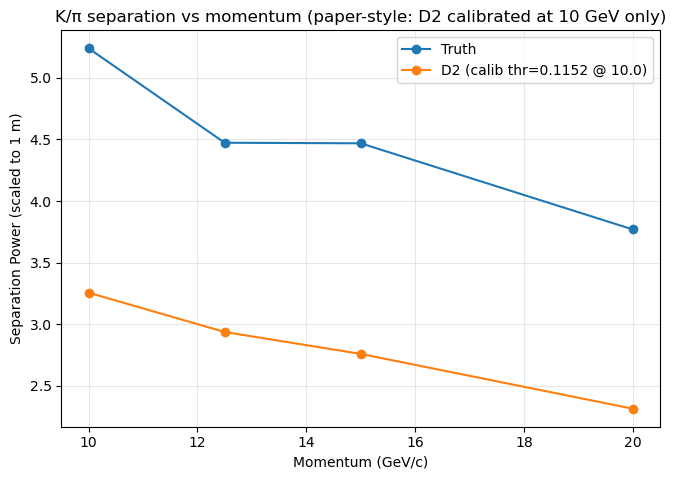

Saved: results/fast_truth_vs_D2_batch0_paperstyle/sep_truth_vs_D2_paperstyle.png
[D2 @10GeV π] min/mean/max: 8 23.848710317460316 59


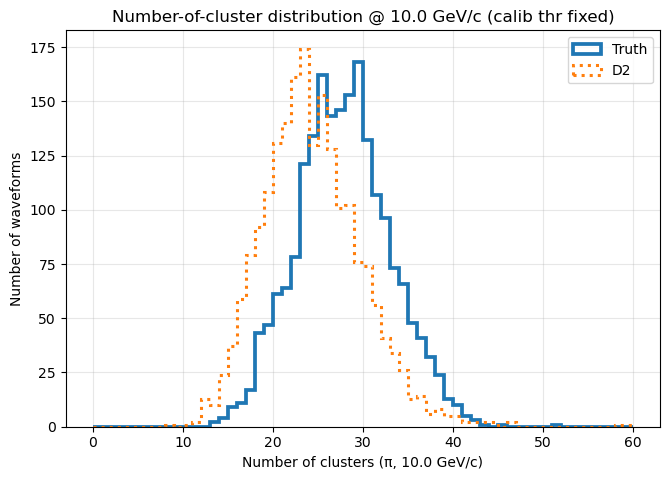

Saved: results/fast_truth_vs_D2_batch0_paperstyle/hist_truth_vs_D2_10GeVpi_paperstyle.png
DONE


In [6]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ---------------- CONFIG ----------------
NPZ_PATH = "PionsKaons/batch_0.npz"   # FAST: only batch_0
OUTDIR = "results/fast_truth_vs_D2_batch0_paperstyle"
os.makedirs(OUTDIR, exist_ok=True)

PID_KAON = 130
PID_PION = 211
TAG_BG, TAG_PRI, TAG_SEC = 0, 1, 2

CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

# momenta we want to report (paper)
OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
FIG8_MOM = 10.0
HIST_BINS = np.arange(0, 61, 1)

# FAST subset
FAST_N_MAX = 20000
FAST_SEED  = 0

# D2 settings
D2_SMOOTH_WIN = 15
D2_MIN_DISTANCE = 8
D2_GLOBAL_PCTL = 99.9

# Scan grid (paper shows optimum ~0.05-ish; include that region densely)
D2_THR_GRID = np.concatenate([
    np.linspace(0.01, 0.12, 24),
    np.linspace(0.14, 0.40, 14),
    np.linspace(0.45, 0.95, 11),
])

# ---- PAPER-STYLE: choose threshold on ONE calibration momentum ONLY
CALIB_MOM = 10.0
MOM_ATOL  = 0.05
MIN_PER_CLASS = 50


# -------------- helpers --------------
def smooth_ma(x, win):
    if win <= 1:
        return x
    k = np.ones(win, dtype=np.float32) / float(win)
    xp = np.pad(x, (win//2, win//2), mode="reflect")
    return np.convolve(xp, k, mode="valid")

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times -> converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    r, c = np.where(valid)
    t = tag_times[r, c]
    y[r, t] = tag_values[r, c].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_at_momentum(counts, mom, pid, p, atol=MOM_ATOL, min_per_class=MIN_PER_CLASS):
    mk  = (np.isclose(mom, p, atol=atol)) & (pid == PID_KAON)
    mpi = (np.isclose(mom, p, atol=atol)) & (pid == PID_PION)
    if mk.sum() < min_per_class or mpi.sum() < min_per_class:
        return None
    a = counts[mk].astype(np.float64)
    b = counts[mpi].astype(np.float64)
    return float(sep_paper(a.mean(), a.std(ddof=1), b.mean(), b.std(ddof=1)))

def separation_vs_momentum(counts, mom, pid, moms_to_use):
    moms_used, S = [], []
    for p in moms_to_use:
        s = separation_at_momentum(counts, mom, pid, p)
        if s is None:
            continue
        moms_used.append(float(p))
        S.append(float(s))
    return np.array(moms_used), np.array(S)

def compute_global_d2_ref(wf_i, smooth_win, pctl):
    pool = []
    for i in range(min(len(wf_i), 5000)):
        y = smooth_ma(wf_i[i], smooth_win)
        d2 = np.diff(np.diff(y))
        score = (-d2)
        score = score[score > 0]
        if score.size:
            pool.append(score)
    if not pool:
        raise RuntimeError("No positive -d2 values collected. Check polarity/smoothing.")
    pool = np.concatenate(pool)
    ref = np.percentile(pool, pctl) + 1e-12
    print(f"[D2] global ref P{pctl}(-d2)+ = {ref:.6g}", flush=True)
    return float(ref)

def d2_counts_all(wf_i, thr_grid, d2_ref, smooth_win, min_distance):
    N = wf_i.shape[0]
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros(N, dtype=np.int32) for thr in thr_grid}

    t0 = time.time()
    for n in range(N):
        y = smooth_ma(wf_i[n], smooth_win)
        d2 = np.diff(np.diff(y))
        score = (-d2) / d2_ref
        score[score < 0] = 0.0

        peaks, _ = find_peaks(score, distance=min_distance)
        if peaks.size:
            heights = np.sort(score[peaks])
            for thr in thr_grid:
                k = np.searchsorted(heights, thr, side="left")
                out[thr][n] = int(heights.size - k)

        if (n + 1) % 2000 == 0:
            dt = time.time() - t0
            print(f"[D2] processed {n+1}/{N} waveforms in {dt:.1f}s", flush=True)

    return out

# ---- PAPER-STYLE threshold choice:
# choose thr ONLY on CALIB_MOM (e.g. 10 GeV), then freeze
def pick_thr_on_calib_momentum(d2_by_thr, mom, pid, calib_mom):
    best_thr, best_s = None, -1e9
    valid = 0
    for thr, counts in d2_by_thr.items():
        s = separation_at_momentum(counts, mom, pid, calib_mom)
        if s is None:
            continue
        valid += 1
        if s > best_s:
            best_s = s
            best_thr = thr
    return best_thr, best_s, valid


# -------------- main --------------
def main():
    print("START fast truth vs D2 (paper-style calib)", flush=True)
    print("Loading:", NPZ_PATH, flush=True)
    t_load = time.time()
    d = np.load(NPZ_PATH)
    print(f"Loaded NPZ in {time.time()-t_load:.2f}s", flush=True)

    wf_i = d["wf_i"].astype(np.float32)
    mom  = d["mom"].astype(np.float32)
    pid  = d["pid"].astype(np.int32)
    tag_times  = d["tag_times"].astype(np.int32)
    tag_values = d["tag_values"].astype(np.int32)

    N, T = wf_i.shape
    print("wf_i:", wf_i.shape, "T=", T, flush=True)

    # random subset (important)
    if FAST_N_MAX is not None and N > FAST_N_MAX:
        rng = np.random.default_rng(FAST_SEED)
        idx = rng.choice(N, size=FAST_N_MAX, replace=False)
        wf_i = wf_i[idx]
        mom  = mom[idx]
        pid  = pid[idx]
        tag_times = tag_times[idx]
        tag_values = tag_values[idx]
        print(f"[FAST] random subset N={FAST_N_MAX}", flush=True)

    tag_times = ensure_0_based_tag_times(tag_times, T)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)
    print("Truth mean/std:", float(truth_counts.mean()), float(truth_counts.std(ddof=1)), flush=True)

    d2_ref = compute_global_d2_ref(wf_i, D2_SMOOTH_WIN, D2_GLOBAL_PCTL)

    print("Computing D2 counts...", flush=True)
    d2_by_thr = d2_counts_all(wf_i, D2_THR_GRID, d2_ref, D2_SMOOTH_WIN, D2_MIN_DISTANCE)

    # ---- PAPER-STYLE: calibrate ONLY at CALIB_MOM
    best_thrd2, best_sep_calib, nvalid = pick_thr_on_calib_momentum(d2_by_thr, mom, pid, CALIB_MOM)
    if best_thrd2 is None:
        raise RuntimeError(
            f"No valid D2 thresholds at calib momentum {CALIB_MOM} GeV/c "
            f"(need >= {MIN_PER_CLASS} Kaons and Pions in subset). "
            f"Increase FAST_N_MAX or use different batch."
        )
    print(f"[D2] Calib @ {CALIB_MOM:.1f} GeV/c: best thr={best_thrd2:.4f}, sep={best_sep_calib:.4f} (valid thr={nvalid})", flush=True)

    # ---- Evaluate on all momenta USING THIS FIXED THR
    moms_used, S_truth = separation_vs_momentum(truth_counts, mom, pid, OPT_MOMENTA)
    _,         S_d2    = separation_vs_momentum(d2_by_thr[best_thrd2], mom, pid, OPT_MOMENTA)

    # plot separation (scaled)
    plt.figure(figsize=(6.8,4.9))
    plt.plot(moms_used, S_truth * SCALE_TO_1M, marker="o", label="Truth")
    plt.plot(moms_used, S_d2 * SCALE_TO_1M, marker="o", label=f"D2 (calib thr={best_thrd2:.4f} @ {CALIB_MOM:.1f})")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title("K/π separation vs momentum (paper-style: D2 calibrated at 10 GeV only)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    out1 = os.path.join(OUTDIR, "sep_truth_vs_D2_paperstyle.png")
    plt.savefig(out1, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out1, flush=True)

    # histogram @10 GeV pion
    mask10 = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=MOM_ATOL))
    if mask10.sum() > 0:
        xt = truth_counts[mask10].astype(np.int32)
        xd = d2_by_thr[best_thrd2][mask10].astype(np.int32)
        print(f"[D2 @10GeV π] min/mean/max:", int(xd.min()), float(xd.mean()), int(xd.max()), flush=True)

        plt.figure(figsize=(6.8,4.9))
        plt.hist(xt, bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth")
        plt.hist(np.clip(xd, 0, 60), bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":", label="D2")
        plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
        plt.ylabel("Number of waveforms")
        plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c (calib thr fixed)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        out2 = os.path.join(OUTDIR, "hist_truth_vs_D2_10GeVpi_paperstyle.png")
        plt.savefig(out2, dpi=170)
        plt.show()
        plt.close()
        print("Saved:", out2, flush=True)
    else:
        print("[INFO] No π@10GeV in subset; skipping histogram.", flush=True)

    print("DONE", flush=True)

if __name__ == "__main__":
    main()


START Truth vs paper-style D2
Loading: PionsKaons/batch_0.npz
Loaded NPZ in 0.00s
wf_i: (100000, 3000) T= 3000
[FAST] random subset N=20000
Truth mean/std: 25.87495 5.357270528438502
Computing D2 (paper-style): thr=0.053, smooth_win=5, min_dist=6, polarity=1
[D2] processed 2000/20000 in 0.2s
[D2] processed 4000/20000 in 0.3s
[D2] processed 6000/20000 in 0.5s
[D2] processed 8000/20000 in 0.6s
[D2] processed 10000/20000 in 0.8s
[D2] processed 12000/20000 in 0.9s
[D2] processed 14000/20000 in 1.1s
[D2] processed 16000/20000 in 1.2s
[D2] processed 18000/20000 in 1.4s
[D2] processed 20000/20000 in 1.5s


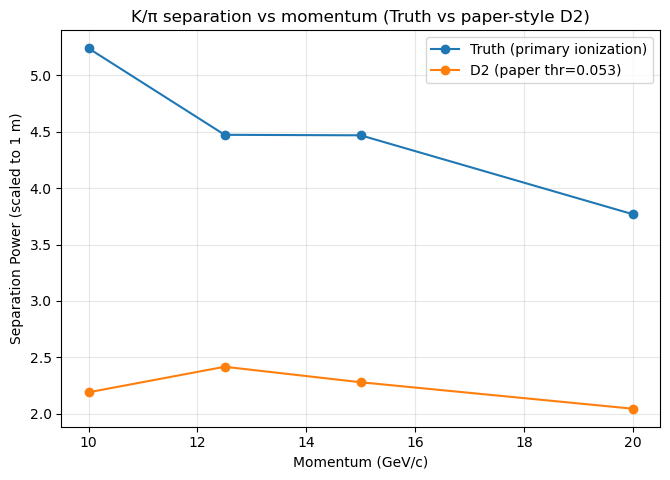

Saved: results/fast_truth_vs_D2_paperD2/sep_truth_vs_D2_paperD2.png
[D2 @10GeV π] min/mean/max: 3 13.4484 50


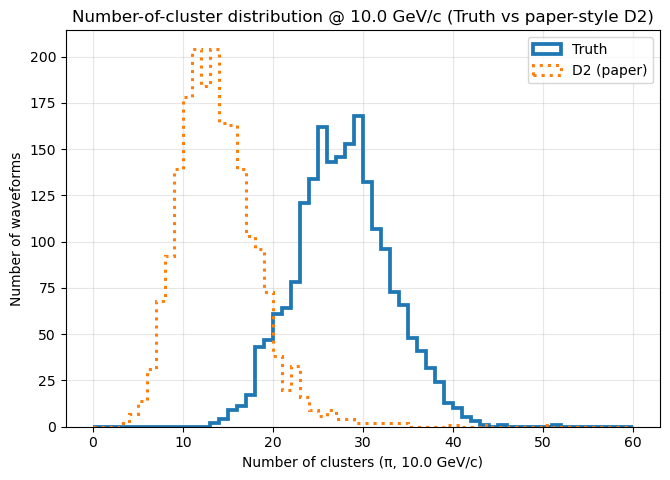

Saved: results/fast_truth_vs_D2_paperD2/hist_truth_vs_D2_10GeVpi_paperD2.png
DONE. Outputs in: results/fast_truth_vs_D2_paperD2


In [7]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ============================================================
# CONFIG (FAST, Truth vs D2 only)
# ============================================================
NPZ_PATH = "PionsKaons/batch_0.npz"
OUTDIR = "results/fast_truth_vs_D2_paperD2"
os.makedirs(OUTDIR, exist_ok=True)

PID_KAON = 130
PID_PION = 211
TAG_BG, TAG_PRI, TAG_SEC = 0, 1, 2

CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
FIG8_MOM = 10.0
MOM_ATOL = 0.05
HIST_BINS = np.arange(0, 61, 1)

FAST_N_MAX = 20000
FAST_SEED  = 0

# -----------------------------
# PAPER-STYLE D2 BASELINE
# -----------------------------
D2_THRESHOLD = 0.053        # paper baseline threshold (~Fig.6)
D2_SMOOTH_WIN = 5           # light low-pass before derivatives (paper says low-pass)
D2_MIN_DISTANCE = 6         # merge peaks closer than this (in samples)
D2_POLARITY = +1            # set to -1 if your pulses are inverted

# ============================================================
# HELPERS
# ============================================================
def smooth_ma_same(x, win):
    if win <= 1:
        return x.astype(np.float32, copy=False)
    k = np.ones(win, dtype=np.float32) / float(win)
    # "same" length smoothing
    return np.convolve(x.astype(np.float32, copy=False), k, mode="same")

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times -> converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    r, c = np.where(valid)
    t = tag_times[r, c]
    y[r, t] = tag_values[r, c].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use, atol=MOM_ATOL, min_per_class=50):
    moms_used, S = [], []
    for p in moms_to_use:
        mk  = (np.isclose(mom, p, atol=atol)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p, atol=atol)) & (pid == PID_PION)
        if mk.sum() < min_per_class or mpi.sum() < min_per_class:
            continue
        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))
    return np.array(moms_used), np.array(S)

# ============================================================
# PAPER-STYLE D2 COUNTER
# ============================================================
def d2_count_one_waveform_paper(wf, thr=D2_THRESHOLD, smooth_win=D2_SMOOTH_WIN,
                               min_distance=D2_MIN_DISTANCE, polarity=D2_POLARITY):
    """
    Paper-style D2 baseline:
      1) low-pass smooth waveform
      2) compute second derivative
      3) detect curvature peaks above a fixed threshold
      4) count peaks (with minimum distance merge)

    We use score = -polarity * d2 so that "peaks" correspond to concavity consistent
    with your pulse polarity.
    """
    y = smooth_ma_same(wf, smooth_win)

    # second derivative (length T-2)
    d2 = np.diff(y, n=2)

    # curvature score: peaks in score correspond to "ionization peaks"
    score = -polarity * d2

    # find peaks in curvature score with a fixed height threshold
    peaks, props = find_peaks(score, height=thr, distance=min_distance)

    return int(peaks.size)

def d2_counts_all_paper(wf_i):
    N = wf_i.shape[0]
    counts = np.zeros(N, dtype=np.int32)
    t0 = time.time()
    for i in range(N):
        counts[i] = d2_count_one_waveform_paper(wf_i[i])
        if (i + 1) % 2000 == 0:
            print(f"[D2] processed {i+1}/{N} in {time.time()-t0:.1f}s", flush=True)
    return counts

# ============================================================
# PLOTTING
# ============================================================
def plot_sep_truth_vs_d2(moms, S_truth_scaled, S_d2_scaled, out_png):
    plt.figure(figsize=(6.8, 4.9))
    plt.plot(moms, S_truth_scaled, marker="o", label="Truth (primary ionization)")
    plt.plot(moms, S_d2_scaled, marker="o", label=f"D2 (paper thr={D2_THRESHOLD:.3f})")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title("K/π separation vs momentum (Truth vs paper-style D2)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

def plot_hist_truth_vs_d2(truth_counts, d2_counts, mom, pid, out_png):
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=MOM_ATOL))
    if mask.sum() == 0:
        print("[INFO] No π@10GeV in subset; skipping histogram.", flush=True)
        return

    xt = truth_counts[mask].astype(np.int32)
    xd = d2_counts[mask].astype(np.int32)

    print(f"[D2 @10GeV π] min/mean/max: {int(xd.min())} {float(xd.mean()):.4f} {int(xd.max())}", flush=True)

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt, bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth")
    plt.hist(np.clip(xd, 0, 60), bins=HIST_BINS, histtype="step",
             linewidth=2.2, linestyle=":", label="D2 (paper)")
    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c (Truth vs paper-style D2)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

# ============================================================
# MAIN
# ============================================================
def main():
    print("START Truth vs paper-style D2", flush=True)
    print("Loading:", NPZ_PATH, flush=True)

    t_load = time.time()
    d = np.load(NPZ_PATH)
    print(f"Loaded NPZ in {time.time()-t_load:.2f}s", flush=True)

    wf_i = d["wf_i"].astype(np.float32)
    mom  = d["mom"].astype(np.float32)
    pid  = d["pid"].astype(np.int32)
    tag_times  = d["tag_times"].astype(np.int32)
    tag_values = d["tag_values"].astype(np.int32)

    N, T = wf_i.shape
    print("wf_i:", wf_i.shape, "T=", T, flush=True)

    # random subset for fast test
    if FAST_N_MAX is not None and N > FAST_N_MAX:
        rng = np.random.default_rng(FAST_SEED)
        idx = rng.choice(N, size=FAST_N_MAX, replace=False)
        wf_i = wf_i[idx]
        mom  = mom[idx]
        pid  = pid[idx]
        tag_times = tag_times[idx]
        tag_values = tag_values[idx]
        print(f"[FAST] random subset N={FAST_N_MAX}", flush=True)

    tag_times = ensure_0_based_tag_times(tag_times, T)

    # Truth counts
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)
    print("Truth mean/std:", float(truth_counts.mean()), float(truth_counts.std(ddof=1)), flush=True)

    # D2 counts (paper-style)
    print(f"Computing D2 (paper-style): thr={D2_THRESHOLD:.3f}, smooth_win={D2_SMOOTH_WIN}, min_dist={D2_MIN_DISTANCE}, polarity={D2_POLARITY}", flush=True)
    d2_counts = d2_counts_all_paper(wf_i)

    # Separation curves
    moms_used, S_truth = separation_vs_momentum(truth_counts, mom, pid, OPT_MOMENTA)
    _,         S_d2    = separation_vs_momentum(d2_counts,   mom, pid, OPT_MOMENTA)

    plot_sep_truth_vs_d2(
        moms_used,
        S_truth * SCALE_TO_1M,
        S_d2 * SCALE_TO_1M,
        out_png=os.path.join(OUTDIR, "sep_truth_vs_D2_paperD2.png")
    )

    plot_hist_truth_vs_d2(
        truth_counts,
        d2_counts,
        mom, pid,
        out_png=os.path.join(OUTDIR, "hist_truth_vs_D2_10GeVpi_paperD2.png")
    )

    print("DONE. Outputs in:", OUTDIR, flush=True)

if __name__ == "__main__":
    main()


Scaling to 1 m: sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 7.5 20.0
  pid unique: [130 211] counts: [60000 40000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_1.npz
  wf_i: (40000, 3000) float32
  mom : (40000,) range: 5.0 17.5
  pid unique: [130 211] counts: [10000 30000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_2.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001669228076935 19.99988555908203
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_3.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20036636292934418 19.99993896484375
  pid unique: [0] counts: [100000]
  tag_values unique: [0 1 2]

Loaded: PionsKaons/batch_4.npz
  wf_i: (100000, 3000) float32
  mom : (100000,) range: 0.20001369714736938 19.999898910522

Inference+scan (2class): 100%|██████████| 1719/1719 [16:10<00:00,  1.77it/s]


[2-class v10] Best thr = 0.95  avg sep(1m) = 1.8836


Inference+scan (3class): 100%|██████████| 1719/1719 [16:14<00:00,  1.76it/s]


[3-class v12] Best thr = 0.45  avg sep(1m) = 3.2933

[D2] Computing paper-style D2 with fixed thr=0.053, smooth_win=5, min_dist=6, polarity=1


D2 (paper): 100%|██████████| 440000/440000 [00:34<00:00, 12693.72it/s]

[D2 @ 10.0 GeV/c π] min/mean/max: 3 13.3732 66


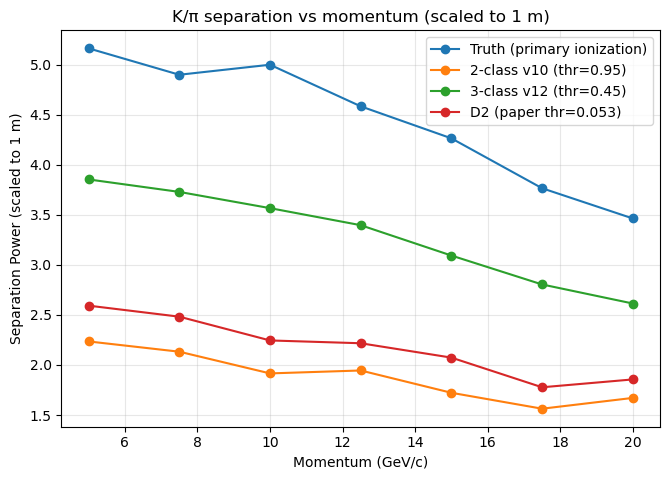

Saved: results/final_eval_v10v12_D2_truth_paperD2/sep_curve_4lines_truth_v10_v12_D2.png


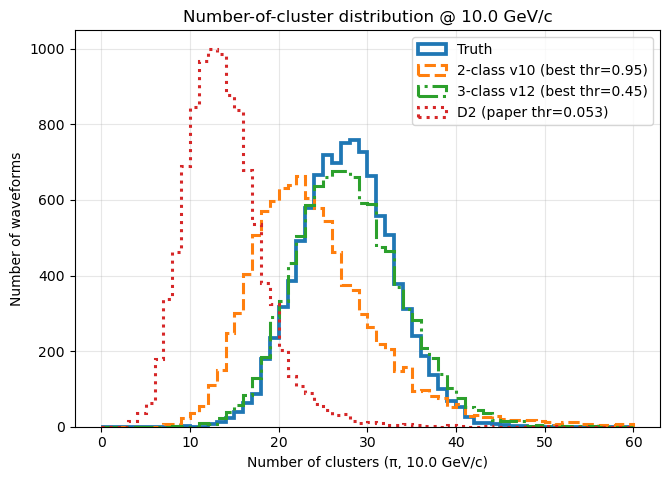

Saved: results/final_eval_v10v12_D2_truth_paperD2/fig8_like_overlay_truth_v10_v12_D2.png

✅ Done. Outputs in: results/final_eval_v10v12_D2_truth_paperD2


In [15]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

# ============================================================
# CONFIG
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]  # batch_0..batch_4

BIN2_BEST_PT   = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"         # 2-class model (v10)
TRI3_BEST_PT   = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"     # 3-class model (v12)

OUTDIR = "results/final_eval_v10v12_D2_truth_paperD2"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

TAG_BG   = 0
TAG_PRI  = 1
TAG_SEC  = 2

CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]

THR_GRID = np.linspace(0.05, 0.95, 19)  # ML probability thresholds

FIG8_MOM = 10.0
MOM_ATOL = 0.05

# Histogram bins (0..60)
HIST_BINS = np.arange(0, 61, 1)

# ============================================================
# PAPER-STYLE D2 BASELINE (fixed; no optimization)
# ============================================================
D2_THRESHOLD = 0.053      # from paper Fig.6 baseline
D2_SMOOTH_WIN = 5         # light low-pass (moving average)
D2_MIN_DISTANCE = 6       # merge close-by curvature peaks
D2_POLARITY = +1          # set to -1 if your waveform pulses are inverted


# ============================================================
# MODEL (same as your training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )

        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)


# ============================================================
# HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}", flush=True)
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n", flush=True)
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)

    print(f"Loaded: {npz_path}", flush=True)
    print("  wf_i:", wf_i.shape, wf_i.dtype, flush=True)
    print("  mom :", mom.shape, "range:", float(mom.min()), float(mom.max()), flush=True)
    u, c = np.unique(pid, return_counts=True)
    print("  pid unique:", u, "counts:", c, flush=True)
    print("  tag_values unique:", np.unique(tag_values), flush=True)
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i)
        mom_all.append(mom)
        pid_all.append(pid)
        tt_all.append(tt)
        tv_all.append(tv)
        print("", flush=True)

    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)

    print("=== Combined ===", flush=True)
    print("wf_i:", wf.shape, flush=True)
    print("mom :", mom.shape, "min/max:", float(mom.min()), float(mom.max()), flush=True)
    u, c = np.unique(pid, return_counts=True)
    print("pid unique:", u, "counts:", c, flush=True)
    print("", flush=True)
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    rows, cols = np.where(valid)
    t = tag_times[rows, cols]
    y[rows, t] = tag_values[rows, cols].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use=None):
    if moms_to_use is None:
        moms_to_use = sorted(np.unique(mom).tolist())

    moms_used, S = [], []
    for p in moms_to_use:
        mk = (np.isclose(mom, p, atol=MOM_ATOL)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p, atol=MOM_ATOL)) & (pid == PID_PION)
        if mk.sum() < 10 or mpi.sum() < 10:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_sep_power_4lines(moms, lines_dict, title, out_png):
    plt.figure(figsize=(6.8, 4.9))
    for label, y in lines_dict.items():
        plt.plot(moms, y, marker="o", label=label)
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

def plot_fig8_overlay_4(truth_counts, counts_2c, counts_3c, counts_d2, mom, pid, best_thr2, best_thr3, out_png):
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=MOM_ATOL))
    xt = truth_counts[mask].astype(np.int32)
    x2 = counts_2c[mask].astype(np.int32)
    x3 = counts_3c[mask].astype(np.int32)
    xd = counts_d2[mask].astype(np.int32)

    if xt.size == 0:
        print("No events found for pid=PION and mom=10.0. Check np.unique(mom).", flush=True)
        return

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt, bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth")
    plt.hist(x2, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="--",
             label=f"2-class v10 (best thr={best_thr2:.2f})")
    plt.hist(x3, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="-.",
             label=f"3-class v12 (best thr={best_thr3:.2f})")
    plt.hist(xd, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":",
             label=f"D2 (paper thr={D2_THRESHOLD:.3f})")

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)


# ============================================================
# SNN inference → counts(thr)
# ============================================================
def infer_counts_scan_thresholds(
    model,
    wf_i,
    scaler,
    device,
    thr_grid,
    which_model,
    use_bg_first=False,
    bg_purity_target=0.90,
    y_dense_truth=None,
):
    N, T = wf_i.shape
    thr_grid = [float(t) for t in thr_grid]
    out = {thr: np.zeros((N,), dtype=np.int32) for thr in thr_grid}
    extra = {}

    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    use_cuda = (device.type == "cuda")
    loader = torch.utils.data.DataLoader(
        x_t,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=(4 if use_cuda else 0),
        pin_memory=use_cuda,
        persistent_workers=(True if use_cuda else False),
    )

    model.eval()
    torch.backends.cudnn.benchmark = use_cuda
    use_amp = use_cuda

    bg_thr = None
    if use_bg_first:
        if which_model != "3class":
            raise ValueError("BG-first only makes sense for the 3-class model.")
        if y_dense_truth is None:
            raise ValueError("BG-first requested but y_dense_truth is None.")

        rng = np.random.default_rng(0)
        idx = rng.choice(N, size=min(N, 50000), replace=False)
        xb = x_t[idx].to(device)

        with torch.inference_mode():
            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

        p_bg = probs[..., 0].detach().cpu().numpy().reshape(-1)
        truth_bg = (y_dense_truth[idx] == TAG_BG).reshape(-1)

        cand = np.linspace(0.05, 0.99, 50)
        best = None
        for thr in cand:
            pred_bg = (p_bg >= thr)
            tp = np.sum(pred_bg & truth_bg)
            fp = np.sum(pred_bg & (~truth_bg))
            if tp + fp == 0:
                continue
            purity = tp / (tp + fp)
            if purity >= bg_purity_target:
                best = thr
                break

        bg_thr = best if best is not None else 0.95
        extra["bg_thr"] = float(bg_thr)
        extra["bg_purity_target"] = float(bg_purity_target)
        print(f"[3-class] BG-first enabled: using bg_thr={bg_thr:.3f} (target purity={bg_purity_target:.3f})", flush=True)

    idx0 = 0
    with torch.inference_mode():
        for xb in tqdm(loader, desc=f"Inference+scan ({which_model})", mininterval=1.0):
            bs = xb.shape[0]
            xb = xb.to(device, non_blocking=True)

            if use_amp:
                with torch.amp.autocast("cuda", enabled=True):
                    probs = torch.softmax(model(xb), dim=-1)
            else:
                probs = torch.softmax(model(xb), dim=-1)

            p_pri = probs[..., 1]

            if use_bg_first:
                p_bg = probs[..., 0]
                keep = (p_bg < bg_thr)
            else:
                keep = None

            for thr in thr_grid:
                if keep is None:
                    counts = (p_pri >= thr).sum(dim=1)
                else:
                    counts = ((p_pri >= thr) & keep).sum(dim=1)

                out[thr][idx0:idx0+bs] = counts.to(torch.int32).cpu().numpy()

            idx0 += bs

    return out, extra

def pick_best_threshold_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt):
    best_thr, best_score = None, -1e9
    curve = {}
    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_to_use=moms_for_opt)
        if S.size == 0:
            continue
        S_scaled = S * SCALE_TO_1M
        score = float(np.mean(S_scaled))
        curve[thr] = (moms_used, S_scaled, score)
        if score > best_score:
            best_score = score
            best_thr = thr
    return best_thr, best_score, curve


# ============================================================
# PAPER-STYLE D2 (FIXED threshold; no scan)
# ============================================================
def smooth_ma_same(x, win):
    if win <= 1:
        return x.astype(np.float32, copy=False)
    k = np.ones(win, dtype=np.float32) / float(win)
    return np.convolve(x.astype(np.float32, copy=False), k, mode="same")

def d2_count_one_waveform_paper(wf, thr=D2_THRESHOLD, smooth_win=D2_SMOOTH_WIN,
                               min_distance=D2_MIN_DISTANCE, polarity=D2_POLARITY):
    y = smooth_ma_same(wf, smooth_win)
    d2 = np.diff(y, n=2)                  # length T-2
    score = -polarity * d2                # curvature score
    peaks, _ = find_peaks(score, height=thr, distance=min_distance)
    return int(peaks.size)

def d2_counts_all_paper(wf_i):
    N = wf_i.shape[0]
    counts = np.zeros(N, dtype=np.int32)
    t0 = time.time()
    for i in tqdm(range(N), desc="D2 (paper)", mininterval=1.0):
        counts[i] = d2_count_one_waveform_paper(wf_i[i])
        # optional hard prints if you want:
        # if (i+1) % 100000 == 0:
        #     print(f"[D2] {i+1}/{N} in {time.time()-t0:.1f}s", flush=True)
    return counts


# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scaling to 1 m: sqrt(1000/18) = {SCALE_TO_1M:.6f}\n", flush=True)

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)

    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)

    print("Truth primary-count mean:", float(truth_counts.mean()), flush=True)
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)), flush=True)
    print("", flush=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device, flush=True)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0), flush=True)
    print("", flush=True)

    # ----------------------------
    # Load models
    # ----------------------------
    model_2class = ConvSNN_Deep(num_classes=2).to(device)
    model_2class.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_3class = ConvSNN_Deep(num_classes=3).to(device)
    model_3class.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ----------------------------
    # v10 2-class scan
    # ----------------------------
    counts2_by_thr, _ = infer_counts_scan_thresholds(
        model_2class, wf_i, scaler, device, THR_GRID,
        which_model="2class",
        use_bg_first=False,
        y_dense_truth=None
    )
    best_thr2, best_score2, _ = pick_best_threshold_by_avg_sep(counts2_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[2-class v10] Best thr = {best_thr2:.2f}  avg sep(1m) = {best_score2:.4f}", flush=True)

    # ----------------------------
    # v12 3-class scan
    # ----------------------------
    USE_BG_FIRST = False
    BG_PURITY_TARGET = 0.8986

    counts3_by_thr, extra3 = infer_counts_scan_thresholds(
        model_3class, wf_i, scaler, device, THR_GRID,
        which_model="3class",
        use_bg_first=USE_BG_FIRST,
        bg_purity_target=BG_PURITY_TARGET,
        y_dense_truth=y_dense
    )
    best_thr3, best_score3, _ = pick_best_threshold_by_avg_sep(counts3_by_thr, mom, pid, OPT_MOMENTA)
    print(f"[3-class v12] Best thr = {best_thr3:.2f}  avg sep(1m) = {best_score3:.4f}", flush=True)
    if USE_BG_FIRST:
        print(f"[3-class] BG-first info:", extra3, flush=True)

    # ----------------------------
    # D2 (paper-style; fixed)
    # ----------------------------
    print(f"\n[D2] Computing paper-style D2 with fixed thr={D2_THRESHOLD:.3f}, smooth_win={D2_SMOOTH_WIN}, min_dist={D2_MIN_DISTANCE}, polarity={D2_POLARITY}", flush=True)
    d2_counts = d2_counts_all_paper(wf_i)

    # Sanity print @10 GeV π
    mask10 = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=MOM_ATOL))
    x10 = d2_counts[mask10]
    if x10.size > 0:
        print(f"[D2 @ {FIG8_MOM:.1f} GeV/c π] min/mean/max:",
              int(x10.min()), float(x10.mean()), int(x10.max()), flush=True)

    # ----------------------------
    # Separation 4-line plot
    # ----------------------------
    moms, S_truth = separation_vs_momentum(truth_counts, mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_2     = separation_vs_momentum(counts2_by_thr[best_thr2], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_3     = separation_vs_momentum(counts3_by_thr[best_thr3], mom, pid, moms_to_use=OPT_MOMENTA)
    _,    S_d2    = separation_vs_momentum(d2_counts, mom, pid, moms_to_use=OPT_MOMENTA)

    plot_sep_power_4lines(
        moms=moms,
        lines_dict={
            "Truth (primary ionization)": S_truth * SCALE_TO_1M,
            f"2-class v10 (thr={best_thr2:.2f})": S_2 * SCALE_TO_1M,
            f"3-class v12 (thr={best_thr3:.2f})": S_3 * SCALE_TO_1M,
            f"D2 (paper thr={D2_THRESHOLD:.3f})": S_d2 * SCALE_TO_1M,
        },
        title="K/π separation vs momentum (scaled to 1 m)",
        out_png=os.path.join(OUTDIR, "sep_curve_4lines_truth_v10_v12_D2.png"),
    )

    # ----------------------------
    # Fig.8-like histogram overlay (Truth + v10 + v12 + D2)
    # ----------------------------
    plot_fig8_overlay_4(
        truth_counts=truth_counts,
        counts_2c=counts2_by_thr[best_thr2],
        counts_3c=counts3_by_thr[best_thr3],
        counts_d2=d2_counts,
        mom=mom,
        pid=pid,
        best_thr2=best_thr2,
        best_thr3=best_thr3,
        out_png=os.path.join(OUTDIR, "fig8_like_overlay_truth_v10_v12_D2.png"),
    )

    # ----------------------------
    # Save thresholds/metadata
    # ----------------------------
    np.savez(
        os.path.join(OUTDIR, "best_thresholds_v10v12_D2_truth.npz"),
        best_thr_2class=float(best_thr2),
        best_thr_3class=float(best_thr3),
        best_avg_sep_2class=float(best_score2),
        best_avg_sep_3class=float(best_score3),
        used_bg_first=bool(USE_BG_FIRST),
        bg_thr=float(extra3.get("bg_thr", np.nan)) if isinstance(extra3, dict) else np.nan,
        d2_threshold=float(D2_THRESHOLD),
        d2_smooth_win=int(D2_SMOOTH_WIN),
        d2_min_distance=int(D2_MIN_DISTANCE),
        d2_polarity=int(D2_POLARITY),
    )

    print("\n✅ Done. Outputs in:", OUTDIR, flush=True)

if __name__ == "__main__":
    main()


=== D2-only test ===
Loading: PionsKaons/batch_0.npz
Loaded in 149.16s | wf_i=(100000, 3000)
[FAST] random subset N=20000
Truth mean/std: 25.87495 5.357270528438502

[D2 FIXED] thr=0.053 smooth=5 dist=6 polarity=1
[D2 thr=0.053] 2000/20000 in 0.1s
[D2 thr=0.053] 4000/20000 in 0.3s
[D2 thr=0.053] 6000/20000 in 0.4s
[D2 thr=0.053] 8000/20000 in 0.6s
[D2 thr=0.053] 10000/20000 in 0.7s
[D2 thr=0.053] 12000/20000 in 0.9s
[D2 thr=0.053] 14000/20000 in 1.0s
[D2 thr=0.053] 16000/20000 in 1.2s
[D2 thr=0.053] 18000/20000 in 1.3s
[D2 thr=0.053] 20000/20000 in 1.4s


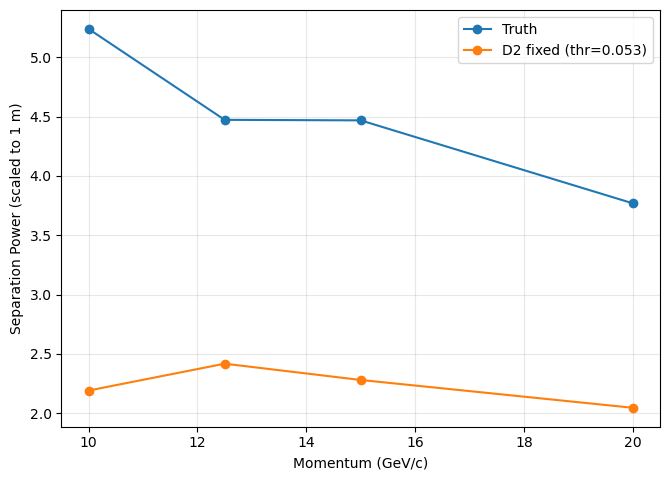

Saved: results/D2_only_test/sep_truth_vs_D2_fixed.png
[Histogram @10GeV (Truth vs D2 fixed thr=0.053)] D2@10GeV π min/mean/max: 3 13.448412698412698 50


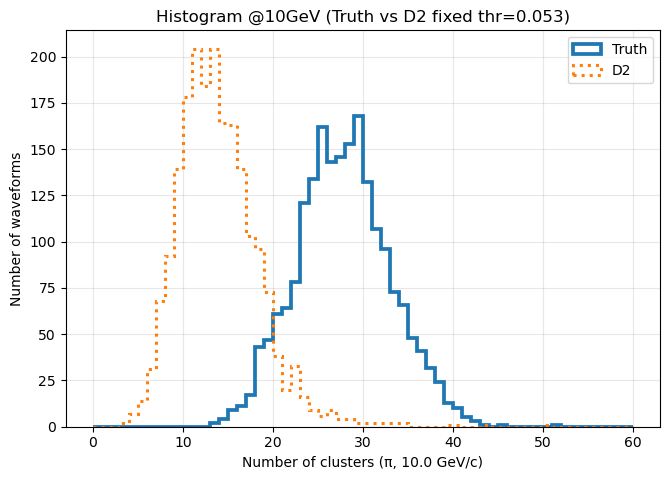

Saved: results/D2_only_test/hist_truth_vs_D2_fixed_10GeVpi.png

[D2 ORACLE] scanning thresholds to maximize avg separation (upper bound)
[D2 thr=0.010] 2000/20000 in 0.2s
[D2 thr=0.010] 4000/20000 in 0.4s
[D2 thr=0.010] 6000/20000 in 0.6s
[D2 thr=0.010] 8000/20000 in 0.8s
[D2 thr=0.010] 10000/20000 in 1.0s
[D2 thr=0.010] 12000/20000 in 1.2s
[D2 thr=0.010] 14000/20000 in 1.4s
[D2 thr=0.010] 16000/20000 in 1.6s
[D2 thr=0.010] 18000/20000 in 1.8s
[D2 thr=0.010] 20000/20000 in 2.0s
[D2 thr=0.015] 2000/20000 in 0.2s
[D2 thr=0.015] 4000/20000 in 0.3s
[D2 thr=0.015] 6000/20000 in 0.5s
[D2 thr=0.015] 8000/20000 in 0.6s
[D2 thr=0.015] 10000/20000 in 0.8s
[D2 thr=0.015] 12000/20000 in 1.0s
[D2 thr=0.015] 14000/20000 in 1.1s
[D2 thr=0.015] 16000/20000 in 1.3s
[D2 thr=0.015] 18000/20000 in 1.5s
[D2 thr=0.015] 20000/20000 in 1.6s
[D2 thr=0.020] 2000/20000 in 0.1s
[D2 thr=0.020] 4000/20000 in 0.3s
[D2 thr=0.020] 6000/20000 in 0.4s
[D2 thr=0.020] 8000/20000 in 0.6s
[D2 thr=0.020] 10000/20000 in 0.7s


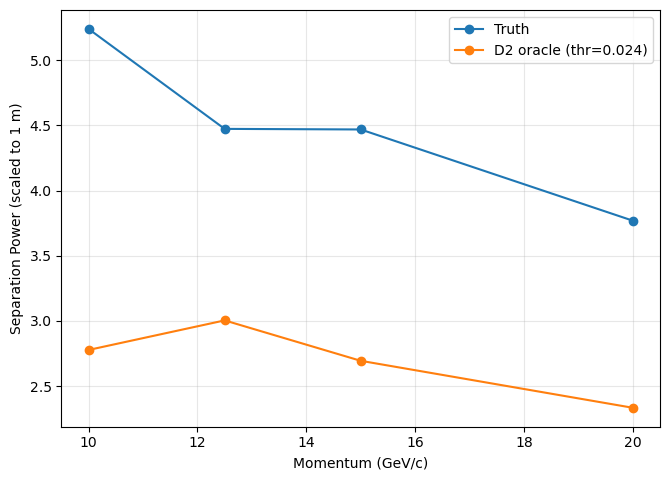

Saved: results/D2_only_test/sep_truth_vs_D2_oracle.png
[Histogram @10GeV (Truth vs D2 oracle thr=0.024)] D2@10GeV π min/mean/max: 7 23.03769841269841 66


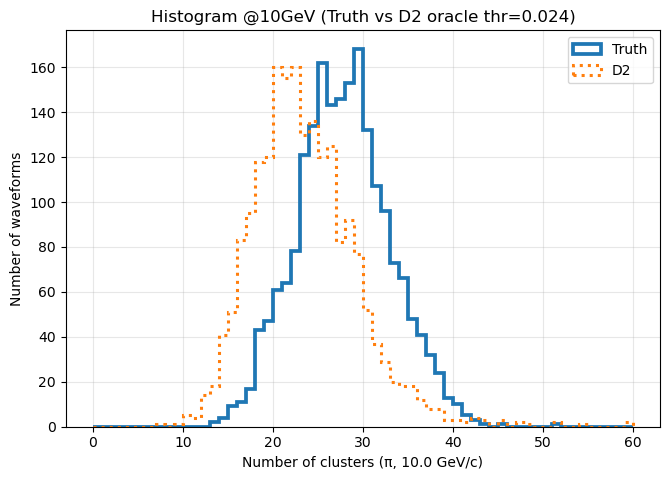

Saved: results/D2_only_test/hist_truth_vs_D2_oracle_10GeVpi.png

DONE. Outputs in: results/D2_only_test


In [3]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =======================
# CONFIG (D2-only test)
# =======================
NPZ_PATH = "PionsKaons/batch_0.npz"
OUTDIR = "results/D2_only_test"
os.makedirs(OUTDIR, exist_ok=True)

# physics labels
PID_KAON = 130
PID_PION = 211
TAG_BG, TAG_PRI, TAG_SEC = 0, 1, 2

# separation scaling (paper uses 18 mm cell -> scale to 1 m)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

# momenta to evaluate (paper)
OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
MOM_ATOL = 0.05

# histogram (Fig.8-like)
FIG8_MOM = 10.0
HIST_BINS = np.arange(0, 61, 1)

# FAST subset (set to None for full)
FAST_N_MAX = 20000
FAST_SEED = 0

# -----------------------
# D2 settings
# -----------------------
# (A) paper fixed threshold baseline
D2_FIXED_THR = 0.053
D2_SMOOTH_WIN = 5
D2_MIN_DISTANCE = 6
D2_POLARITY = +1   # set -1 if pulses are inverted

# (B) optional oracle scan (upper-bound)
RUN_D2_ORACLE = True
D2_THR_GRID = np.concatenate([
    np.linspace(0.01, 0.12, 24),
    np.linspace(0.14, 0.40, 14),
    np.linspace(0.45, 0.95, 11),
])

# =======================
# Truth helpers (for separation + histogram comparison)
# =======================
def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times -> converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    r, c = np.where(valid)
    t = tag_times[r, c]
    y[r, t] = tag_values[r, c].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use, atol=MOM_ATOL, min_per_class=50):
    moms_used, S = [], []
    for p in moms_to_use:
        mk  = (np.isclose(mom, p, atol=atol)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p, atol=atol)) & (pid == PID_PION)
        if mk.sum() < min_per_class or mpi.sum() < min_per_class:
            continue
        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        moms_used.append(float(p))
        S.append(float(sep_paper(a.mean(), a.std(ddof=1), b.mean(), b.std(ddof=1))))
    return np.array(moms_used), np.array(S)

# =======================
# D2 implementation
# =======================
def smooth_ma_same(x, win):
    if win <= 1:
        return x.astype(np.float32, copy=False)
    k = np.ones(win, dtype=np.float32) / float(win)
    return np.convolve(x.astype(np.float32, copy=False), k, mode="same")

def d2_count_one(wf, thr, smooth_win=D2_SMOOTH_WIN, min_distance=D2_MIN_DISTANCE, polarity=D2_POLARITY):
    y = smooth_ma_same(wf, smooth_win)
    d2 = np.diff(y, n=2)                 # curvature
    score = -polarity * d2               # peaks in score correspond to clusters
    peaks, _ = find_peaks(score, height=thr, distance=min_distance)
    return int(peaks.size)

def d2_counts_for_threshold(wf_i, thr):
    N = wf_i.shape[0]
    out = np.zeros(N, dtype=np.int32)
    t0 = time.time()
    for i in range(N):
        out[i] = d2_count_one(wf_i[i], thr)
        if (i + 1) % 2000 == 0:
            print(f"[D2 thr={thr:.3f}] {i+1}/{N} in {time.time()-t0:.1f}s", flush=True)
    return out

def pick_best_thr_by_avg_sep(d2_by_thr, mom, pid, moms_for_opt):
    best_thr, best_score = None, -1e9
    for thr, counts in d2_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_for_opt)
        if S.size == 0:
            continue
        score = float(np.mean(S * SCALE_TO_1M))
        if score > best_score:
            best_score = score
            best_thr = thr
    return best_thr, best_score

# =======================
# Plot helpers
# =======================
def plot_sep(moms, S_truth, S_d2, label_d2, out_png):
    plt.figure(figsize=(6.8, 4.9))
    plt.plot(moms, S_truth * SCALE_TO_1M, marker="o", label="Truth")
    plt.plot(moms, S_d2 * SCALE_TO_1M, marker="o", label=label_d2)
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

def plot_hist(truth_counts, d2_counts, mom, pid, title, out_png):
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=MOM_ATOL))
    if mask.sum() == 0:
        print("[INFO] No π@10GeV in subset; skipping histogram.", flush=True)
        return
    xt = truth_counts[mask].astype(np.int32)
    xd = d2_counts[mask].astype(np.int32)
    print(f"[{title}] D2@10GeV π min/mean/max:", int(xd.min()), float(xd.mean()), int(xd.max()), flush=True)

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt, bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth")
    plt.hist(np.clip(xd, 0, 60), bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":",
             label="D2")
    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

# =======================
# MAIN
# =======================
def main():
    print("=== D2-only test ===", flush=True)
    print("Loading:", NPZ_PATH, flush=True)

    t0 = time.time()
    d = np.load(NPZ_PATH)
    wf_i = d["wf_i"].astype(np.float32)
    mom  = d["mom"].astype(np.float32)
    pid  = d["pid"].astype(np.int32)
    tag_times  = d["tag_times"].astype(np.int32)
    tag_values = d["tag_values"].astype(np.int32)
    print(f"Loaded in {time.time()-t0:.2f}s | wf_i={wf_i.shape}", flush=True)

    # fast random subset
    N = wf_i.shape[0]
    if FAST_N_MAX is not None and N > FAST_N_MAX:
        rng = np.random.default_rng(FAST_SEED)
        idx = rng.choice(N, size=FAST_N_MAX, replace=False)
        wf_i = wf_i[idx]
        mom  = mom[idx]
        pid  = pid[idx]
        tag_times = tag_times[idx]
        tag_values = tag_values[idx]
        print(f"[FAST] random subset N={FAST_N_MAX}", flush=True)

    # truth counts
    T = wf_i.shape[1]
    tag_times = ensure_0_based_tag_times(tag_times, T)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)
    print("Truth mean/std:", float(truth_counts.mean()), float(truth_counts.std(ddof=1)), flush=True)

    # ---- D2 fixed
    print(f"\n[D2 FIXED] thr={D2_FIXED_THR:.3f} smooth={D2_SMOOTH_WIN} dist={D2_MIN_DISTANCE} polarity={D2_POLARITY}", flush=True)
    d2_fixed = d2_counts_for_threshold(wf_i, D2_FIXED_THR)

    moms_used, S_truth = separation_vs_momentum(truth_counts, mom, pid, OPT_MOMENTA)
    _,        S_d2fix  = separation_vs_momentum(d2_fixed,     mom, pid, OPT_MOMENTA)

    plot_sep(
        moms_used, S_truth, S_d2fix,
        label_d2=f"D2 fixed (thr={D2_FIXED_THR:.3f})",
        out_png=os.path.join(OUTDIR, "sep_truth_vs_D2_fixed.png"),
    )
    plot_hist(
        truth_counts, d2_fixed, mom, pid,
        title=f"Histogram @10GeV (Truth vs D2 fixed thr={D2_FIXED_THR:.3f})",
        out_png=os.path.join(OUTDIR, "hist_truth_vs_D2_fixed_10GeVpi.png"),
    )

    # ---- optional oracle scan
    if RUN_D2_ORACLE:
        print("\n[D2 ORACLE] scanning thresholds to maximize avg separation (upper bound)", flush=True)
        d2_by_thr = {}
        for thr in D2_THR_GRID:
            thr = float(thr)
            d2_by_thr[thr] = d2_counts_for_threshold(wf_i, thr)

        best_thr, best_score = pick_best_thr_by_avg_sep(d2_by_thr, mom, pid, OPT_MOMENTA)
        print(f"[D2 ORACLE] best_thr={best_thr:.4f} avg_sep(1m)={best_score:.4f}", flush=True)

        d2_best = d2_by_thr[best_thr]
        _, S_d2best = separation_vs_momentum(d2_best, mom, pid, OPT_MOMENTA)

        plot_sep(
            moms_used, S_truth, S_d2best,
            label_d2=f"D2 oracle (thr={best_thr:.3f})",
            out_png=os.path.join(OUTDIR, "sep_truth_vs_D2_oracle.png"),
        )
        plot_hist(
            truth_counts, d2_best, mom, pid,
            title=f"Histogram @10GeV (Truth vs D2 oracle thr={best_thr:.3f})",
            out_png=os.path.join(OUTDIR, "hist_truth_vs_D2_oracle_10GeVpi.png"),
        )

    print("\nDONE. Outputs in:", OUTDIR, flush=True)

if __name__ == "__main__":
    main()


=== ORACLE D2 (best threshold) ===
Loading: PionsKaons/batch_0.npz
Loaded in 6.63s | wf_i=(100000, 3000)
[FAST] random subset N=20000
Truth mean/std: 25.87495 5.357270528438502

[D2] scan thresholds (oracle) | smooth_win=5, min_dist=6, polarity=1
[D2 scan] 2000/20000 waveforms in 0.3s
[D2 scan] 4000/20000 waveforms in 0.7s
[D2 scan] 6000/20000 waveforms in 1.0s
[D2 scan] 8000/20000 waveforms in 1.3s
[D2 scan] 10000/20000 waveforms in 1.6s
[D2 scan] 12000/20000 waveforms in 2.0s
[D2 scan] 14000/20000 waveforms in 2.3s
[D2 scan] 16000/20000 waveforms in 2.6s
[D2 scan] 18000/20000 waveforms in 2.9s
[D2 scan] 20000/20000 waveforms in 3.3s
[D2 ORACLE] best_thr=0.0243 avg_sep(1m)=2.7026


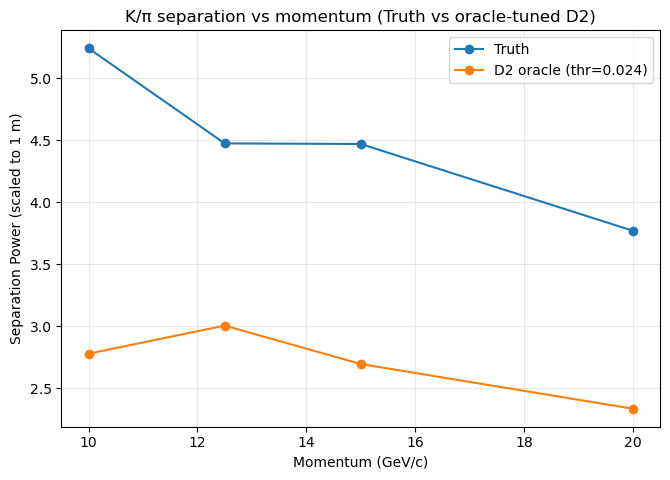

Saved: results/D2_oracle_only/sep_truth_vs_D2_oracle.png
[D2 oracle @10GeV π] thr=0.0243 min/mean/max: 7 23.03769841269841 66


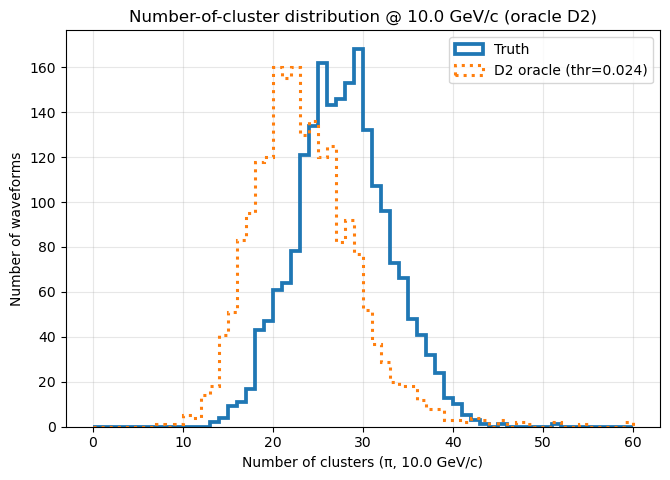

Saved: results/D2_oracle_only/hist_truth_vs_D2_oracle_10GeVpi.png

DONE. Outputs in: results/D2_oracle_only


In [4]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =======================
# CONFIG (D2 oracle only)
# =======================
NPZ_PATH = "PionsKaons/batch_0.npz"
OUTDIR = "results/D2_oracle_only"
os.makedirs(OUTDIR, exist_ok=True)

PID_KAON = 130
PID_PION = 211
TAG_BG, TAG_PRI, TAG_SEC = 0, 1, 2

CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
MOM_ATOL = 0.05
MIN_PER_CLASS = 50

FIG8_MOM = 10.0
HIST_BINS = np.arange(0, 61, 1)

FAST_N_MAX = 20000    # set None for full
FAST_SEED  = 0

# ---- D2 params (same style as paper, but threshold is ORACLE-tuned)
D2_SMOOTH_WIN = 5
D2_MIN_DISTANCE = 6
D2_POLARITY = +1   # flip to -1 if needed

# Threshold scan grid (oracle)
D2_THR_GRID = np.concatenate([
    np.linspace(0.01, 0.12, 24),
    np.linspace(0.14, 0.40, 14),
    np.linspace(0.45, 0.95, 11),
]).astype(np.float32)

# =======================
# Truth helpers
# =======================
def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times -> converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    r, c = np.where(valid)
    t = tag_times[r, c]
    y[r, t] = tag_values[r, c].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_at_momentum(counts, mom, pid, p, atol=MOM_ATOL):
    mk  = (np.isclose(mom, p, atol=atol)) & (pid == PID_KAON)
    mpi = (np.isclose(mom, p, atol=atol)) & (pid == PID_PION)
    if mk.sum() < MIN_PER_CLASS or mpi.sum() < MIN_PER_CLASS:
        return None
    a = counts[mk].astype(np.float64)
    b = counts[mpi].astype(np.float64)
    return float(sep_paper(a.mean(), a.std(ddof=1), b.mean(), b.std(ddof=1)))

def separation_vs_momentum(counts, mom, pid, moms_to_use):
    moms_used, S = [], []
    for p in moms_to_use:
        s = separation_at_momentum(counts, mom, pid, p)
        if s is None:
            continue
        moms_used.append(float(p))
        S.append(float(s))
    return np.array(moms_used), np.array(S)

# =======================
# D2 oracle (one pass for all thresholds)
# =======================
def smooth_ma_same(x, win):
    if win <= 1:
        return x.astype(np.float32, copy=False)
    k = np.ones(win, dtype=np.float32) / float(win)
    return np.convolve(x.astype(np.float32, copy=False), k, mode="same")

def d2_counts_scan_all_thresholds(wf_i, thr_grid, smooth_win, min_distance, polarity):
    """
    Efficient oracle scan:
      For each waveform:
        - compute curvature score = -polarity * d2
        - find peaks with distance constraint (NO height threshold)
        - sort peak heights
        - for each thr in thr_grid: count peaks with height >= thr using binary search
    Returns:
      dict thr -> counts[N]
    """
    thr_grid = np.asarray(thr_grid, dtype=np.float32)
    thr_sorted = np.sort(thr_grid)
    N = wf_i.shape[0]
    out_sorted = np.zeros((thr_sorted.size, N), dtype=np.int32)

    t0 = time.time()
    for i in range(N):
        y = smooth_ma_same(wf_i[i], smooth_win)
        d2 = np.diff(y, n=2)
        score = -polarity * d2

        # get all peaks (distance enforced), no threshold
        peaks, _ = find_peaks(score, distance=min_distance)
        if peaks.size == 0:
            # already zeros
            pass
        else:
            heights = np.sort(score[peaks])  # ascending
            # for each threshold, counts = #heights >= thr
            # use searchsorted to find first >= thr
            # idx = searchsorted(heights, thr, 'left')
            idxs = np.searchsorted(heights, thr_sorted, side="left")
            out_sorted[:, i] = (heights.size - idxs).astype(np.int32)

        if (i + 1) % 2000 == 0:
            dt = time.time() - t0
            print(f"[D2 scan] {i+1}/{N} waveforms in {dt:.1f}s", flush=True)

    # map back to original thr order
    out = {}
    for thr in thr_grid:
        j = np.searchsorted(thr_sorted, thr, side="left")
        # (thr_sorted unique enough; if duplicates exist, take the first)
        out[float(thr)] = out_sorted[j].copy()
    return out

def pick_best_thr_by_avg_sep(counts_by_thr, mom, pid, moms_for_opt):
    best_thr, best_score = None, -1e9
    for thr, counts in counts_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, moms_for_opt)
        if S.size == 0:
            continue
        score = float(np.mean(S * SCALE_TO_1M))
        if score > best_score:
            best_score = score
            best_thr = thr
    return best_thr, best_score

# =======================
# Plot helpers
# =======================
def plot_sep(moms, S_truth_scaled, S_d2_scaled, best_thr, out_png):
    plt.figure(figsize=(6.8, 4.9))
    plt.plot(moms, S_truth_scaled, marker="o", label="Truth")
    plt.plot(moms, S_d2_scaled, marker="o", label=f"D2 oracle (thr={best_thr:.3f})")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title("K/π separation vs momentum (Truth vs oracle-tuned D2)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

def plot_hist(truth_counts, d2_counts, mom, pid, best_thr, out_png):
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=MOM_ATOL))
    if mask.sum() == 0:
        print("[INFO] No π@10GeV in subset; skipping histogram.", flush=True)
        return
    xt = truth_counts[mask].astype(np.int32)
    xd = d2_counts[mask].astype(np.int32)
    print(f"[D2 oracle @10GeV π] thr={best_thr:.4f} min/mean/max:",
          int(xd.min()), float(xd.mean()), int(xd.max()), flush=True)

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt, bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth")
    plt.hist(np.clip(xd, 0, 60), bins=HIST_BINS, histtype="step",
             linewidth=2.2, linestyle=":", label=f"D2 oracle (thr={best_thr:.3f})")
    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c (oracle D2)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

# =======================
# MAIN
# =======================
def main():
    print("=== ORACLE D2 (best threshold) ===", flush=True)
    print("Loading:", NPZ_PATH, flush=True)
    t0 = time.time()
    d = np.load(NPZ_PATH)
    wf_i = d["wf_i"].astype(np.float32)
    mom  = d["mom"].astype(np.float32)
    pid  = d["pid"].astype(np.int32)
    tag_times  = d["tag_times"].astype(np.int32)
    tag_values = d["tag_values"].astype(np.int32)
    print(f"Loaded in {time.time()-t0:.2f}s | wf_i={wf_i.shape}", flush=True)

    # fast random subset
    N = wf_i.shape[0]
    if FAST_N_MAX is not None and N > FAST_N_MAX:
        rng = np.random.default_rng(FAST_SEED)
        idx = rng.choice(N, size=FAST_N_MAX, replace=False)
        wf_i = wf_i[idx]
        mom  = mom[idx]
        pid  = pid[idx]
        tag_times = tag_times[idx]
        tag_values = tag_values[idx]
        print(f"[FAST] random subset N={FAST_N_MAX}", flush=True)

    # truth counts
    T = wf_i.shape[1]
    tag_times = ensure_0_based_tag_times(tag_times, T)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)
    print("Truth mean/std:", float(truth_counts.mean()), float(truth_counts.std(ddof=1)), flush=True)

    # D2 scan (one pass)
    print(f"\n[D2] scan thresholds (oracle) | smooth_win={D2_SMOOTH_WIN}, min_dist={D2_MIN_DISTANCE}, polarity={D2_POLARITY}", flush=True)
    d2_by_thr = d2_counts_scan_all_thresholds(
        wf_i,
        D2_THR_GRID,
        smooth_win=D2_SMOOTH_WIN,
        min_distance=D2_MIN_DISTANCE,
        polarity=D2_POLARITY,
    )

    best_thr, best_score = pick_best_thr_by_avg_sep(d2_by_thr, mom, pid, OPT_MOMENTA)
    if best_thr is None:
        raise RuntimeError("No valid threshold produced a separation curve. Increase FAST_N_MAX or relax MIN_PER_CLASS.")
    print(f"[D2 ORACLE] best_thr={best_thr:.4f} avg_sep(1m)={best_score:.4f}", flush=True)

    d2_best = d2_by_thr[best_thr]

    moms_used, S_truth = separation_vs_momentum(truth_counts, mom, pid, OPT_MOMENTA)
    _,        S_d2best = separation_vs_momentum(d2_best,     mom, pid, OPT_MOMENTA)

    plot_sep(
        moms_used,
        S_truth * SCALE_TO_1M,
        S_d2best * SCALE_TO_1M,
        best_thr,
        out_png=os.path.join(OUTDIR, "sep_truth_vs_D2_oracle.png"),
    )

    plot_hist(
        truth_counts,
        d2_best,
        mom, pid,
        best_thr,
        out_png=os.path.join(OUTDIR, "hist_truth_vs_D2_oracle_10GeVpi.png"),
    )

    np.savez(
        os.path.join(OUTDIR, "d2_oracle_best.npz"),
        best_thr=float(best_thr),
        best_avg_sep_1m=float(best_score),
        d2_smooth_win=int(D2_SMOOTH_WIN),
        d2_min_distance=int(D2_MIN_DISTANCE),
        d2_polarity=int(D2_POLARITY),
        thr_grid=D2_THR_GRID.astype(np.float32),
    )

    print("\nDONE. Outputs in:", OUTDIR, flush=True)

if __name__ == "__main__":
    main()


In [5]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# =======================
# CONFIG
# =======================
NPZ_PATH = "PionsKaons/batch_0.npz"
OUTDIR = "results/D2_best_primary_and_sep"
os.makedirs(OUTDIR, exist_ok=True)

PID_KAON = 130
PID_PION = 211
TAG_BG, TAG_PRI, TAG_SEC = 0, 1, 2

CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
MOM_ATOL = 0.05
MIN_PER_CLASS = 50

FIG8_MOM = 10.0
HIST_BINS = np.arange(0, 61, 1)

FAST_N_MAX = 20000    # None for full
FAST_SEED  = 0

# D2 params
D2_SMOOTH_WIN = 5
D2_MIN_DISTANCE = 6
D2_POLARITY = +1   # flip to -1 if needed

# Threshold grid to scan
D2_THR_GRID = np.concatenate([
    np.linspace(0.01, 0.12, 24),
    np.linspace(0.14, 0.40, 14),
    np.linspace(0.45, 0.95, 11),
]).astype(np.float32)

# For PRIMARY-F1 tuning, evaluate on a subset of waveforms (speed)
F1_EVAL_N = 5000   # increase for stability if needed

# =======================
# Helpers
# =======================
def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times -> converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    r, c = np.where(valid)
    t = tag_times[r, c]
    y[r, t] = tag_values[r, c].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use):
    moms_used, S = [], []
    for p in moms_to_use:
        mk  = (np.isclose(mom, p, atol=MOM_ATOL)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p, atol=MOM_ATOL)) & (pid == PID_PION)
        if mk.sum() < MIN_PER_CLASS or mpi.sum() < MIN_PER_CLASS:
            continue
        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        moms_used.append(float(p))
        S.append(float(sep_paper(a.mean(), a.std(ddof=1), b.mean(), b.std(ddof=1))))
    return np.array(moms_used), np.array(S)

# =======================
# D2 core
# =======================
def smooth_ma_same(x, win):
    if win <= 1:
        return x.astype(np.float32, copy=False)
    k = np.ones(win, dtype=np.float32) / float(win)
    return np.convolve(x.astype(np.float32, copy=False), k, mode="same")

def d2_peaks_and_heights(wf, smooth_win, min_distance, polarity):
    y = smooth_ma_same(wf, smooth_win)
    d2 = np.diff(y, n=2)
    score = -polarity * d2
    peaks, _ = find_peaks(score, distance=min_distance)
    if peaks.size == 0:
        return peaks, np.empty((0,), dtype=np.float32)
    return peaks, score[peaks].astype(np.float32)

def d2_counts_scan_fast(wf_i, thr_grid, smooth_win, min_distance, polarity):
    thr_grid = np.asarray(thr_grid, dtype=np.float32)
    thr_sorted = np.sort(thr_grid)
    n_thr = thr_sorted.size
    N = wf_i.shape[0]
    out_sorted = np.zeros((n_thr, N), dtype=np.int32)

    t0 = time.time()
    for i in range(N):
        peaks, heights = d2_peaks_and_heights(wf_i[i], smooth_win, min_distance, polarity)
        if heights.size > 0:
            hs = np.sort(heights)  # ascending
            idxs = np.searchsorted(hs, thr_sorted, side="left")
            out_sorted[:, i] = (hs.size - idxs).astype(np.int32)
        if (i + 1) % 2000 == 0:
            print(f"[D2 scan] {i+1}/{N} in {time.time()-t0:.1f}s", flush=True)

    out = {}
    for thr in thr_grid:
        j = np.searchsorted(thr_sorted, thr, side="left")
        out[float(thr)] = out_sorted[j].copy()
    return out

# =======================
# PRIMARY-F1 tuning for D2
# =======================
def d2_f1_for_threshold(wf_i, y_dense, thr, smooth_win, min_distance, polarity, idx):
    """
    Evaluate per-timestep primary detection:
      predict primary at D2 peak indices with height >= thr
      true primary = (y_dense == TAG_PRI)
    """
    tp = fp = fn = 0
    for i in idx:
        peaks, heights = d2_peaks_and_heights(wf_i[i], smooth_win, min_distance, polarity)
        if heights.size > 0:
            keep = peaks[heights >= thr]
        else:
            keep = np.empty((0,), dtype=np.int64)

        pred = np.zeros(y_dense.shape[1], dtype=bool)
        pred[keep] = True
        truth = (y_dense[i] == TAG_PRI)

        tp += int(np.sum(pred & truth))
        fp += int(np.sum(pred & (~truth)))
        fn += int(np.sum((~pred) & truth))

    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    return float(f1), float(prec), float(rec)

def pick_best_thr_by_f1(wf_i, y_dense, thr_grid, smooth_win, min_distance, polarity, eval_n):
    rng = np.random.default_rng(0)
    N = wf_i.shape[0]
    idx = rng.choice(N, size=min(N, eval_n), replace=False)

    best_thr, best_f1 = None, -1.0
    best_trip = None
    for thr in thr_grid:
        f1, p, r = d2_f1_for_threshold(wf_i, y_dense, float(thr), smooth_win, min_distance, polarity, idx)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)
            best_trip = (p, r)
        print(f"[F1-scan] thr={thr:.3f} F1={f1:.4f} P={p:.4f} R={r:.4f}", flush=True)

    return best_thr, best_f1, best_trip

# =======================
# MAIN
# =======================
def main():
    print("=== D2: best PRIMARY (F1) and best separation ===", flush=True)
    d = np.load(NPZ_PATH)
    wf_i = d["wf_i"].astype(np.float32)
    mom  = d["mom"].astype(np.float32)
    pid  = d["pid"].astype(np.int32)
    tag_times  = d["tag_times"].astype(np.int32)
    tag_values = d["tag_values"].astype(np.int32)

    # fast subset
    if FAST_N_MAX is not None and wf_i.shape[0] > FAST_N_MAX:
        rng = np.random.default_rng(FAST_SEED)
        idx = rng.choice(wf_i.shape[0], size=FAST_N_MAX, replace=False)
        wf_i = wf_i[idx]; mom = mom[idx]; pid = pid[idx]; tag_times = tag_times[idx]; tag_values = tag_values[idx]
        print(f"[FAST] N={FAST_N_MAX}", flush=True)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)

    print("Truth mean/std:", float(truth_counts.mean()), float(truth_counts.std(ddof=1)), flush=True)
    print(f"D2 params: smooth={D2_SMOOTH_WIN} dist={D2_MIN_DISTANCE} polarity={D2_POLARITY}", flush=True)

    # --- (A) best D2 for separation (oracle)
    print("\n[A] D2 best for separation (avg sep over momenta)", flush=True)
    d2_by_thr = d2_counts_scan_fast(wf_i, D2_THR_GRID, D2_SMOOTH_WIN, D2_MIN_DISTANCE, D2_POLARITY)

    best_thr_sep, best_score_sep = None, -1e9
    for thr, counts in d2_by_thr.items():
        moms_used, S = separation_vs_momentum(counts, mom, pid, OPT_MOMENTA)
        if S.size == 0:
            continue
        score = float(np.mean(S * SCALE_TO_1M))
        if score > best_score_sep:
            best_score_sep = score
            best_thr_sep = thr
    print(f"[D2-sep] best_thr={best_thr_sep:.4f} avg_sep(1m)={best_score_sep:.4f}", flush=True)

    # --- (B) best D2 for PRIMARY (F1)
    print("\n[B] D2 best for PRIMARY detection (F1 over peak-times)", flush=True)
    best_thr_f1, best_f1, (best_prec, best_rec) = pick_best_thr_by_f1(
        wf_i, y_dense, D2_THR_GRID, D2_SMOOTH_WIN, D2_MIN_DISTANCE, D2_POLARITY, eval_n=F1_EVAL_N
    )
    print(f"[D2-primary] best_thr={best_thr_f1:.4f} F1={best_f1:.4f} P={best_prec:.4f} R={best_rec:.4f}", flush=True)

    np.savez(
        os.path.join(OUTDIR, "d2_best_thresholds_primary_and_sep.npz"),
        best_thr_sep=float(best_thr_sep),
        best_avg_sep_1m=float(best_score_sep),
        best_thr_primary=float(best_thr_f1),
        best_f1=float(best_f1),
        best_precision=float(best_prec),
        best_recall=float(best_rec),
        d2_smooth_win=int(D2_SMOOTH_WIN),
        d2_min_distance=int(D2_MIN_DISTANCE),
        d2_polarity=int(D2_POLARITY),
        thr_grid=D2_THR_GRID.astype(np.float32),
        f1_eval_n=int(F1_EVAL_N),
    )

    print("\n✅ Done. Saved thresholds in:", OUTDIR, flush=True)

if __name__ == "__main__":
    main()


=== D2: best PRIMARY (F1) and best separation ===
[FAST] N=20000
Truth mean/std: 25.87495 5.357270528438502
D2 params: smooth=5 dist=6 polarity=1

[A] D2 best for separation (avg sep over momenta)
[D2 scan] 2000/20000 in 0.3s
[D2 scan] 4000/20000 in 0.7s
[D2 scan] 6000/20000 in 1.0s
[D2 scan] 8000/20000 in 1.3s
[D2 scan] 10000/20000 in 1.6s
[D2 scan] 12000/20000 in 2.0s
[D2 scan] 14000/20000 in 2.3s
[D2 scan] 16000/20000 in 2.6s
[D2 scan] 18000/20000 in 3.0s
[D2 scan] 20000/20000 in 3.3s
[D2-sep] best_thr=0.0243 avg_sep(1m)=2.7026

[B] D2 best for PRIMARY detection (F1 over peak-times)
[F1-scan] thr=0.010 F1=0.0189 P=0.0107 R=0.0844
[F1-scan] thr=0.015 F1=0.0376 P=0.0247 R=0.0780
[F1-scan] thr=0.020 F1=0.0610 P=0.0541 R=0.0699
[F1-scan] thr=0.024 F1=0.0667 P=0.0725 R=0.0618
[F1-scan] thr=0.029 F1=0.0630 P=0.0739 R=0.0548
[F1-scan] thr=0.034 F1=0.0586 P=0.0721 R=0.0493
[F1-scan] thr=0.039 F1=0.0546 P=0.0706 R=0.0446
[F1-scan] thr=0.043 F1=0.0511 P=0.0694 R=0.0405
[F1-scan] thr=0.048 F1=

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_1.npz wf_i=(40000, 3000)
Loaded: PionsKaons/batch_2.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_3.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_4.npz wf_i=(100000, 3000)
=== Combined ===
wf_i: (440000, 3000) mom: (440000,) pid: (440000,)
Truth primary-count mean: 26.205961363636362
Truth primary-count std : 5.427738023691411

F1 threshold tuning on n=50000 waveforms

Device: cuda
GPU: NVIDIA A100-SXM4-80GB



p_pri (v10 (2-class)): 100%|██████████| 196/196 [01:52<00:00,  1.75it/s]


[ML F1] thr=0.05 F1=0.6037 P=0.4427 R=0.9485
[ML F1] thr=0.10 F1=0.6694 P=0.5216 R=0.9340
[ML F1] thr=0.15 F1=0.7002 P=0.5639 R=0.9232
[ML F1] thr=0.20 F1=0.7186 P=0.5921 R=0.9136
[ML F1] thr=0.25 F1=0.7310 P=0.6131 R=0.9049
[ML F1] thr=0.30 F1=0.7396 P=0.6294 R=0.8964
[ML F1] thr=0.35 F1=0.7457 P=0.6426 R=0.8882
[ML F1] thr=0.40 F1=0.7502 P=0.6538 R=0.8799
[ML F1] thr=0.45 F1=0.7534 P=0.6635 R=0.8716
[ML F1] thr=0.50 F1=0.7557 P=0.6721 R=0.8630
[ML F1] thr=0.55 F1=0.7571 P=0.6800 R=0.8539
[ML F1] thr=0.60 F1=0.7577 P=0.6874 R=0.8440
[ML F1] thr=0.65 F1=0.7574 P=0.6942 R=0.8333
[ML F1] thr=0.70 F1=0.7562 P=0.7007 R=0.8213
[ML F1] thr=0.75 F1=0.7538 P=0.7068 R=0.8074
[ML F1] thr=0.80 F1=0.7496 P=0.7130 R=0.7903
[ML F1] thr=0.85 F1=0.7412 P=0.7187 R=0.7652
[ML F1] thr=0.90 F1=0.7303 P=0.7255 R=0.7353
[ML F1] thr=0.95 F1=0.7122 P=0.7347 R=0.6911

[v10] best thr=0.60 F1=0.7577 P=0.6874 R=0.8440



p_pri (v12 (3-class)): 100%|██████████| 196/196 [01:52<00:00,  1.75it/s]


[ML F1] thr=0.05 F1=0.6726 P=0.5233 R=0.9411
[ML F1] thr=0.10 F1=0.7351 P=0.6109 R=0.9226
[ML F1] thr=0.15 F1=0.7628 P=0.6578 R=0.9076
[ML F1] thr=0.20 F1=0.7804 P=0.6929 R=0.8931
[ML F1] thr=0.25 F1=0.7919 P=0.7204 R=0.8791
[ML F1] thr=0.30 F1=0.7996 P=0.7438 R=0.8645
[ML F1] thr=0.35 F1=0.8041 P=0.7628 R=0.8502
[ML F1] thr=0.40 F1=0.8064 P=0.7789 R=0.8358
[ML F1] thr=0.45 F1=0.8067 P=0.7932 R=0.8207
[ML F1] thr=0.50 F1=0.8052 P=0.8068 R=0.8036
[ML F1] thr=0.55 F1=0.8008 P=0.8210 R=0.7816
[ML F1] thr=0.60 F1=0.7931 P=0.8347 R=0.7554
[ML F1] thr=0.65 F1=0.7826 P=0.8464 R=0.7278
[ML F1] thr=0.70 F1=0.7689 P=0.8572 R=0.6971
[ML F1] thr=0.75 F1=0.7462 P=0.8694 R=0.6536
[ML F1] thr=0.80 F1=0.7116 P=0.8832 R=0.5958
[ML F1] thr=0.85 F1=0.6512 P=0.8988 R=0.5106
[ML F1] thr=0.90 F1=0.5495 P=0.9161 R=0.3924
[ML F1] thr=0.95 F1=0.0566 P=0.9399 R=0.0292

[v12] best thr=0.45 F1=0.8067 P=0.7932 R=0.8207

[D2] params: smooth=5 dist=6 polarity=1
[D2 F1] thr=0.010 F1=0.0194 P=0.0109 R=0.0852
[D2 F1] t

Counts@thr (v12 (3-class)): 100%|██████████| 1719/1719 [16:20<00:00,  1.75it/s]


[D2 counts] 2000/440000 in 0.3s
[D2 counts] 4000/440000 in 0.6s
[D2 counts] 6000/440000 in 0.9s
[D2 counts] 8000/440000 in 1.2s
[D2 counts] 10000/440000 in 1.5s
[D2 counts] 12000/440000 in 1.8s
[D2 counts] 14000/440000 in 2.1s
[D2 counts] 16000/440000 in 2.4s
[D2 counts] 18000/440000 in 2.7s
[D2 counts] 20000/440000 in 3.0s
[D2 counts] 22000/440000 in 3.3s
[D2 counts] 24000/440000 in 3.6s
[D2 counts] 26000/440000 in 3.9s
[D2 counts] 28000/440000 in 4.2s
[D2 counts] 30000/440000 in 4.5s
[D2 counts] 32000/440000 in 4.8s
[D2 counts] 34000/440000 in 5.1s
[D2 counts] 36000/440000 in 5.4s
[D2 counts] 38000/440000 in 5.7s
[D2 counts] 40000/440000 in 6.0s
[D2 counts] 42000/440000 in 6.3s
[D2 counts] 44000/440000 in 6.6s
[D2 counts] 46000/440000 in 6.9s
[D2 counts] 48000/440000 in 7.2s
[D2 counts] 50000/440000 in 7.5s
[D2 counts] 52000/440000 in 7.8s
[D2 counts] 54000/440000 in 8.1s
[D2 counts] 56000/440000 in 8.4s
[D2 counts] 58000/440000 in 8.7s
[D2 counts] 60000/440000 in 9.0s
[D2 counts] 62

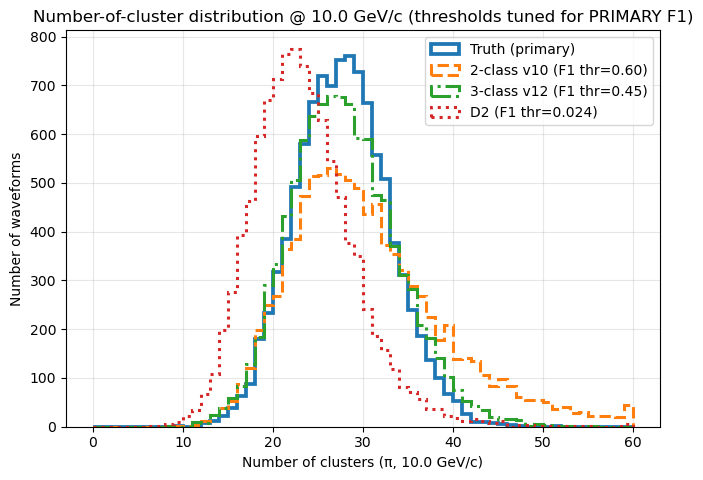

Saved: results/best_primary_F1_truth_v10_v12_D2/hist_overlay_best_primary_F1.png

✅ Done. Outputs in: results/best_primary_F1_truth_v10_v12_D2


In [6]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

# ============================================================
# CONFIG: "BEST FOR PRIMARY" (F1) for v10 / v12 / D2
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]

BIN2_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"       # v10
TRI3_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"   # v12

OUTDIR = "results/best_primary_F1_truth_v10_v12_D2"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

TAG_BG, TAG_PRI, TAG_SEC = 0, 1, 2

FIG8_MOM = 10.0
MOM_ATOL = 0.05
HIST_BINS = np.arange(0, 61, 1)

# Threshold grids
ML_THR_GRID = np.linspace(0.05, 0.95, 19).astype(np.float32)

D2_THR_GRID = np.concatenate([
    np.linspace(0.01, 0.12, 24),
    np.linspace(0.14, 0.40, 14),
    np.linspace(0.45, 0.95, 11),
]).astype(np.float32)

# D2 params
D2_SMOOTH_WIN = 5
D2_MIN_DISTANCE = 6
D2_POLARITY = +1  # flip to -1 if inverted pulses

# Speed / stability controls
FAST_N_MAX = None        # e.g., 50000 for faster trial; None = full
FAST_SEED  = 0
F1_EVAL_N  = 50000       # number of waveforms used to pick best thresholds (recommended 20k-100k)
F1_SEED    = 0

# ============================================================
# MODEL (same as training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)
        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)

# ============================================================
# DATA HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}", flush=True)
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n", flush=True)
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)
    print(f"Loaded: {npz_path} wf_i={wf_i.shape}", flush=True)
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i); mom_all.append(mom); pid_all.append(pid); tt_all.append(tt); tv_all.append(tv)
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)
    print("=== Combined ===", flush=True)
    print("wf_i:", wf.shape, "mom:", mom.shape, "pid:", pid.shape, flush=True)
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    r, c = np.where(valid)
    t = tag_times[r, c]
    y[r, t] = tag_values[r, c].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

# ============================================================
# F1 METRICS
# ============================================================
def f1_from_conf(tp, fp, fn):
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    return float(f1), float(prec), float(rec)

# ============================================================
# ML: compute p_primary for selected waveforms, then best thr by F1
# ============================================================
@torch.no_grad()
def ml_ppri_for_indices(model, wf_i, scaler, device, idx, which_model):
    """
    Returns p_pri array: shape (len(idx), T)
    """
    wf = wf_i[idx]
    N, T = wf.shape
    x = scaler.transform(wf.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    use_cuda = (device.type == "cuda")
    loader = torch.utils.data.DataLoader(
        x_t, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=(4 if use_cuda else 0),
        pin_memory=use_cuda,
        persistent_workers=(True if use_cuda else False),
    )

    model.eval()
    use_amp = use_cuda
    out = np.zeros((N, T), dtype=np.float32)

    pos = 0
    for xb in tqdm(loader, desc=f"p_pri ({which_model})", mininterval=1.0):
        bs = xb.shape[0]
        xb = xb.to(device, non_blocking=True)
        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                probs = torch.softmax(model(xb), dim=-1)
        else:
            probs = torch.softmax(model(xb), dim=-1)

        p_pri = probs[..., 1].detach().cpu().numpy().astype(np.float32)  # (B,T)
        out[pos:pos+bs] = p_pri
        pos += bs
    return out

def pick_best_thr_ml_by_f1(p_pri, y_true_dense, thr_grid):
    """
    p_pri: (N,T)
    y_true_dense: (N,T) integer tags
    Optimize primary vs not-primary at timestep level.
    """
    truth = (y_true_dense == TAG_PRI)
    best_thr, best_f1, best_trip = None, -1.0, None
    for thr in thr_grid:
        pred = (p_pri >= thr)
        tp = int(np.sum(pred & truth))
        fp = int(np.sum(pred & (~truth)))
        fn = int(np.sum((~pred) & truth))
        f1, p, r = f1_from_conf(tp, fp, fn)
        print(f"[ML F1] thr={thr:.2f} F1={f1:.4f} P={p:.4f} R={r:.4f}", flush=True)
        if f1 > best_f1:
            best_f1, best_thr, best_trip = f1, float(thr), (p, r)
    return best_thr, best_f1, best_trip

# After we pick best thr, compute per-waveform cluster counts:
# counts = number of timesteps with p_pri >= thr
@torch.no_grad()
def ml_counts_all_at_thr(model, wf_i, scaler, device, thr, which_model):
    N, T = wf_i.shape
    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    use_cuda = (device.type == "cuda")
    loader = torch.utils.data.DataLoader(
        x_t, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=(4 if use_cuda else 0),
        pin_memory=use_cuda,
        persistent_workers=(True if use_cuda else False),
    )

    model.eval()
    use_amp = use_cuda
    counts = np.zeros(N, dtype=np.int32)
    pos = 0
    thr_t = float(thr)

    for xb in tqdm(loader, desc=f"Counts@thr ({which_model})", mininterval=1.0):
        bs = xb.shape[0]
        xb = xb.to(device, non_blocking=True)
        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                probs = torch.softmax(model(xb), dim=-1)
        else:
            probs = torch.softmax(model(xb), dim=-1)

        p_pri = probs[..., 1]  # (B,T)
        c = (p_pri >= thr_t).sum(dim=1).to(torch.int32).cpu().numpy()
        counts[pos:pos+bs] = c
        pos += bs
    return counts

# ============================================================
# D2: best thr by F1 + counts at best thr
# ============================================================
def smooth_ma_same(x, win):
    if win <= 1:
        return x.astype(np.float32, copy=False)
    k = np.ones(win, dtype=np.float32) / float(win)
    return np.convolve(x.astype(np.float32, copy=False), k, mode="same")

def d2_peaks_and_heights(wf, smooth_win, min_distance, polarity):
    y = smooth_ma_same(wf, smooth_win)
    d2 = np.diff(y, n=2)
    score = -polarity * d2
    peaks, _ = find_peaks(score, distance=min_distance)
    if peaks.size == 0:
        return peaks, np.empty((0,), dtype=np.float32)
    return peaks, score[peaks].astype(np.float32)

def pick_best_thr_d2_by_f1(wf_i, y_dense, idx, thr_grid, smooth_win, min_distance, polarity):
    best_thr, best_f1, best_trip = None, -1.0, None
    T = y_dense.shape[1]
    for thr in thr_grid:
        tp = fp = fn = 0
        thr = float(thr)
        for i in idx:
            peaks, heights = d2_peaks_and_heights(wf_i[i], smooth_win, min_distance, polarity)
            keep = peaks[heights >= thr] if heights.size > 0 else np.empty((0,), dtype=np.int64)

            pred = np.zeros(T, dtype=bool)
            pred[keep] = True
            truth = (y_dense[i] == TAG_PRI)

            tp += int(np.sum(pred & truth))
            fp += int(np.sum(pred & (~truth)))
            fn += int(np.sum((~pred) & truth))

        f1, p, r = f1_from_conf(tp, fp, fn)
        print(f"[D2 F1] thr={thr:.3f} F1={f1:.4f} P={p:.4f} R={r:.4f}", flush=True)
        if f1 > best_f1:
            best_f1, best_thr, best_trip = f1, thr, (p, r)
    return best_thr, best_f1, best_trip

def d2_counts_all_at_thr(wf_i, thr, smooth_win, min_distance, polarity):
    N = wf_i.shape[0]
    counts = np.zeros(N, dtype=np.int32)
    t0 = time.time()
    for i in range(N):
        peaks, heights = d2_peaks_and_heights(wf_i[i], smooth_win, min_distance, polarity)
        if heights.size == 0:
            counts[i] = 0
        else:
            counts[i] = int(np.sum(heights >= float(thr)))
        if (i + 1) % 2000 == 0:
            print(f"[D2 counts] {i+1}/{N} in {time.time()-t0:.1f}s", flush=True)
    return counts

# ============================================================
# PLOTS
# ============================================================
def plot_hist_overlay(truth_counts, v10_counts, v12_counts, d2_counts,
                      mom, pid, thr_v10, thr_v12, thr_d2, out_png):
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=MOM_ATOL))
    if mask.sum() == 0:
        print("No π@10GeV found for histogram.", flush=True)
        return
    xt = truth_counts[mask].astype(np.int32)
    x10 = v10_counts[mask].astype(np.int32)
    x12 = v12_counts[mask].astype(np.int32)
    xd2 = d2_counts[mask].astype(np.int32)

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt,  bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth (primary)")
    plt.hist(x10, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="--",
             label=f"2-class v10 (F1 thr={thr_v10:.2f})")
    plt.hist(x12, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="-.",
             label=f"3-class v12 (F1 thr={thr_v12:.2f})")
    plt.hist(np.clip(xd2, 0, 60), bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":",
             label=f"D2 (F1 thr={thr_d2:.3f})")
    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c (thresholds tuned for PRIMARY F1)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

# ============================================================
# MAIN
# ============================================================
def main():
    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    # Optional fast subset (random)
    if FAST_N_MAX is not None and wf_i.shape[0] > FAST_N_MAX:
        rng = np.random.default_rng(FAST_SEED)
        idx = rng.choice(wf_i.shape[0], size=FAST_N_MAX, replace=False)
        wf_i = wf_i[idx]; mom = mom[idx]; pid = pid[idx]; tag_times = tag_times[idx]; tag_values = tag_values[idx]
        print(f"[FAST] using random subset N={FAST_N_MAX}\n", flush=True)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)

    print("Truth primary-count mean:", float(truth_counts.mean()), flush=True)
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)), flush=True)
    print("", flush=True)

    # Indices used for F1 threshold selection
    rng = np.random.default_rng(F1_SEED)
    idx_f1 = rng.choice(N, size=min(N, F1_EVAL_N), replace=False)
    print(f"F1 threshold tuning on n={idx_f1.size} waveforms\n", flush=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device, flush=True)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0), flush=True)
    print("", flush=True)

    # ----------------------------
    # Load models
    # ----------------------------
    model_v10 = ConvSNN_Deep(num_classes=2).to(device)
    model_v10.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_v12 = ConvSNN_Deep(num_classes=3).to(device)
    model_v12.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ----------------------------
    # v10: best threshold for PRIMARY F1
    # ----------------------------
    ppri_v10 = ml_ppri_for_indices(model_v10, wf_i, scaler, device, idx_f1, "v10 (2-class)")
    y_f1 = y_dense[idx_f1]
    thr_v10, f1_v10, (p_v10, r_v10) = pick_best_thr_ml_by_f1(ppri_v10, y_f1, ML_THR_GRID)
    print(f"\n[v10] best thr={thr_v10:.2f} F1={f1_v10:.4f} P={p_v10:.4f} R={r_v10:.4f}\n", flush=True)

    # ----------------------------
    # v12: best threshold for PRIMARY F1
    # ----------------------------
    ppri_v12 = ml_ppri_for_indices(model_v12, wf_i, scaler, device, idx_f1, "v12 (3-class)")
    thr_v12, f1_v12, (p_v12, r_v12) = pick_best_thr_ml_by_f1(ppri_v12, y_f1, ML_THR_GRID)
    print(f"\n[v12] best thr={thr_v12:.2f} F1={f1_v12:.4f} P={p_v12:.4f} R={r_v12:.4f}\n", flush=True)

    # ----------------------------
    # D2: best threshold for PRIMARY F1
    # ----------------------------
    print(f"[D2] params: smooth={D2_SMOOTH_WIN} dist={D2_MIN_DISTANCE} polarity={D2_POLARITY}", flush=True)
    thr_d2, f1_d2, (p_d2, r_d2) = pick_best_thr_d2_by_f1(
        wf_i, y_dense, idx_f1, D2_THR_GRID, D2_SMOOTH_WIN, D2_MIN_DISTANCE, D2_POLARITY
    )
    print(f"\n[D2] best thr={thr_d2:.3f} F1={f1_d2:.4f} P={p_d2:.4f} R={r_d2:.4f}\n", flush=True)

    # ----------------------------
    # Compute full-dataset cluster counts at those best-primary thresholds
    # ----------------------------
    counts_v10 = ml_counts_all_at_thr(model_v10, wf_i, scaler, device, thr_v10, "v10 (2-class)")
    counts_v12 = ml_counts_all_at_thr(model_v12, wf_i, scaler, device, thr_v12, "v12 (3-class)")
    counts_d2  = d2_counts_all_at_thr(wf_i, thr_d2, D2_SMOOTH_WIN, D2_MIN_DISTANCE, D2_POLARITY)

    # ----------------------------
    # Histogram overlay @10 GeV π
    # ----------------------------
    plot_hist_overlay(
        truth_counts, counts_v10, counts_v12, counts_d2,
        mom, pid, thr_v10, thr_v12, thr_d2,
        out_png=os.path.join(OUTDIR, "hist_overlay_best_primary_F1.png"),
    )

    # Save
    np.savez(
        os.path.join(OUTDIR, "best_primary_thresholds_F1.npz"),
        thr_v10=float(thr_v10), f1_v10=float(f1_v10), prec_v10=float(p_v10), rec_v10=float(r_v10),
        thr_v12=float(thr_v12), f1_v12=float(f1_v12), prec_v12=float(p_v12), rec_v12=float(r_v12),
        thr_d2=float(thr_d2),  f1_d2=float(f1_d2),  prec_d2=float(p_d2),  rec_d2=float(r_d2),
        d2_smooth_win=int(D2_SMOOTH_WIN),
        d2_min_distance=int(D2_MIN_DISTANCE),
        d2_polarity=int(D2_POLARITY),
        f1_eval_n=int(idx_f1.size),
        ml_thr_grid=ML_THR_GRID,
        d2_thr_grid=D2_THR_GRID,
    )

    print("\n✅ Done. Outputs in:", OUTDIR, flush=True)

if __name__ == "__main__":
    main()


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_1.npz wf_i=(40000, 3000)
Loaded: PionsKaons/batch_2.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_3.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_4.npz wf_i=(100000, 3000)
=== Combined ===
wf_i: (440000, 3000) mom: (440000,) pid: (440000,)
Truth primary-count mean: 26.205961363636362
Truth primary-count std : 5.427738023691411

F1 threshold tuning on n=50000 waveforms

Device: cuda
GPU: NVIDIA A100-SXM4-80GB



p_pri (v10 (2-class)): 100%|██████████| 196/196 [01:51<00:00,  1.75it/s]


[ML F1] thr=0.05 F1=0.6037 P=0.4427 R=0.9485
[ML F1] thr=0.10 F1=0.6694 P=0.5216 R=0.9340
[ML F1] thr=0.15 F1=0.7002 P=0.5639 R=0.9232
[ML F1] thr=0.20 F1=0.7186 P=0.5921 R=0.9136
[ML F1] thr=0.25 F1=0.7310 P=0.6131 R=0.9049
[ML F1] thr=0.30 F1=0.7396 P=0.6294 R=0.8964
[ML F1] thr=0.35 F1=0.7457 P=0.6426 R=0.8882
[ML F1] thr=0.40 F1=0.7502 P=0.6538 R=0.8799
[ML F1] thr=0.45 F1=0.7534 P=0.6635 R=0.8716
[ML F1] thr=0.50 F1=0.7557 P=0.6721 R=0.8630
[ML F1] thr=0.55 F1=0.7571 P=0.6800 R=0.8539
[ML F1] thr=0.60 F1=0.7577 P=0.6874 R=0.8440
[ML F1] thr=0.65 F1=0.7574 P=0.6942 R=0.8333
[ML F1] thr=0.70 F1=0.7562 P=0.7007 R=0.8213
[ML F1] thr=0.75 F1=0.7538 P=0.7068 R=0.8074
[ML F1] thr=0.80 F1=0.7496 P=0.7130 R=0.7903
[ML F1] thr=0.85 F1=0.7412 P=0.7187 R=0.7652
[ML F1] thr=0.90 F1=0.7303 P=0.7255 R=0.7353
[ML F1] thr=0.95 F1=0.7122 P=0.7347 R=0.6911

[v10] best thr=0.60 F1=0.7577 P=0.6874 R=0.8440



p_pri (v12 (3-class)): 100%|██████████| 196/196 [01:52<00:00,  1.74it/s]


[ML F1] thr=0.05 F1=0.6726 P=0.5233 R=0.9411
[ML F1] thr=0.10 F1=0.7351 P=0.6109 R=0.9226
[ML F1] thr=0.15 F1=0.7628 P=0.6578 R=0.9076
[ML F1] thr=0.20 F1=0.7804 P=0.6929 R=0.8931
[ML F1] thr=0.25 F1=0.7919 P=0.7204 R=0.8791
[ML F1] thr=0.30 F1=0.7996 P=0.7438 R=0.8645
[ML F1] thr=0.35 F1=0.8041 P=0.7628 R=0.8502
[ML F1] thr=0.40 F1=0.8064 P=0.7789 R=0.8358
[ML F1] thr=0.45 F1=0.8067 P=0.7932 R=0.8207
[ML F1] thr=0.50 F1=0.8052 P=0.8068 R=0.8036
[ML F1] thr=0.55 F1=0.8008 P=0.8210 R=0.7816
[ML F1] thr=0.60 F1=0.7931 P=0.8347 R=0.7554
[ML F1] thr=0.65 F1=0.7826 P=0.8464 R=0.7278
[ML F1] thr=0.70 F1=0.7689 P=0.8572 R=0.6971
[ML F1] thr=0.75 F1=0.7462 P=0.8694 R=0.6536
[ML F1] thr=0.80 F1=0.7116 P=0.8832 R=0.5958
[ML F1] thr=0.85 F1=0.6512 P=0.8988 R=0.5106
[ML F1] thr=0.90 F1=0.5495 P=0.9161 R=0.3924
[ML F1] thr=0.95 F1=0.0566 P=0.9399 R=0.0292

[v12] best thr=0.45 F1=0.8067 P=0.7932 R=0.8207

[D2] params: smooth=5 dist=6 polarity=1
[D2 F1] thr=0.010 F1=0.0194 P=0.0109 R=0.0852
[D2 F1] t

Counts@thr (v12 (3-class)): 100%|██████████| 1719/1719 [16:20<00:00,  1.75it/s]


[D2 counts] 2000/440000 in 0.3s
[D2 counts] 4000/440000 in 0.6s
[D2 counts] 6000/440000 in 0.9s
[D2 counts] 8000/440000 in 1.2s
[D2 counts] 10000/440000 in 1.5s
[D2 counts] 12000/440000 in 1.8s
[D2 counts] 14000/440000 in 2.1s
[D2 counts] 16000/440000 in 2.4s
[D2 counts] 18000/440000 in 2.7s
[D2 counts] 20000/440000 in 3.0s
[D2 counts] 22000/440000 in 3.3s
[D2 counts] 24000/440000 in 3.6s
[D2 counts] 26000/440000 in 3.9s
[D2 counts] 28000/440000 in 4.2s
[D2 counts] 30000/440000 in 4.5s
[D2 counts] 32000/440000 in 4.8s
[D2 counts] 34000/440000 in 5.1s
[D2 counts] 36000/440000 in 5.4s
[D2 counts] 38000/440000 in 5.7s
[D2 counts] 40000/440000 in 6.0s
[D2 counts] 42000/440000 in 6.3s
[D2 counts] 44000/440000 in 6.6s
[D2 counts] 46000/440000 in 6.9s
[D2 counts] 48000/440000 in 7.2s
[D2 counts] 50000/440000 in 7.5s
[D2 counts] 52000/440000 in 7.8s
[D2 counts] 54000/440000 in 8.1s
[D2 counts] 56000/440000 in 8.4s
[D2 counts] 58000/440000 in 8.7s
[D2 counts] 60000/440000 in 9.0s
[D2 counts] 62

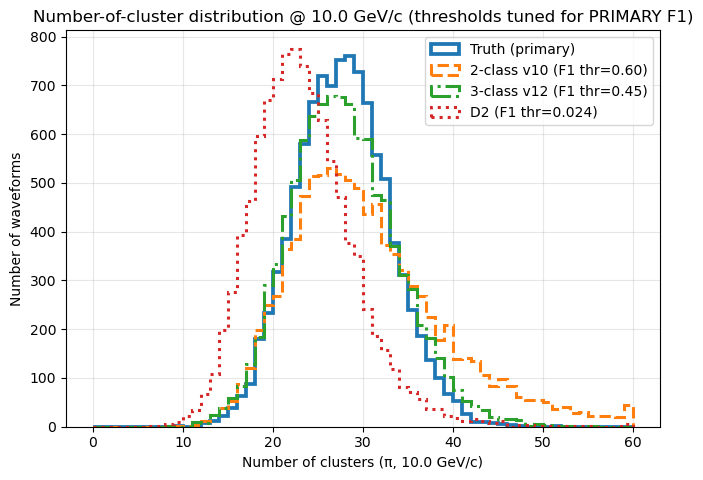

Saved: results/best_primary_F1_truth_v10_v12_D2/hist_overlay_best_primary_F1.png


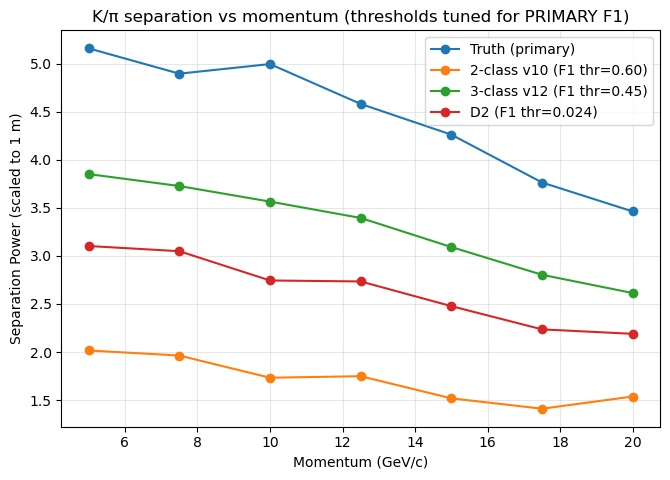

Saved: results/best_primary_F1_truth_v10_v12_D2/sep_curve_best_primary_F1.png

✅ Done. Outputs in: results/best_primary_F1_truth_v10_v12_D2


In [8]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

# ============================================================
# CONFIG: "BEST FOR PRIMARY" (F1) for v10 / v12 / D2  + separation plot
# ============================================================
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]

BIN2_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"       # v10
TRI3_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"   # v12

OUTDIR = "results/best_primary_F1_truth_v10_v12_D2"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211

TAG_BG, TAG_PRI, TAG_SEC = 0, 1, 2

FIG8_MOM = 10.0
MOM_ATOL = 0.05
HIST_BINS = np.arange(0, 61, 1)

# Threshold grids
ML_THR_GRID = np.linspace(0.05, 0.95, 19).astype(np.float32)

D2_THR_GRID = np.concatenate([
    np.linspace(0.01, 0.12, 24),
    np.linspace(0.14, 0.40, 14),
    np.linspace(0.45, 0.95, 11),
]).astype(np.float32)

# D2 params
D2_SMOOTH_WIN = 5
D2_MIN_DISTANCE = 6
D2_POLARITY = +1  # flip to -1 if inverted pulses

# Speed / stability controls
FAST_N_MAX = None        # e.g., 50000 for faster trial; None = full
FAST_SEED  = 0
F1_EVAL_N  = 50000       # number of waveforms used to pick best thresholds (recommended 20k-100k)
F1_SEED    = 0

# Separation scaling to 1 m
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

# Momenta to plot (paper-style)
OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
MIN_PER_CLASS = 50  # require at least this many K and π events per momentum bin

# ============================================================
# MODEL (same as training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)
        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)

# ============================================================
# DATA HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}", flush=True)
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n", flush=True)
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)
    print(f"Loaded: {npz_path} wf_i={wf_i.shape}", flush=True)
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i); mom_all.append(mom); pid_all.append(pid); tt_all.append(tt); tv_all.append(tv)
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)
    print("=== Combined ===", flush=True)
    print("wf_i:", wf.shape, "mom:", mom.shape, "pid:", pid.shape, flush=True)
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    r, c = np.where(valid)
    t = tag_times[r, c]
    y[r, t] = tag_values[r, c].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

# ============================================================
# F1 METRICS
# ============================================================
def f1_from_conf(tp, fp, fn):
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    return float(f1), float(prec), float(rec)

# ============================================================
# ML: compute p_primary for selected waveforms, then best thr by F1
# ============================================================
@torch.no_grad()
def ml_ppri_for_indices(model, wf_i, scaler, device, idx, which_model):
    wf = wf_i[idx]
    N, T = wf.shape
    x = scaler.transform(wf.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    use_cuda = (device.type == "cuda")
    loader = torch.utils.data.DataLoader(
        x_t, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=(4 if use_cuda else 0),
        pin_memory=use_cuda,
        persistent_workers=(True if use_cuda else False),
    )

    model.eval()
    use_amp = use_cuda
    out = np.zeros((N, T), dtype=np.float32)

    pos = 0
    for xb in tqdm(loader, desc=f"p_pri ({which_model})", mininterval=1.0):
        bs = xb.shape[0]
        xb = xb.to(device, non_blocking=True)
        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                probs = torch.softmax(model(xb), dim=-1)
        else:
            probs = torch.softmax(model(xb), dim=-1)

        p_pri = probs[..., 1].detach().cpu().numpy().astype(np.float32)  # (B,T)
        out[pos:pos+bs] = p_pri
        pos += bs
    return out

def pick_best_thr_ml_by_f1(p_pri, y_true_dense, thr_grid):
    truth = (y_true_dense == TAG_PRI)
    best_thr, best_f1, best_trip = None, -1.0, None
    for thr in thr_grid:
        pred = (p_pri >= thr)
        tp = int(np.sum(pred & truth))
        fp = int(np.sum(pred & (~truth)))
        fn = int(np.sum((~pred) & truth))
        f1, p, r = f1_from_conf(tp, fp, fn)
        print(f"[ML F1] thr={thr:.2f} F1={f1:.4f} P={p:.4f} R={r:.4f}", flush=True)
        if f1 > best_f1:
            best_f1, best_thr, best_trip = f1, float(thr), (p, r)
    return best_thr, best_f1, best_trip

@torch.no_grad()
def ml_counts_all_at_thr(model, wf_i, scaler, device, thr, which_model):
    N, T = wf_i.shape
    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    use_cuda = (device.type == "cuda")
    loader = torch.utils.data.DataLoader(
        x_t, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=(4 if use_cuda else 0),
        pin_memory=use_cuda,
        persistent_workers=(True if use_cuda else False),
    )

    model.eval()
    use_amp = use_cuda
    counts = np.zeros(N, dtype=np.int32)
    pos = 0
    thr_t = float(thr)

    for xb in tqdm(loader, desc=f"Counts@thr ({which_model})", mininterval=1.0):
        bs = xb.shape[0]
        xb = xb.to(device, non_blocking=True)
        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                probs = torch.softmax(model(xb), dim=-1)
        else:
            probs = torch.softmax(model(xb), dim=-1)

        p_pri = probs[..., 1]  # (B,T)
        c = (p_pri >= thr_t).sum(dim=1).to(torch.int32).cpu().numpy()
        counts[pos:pos+bs] = c
        pos += bs
    return counts

# ============================================================
# D2: best thr by F1 + counts at best thr
# ============================================================
def smooth_ma_same(x, win):
    if win <= 1:
        return x.astype(np.float32, copy=False)
    k = np.ones(win, dtype=np.float32) / float(win)
    return np.convolve(x.astype(np.float32, copy=False), k, mode="same")

def d2_peaks_and_heights(wf, smooth_win, min_distance, polarity):
    y = smooth_ma_same(wf, smooth_win)
    d2 = np.diff(y, n=2)
    score = -polarity * d2
    peaks, _ = find_peaks(score, distance=min_distance)
    if peaks.size == 0:
        return peaks, np.empty((0,), dtype=np.float32)
    return peaks, score[peaks].astype(np.float32)

def pick_best_thr_d2_by_f1(wf_i, y_dense, idx, thr_grid, smooth_win, min_distance, polarity):
    best_thr, best_f1, best_trip = None, -1.0, None
    T = y_dense.shape[1]
    for thr in thr_grid:
        tp = fp = fn = 0
        thr = float(thr)
        for i in idx:
            peaks, heights = d2_peaks_and_heights(wf_i[i], smooth_win, min_distance, polarity)
            keep = peaks[heights >= thr] if heights.size > 0 else np.empty((0,), dtype=np.int64)

            pred = np.zeros(T, dtype=bool)
            pred[keep] = True
            truth = (y_dense[i] == TAG_PRI)

            tp += int(np.sum(pred & truth))
            fp += int(np.sum(pred & (~truth)))
            fn += int(np.sum((~pred) & truth))

        f1, p, r = f1_from_conf(tp, fp, fn)
        print(f"[D2 F1] thr={thr:.3f} F1={f1:.4f} P={p:.4f} R={r:.4f}", flush=True)
        if f1 > best_f1:
            best_f1, best_thr, best_trip = f1, thr, (p, r)
    return best_thr, best_f1, best_trip

def d2_counts_all_at_thr(wf_i, thr, smooth_win, min_distance, polarity):
    N = wf_i.shape[0]
    counts = np.zeros(N, dtype=np.int32)
    t0 = time.time()
    for i in range(N):
        peaks, heights = d2_peaks_and_heights(wf_i[i], smooth_win, min_distance, polarity)
        counts[i] = int(np.sum(heights >= float(thr))) if heights.size else 0
        if (i + 1) % 2000 == 0:
            print(f"[D2 counts] {i+1}/{N} in {time.time()-t0:.1f}s", flush=True)
    return counts

# ============================================================
# SEPARATION (paper-style) HELPERS + PLOT
# ============================================================
def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use):
    moms_used, S = [], []
    for p in moms_to_use:
        mk  = (np.isclose(mom, p, atol=MOM_ATOL)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p, atol=MOM_ATOL)) & (pid == PID_PION)

        if mk.sum() < MIN_PER_CLASS or mpi.sum() < MIN_PER_CLASS:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK   = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)

        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))
    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_sep_overlay(moms, curves_dict, out_png, title):
    plt.figure(figsize=(6.8, 4.9))
    for label, y in curves_dict.items():
        plt.plot(moms, y, marker="o", label=label)
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

# ============================================================
# HISTOGRAM PLOT
# ============================================================
def plot_hist_overlay(truth_counts, v10_counts, v12_counts, d2_counts,
                      mom, pid, thr_v10, thr_v12, thr_d2, out_png):
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=MOM_ATOL))
    if mask.sum() == 0:
        print("No π@10GeV found for histogram.", flush=True)
        return

    xt = truth_counts[mask].astype(np.int32)
    x10 = v10_counts[mask].astype(np.int32)
    x12 = v12_counts[mask].astype(np.int32)
    xd2 = d2_counts[mask].astype(np.int32)

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt,  bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth (primary)")
    plt.hist(x10, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="--",
             label=f"2-class v10 (F1 thr={thr_v10:.2f})")
    plt.hist(x12, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="-.",
             label=f"3-class v12 (F1 thr={thr_v12:.2f})")
    plt.hist(np.clip(xd2, 0, 60), bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":",
             label=f"D2 (F1 thr={thr_d2:.3f})")
    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c (thresholds tuned for PRIMARY F1)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

# ============================================================
# MAIN
# ============================================================
def main():
    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    # Optional fast subset
    if FAST_N_MAX is not None and wf_i.shape[0] > FAST_N_MAX:
        rng = np.random.default_rng(FAST_SEED)
        idx = rng.choice(wf_i.shape[0], size=FAST_N_MAX, replace=False)
        wf_i = wf_i[idx]; mom = mom[idx]; pid = pid[idx]; tag_times = tag_times[idx]; tag_values = tag_values[idx]
        print(f"[FAST] using random subset N={FAST_N_MAX}\n", flush=True)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)

    print("Truth primary-count mean:", float(truth_counts.mean()), flush=True)
    print("Truth primary-count std :", float(truth_counts.std(ddof=1)), flush=True)
    print("", flush=True)

    # Indices used for F1 threshold selection
    rng = np.random.default_rng(F1_SEED)
    idx_f1 = rng.choice(N, size=min(N, F1_EVAL_N), replace=False)
    print(f"F1 threshold tuning on n={idx_f1.size} waveforms\n", flush=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device, flush=True)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0), flush=True)
    print("", flush=True)

    # Load models
    model_v10 = ConvSNN_Deep(num_classes=2).to(device)
    model_v10.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))

    model_v12 = ConvSNN_Deep(num_classes=3).to(device)
    model_v12.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # v10 best threshold for PRIMARY F1
    y_f1 = y_dense[idx_f1]
    ppri_v10 = ml_ppri_for_indices(model_v10, wf_i, scaler, device, idx_f1, "v10 (2-class)")
    thr_v10, f1_v10, (p_v10, r_v10) = pick_best_thr_ml_by_f1(ppri_v10, y_f1, ML_THR_GRID)
    print(f"\n[v10] best thr={thr_v10:.2f} F1={f1_v10:.4f} P={p_v10:.4f} R={r_v10:.4f}\n", flush=True)

    # v12 best threshold for PRIMARY F1
    ppri_v12 = ml_ppri_for_indices(model_v12, wf_i, scaler, device, idx_f1, "v12 (3-class)")
    thr_v12, f1_v12, (p_v12, r_v12) = pick_best_thr_ml_by_f1(ppri_v12, y_f1, ML_THR_GRID)
    print(f"\n[v12] best thr={thr_v12:.2f} F1={f1_v12:.4f} P={p_v12:.4f} R={r_v12:.4f}\n", flush=True)

    # D2 best threshold for PRIMARY F1
    print(f"[D2] params: smooth={D2_SMOOTH_WIN} dist={D2_MIN_DISTANCE} polarity={D2_POLARITY}", flush=True)
    thr_d2, f1_d2, (p_d2, r_d2) = pick_best_thr_d2_by_f1(
        wf_i, y_dense, idx_f1, D2_THR_GRID, D2_SMOOTH_WIN, D2_MIN_DISTANCE, D2_POLARITY
    )
    print(f"\n[D2] best thr={thr_d2:.3f} F1={f1_d2:.4f} P={p_d2:.4f} R={r_d2:.4f}\n", flush=True)

    # Compute full-dataset cluster counts at those thresholds
    counts_v10 = ml_counts_all_at_thr(model_v10, wf_i, scaler, device, thr_v10, "v10 (2-class)")
    counts_v12 = ml_counts_all_at_thr(model_v12, wf_i, scaler, device, thr_v12, "v12 (3-class)")
    counts_d2  = d2_counts_all_at_thr(wf_i, thr_d2, D2_SMOOTH_WIN, D2_MIN_DISTANCE, D2_POLARITY)

    # Histogram overlay @10 GeV π
    plot_hist_overlay(
        truth_counts, counts_v10, counts_v12, counts_d2,
        mom, pid, thr_v10, thr_v12, thr_d2,
        out_png=os.path.join(OUTDIR, "hist_overlay_best_primary_F1.png"),
    )

    # Separation plot (Truth + v10 + v12 + D2), scaled to 1 m
    moms, S_truth = separation_vs_momentum(truth_counts, mom, pid, OPT_MOMENTA)
    _,    S_v10   = separation_vs_momentum(counts_v10,   mom, pid, OPT_MOMENTA)
    _,    S_v12   = separation_vs_momentum(counts_v12,   mom, pid, OPT_MOMENTA)
    _,    S_d2    = separation_vs_momentum(counts_d2,    mom, pid, OPT_MOMENTA)

    plot_sep_overlay(
        moms,
        curves_dict={
            "Truth (primary)": S_truth * SCALE_TO_1M,
            f"2-class v10 (F1 thr={thr_v10:.2f})": S_v10 * SCALE_TO_1M,
            f"3-class v12 (F1 thr={thr_v12:.2f})": S_v12 * SCALE_TO_1M,
            f"D2 (F1 thr={thr_d2:.3f})": S_d2 * SCALE_TO_1M,
        },
        out_png=os.path.join(OUTDIR, "sep_curve_best_primary_F1.png"),
        title="K/π separation vs momentum (thresholds tuned for PRIMARY F1)",
    )

    # Save thresholds + metadata
    np.savez(
        os.path.join(OUTDIR, "best_primary_thresholds_F1.npz"),
        thr_v10=float(thr_v10), f1_v10=float(f1_v10), prec_v10=float(p_v10), rec_v10=float(r_v10),
        thr_v12=float(thr_v12), f1_v12=float(f1_v12), prec_v12=float(p_v12), rec_v12=float(r_v12),
        thr_d2=float(thr_d2),  f1_d2=float(f1_d2),  prec_d2=float(p_d2),  rec_d2=float(r_d2),
        d2_smooth_win=int(D2_SMOOTH_WIN),
        d2_min_distance=int(D2_MIN_DISTANCE),
        d2_polarity=int(D2_POLARITY),
        f1_eval_n=int(idx_f1.size),
        ml_thr_grid=ML_THR_GRID,
        d2_thr_grid=D2_THR_GRID,
        mom_atol=float(MOM_ATOL),
        min_per_class=int(MIN_PER_CLASS),
        scale_to_1m=float(SCALE_TO_1M),
    )

    print("\n✅ Done. Outputs in:", OUTDIR, flush=True)

if __name__ == "__main__":
    main()


Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_1.npz wf_i=(40000, 3000)
Loaded: PionsKaons/batch_2.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_3.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_4.npz wf_i=(100000, 3000)
=== Combined ===
wf_i: (440000, 3000) mom: (440000,) pid: (440000,)
Truth primary-count mean/std (dense): 26.205961363636362 5.427738023691411

F1 threshold tuning on n=50000 waveforms

Device: cuda
GPU: NVIDIA A100-SXM4-80GB



p (v10 (2-class)): 100%|██████████| 196/196 [01:52<00:00,  1.74it/s]


[ML PEAK-F1] thr=0.05 F1=0.3813 P=0.2462 R=0.8451
[ML PEAK-F1] thr=0.10 F1=0.3984 P=0.2610 R=0.8413
[ML PEAK-F1] thr=0.15 F1=0.4047 P=0.2667 R=0.8388
[ML PEAK-F1] thr=0.20 F1=0.4079 P=0.2697 R=0.8366
[ML PEAK-F1] thr=0.25 F1=0.4099 P=0.2717 R=0.8346
[ML PEAK-F1] thr=0.30 F1=0.4112 P=0.2730 R=0.8326
[ML PEAK-F1] thr=0.35 F1=0.4121 P=0.2741 R=0.8304
[ML PEAK-F1] thr=0.40 F1=0.4127 P=0.2749 R=0.8279
[ML PEAK-F1] thr=0.45 F1=0.4131 P=0.2756 R=0.8248
[ML PEAK-F1] thr=0.50 F1=0.4133 P=0.2762 R=0.8209
[ML PEAK-F1] thr=0.55 F1=0.4132 P=0.2767 R=0.8155
[ML PEAK-F1] thr=0.60 F1=0.4127 P=0.2772 R=0.8079
[ML PEAK-F1] thr=0.65 F1=0.4120 P=0.2776 R=0.7985
[ML PEAK-F1] thr=0.70 F1=0.4108 P=0.2780 R=0.7872
[ML PEAK-F1] thr=0.75 F1=0.4094 P=0.2783 R=0.7740
[ML PEAK-F1] thr=0.80 F1=0.4074 P=0.2786 R=0.7577
[ML PEAK-F1] thr=0.85 F1=0.4041 P=0.2788 R=0.7339
[ML PEAK-F1] thr=0.90 F1=0.3999 P=0.2789 R=0.7060
[ML PEAK-F1] thr=0.95 F1=0.3932 P=0.2789 R=0.6660

[v10] best PEAK-thr=0.50 F1=0.4133 P=0.2762 R=0.8

p (v12 (3-class)): 100%|██████████| 196/196 [01:52<00:00,  1.75it/s]


[ML PEAK-F1] thr=0.05 F1=0.3931 P=0.2561 R=0.8451
[ML PEAK-F1] thr=0.10 F1=0.4067 P=0.2682 R=0.8407
[ML PEAK-F1] thr=0.15 F1=0.4125 P=0.2737 R=0.8369
[ML PEAK-F1] thr=0.20 F1=0.4163 P=0.2775 R=0.8330
[ML PEAK-F1] thr=0.25 F1=0.4190 P=0.2804 R=0.8287
[ML PEAK-F1] thr=0.70 F1=0.4205 P=0.3011 R=0.6970
[ML PEAK-F1] thr=0.75 F1=0.4152 P=0.3035 R=0.6571
[ML PEAK-F1] thr=0.80 F1=0.4062 P=0.3064 R=0.6025
[ML PEAK-F1] thr=0.85 F1=0.3883 P=0.3098 R=0.5202
[ML PEAK-F1] thr=0.90 F1=0.3522 P=0.3134 R=0.4019
[ML PEAK-F1] thr=0.95 F1=0.0535 P=0.3144 R=0.0293

[v12] best PEAK-thr=0.55 F1=0.4263 P=0.2942 R=0.7735

[D2] params: smooth=5 dist=6 polarity=1
[D2 PEAK-F1] thr=0.010 F1=0.0616 P=0.0321 R=0.7519
[D2 PEAK-F1] thr=0.015 F1=0.1387 P=0.0767 R=0.7220
[D2 PEAK-F1] thr=0.020 F1=0.2763 P=0.1732 R=0.6825
[D2 PEAK-F1] thr=0.024 F1=0.3529 P=0.2434 R=0.6414
[D2 PEAK-F1] thr=0.029 F1=0.3636 P=0.2606 R=0.6010
[D2 PEAK-F1] thr=0.034 F1=0.3602 P=0.2649 R=0.5626
[D2 PEAK-F1] thr=0.039 F1=0.3548 P=0.2677 R=0.526

PeakCounts@thr (v12 (3-class)): 100%|██████████| 1719/1719 [17:13<00:00,  1.66it/s]


[D2 peak-counts] 2000/440000 in 0.3s
[D2 peak-counts] 4000/440000 in 0.6s
[D2 peak-counts] 6000/440000 in 0.9s
[D2 peak-counts] 8000/440000 in 1.2s
[D2 peak-counts] 10000/440000 in 1.5s
[D2 peak-counts] 12000/440000 in 1.7s
[D2 peak-counts] 14000/440000 in 2.0s
[D2 peak-counts] 16000/440000 in 2.3s
[D2 peak-counts] 18000/440000 in 2.6s
[D2 peak-counts] 20000/440000 in 2.9s
[D2 peak-counts] 22000/440000 in 3.2s
[D2 peak-counts] 24000/440000 in 3.5s
[D2 peak-counts] 26000/440000 in 3.8s
[D2 peak-counts] 28000/440000 in 4.1s
[D2 peak-counts] 30000/440000 in 4.4s
[D2 peak-counts] 32000/440000 in 4.6s
[D2 peak-counts] 34000/440000 in 4.9s
[D2 peak-counts] 36000/440000 in 5.2s
[D2 peak-counts] 38000/440000 in 5.5s
[D2 peak-counts] 40000/440000 in 5.8s
[D2 peak-counts] 42000/440000 in 6.1s
[D2 peak-counts] 44000/440000 in 6.4s
[D2 peak-counts] 46000/440000 in 6.7s
[D2 peak-counts] 48000/440000 in 7.0s
[D2 peak-counts] 50000/440000 in 7.3s
[D2 peak-counts] 52000/440000 in 7.5s
[D2 peak-counts]

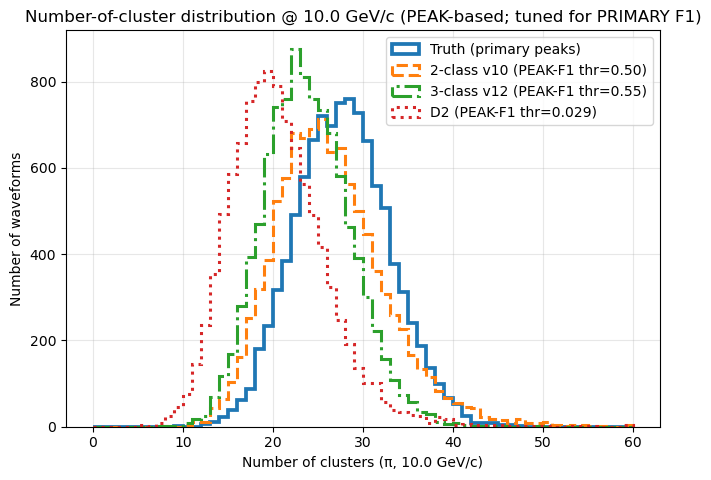

Saved: results/best_primary_F1_truth_v10_v12_D2_PEAKS/hist_overlay_best_primary_F1_PEAKS.png


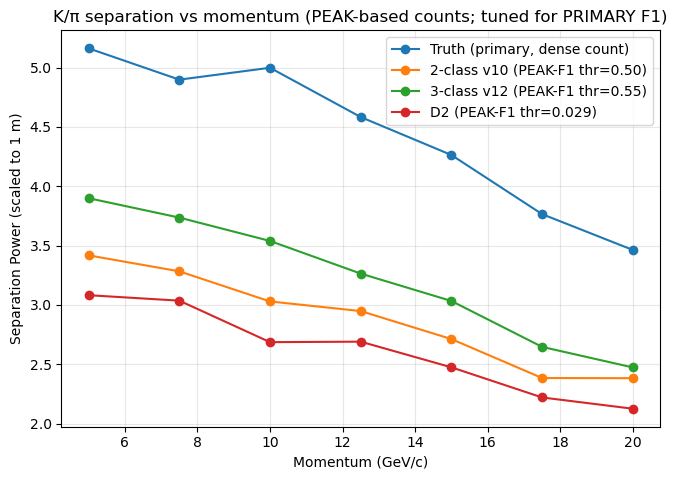

Saved: results/best_primary_F1_truth_v10_v12_D2_PEAKS/sep_curve_best_primary_F1_PEAKS.png

✅ Done. Outputs in: results/best_primary_F1_truth_v10_v12_D2_PEAKS


In [3]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

# ============================================================
# FULL CODE (FIXED): Apples-to-apples PEAK counting for v10/v12/D2
# - Tune thresholds for PRIMARY F1 (timestep-level for ML, peak-level for D2)
# - Compute cluster counts as NUMBER OF PEAKS (not dense timestep counts)
# - Plot:
#   (1) histogram overlay @ 10 GeV/c pion
#   (2) separation vs momentum (scaled to 1 m)
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]

BIN2_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"       # v10 (2-class: signal=pri+sec)
TRI3_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"   # v12 (3-class: bg/pri/sec)

OUTDIR = "results/best_primary_F1_truth_v10_v12_D2_PEAKS"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211
TAG_BG, TAG_PRI, TAG_SEC = 0, 1, 2

FIG8_MOM = 10.0
MOM_ATOL = 0.05
HIST_BINS = np.arange(0, 61, 1)

# Threshold grids
ML_THR_GRID = np.linspace(0.05, 0.95, 19).astype(np.float32)  # threshold on p_primary or p_signal
D2_THR_GRID = np.concatenate([
    np.linspace(0.01, 0.12, 24),
    np.linspace(0.14, 0.40, 14),
    np.linspace(0.45, 0.95, 11),
]).astype(np.float32)

# Peak finding parameters (make ML and D2 comparable)
# NOTE: Use the same min_distance for ML peaks and D2 peaks.
PEAK_MIN_DISTANCE = 6
PEAK_PROMINENCE = None     # optional: set e.g. 0.02 if you want extra noise suppression
PEAK_WIDTH = None          # optional

# D2 params
D2_SMOOTH_WIN = 5
D2_MIN_DISTANCE = PEAK_MIN_DISTANCE
D2_POLARITY = +1           # flip to -1 if inverted pulses

# Speed / stability
FAST_N_MAX = None          # e.g., 50000 for faster trial; None = full
FAST_SEED  = 0
F1_EVAL_N  = 50000
F1_SEED    = 0

# Separation scaling to 1 m
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
MIN_PER_CLASS = 50

# ============================================================
# MODEL (same as training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)
        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)

# ============================================================
# DATA HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}", flush=True)
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n", flush=True)
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)
    print(f"Loaded: {npz_path} wf_i={wf_i.shape}", flush=True)
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i); mom_all.append(mom); pid_all.append(pid); tt_all.append(tt); tv_all.append(tv)
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)
    print("=== Combined ===", flush=True)
    print("wf_i:", wf.shape, "mom:", mom.shape, "pid:", pid.shape, flush=True)
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    r, c = np.where(valid)
    t = tag_times[r, c]
    y[r, t] = tag_values[r, c].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

# ============================================================
# METRICS
# ============================================================
def f1_from_conf(tp, fp, fn):
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    return float(f1), float(prec), float(rec)

# ============================================================
# PEAK HELPERS (for ML probability traces)
# ============================================================
def peaks_from_prob_trace(p, thr, min_distance, prominence=None, width=None):
    """
    p: (T,) probability trace
    Returns indices of peaks with p[peak] >= thr
    """
    peaks, props = find_peaks(p, distance=min_distance, prominence=prominence, width=width)
    if peaks.size == 0:
        return peaks
    keep = peaks[p[peaks] >= float(thr)]
    return keep

def peak_labels_from_truth(y_row, peak_idx, tol=1):
    """
    Mark predicted peaks as True in a boolean array of length T,
    but allow +/- tol window around the peak to match a truth timestep.
    Returns pred_bool (T,)
    """
    T = y_row.shape[0]
    pred = np.zeros(T, dtype=bool)
    if peak_idx.size == 0:
        return pred
    for t in peak_idx:
        lo = max(0, int(t) - tol)
        hi = min(T, int(t) + tol + 1)
        pred[lo:hi] = True
    return pred

# ============================================================
# ML: compute p_primary (or p_signal for v10) for selected waveforms
# ============================================================
@torch.no_grad()
def ml_prob_for_indices(model, wf_i, scaler, device, idx, which_model, use_primary_channel=True):
    """
    Returns p array: shape (len(idx), T)
    For v12: use_primary_channel=True -> channel 1 (primary)
    For v10: "primary" doesn't exist; channel 1 = signal (pri+sec)
    """
    wf = wf_i[idx]
    N, T = wf.shape
    x = scaler.transform(wf.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    use_cuda = (device.type == "cuda")
    loader = torch.utils.data.DataLoader(
        x_t, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=(4 if use_cuda else 0),
        pin_memory=use_cuda,
        persistent_workers=(True if use_cuda else False),
    )

    model.eval()
    use_amp = use_cuda
    out = np.zeros((N, T), dtype=np.float32)

    pos = 0
    for xb in tqdm(loader, desc=f"p ({which_model})", mininterval=1.0):
        bs = xb.shape[0]
        xb = xb.to(device, non_blocking=True)
        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                probs = torch.softmax(model(xb), dim=-1)
        else:
            probs = torch.softmax(model(xb), dim=-1)

        # channel 1 always taken: for v12 it's primary, for v10 it's signal
        p = probs[..., 1].detach().cpu().numpy().astype(np.float32)
        out[pos:pos+bs] = p
        pos += bs
    return out

def pick_best_thr_ml_by_peak_f1(p_mat, y_true_dense, thr_grid, min_distance, prominence=None, width=None, match_tol=1):
    """
    Optimize threshold for PRIMARY F1, but using PEAKS as predictions (apples-to-apples with D2).
    - For v12: p_mat is p_primary
    - For v10: p_mat is p_signal (will likely be contaminated by secondaries)
    """
    best_thr, best_f1, best_trip = None, -1.0, None
    N, T = p_mat.shape
    for thr in thr_grid:
        tp = fp = fn = 0
        thr = float(thr)
        for i in range(N):
            peaks = peaks_from_prob_trace(p_mat[i], thr, min_distance, prominence=prominence, width=width)
            pred = peak_labels_from_truth(y_true_dense[i], peaks, tol=match_tol)
            truth = (y_true_dense[i] == TAG_PRI)

            tp += int(np.sum(pred & truth))
            fp += int(np.sum(pred & (~truth)))
            fn += int(np.sum((~pred) & truth))

        f1, p, r = f1_from_conf(tp, fp, fn)
        print(f"[ML PEAK-F1] thr={thr:.2f} F1={f1:.4f} P={p:.4f} R={r:.4f}", flush=True)
        if f1 > best_f1:
            best_f1, best_thr, best_trip = f1, thr, (p, r)
    return best_thr, best_f1, best_trip

@torch.no_grad()
def ml_peak_counts_all_at_thr(model, wf_i, scaler, device, thr, which_model,
                             min_distance, prominence=None, width=None):
    """
    Compute per-waveform cluster counts = number of peaks in p(channel=1) above thr.
    """
    N, T = wf_i.shape
    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    use_cuda = (device.type == "cuda")
    loader = torch.utils.data.DataLoader(
        x_t, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=(4 if use_cuda else 0),
        pin_memory=use_cuda,
        persistent_workers=(True if use_cuda else False),
    )

    model.eval()
    use_amp = use_cuda
    counts = np.zeros(N, dtype=np.int32)
    pos = 0
    thr = float(thr)

    for xb in tqdm(loader, desc=f"PeakCounts@thr ({which_model})", mininterval=1.0):
        bs = xb.shape[0]
        xb = xb.to(device, non_blocking=True)
        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                probs = torch.softmax(model(xb), dim=-1)
        else:
            probs = torch.softmax(model(xb), dim=-1)

        p = probs[..., 1].detach().cpu().numpy().astype(np.float32)  # (B,T)

        for j in range(bs):
            peaks = peaks_from_prob_trace(p[j], thr, min_distance, prominence=prominence, width=width)
            counts[pos + j] = int(peaks.size)
        pos += bs

    return counts

# ============================================================
# D2: peak-F1 + counts
# ============================================================
def smooth_ma_same(x, win):
    if win <= 1:
        return x.astype(np.float32, copy=False)
    k = np.ones(win, dtype=np.float32) / float(win)
    return np.convolve(x.astype(np.float32, copy=False), k, mode="same")

def d2_peaks_and_heights(wf, smooth_win, min_distance, polarity, prominence=None, width=None):
    y = smooth_ma_same(wf, smooth_win)
    d2 = np.diff(y, n=2)
    score = -polarity * d2
    peaks, _ = find_peaks(score, distance=min_distance, prominence=prominence, width=width)
    if peaks.size == 0:
        return peaks, np.empty((0,), dtype=np.float32)
    return peaks, score[peaks].astype(np.float32)

def pick_best_thr_d2_by_peak_f1(wf_i, y_dense, idx, thr_grid, smooth_win, min_distance, polarity, match_tol=1):
    best_thr, best_f1, best_trip = None, -1.0, None
    T = y_dense.shape[1]
    for thr in thr_grid:
        tp = fp = fn = 0
        thr = float(thr)
        for i in idx:
            peaks, heights = d2_peaks_and_heights(wf_i[i], smooth_win, min_distance, polarity)
            keep = peaks[heights >= thr] if heights.size > 0 else np.empty((0,), dtype=np.int64)

            pred = peak_labels_from_truth(y_dense[i], keep, tol=match_tol)
            truth = (y_dense[i] == TAG_PRI)

            tp += int(np.sum(pred & truth))
            fp += int(np.sum(pred & (~truth)))
            fn += int(np.sum((~pred) & truth))

        f1, p, r = f1_from_conf(tp, fp, fn)
        print(f"[D2 PEAK-F1] thr={thr:.3f} F1={f1:.4f} P={p:.4f} R={r:.4f}", flush=True)
        if f1 > best_f1:
            best_f1, best_thr, best_trip = f1, thr, (p, r)
    return best_thr, best_f1, best_trip

def d2_peak_counts_all_at_thr(wf_i, thr, smooth_win, min_distance, polarity):
    N = wf_i.shape[0]
    counts = np.zeros(N, dtype=np.int32)
    t0 = time.time()
    thr = float(thr)
    for i in range(N):
        peaks, heights = d2_peaks_and_heights(wf_i[i], smooth_win, min_distance, polarity)
        counts[i] = int(np.sum(heights >= thr)) if heights.size else 0
        if (i + 1) % 2000 == 0:
            print(f"[D2 peak-counts] {i+1}/{N} in {time.time()-t0:.1f}s", flush=True)
    return counts

# ============================================================
# SEPARATION + PLOTS
# ============================================================
def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use):
    moms_used, S = [], []
    for p in moms_to_use:
        mk  = (np.isclose(mom, p, atol=MOM_ATOL)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p, atol=MOM_ATOL)) & (pid == PID_PION)
        if mk.sum() < MIN_PER_CLASS or mpi.sum() < MIN_PER_CLASS:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK   = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)

        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))
    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def plot_sep_overlay(moms, curves_dict, out_png, title):
    plt.figure(figsize=(6.8, 4.9))
    for label, y in curves_dict.items():
        plt.plot(moms, y, marker="o", label=label)
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

def plot_hist_overlay(truth_counts, v10_counts, v12_counts, d2_counts,
                      mom, pid, thr_v10, thr_v12, thr_d2, out_png):
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=MOM_ATOL))
    if mask.sum() == 0:
        print("No π@10GeV found for histogram.", flush=True)
        return

    xt = truth_counts[mask].astype(np.int32)
    x10 = v10_counts[mask].astype(np.int32)
    x12 = v12_counts[mask].astype(np.int32)
    xd2 = d2_counts[mask].astype(np.int32)

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt,  bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth (primary peaks)")
    plt.hist(x10, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="--",
             label=f"2-class v10 (PEAK-F1 thr={thr_v10:.2f})")
    plt.hist(x12, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="-.",
             label=f"3-class v12 (PEAK-F1 thr={thr_v12:.2f})")
    plt.hist(np.clip(xd2, 0, 60), bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":",
             label=f"D2 (PEAK-F1 thr={thr_d2:.3f})")

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c (PEAK-based; tuned for PRIMARY F1)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

# ============================================================
# MAIN
# ============================================================
def main():
    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    # Optional fast subset
    if FAST_N_MAX is not None and wf_i.shape[0] > FAST_N_MAX:
        rng = np.random.default_rng(FAST_SEED)
        idx = rng.choice(wf_i.shape[0], size=FAST_N_MAX, replace=False)
        wf_i = wf_i[idx]; mom = mom[idx]; pid = pid[idx]; tag_times = tag_times[idx]; tag_values = tag_values[idx]
        print(f"[FAST] using random subset N={FAST_N_MAX}\n", flush=True)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts_dense = truth_primary_counts(y_dense)  # dense truth count (timestep primaries)

    print("Truth primary-count mean/std (dense):",
          float(truth_counts_dense.mean()), float(truth_counts_dense.std(ddof=1)), flush=True)
    print("", flush=True)

    # F1 tuning subset
    rng = np.random.default_rng(F1_SEED)
    idx_f1 = rng.choice(N, size=min(N, F1_EVAL_N), replace=False)
    print(f"F1 threshold tuning on n={idx_f1.size} waveforms\n", flush=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device, flush=True)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0), flush=True)
    print("", flush=True)

    # Load models
    model_v10 = ConvSNN_Deep(num_classes=2).to(device)
    model_v10.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))
    model_v12 = ConvSNN_Deep(num_classes=3).to(device)
    model_v12.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # Prepare truth subset
    y_f1 = y_dense[idx_f1]

    # ----------------------------
    # v10: PEAK-based primary F1 tuning on p(signal)
    # ----------------------------
    p_v10 = ml_prob_for_indices(model_v10, wf_i, scaler, device, idx_f1, "v10 (2-class)")
    thr_v10, f1_v10, (prec_v10, rec_v10) = pick_best_thr_ml_by_peak_f1(
        p_v10, y_f1, ML_THR_GRID,
        min_distance=PEAK_MIN_DISTANCE,
        prominence=PEAK_PROMINENCE,
        width=PEAK_WIDTH,
        match_tol=1
    )
    print(f"\n[v10] best PEAK-thr={thr_v10:.2f} F1={f1_v10:.4f} P={prec_v10:.4f} R={rec_v10:.4f}\n", flush=True)

    # ----------------------------
    # v12: PEAK-based primary F1 tuning on p(primary)
    # ----------------------------
    p_v12 = ml_prob_for_indices(model_v12, wf_i, scaler, device, idx_f1, "v12 (3-class)")
    thr_v12, f1_v12, (prec_v12, rec_v12) = pick_best_thr_ml_by_peak_f1(
        p_v12, y_f1, ML_THR_GRID,
        min_distance=PEAK_MIN_DISTANCE,
        prominence=PEAK_PROMINENCE,
        width=PEAK_WIDTH,
        match_tol=1
    )
    print(f"\n[v12] best PEAK-thr={thr_v12:.2f} F1={f1_v12:.4f} P={prec_v12:.4f} R={rec_v12:.4f}\n", flush=True)

    # ----------------------------
    # D2: PEAK-based primary F1 tuning
    # ----------------------------
    print(f"[D2] params: smooth={D2_SMOOTH_WIN} dist={D2_MIN_DISTANCE} polarity={D2_POLARITY}", flush=True)
    thr_d2, f1_d2, (prec_d2, rec_d2) = pick_best_thr_d2_by_peak_f1(
        wf_i, y_dense, idx_f1, D2_THR_GRID, D2_SMOOTH_WIN, D2_MIN_DISTANCE, D2_POLARITY, match_tol=1
    )
    print(f"\n[D2] best PEAK-thr={thr_d2:.3f} F1={f1_d2:.4f} P={prec_d2:.4f} R={rec_d2:.4f}\n", flush=True)

    # ----------------------------
    # Compute PEAK counts for full dataset
    # ----------------------------
    counts_v10 = ml_peak_counts_all_at_thr(
        model_v10, wf_i, scaler, device, thr_v10, "v10 (2-class)",
        min_distance=PEAK_MIN_DISTANCE, prominence=PEAK_PROMINENCE, width=PEAK_WIDTH
    )
    counts_v12 = ml_peak_counts_all_at_thr(
        model_v12, wf_i, scaler, device, thr_v12, "v12 (3-class)",
        min_distance=PEAK_MIN_DISTANCE, prominence=PEAK_PROMINENCE, width=PEAK_WIDTH
    )
    counts_d2 = d2_peak_counts_all_at_thr(wf_i, thr_d2, D2_SMOOTH_WIN, D2_MIN_DISTANCE, D2_POLARITY)

    # For truth in histogram/separation, use dense truth count (as in your earlier figures)
    truth_counts = truth_counts_dense

    # ----------------------------
    # Histogram overlay @10 GeV π
    # ----------------------------
    plot_hist_overlay(
        truth_counts, counts_v10, counts_v12, counts_d2,
        mom, pid, thr_v10, thr_v12, thr_d2,
        out_png=os.path.join(OUTDIR, "hist_overlay_best_primary_F1_PEAKS.png"),
    )

    # ----------------------------
    # Separation plot (scaled to 1 m)
    # ----------------------------
    moms, S_truth = separation_vs_momentum(truth_counts, mom, pid, OPT_MOMENTA)
    _,    S_v10   = separation_vs_momentum(counts_v10,   mom, pid, OPT_MOMENTA)
    _,    S_v12   = separation_vs_momentum(counts_v12,   mom, pid, OPT_MOMENTA)
    _,    S_d2    = separation_vs_momentum(counts_d2,    mom, pid, OPT_MOMENTA)

    plot_sep_overlay(
        moms,
        curves_dict={
            "Truth (primary, dense count)": S_truth * SCALE_TO_1M,
            f"2-class v10 (PEAK-F1 thr={thr_v10:.2f})": S_v10 * SCALE_TO_1M,
            f"3-class v12 (PEAK-F1 thr={thr_v12:.2f})": S_v12 * SCALE_TO_1M,
            f"D2 (PEAK-F1 thr={thr_d2:.3f})": S_d2 * SCALE_TO_1M,
        },
        out_png=os.path.join(OUTDIR, "sep_curve_best_primary_F1_PEAKS.png"),
        title="K/π separation vs momentum (PEAK-based counts; tuned for PRIMARY F1)",
    )

    # Save thresholds + metadata
    np.savez(
        os.path.join(OUTDIR, "best_primary_thresholds_F1_PEAKS.npz"),
        thr_v10=float(thr_v10), f1_v10=float(f1_v10), prec_v10=float(prec_v10), rec_v10=float(rec_v10),
        thr_v12=float(thr_v12), f1_v12=float(f1_v12), prec_v12=float(prec_v12), rec_v12=float(rec_v12),
        thr_d2=float(thr_d2),  f1_d2=float(f1_d2),  prec_d2=float(prec_d2),  rec_d2=float(rec_d2),
        peak_min_distance=int(PEAK_MIN_DISTANCE),
        peak_prominence=(float(PEAK_PROMINENCE) if PEAK_PROMINENCE is not None else np.nan),
        peak_width=(float(PEAK_WIDTH) if PEAK_WIDTH is not None else np.nan),
        d2_smooth_win=int(D2_SMOOTH_WIN),
        d2_min_distance=int(D2_MIN_DISTANCE),
        d2_polarity=int(D2_POLARITY),
        f1_eval_n=int(idx_f1.size),
        ml_thr_grid=ML_THR_GRID,
        d2_thr_grid=D2_THR_GRID,
        mom_atol=float(MOM_ATOL),
        min_per_class=int(MIN_PER_CLASS),
        scale_to_1m=float(SCALE_TO_1M),
    )

    print("\n✅ Done. Outputs in:", OUTDIR, flush=True)

if __name__ == "__main__":
    main()


Scale to 1m = sqrt(1000/18) = 7.453560

Loading cached training data to fit scaler: cached_data/TimeSeries_seq_3000_batch0.npz
Scaler fitted on X_train.

Loaded: PionsKaons/batch_0.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_1.npz wf_i=(40000, 3000)
Loaded: PionsKaons/batch_2.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_3.npz wf_i=(100000, 3000)
Loaded: PionsKaons/batch_4.npz wf_i=(100000, 3000)
=== Combined ===
wf_i: (440000, 3000) mom: (440000,) pid: (440000,)
Truth primary mean/std: 26.205961363636362 5.427738023691411

Tuning thresholds on n=50000 waveforms (maximize separation)

Device: cuda
GPU: NVIDIA A100-SXM4-80GB



Estimating D2 bg noise: 100%|██████████| 50000/50000 [00:03<00:00, 14843.00it/s]


[D2] estimated avg background sigma (score domain) = 0.0135369
      D2 threshold will be thr_abs = k * sigma_bg




p1 (v10 tune): 100%|██████████| 196/196 [01:52<00:00,  1.74it/s]


[v10 sep] thr=0.05 avgSep(1m)=2.3454
[v10 sep] thr=0.10 avgSep(1m)=2.5095
[v10 sep] thr=0.15 avgSep(1m)=2.5830
[v10 sep] thr=0.20 avgSep(1m)=2.6247
[v10 sep] thr=0.25 avgSep(1m)=2.6549
[v10 sep] thr=0.30 avgSep(1m)=2.6737
[v10 sep] thr=0.35 avgSep(1m)=2.6944
[v10 sep] thr=0.40 avgSep(1m)=2.6992
[v10 sep] thr=0.45 avgSep(1m)=2.7109
[v10 sep] thr=0.50 avgSep(1m)=2.7150
[v10 sep] thr=0.55 avgSep(1m)=2.7067
[v10 sep] thr=0.60 avgSep(1m)=2.6928
[v10 sep] thr=0.65 avgSep(1m)=2.6631
[v10 sep] thr=0.70 avgSep(1m)=2.6505
[v10 sep] thr=0.75 avgSep(1m)=2.6447
[v10 sep] thr=0.80 avgSep(1m)=2.6359
[v10 sep] thr=0.85 avgSep(1m)=2.6085
[v10 sep] thr=0.90 avgSep(1m)=2.5701
[v10 sep] thr=0.95 avgSep(1m)=2.5401

[v10] BEST thr=0.50 avgSep(1m)=2.7150



p1 (v12 tune): 100%|██████████| 196/196 [01:52<00:00,  1.74it/s]


[v12 sep] thr=0.05 avgSep(1m)=2.5393
[v12 sep] thr=0.10 avgSep(1m)=2.8062
[v12 sep] thr=0.15 avgSep(1m)=2.9548
[v12 sep] thr=0.20 avgSep(1m)=3.0481
[v12 sep] thr=0.25 avgSep(1m)=3.1190
[v12 sep] thr=0.30 avgSep(1m)=3.1745
[v12 sep] thr=0.35 avgSep(1m)=3.2027
[v12 sep] thr=0.40 avgSep(1m)=3.2073
[v12 sep] thr=0.45 avgSep(1m)=3.2217
[v12 sep] thr=0.50 avgSep(1m)=3.1852
[v12 sep] thr=0.55 avgSep(1m)=3.1152
[v12 sep] thr=0.60 avgSep(1m)=3.0045
[v12 sep] thr=0.65 avgSep(1m)=2.8617
[v12 sep] thr=0.70 avgSep(1m)=2.7034
[v12 sep] thr=0.75 avgSep(1m)=2.5135
[v12 sep] thr=0.80 avgSep(1m)=2.1994
[v12 sep] thr=0.85 avgSep(1m)=1.6439
[v12 sep] thr=0.90 avgSep(1m)=1.1125
[v12 sep] thr=0.95 avgSep(1m)=0.2885

[v12] BEST thr=0.45 avgSep(1m)=3.2217

[D2 sep] k=0.500 thrAbs=0.00676847 avgSep(1m)=0.7525
[D2 sep] k=0.750 thrAbs=0.0101527 avgSep(1m)=0.3862
[D2 sep] k=1.000 thrAbs=0.0135369 avgSep(1m)=1.0729
[D2 sep] k=1.250 thrAbs=0.0169212 avgSep(1m)=1.7583
[D2 sep] k=1.500 thrAbs=0.0203054 avgSep(1m)=2.3

PeakCounts@thr (v12 (3-class)): 100%|██████████| 1719/1719 [17:27<00:00,  1.64it/s]


[D2 peak-counts] 2000/440000 in 0.4s
[D2 peak-counts] 4000/440000 in 0.7s
[D2 peak-counts] 6000/440000 in 1.1s
[D2 peak-counts] 8000/440000 in 1.5s
[D2 peak-counts] 10000/440000 in 1.9s
[D2 peak-counts] 12000/440000 in 2.2s
[D2 peak-counts] 14000/440000 in 2.5s
[D2 peak-counts] 16000/440000 in 2.8s
[D2 peak-counts] 18000/440000 in 3.1s
[D2 peak-counts] 20000/440000 in 3.4s
[D2 peak-counts] 22000/440000 in 3.8s
[D2 peak-counts] 24000/440000 in 4.1s
[D2 peak-counts] 26000/440000 in 4.5s
[D2 peak-counts] 28000/440000 in 4.8s
[D2 peak-counts] 30000/440000 in 5.2s
[D2 peak-counts] 32000/440000 in 5.5s
[D2 peak-counts] 34000/440000 in 5.9s
[D2 peak-counts] 36000/440000 in 6.2s
[D2 peak-counts] 38000/440000 in 6.5s
[D2 peak-counts] 40000/440000 in 6.9s
[D2 peak-counts] 42000/440000 in 7.2s
[D2 peak-counts] 44000/440000 in 7.5s
[D2 peak-counts] 46000/440000 in 7.8s
[D2 peak-counts] 48000/440000 in 8.1s
[D2 peak-counts] 50000/440000 in 8.5s
[D2 peak-counts] 52000/440000 in 8.8s
[D2 peak-counts]

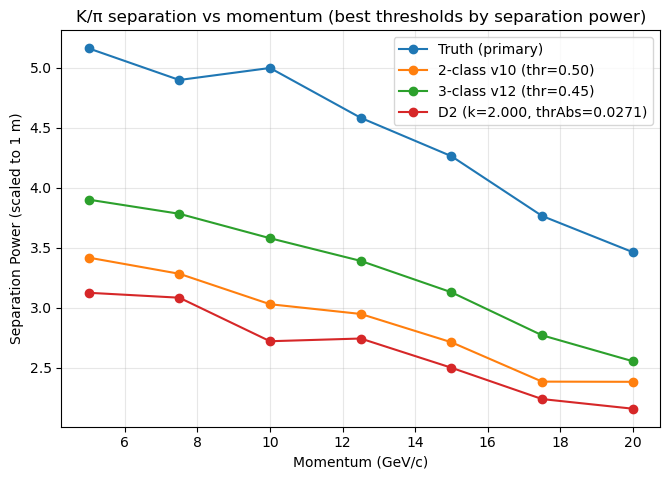

Saved: results/best_sep_truth_v10_v12_D2_noiseThreshold/sep_curve_bestSep.png


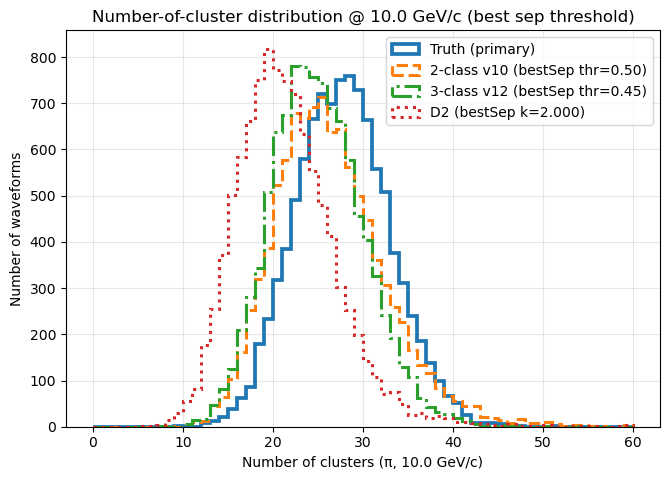

Saved: results/best_sep_truth_v10_v12_D2_noiseThreshold/hist_overlay_10GeV_bestSep.png

✅ Done. Outputs in: results/best_sep_truth_v10_v12_D2_noiseThreshold


In [3]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

# ============================================================
# FULL CODE (FIXED): Best-threshold by SEPARATION POWER
# - D2 threshold is noise-based: thr = k * sigma_bg  (paper-style idea)
# - Pick best threshold for v10/v12/D2 by maximizing avg separation power
# - Then plot:
#    (1) separation vs momentum (scaled to 1m)
#    (2) histogram overlay @ 10 GeV/c pion using BEST separation threshold
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
TRAIN_CACHE_FOR_SCALER = "cached_data/TimeSeries_seq_3000_batch0.npz"
DATA_NPZ_LIST = [f"PionsKaons/batch_{i}.npz" for i in range(5)]

BIN2_BEST_PT = "checkpoints_snn_seq_3000_batch0_binary_v10/best.pt"       # v10 (2-class: signal=pri+sec)
TRI3_BEST_PT = "checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt"   # v12 (3-class: bg/pri/sec)

OUTDIR = "results/best_sep_truth_v10_v12_D2_noiseThreshold"
os.makedirs(OUTDIR, exist_ok=True)

BATCH_SIZE = 256
NUM_TIMESTEPS = 20

PID_KAON = 130
PID_PION = 211
TAG_BG, TAG_PRI, TAG_SEC = 0, 1, 2

FIG8_MOM = 10.0
MOM_ATOL = 0.05
HIST_BINS = np.arange(0, 61, 1)

# Separation scaling to 1 m (paper uses 18mm cell)
CELL_LENGTH_MM = 18.0
TARGET_TRACK_MM = 1000.0
SCALE_TO_1M = np.sqrt(TARGET_TRACK_MM / CELL_LENGTH_MM)

OPT_MOMENTA = [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0]
MIN_PER_CLASS = 50

# ----------------------------
# Threshold grids
# ----------------------------
# ML thresholds for v10/v12 peak heights on probability trace
ML_THR_GRID = np.linspace(0.05, 0.95, 19).astype(np.float32)

# D2 threshold is noise-based: thr = k * sigma_bg
# Scan k values (dimensionless multiplier)
D2_K_GRID = np.concatenate([
    np.linspace(0.5, 4.0, 15),   # dense near small thresholds
    np.linspace(4.5, 10.0, 12),
]).astype(np.float32)

# ----------------------------
# Peak finding parameters (shared)
# ----------------------------
PEAK_MIN_DISTANCE = 6
PEAK_PROMINENCE = None
PEAK_WIDTH = None

# ----------------------------
# D2 params
# ----------------------------
D2_SMOOTH_WIN = 5
D2_POLARITY = +1   # flip to -1 if inverted pulses

# ----------------------------
# Speed controls
# ----------------------------
# Threshold selection (separation) can be done on subset, then apply best thr to full dataset
TUNE_N = 50000
TUNE_SEED = 0

# Optional global fast subset (for everything)
FAST_N_MAX = None     # e.g., 100000
FAST_SEED  = 0

# ============================================================
# MODEL (same as training)
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x);    spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)
        return torch.stack(spk_out, dim=2).mean(dim=2)  # (B,T,C)

# ============================================================
# DATA HELPERS
# ============================================================
def fit_scaler_from_cache(cache_path):
    print(f"Loading cached training data to fit scaler: {cache_path}", flush=True)
    d = np.load(cache_path)
    X_train = d["X_train"]
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, 1))
    print("Scaler fitted on X_train.\n", flush=True)
    return scaler

def load_one_npz(npz_path):
    data = np.load(npz_path)
    wf_i = data["wf_i"].astype(np.float32)
    mom  = data["mom"].astype(np.float32)
    pid  = data["pid"].astype(np.int32)
    tag_times  = data["tag_times"].astype(np.int32)
    tag_values = data["tag_values"].astype(np.int32)
    print(f"Loaded: {npz_path} wf_i={wf_i.shape}", flush=True)
    return wf_i, mom, pid, tag_times, tag_values

def load_all_batches(npz_list):
    wf_all, mom_all, pid_all, tt_all, tv_all = [], [], [], [], []
    for p in npz_list:
        wf_i, mom, pid, tt, tv = load_one_npz(p)
        wf_all.append(wf_i); mom_all.append(mom); pid_all.append(pid); tt_all.append(tt); tv_all.append(tv)
    wf = np.concatenate(wf_all, axis=0)
    mom = np.concatenate(mom_all, axis=0)
    pid = np.concatenate(pid_all, axis=0)
    tag_times = np.concatenate(tt_all, axis=0)
    tag_values = np.concatenate(tv_all, axis=0)
    print("=== Combined ===", flush=True)
    print("wf_i:", wf.shape, "mom:", mom.shape, "pid:", pid.shape, flush=True)
    return wf, mom, pid, tag_times, tag_values

def ensure_0_based_tag_times(tag_times, T):
    if tag_times.max() >= T or tag_times.min() >= 1:
        print("Detected 1-based tag_times → converted to 0-based", flush=True)
        return tag_times - 1
    return tag_times

def build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG):
    N, K = tag_times.shape
    y = np.full((N, T), default_label, dtype=np.int8)
    valid = (tag_times >= 0) & (tag_times < T)
    r, c = np.where(valid)
    t = tag_times[r, c]
    y[r, t] = tag_values[r, c].astype(np.int8)
    return y

def truth_primary_counts(y_dense):
    # tag_times are sparse cluster indices, so this should already be "cluster count"
    return (y_dense == TAG_PRI).sum(axis=1).astype(np.int32)

# ============================================================
# PEAK HELPERS (ML traces)
# ============================================================
def peaks_from_trace(x, min_distance, prominence=None, width=None):
    peaks, _ = find_peaks(x, distance=min_distance, prominence=prominence, width=width)
    return peaks

def ml_peak_count_from_prob(p, thr):
    peaks = peaks_from_trace(p, PEAK_MIN_DISTANCE, prominence=PEAK_PROMINENCE, width=PEAK_WIDTH)
    if peaks.size == 0:
        return 0
    keep = peaks[p[peaks] >= float(thr)]
    return int(keep.size)

# ============================================================
# D2 helpers (LPF + noise-based threshold)
# ============================================================
def smooth_ma_same(x, win):
    if win <= 1:
        return x.astype(np.float32, copy=False)
    k = np.ones(win, dtype=np.float32) / float(win)
    return np.convolve(x.astype(np.float32, copy=False), k, mode="same")

def d2_score(wf):
    """
    D2 score: -polarity * d2(y)
    (d2 computed on LPF-smoothed signal)
    """
    y = smooth_ma_same(wf, D2_SMOOTH_WIN)
    d2 = np.diff(y, n=2)                    # length T-2
    score = (-D2_POLARITY) * d2             # large positive => sharp concave peak
    return score.astype(np.float32)

def d2_peak_count_from_wf(wf, thr_abs):
    s = d2_score(wf)
    peaks = peaks_from_trace(s, PEAK_MIN_DISTANCE, prominence=PEAK_PROMINENCE, width=PEAK_WIDTH)
    if peaks.size == 0:
        return 0
    keep = peaks[s[peaks] >= float(thr_abs)]
    return int(keep.size)

def estimate_sigma_bg_on_subset(wf_i, y_dense, idx):
    """
    Paper-style: estimate average background noise.
    We estimate sigma of D2-score on BG indices, averaged across a subset.
    Note: D2 score length is T-2, so BG mask is taken from y_dense[:, 1:-1].
    """
    sigmas = []
    for i in tqdm(idx, desc="Estimating D2 bg noise", mininterval=1.0):
        s = d2_score(wf_i[i])                 # len T-2
        bg = (y_dense[i, 1:-1] == TAG_BG)     # align with score indices
        if np.sum(bg) < 50:
            continue
        sig = float(np.std(s[bg], ddof=1))
        if np.isfinite(sig) and sig > 0:
            sigmas.append(sig)
    if len(sigmas) == 0:
        return 1.0
    return float(np.mean(sigmas))

# ============================================================
# SEPARATION
# ============================================================
def sep_paper(muK, sigK, muPi, sigPi):
    return 2.0 * abs(muK - muPi) / (sigK + sigPi + 1e-12)

def separation_vs_momentum(counts, mom, pid, moms_to_use):
    moms_used, S = [], []
    for p in moms_to_use:
        mk  = (np.isclose(mom, p, atol=MOM_ATOL)) & (pid == PID_KAON)
        mpi = (np.isclose(mom, p, atol=MOM_ATOL)) & (pid == PID_PION)
        if mk.sum() < MIN_PER_CLASS or mpi.sum() < MIN_PER_CLASS:
            continue

        a = counts[mk].astype(np.float64)
        b = counts[mpi].astype(np.float64)
        muK, sigK   = a.mean(), a.std(ddof=1)
        muPi, sigPi = b.mean(), b.std(ddof=1)
        moms_used.append(float(p))
        S.append(float(sep_paper(muK, sigK, muPi, sigPi)))

    return np.array(moms_used, dtype=np.float64), np.array(S, dtype=np.float64)

def avg_sep_score_1m(counts, mom, pid):
    moms_used, S = separation_vs_momentum(counts, mom, pid, OPT_MOMENTA)
    if S.size == 0:
        return -1e9
    return float(np.mean(S * SCALE_TO_1M))

# ============================================================
# ML inference: get p(channel=1) for subset or full dataset
# ============================================================
@torch.no_grad()
def ml_prob_for_indices(model, wf_i, scaler, device, idx, which_model):
    wf = wf_i[idx]
    N, T = wf.shape
    x = scaler.transform(wf.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    use_cuda = (device.type == "cuda")
    loader = torch.utils.data.DataLoader(
        x_t, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=(4 if use_cuda else 0),
        pin_memory=use_cuda,
        persistent_workers=(True if use_cuda else False),
    )

    model.eval()
    use_amp = use_cuda
    out = np.zeros((N, T), dtype=np.float32)

    pos = 0
    for xb in tqdm(loader, desc=f"p1 ({which_model})", mininterval=1.0):
        bs = xb.shape[0]
        xb = xb.to(device, non_blocking=True)
        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                probs = torch.softmax(model(xb), dim=-1)
        else:
            probs = torch.softmax(model(xb), dim=-1)

        p1 = probs[..., 1].detach().cpu().numpy().astype(np.float32)
        out[pos:pos+bs] = p1
        pos += bs

    return out

@torch.no_grad()
def ml_peak_counts_all_at_thr(model, wf_i, scaler, device, thr, which_model):
    N, T = wf_i.shape
    x = scaler.transform(wf_i.reshape(-1, 1)).reshape(N, T, 1).astype(np.float32)
    x_t = torch.from_numpy(x)

    use_cuda = (device.type == "cuda")
    loader = torch.utils.data.DataLoader(
        x_t, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=(4 if use_cuda else 0),
        pin_memory=use_cuda,
        persistent_workers=(True if use_cuda else False),
    )

    model.eval()
    use_amp = use_cuda
    counts = np.zeros(N, dtype=np.int32)
    pos = 0
    thr = float(thr)

    for xb in tqdm(loader, desc=f"PeakCounts@thr ({which_model})", mininterval=1.0):
        bs = xb.shape[0]
        xb = xb.to(device, non_blocking=True)
        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                probs = torch.softmax(model(xb), dim=-1)
        else:
            probs = torch.softmax(model(xb), dim=-1)

        p1 = probs[..., 1].detach().cpu().numpy().astype(np.float32)

        for j in range(bs):
            counts[pos + j] = ml_peak_count_from_prob(p1[j], thr)
        pos += bs

    return counts

def d2_peak_counts_all(wf_i, thr_abs):
    N = wf_i.shape[0]
    counts = np.zeros(N, dtype=np.int32)
    t0 = time.time()
    for i in range(N):
        counts[i] = d2_peak_count_from_wf(wf_i[i], thr_abs)
        if (i + 1) % 2000 == 0:
            print(f"[D2 peak-counts] {i+1}/{N} in {time.time()-t0:.1f}s", flush=True)
    return counts

# ============================================================
# PLOTS
# ============================================================
def plot_sep_overlay(moms, curves_dict, out_png, title):
    plt.figure(figsize=(6.8, 4.9))
    for label, y in curves_dict.items():
        plt.plot(moms, y, marker="o", label=label)
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("Separation Power (scaled to 1 m)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

def plot_hist_overlay(truth_counts, v10_counts, v12_counts, d2_counts,
                      mom, pid, label_v10, label_v12, label_d2, out_png):
    mask = (pid == PID_PION) & (np.isclose(mom, FIG8_MOM, atol=MOM_ATOL))
    if mask.sum() == 0:
        print("No π@10GeV found for histogram.", flush=True)
        return

    xt = truth_counts[mask].astype(np.int32)
    x10 = v10_counts[mask].astype(np.int32)
    x12 = v12_counts[mask].astype(np.int32)
    xd2 = d2_counts[mask].astype(np.int32)

    plt.figure(figsize=(6.8, 4.9))
    plt.hist(xt,  bins=HIST_BINS, histtype="step", linewidth=2.7, label="Truth (primary)")
    plt.hist(x10, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="--", label=label_v10)
    plt.hist(x12, bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle="-.", label=label_v12)
    plt.hist(np.clip(xd2, 0, 60), bins=HIST_BINS, histtype="step", linewidth=2.2, linestyle=":", label=label_d2)

    plt.xlabel(f"Number of clusters (π, {FIG8_MOM:.1f} GeV/c)")
    plt.ylabel("Number of waveforms")
    plt.title(f"Number-of-cluster distribution @ {FIG8_MOM:.1f} GeV/c (best sep threshold)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()
    print("Saved:", out_png, flush=True)

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"Scale to 1m = sqrt(1000/18) = {SCALE_TO_1M:.6f}\n", flush=True)

    scaler = fit_scaler_from_cache(TRAIN_CACHE_FOR_SCALER)
    wf_i, mom, pid, tag_times, tag_values = load_all_batches(DATA_NPZ_LIST)

    # Optional global fast subset
    if FAST_N_MAX is not None and wf_i.shape[0] > FAST_N_MAX:
        rng = np.random.default_rng(FAST_SEED)
        idx = rng.choice(wf_i.shape[0], size=FAST_N_MAX, replace=False)
        wf_i = wf_i[idx]; mom = mom[idx]; pid = pid[idx]; tag_times = tag_times[idx]; tag_values = tag_values[idx]
        print(f"[FAST] using random subset N={FAST_N_MAX}\n", flush=True)

    N, T = wf_i.shape
    tag_times = ensure_0_based_tag_times(tag_times, T)
    y_dense = build_dense_truth_labels(tag_times, tag_values, T, default_label=TAG_BG)
    truth_counts = truth_primary_counts(y_dense)  # PRIMARY ONLY

    print("Truth primary mean/std:", float(truth_counts.mean()), float(truth_counts.std(ddof=1)), flush=True)
    print("", flush=True)

    # Tuning subset for thresholds (separation)
    rng = np.random.default_rng(TUNE_SEED)
    idx_tune = rng.choice(N, size=min(N, TUNE_N), replace=False)
    print(f"Tuning thresholds on n={idx_tune.size} waveforms (maximize separation)\n", flush=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device, flush=True)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0), flush=True)
    print("", flush=True)

    # Load models
    model_v10 = ConvSNN_Deep(num_classes=2).to(device)
    model_v10.load_state_dict(torch.load(BIN2_BEST_PT, map_location=device, weights_only=True))
    model_v12 = ConvSNN_Deep(num_classes=3).to(device)
    model_v12.load_state_dict(torch.load(TRI3_BEST_PT, map_location=device, weights_only=True))

    # ------------------------------------------------------------
    # 1) D2 noise estimate on BG (paper-style "average background noise")
    # ------------------------------------------------------------
    sigma_bg = estimate_sigma_bg_on_subset(wf_i, y_dense, idx_tune)
    print(f"\n[D2] estimated avg background sigma (score domain) = {sigma_bg:.6g}", flush=True)
    print("      D2 threshold will be thr_abs = k * sigma_bg\n", flush=True)

    # ------------------------------------------------------------
    # 2) Tune v10 threshold by separation (peak counting)
    # ------------------------------------------------------------
    p_v10 = ml_prob_for_indices(model_v10, wf_i, scaler, device, idx_tune, "v10 tune")
    best_thr_v10, best_score_v10 = None, -1e9
    for thr in ML_THR_GRID:
        counts = np.array([ml_peak_count_from_prob(p_v10[i], thr) for i in range(p_v10.shape[0])], dtype=np.int32)
        score = avg_sep_score_1m(counts, mom[idx_tune], pid[idx_tune])
        print(f"[v10 sep] thr={thr:.2f} avgSep(1m)={score:.4f}", flush=True)
        if score > best_score_v10:
            best_score_v10 = score
            best_thr_v10 = float(thr)
    print(f"\n[v10] BEST thr={best_thr_v10:.2f} avgSep(1m)={best_score_v10:.4f}\n", flush=True)

    # ------------------------------------------------------------
    # 3) Tune v12 threshold by separation (peak counting)
    # ------------------------------------------------------------
    p_v12 = ml_prob_for_indices(model_v12, wf_i, scaler, device, idx_tune, "v12 tune")
    best_thr_v12, best_score_v12 = None, -1e9
    for thr in ML_THR_GRID:
        counts = np.array([ml_peak_count_from_prob(p_v12[i], thr) for i in range(p_v12.shape[0])], dtype=np.int32)
        score = avg_sep_score_1m(counts, mom[idx_tune], pid[idx_tune])
        print(f"[v12 sep] thr={thr:.2f} avgSep(1m)={score:.4f}", flush=True)
        if score > best_score_v12:
            best_score_v12 = score
            best_thr_v12 = float(thr)
    print(f"\n[v12] BEST thr={best_thr_v12:.2f} avgSep(1m)={best_score_v12:.4f}\n", flush=True)

    # ------------------------------------------------------------
    # 4) Tune D2 k by separation (noise-thresholded peak counting)
    # ------------------------------------------------------------
    best_k_d2, best_score_d2 = None, -1e9
    for k in D2_K_GRID:
        thr_abs = float(k) * sigma_bg
        counts = np.zeros(idx_tune.size, dtype=np.int32)
        for ii, i in enumerate(idx_tune):
            counts[ii] = d2_peak_count_from_wf(wf_i[i], thr_abs)
        score = avg_sep_score_1m(counts, mom[idx_tune], pid[idx_tune])
        print(f"[D2 sep] k={float(k):.3f} thrAbs={thr_abs:.6g} avgSep(1m)={score:.4f}", flush=True)
        if score > best_score_d2:
            best_score_d2 = score
            best_k_d2 = float(k)
    best_thr_abs_d2 = best_k_d2 * sigma_bg
    print(f"\n[D2] BEST k={best_k_d2:.3f} thrAbs={best_thr_abs_d2:.6g} avgSep(1m)={best_score_d2:.4f}\n", flush=True)

    # ------------------------------------------------------------
    # 5) Compute FULL dataset counts using best sep thresholds
    # ------------------------------------------------------------
    counts_v10 = ml_peak_counts_all_at_thr(model_v10, wf_i, scaler, device, best_thr_v10, "v10 (2-class)")
    counts_v12 = ml_peak_counts_all_at_thr(model_v12, wf_i, scaler, device, best_thr_v12, "v12 (3-class)")
    counts_d2  = d2_peak_counts_all(wf_i, best_thr_abs_d2)

    # ------------------------------------------------------------
    # 6) Separation curves (full dataset)
    # ------------------------------------------------------------
    moms, S_truth = separation_vs_momentum(truth_counts, mom, pid, OPT_MOMENTA)
    _,    S_v10   = separation_vs_momentum(counts_v10,   mom, pid, OPT_MOMENTA)
    _,    S_v12   = separation_vs_momentum(counts_v12,   mom, pid, OPT_MOMENTA)
    _,    S_d2    = separation_vs_momentum(counts_d2,    mom, pid, OPT_MOMENTA)

    plot_sep_overlay(
        moms,
        curves_dict={
            "Truth (primary)": S_truth * SCALE_TO_1M,
            f"2-class v10 (thr={best_thr_v10:.2f})": S_v10 * SCALE_TO_1M,
            f"3-class v12 (thr={best_thr_v12:.2f})": S_v12 * SCALE_TO_1M,
            f"D2 (k={best_k_d2:.3f}, thrAbs={best_thr_abs_d2:.3g})": S_d2 * SCALE_TO_1M,
        },
        out_png=os.path.join(OUTDIR, "sep_curve_bestSep.png"),
        title="K/π separation vs momentum (best thresholds by separation power)",
    )

    # ------------------------------------------------------------
    # 7) Histogram overlay @10 GeV π using BEST sep thresholds
    # ------------------------------------------------------------
    plot_hist_overlay(
        truth_counts, counts_v10, counts_v12, counts_d2,
        mom, pid,
        label_v10=f"2-class v10 (bestSep thr={best_thr_v10:.2f})",
        label_v12=f"3-class v12 (bestSep thr={best_thr_v12:.2f})",
        label_d2=f"D2 (bestSep k={best_k_d2:.3f})",
        out_png=os.path.join(OUTDIR, "hist_overlay_10GeV_bestSep.png"),
    )

    # Save thresholds/metadata
    np.savez(
        os.path.join(OUTDIR, "bestSep_thresholds.npz"),
        best_thr_v10=float(best_thr_v10),
        best_thr_v12=float(best_thr_v12),
        d2_sigma_bg=float(sigma_bg),
        best_k_d2=float(best_k_d2),
        best_thr_abs_d2=float(best_thr_abs_d2),
        best_score_v10=float(best_score_v10),
        best_score_v12=float(best_score_v12),
        best_score_d2=float(best_score_d2),
        peak_min_distance=int(PEAK_MIN_DISTANCE),
        peak_prominence=(float(PEAK_PROMINENCE) if PEAK_PROMINENCE is not None else np.nan),
        peak_width=(float(PEAK_WIDTH) if PEAK_WIDTH is not None else np.nan),
        d2_smooth_win=int(D2_SMOOTH_WIN),
        d2_polarity=int(D2_POLARITY),
        tune_n=int(idx_tune.size),
        scale_to_1m=float(SCALE_TO_1M),
        mom_atol=float(MOM_ATOL),
        min_per_class=int(MIN_PER_CLASS),
        ml_thr_grid=ML_THR_GRID,
        d2_k_grid=D2_K_GRID,
    )

    print("\n✅ Done. Outputs in:", OUTDIR, flush=True)

if __name__ == "__main__":
    main()
